In [1]:
# ============================================================
# CELL 1 — PROJECT SETUP, IMPORTS, AND DATA PATHS
# ============================================================

# ------------------------------------------------------------
# 1. Standard Python libraries
# ------------------------------------------------------------
import os
import sys
import glob
import time
import warnings
from pathlib import Path

# ------------------------------------------------------------
# 2. Scientific computing
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 3. Point cloud and 4D change analysis
# ------------------------------------------------------------
import py4dgeo

# ------------------------------------------------------------
# 4. Filtering, spatial analysis, and evaluation
# ------------------------------------------------------------
from scipy.spatial import cKDTree
from scipy.ndimage import median_filter
from scipy.spatial.distance import directed_hausdorff

# ------------------------------------------------------------
# 5. Kalman filtering
# ------------------------------------------------------------
from filterpy.kalman import KalmanFilter

# ------------------------------------------------------------
# 6. Clustering and evaluation
# ------------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# ------------------------------------------------------------
# 7. Suppress warnings
# ------------------------------------------------------------
warnings.filterwarnings("ignore")

# ============================================================
# DATA DIRECTORY SETUP
# ============================================================


data_path = os.path.join(os.getcwd(), 'kijkduin')

# Check whether the dataset folder exists
if not os.path.isdir(data_path):
    print(f'ERROR: {data_path} does not exist')
    print('Please make sure the folder "kijkduin" is in the same directory as the notebook.')

# ------------------------------------------------------------
# Point cloud directory
# ------------------------------------------------------------
pc_dir = os.path.join(data_path, 'pointclouds')

# Check whether pointcloud folder exists
if not os.path.isdir(pc_dir):
    print(f'ERROR: {pc_dir} does not exist')
    print('Please make sure the "pointclouds" folder exists inside "kijkduin".')

# ------------------------------------------------------------
# List available point cloud files
# ------------------------------------------------------------
pc_list = sorted(os.listdir(pc_dir))

print(f"\nFound {len(pc_list)} point cloud files.\n")

# Show first few files
for f in pc_list[:5]:
    print(f)

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")
TABLES_DIR = Path("tables")

for folder in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(exist_ok=True)

# ============================================================
# AUTHOR SCRIPTS
# ============================================================


AUTHOR_SCRIPTS = [
    "kalman_m3c2.py",
    "multitemp_change.py",
    "multitemp_change_synth.py",
    "kromer_m3c2.py",
    "kmeans_cluster.py",
    "plot_kalman.py",
    "plot_kalman_qchoice.py",
    "plot_kalman_qchoice_synth.py",
    "plot_method_comp.py",
    "kalman_synth_residuals.py"
]

print("\nChecking author scripts:\n")

for script in AUTHOR_SCRIPTS:
    if os.path.isfile(script):
        print(f"[FOUND]   {script}")
    else:
        print(f"[MISSING] {script}")

# Add current working directory to Python path
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print("\nCell 1 complete: setup finished.")


Found 160 point cloud files.

kijkduin_170117_120041.laz
kijkduin_170118_000050.laz
kijkduin_170120_120036.laz
kijkduin_170121_000046.laz
kijkduin_170121_120055.laz

Checking author scripts:

[FOUND]   kalman_m3c2.py
[FOUND]   multitemp_change.py
[FOUND]   multitemp_change_synth.py
[FOUND]   kromer_m3c2.py
[FOUND]   kmeans_cluster.py
[FOUND]   plot_kalman.py
[FOUND]   plot_kalman_qchoice.py
[FOUND]   plot_kalman_qchoice_synth.py
[FOUND]   plot_method_comp.py
[FOUND]   kalman_synth_residuals.py

Cell 1 complete: setup finished.


Number of usable point cloud files: 160
First file: kijkduin_170117_120041.laz
Last file:  kijkduin_170526_000034.laz

Loading point clouds...
[2026-08-01 12:17:58][INFO] Reading point cloud from file 'C:\Users\tenbi\4D OBC PROJECT\kijkduin\pointclouds\kijkduin_170117_120041.laz'
Loaded epoch 000: kijkduin_170117_120041.laz
[2026-08-01 12:17:58][INFO] Reading point cloud from file 'C:\Users\tenbi\4D OBC PROJECT\kijkduin\pointclouds\kijkduin_170118_000050.laz'
Loaded epoch 001: kijkduin_170118_000050.laz
[2026-08-01 12:17:58][INFO] Reading point cloud from file 'C:\Users\tenbi\4D OBC PROJECT\kijkduin\pointclouds\kijkduin_170120_120036.laz'
Loaded epoch 002: kijkduin_170120_120036.laz
[2026-08-01 12:17:58][INFO] Reading point cloud from file 'C:\Users\tenbi\4D OBC PROJECT\kijkduin\pointclouds\kijkduin_170121_000046.laz'
Loaded epoch 003: kijkduin_170121_000046.laz
[2026-08-01 12:17:59][INFO] Reading point cloud from file 'C:\Users\tenbi\4D OBC PROJECT\kijkduin\pointclouds\kijkduin_170121

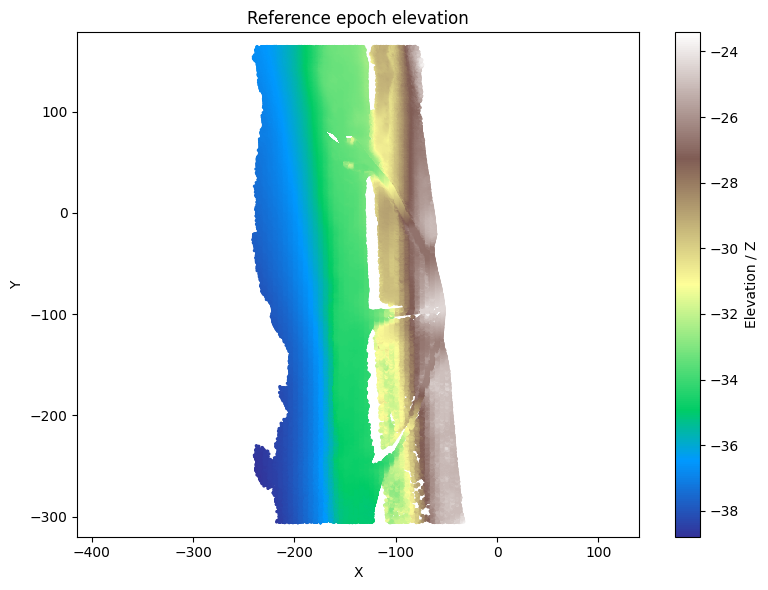


Cell 2 complete: point cloud time series loaded.


In [2]:
# ============================================================
# CELL 2 — LOAD POINT CLOUD TIME SERIES
# ============================================================


# ------------------------------------------------------------
# 1. Build full file paths
# ------------------------------------------------------------

pc_files = [
    os.path.join(pc_dir, f)
    for f in pc_list
    if f.lower().endswith((".ply", ".las", ".laz", ".xyz", ".txt", ".csv", ".pcd"))
]

pc_files = sorted(pc_files)

if len(pc_files) == 0:
    raise FileNotFoundError(
        f"No supported point cloud files found in {pc_dir}."
    )

print(f"Number of usable point cloud files: {len(pc_files)}")
print("First file:", os.path.basename(pc_files[0]))
print("Last file: ", os.path.basename(pc_files[-1]))


# ------------------------------------------------------------
# 2. Load point clouds with py4dgeo
# ------------------------------------------------------------

def load_pointcloud_py4dgeo(file_path):
    """
    Load one point cloud using py4dgeo.

    Parameters
    ----------
    file_path : str
        Path to point cloud file.

    Returns
    -------
    epoch : py4dgeo.Epoch
        Loaded point cloud epoch.
    """
    ext = Path(file_path).suffix.lower()

    if ext in [".las", ".laz"]:
        epoch = py4dgeo.read_from_las(file_path)

    elif ext in [".xyz", ".txt", ".csv", ".ply", ".pcd"]:
        epoch = py4dgeo.read_from_xyz(file_path)

    else:
        raise ValueError(f"Unsupported point cloud format: {ext}")

    return epoch


# ------------------------------------------------------------
# 3. Load all epochs
# ------------------------------------------------------------

epochs = []

print("\nLoading point clouds...")

for i, file_path in enumerate(pc_files):
    epoch = load_pointcloud_py4dgeo(file_path)
    epochs.append(epoch)

    print(f"Loaded epoch {i:03d}: {os.path.basename(file_path)}")

print("\nAll point clouds loaded.")
print(f"Total epochs: {len(epochs)}")


# ------------------------------------------------------------
# 4. Define reference and compared epochs
# ------------------------------------------------------------

reference_epoch = epochs[0]
comparison_epochs = epochs[1:]

reference_file = pc_files[0]
comparison_files = pc_files[1:]

print("\nReference epoch:")
print(os.path.basename(reference_file))

print("\nNumber of comparison epochs:")
print(len(comparison_epochs))


# ------------------------------------------------------------
# 5. Quick inspection of reference epoch
# ------------------------------------------------------------

reference_points = reference_epoch.cloud

print("\nReference point cloud shape:")
print(reference_points.shape)

print("\nFirst five reference points:")
print(reference_points[:5])


# ------------------------------------------------------------
# 6. Optional quick XY plot of reference elevation
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    reference_points[:, 0],
    reference_points[:, 1],
    c=reference_points[:, 2],
    s=2,
    cmap="terrain"
)

plt.colorbar(sc, label="Elevation / Z")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Reference epoch elevation")
plt.axis("equal")
plt.tight_layout()
plt.show()

print("\nCell 2 complete: point cloud time series loaded.")

In [3]:
# ============================================================
# CELL 3 — CREATE SPATIOTEMPORAL ANALYSIS OBJECT
# ============================================================

# ------------------------------------------------------------
# 1. Import datetime for timestamp parsing
# ------------------------------------------------------------

from datetime import datetime


# ------------------------------------------------------------
# 2. Keep only LAZ files and sort them
# ------------------------------------------------------------

pc_list = sorted([
    f for f in os.listdir(pc_dir)
    if f.endswith(".laz")
])

if len(pc_list) == 0:
    raise FileNotFoundError(
        f"No .laz files found in {pc_dir}. "
        "Please check the pointclouds folder."
    )

print(f"Number of LAZ point clouds found: {len(pc_list)}")
print("First five files:")
for f in pc_list[:5]:
    print(f)


# ------------------------------------------------------------
# 3. Read timestamps from file names
# ------------------------------------------------------------

timestamps = []

for f in pc_list:
    # Remove extension and split filename
    filename_without_ext = f.split(".")[0]

    # Extract timestamp part
    timestamp_str = "_".join(filename_without_ext.split("_")[1:])

    # Convert to datetime object
    timestamp = datetime.strptime(timestamp_str, "%y%m%d_%H%M%S")

    timestamps.append(timestamp)

print("\nFirst five timestamps:")
print(timestamps[:5])


# ------------------------------------------------------------
# 4. Create SpatiotemporalAnalysis archive
# ------------------------------------------------------------

analysis_file = os.path.join(data_path, "kijkduin.zip")

analysis = py4dgeo.SpatiotemporalAnalysis(
    analysis_file,
    force=True
)

print("\nSpatiotemporalAnalysis object created:")
print(analysis_file)


# ------------------------------------------------------------
# 5. Load reference epoch
# ------------------------------------------------------------

reference_epoch_file = os.path.join(pc_dir, pc_list[0])

reference_epoch = py4dgeo.read_from_las(reference_epoch_file)

# Assign timestamp to reference epoch
reference_epoch.timestamp = timestamps[0]

# Store reference epoch in analysis object
analysis.reference_epoch = reference_epoch

print("\nReference epoch loaded and stored.")
print("Reference file:", pc_list[0])
print("Reference timestamp:", reference_epoch.timestamp)
print("Reference point cloud shape:", reference_epoch.cloud.shape)


# ------------------------------------------------------------
# 6. Store comparison epoch file paths and timestamps
# ------------------------------------------------------------

comparison_epoch_files = [
    os.path.join(pc_dir, f)
    for f in pc_list[1:]
]

comparison_timestamps = timestamps[1:]

print("\nNumber of comparison epochs:")
print(len(comparison_epoch_files))


# ------------------------------------------------------------
# 7. Save basic metadata
# ------------------------------------------------------------

metadata_table = pd.DataFrame({
    "epoch_index": list(range(len(pc_list))),
    "filename": pc_list,
    "timestamp": timestamps
})

display(metadata_table.head())

metadata_table.to_csv(
    TABLES_DIR / "kijkduin_epoch_metadata.csv",
    index=False
)

print("\nCell 3 complete: analysis archive and reference epoch prepared.")

Number of LAZ point clouds found: 160
First five files:
kijkduin_170117_120041.laz
kijkduin_170118_000050.laz
kijkduin_170120_120036.laz
kijkduin_170121_000046.laz
kijkduin_170121_120055.laz

First five timestamps:
[datetime.datetime(2017, 1, 17, 12, 0, 41), datetime.datetime(2017, 1, 18, 0, 0, 50), datetime.datetime(2017, 1, 20, 12, 0, 36), datetime.datetime(2017, 1, 21, 0, 0, 46), datetime.datetime(2017, 1, 21, 12, 0, 55)]
[2026-08-01 12:18:47][INFO] Creating analysis file C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip

SpatiotemporalAnalysis object created:
C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip
[2026-08-01 12:18:47][INFO] Reading point cloud from file 'C:\Users\tenbi\4D OBC PROJECT\kijkduin\pointclouds\kijkduin_170117_120041.laz'
[2026-08-01 12:18:47][INFO] Building KDTree structure with leaf parameter 10
[2026-08-01 12:18:47][INFO] Saving epoch to file 'C:\Users\tenbi\AppData\Local\Temp\tmpsre6h6_t\reference_epoch.zip'
[2026-08-01 12:18:47][INFO] Saving a file wi

,epoch_index,filename,timestamp
0,0,kijkduin_170117_120041.laz,2017-01-17 12:00:41
1,1,kijkduin_170118_000050.laz,2017-01-18 00:00:50
2,2,kijkduin_170120_120036.laz,2017-01-20 12:00:36
3,3,kijkduin_170121_000046.laz,2017-01-21 00:00:46
4,4,kijkduin_170121_120055.laz,2017-01-21 12:00:55



Cell 3 complete: analysis archive and reference epoch prepared.


Old analysis archive removed:
C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip
[2026-08-01 12:19:34][INFO] Creating analysis file C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip

New SpatiotemporalAnalysis archive created:
C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip
[2026-08-01 12:19:34][INFO] Reading point cloud from file 'C:\Users\tenbi\4D OBC PROJECT\kijkduin\pointclouds\kijkduin_170117_120041.laz'
[2026-08-01 12:19:34][INFO] Building KDTree structure with leaf parameter 10
[2026-08-01 12:19:34][INFO] Saving epoch to file 'C:\Users\tenbi\AppData\Local\Temp\tmp9p_agp9e\reference_epoch.zip'
[2026-08-01 12:19:34][INFO] Saving a file without normals.

Reference epoch set.
Reference file: kijkduin_170117_120041.laz
Reference timestamp: 2017-01-17 12:00:41
Reference points: 215550
[2026-08-01 12:19:35][INFO] Initializing Epoch object from given point cloud
[2026-08-01 12:19:35][INFO] Building KDTree structure with leaf parameter 10
[2026-08-01 12:19:35][INFO] Saving epoch t

,epoch_index,type,filename,timestamp,n_points
0,0,reference,kijkduin_170117_120041.laz,2017-01-17 12:00:41,215550
1,1,comparison,kijkduin_170118_000050.laz,2017-01-18 00:00:50,215550
2,2,comparison,kijkduin_170120_120036.laz,2017-01-20 12:00:36,215550
3,3,comparison,kijkduin_170121_000046.laz,2017-01-21 00:00:46,215550
4,4,comparison,kijkduin_170121_120055.laz,2017-01-21 12:00:55,215550


,epoch_index,type,filename,timestamp,n_points
155,155,comparison,kijkduin_170523_120052.laz,2017-05-23 12:00:52,215550
156,156,comparison,kijkduin_170524_120011.laz,2017-05-24 12:00:11,215550
157,157,comparison,kijkduin_170525_000018.laz,2017-05-25 00:00:18,215550
158,158,comparison,kijkduin_170525_120025.laz,2017-05-25 12:00:25,215550
159,159,comparison,kijkduin_170526_000034.laz,2017-05-26 00:00:34,215550


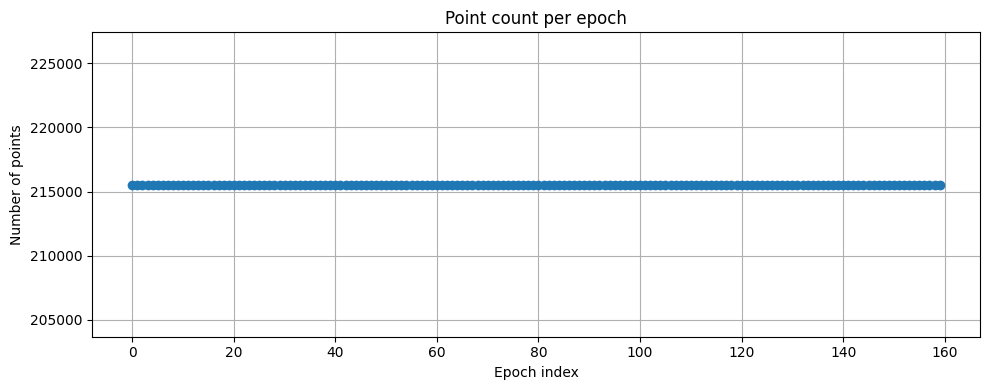


Cell 4 complete.


In [4]:
# ============================================================
# CELL 4 — RECREATE ANALYSIS, SET COREPOINTS, M3C2, ADD EPOCHS
# ============================================================

# ------------------------------------------------------------
# 1. Recreate analysis archive
# ------------------------------------------------------------

analysis_file = os.path.join(data_path, "kijkduin.zip")

if os.path.exists(analysis_file):
    os.remove(analysis_file)
    print("Old analysis archive removed:")
    print(analysis_file)

analysis = py4dgeo.SpatiotemporalAnalysis(
    analysis_file,
    force=True
)

print("\nNew SpatiotemporalAnalysis archive created:")
print(analysis_file)


# ------------------------------------------------------------
# 2. Reload and set reference epoch
# ------------------------------------------------------------

reference_epoch_file = os.path.join(pc_dir, pc_list[0])

reference_epoch = py4dgeo.read_from_las(reference_epoch_file)
reference_epoch.timestamp = timestamps[0]

analysis.reference_epoch = reference_epoch

print("\nReference epoch set.")
print("Reference file:", pc_list[0])
print("Reference timestamp:", reference_epoch.timestamp)
print("Reference points:", reference_epoch.cloud.shape[0])


# ------------------------------------------------------------
# 3. Set corepoints
# ------------------------------------------------------------

analysis.corepoints = reference_epoch.cloud[::]

print("\nCorepoints set.")
print("Number of corepoints:", analysis.corepoints.cloud.shape[0])


# ------------------------------------------------------------
# 4. Set M3C2 parameters
# ------------------------------------------------------------

analysis.m3c2 = py4dgeo.M3C2(
    normal_radii=(5.0,),
    cyl_radius=1.0,
    max_distance=10.0,
    registration_error=0.019
)

print("\nM3C2 parameters set.")
print("normal_radii = (5.0,)")
print("cyl_radius = 1.0")
print("max_distance = 10.0")
print("registration_error = 0.019")


# ------------------------------------------------------------
# 5. Load and add comparison epochs
# ------------------------------------------------------------

comparison_epochs = []

print("\nLoading and adding comparison epochs...")

start_time = time.time()

for i, (epoch_file, timestamp) in enumerate(
    zip(comparison_epoch_files, comparison_timestamps),
    start=1
):
    epoch = py4dgeo.read_from_las(epoch_file)
    epoch.timestamp = timestamp

    comparison_epochs.append(epoch)

    print(
        f"Adding epoch {i:03d}/{len(comparison_epoch_files)}: "
        f"{os.path.basename(epoch_file)} | {timestamp}"
    )

    analysis.add_epochs(epoch)

elapsed = time.time() - start_time

print("\nAll comparison epochs added.")
print(f"Elapsed time: {elapsed:.2f} seconds")


# ------------------------------------------------------------
# 6. Build and save epoch summary table
# ------------------------------------------------------------

epoch_summary_records = []

epoch_summary_records.append({
    "epoch_index": 0,
    "type": "reference",
    "filename": pc_list[0],
    "timestamp": timestamps[0],
    "n_points": reference_epoch.cloud.shape[0]
})

for i, epoch in enumerate(comparison_epochs, start=1):
    epoch_summary_records.append({
        "epoch_index": i,
        "type": "comparison",
        "filename": pc_list[i],
        "timestamp": epoch.timestamp,
        "n_points": epoch.cloud.shape[0]
    })

epoch_summary_table = pd.DataFrame(epoch_summary_records)

display(epoch_summary_table.head())
display(epoch_summary_table.tail())

epoch_summary_table.to_csv(
    TABLES_DIR / "epoch_summary_table.csv",
    index=False
)


# ------------------------------------------------------------
# 7. Plot point count per epoch
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(
    epoch_summary_table["epoch_index"],
    epoch_summary_table["n_points"],
    marker="o"
)

plt.xlabel("Epoch index")
plt.ylabel("Number of points")
plt.title("Point count per epoch")
plt.grid(True)
plt.tight_layout()
plt.show()


print("\nCell 4 complete.")

Space-time distance array:
[[ 0.01850919 -0.00906555 -0.00339622  0.0279788          nan]
 [ 0.01818561 -0.00841916 -0.00461286  0.02803463         nan]
 [ 0.01180171 -0.00568688  0.00374172  0.02805253         nan]]

Uncertainties / LoD of M3C2 distance calculation:
[[0.03851164 0.04335261 0.03928217 0.04150054        nan]
 [0.0381333  0.04228983 0.03866897 0.03990954        nan]
 [0.04057941 0.04158147 0.04027046 0.04211326        nan]]

Timestamp deltas of analysis:
[datetime.timedelta(seconds=43209), datetime.timedelta(days=2, seconds=86395), datetime.timedelta(days=3, seconds=43205), datetime.timedelta(days=4, seconds=14), datetime.timedelta(days=6, seconds=4)]

Available uncertainty fields:
('lodetection', 'spread1', 'num_samples1', 'spread2', 'num_samples2')

Corepoints shape: (215550, 3)
Distances shape: (215550, 159)
LoDetection shape: (215550, 159)
[2026-08-01 14:34:09][INFO] Restoring epoch from file 'C:\Users\tenbi\AppData\Local\Temp\tmpew6b24xv\reference_epoch.zip'

First 

,epoch_index,timestamp,mean_distance,std_distance,min_distance,max_distance,mean_lodetection
0,0,2017-01-18 00:00:50,0.001181,0.040959,-0.971674,1.654308,0.062921
1,1,2017-01-20 12:00:36,0.002637,0.053608,-0.972697,2.102112,0.063732
2,2,2017-01-21 00:00:46,0.004836,0.054326,-0.968522,2.106050,0.063574
3,3,2017-01-21 12:00:55,0.004620,0.055380,-0.971612,1.978025,0.063680
4,4,2017-01-23 12:00:45,0.006859,0.054713,-0.972179,1.722980,0.063856



Selected core point index: 15162
Selected epoch index: 28


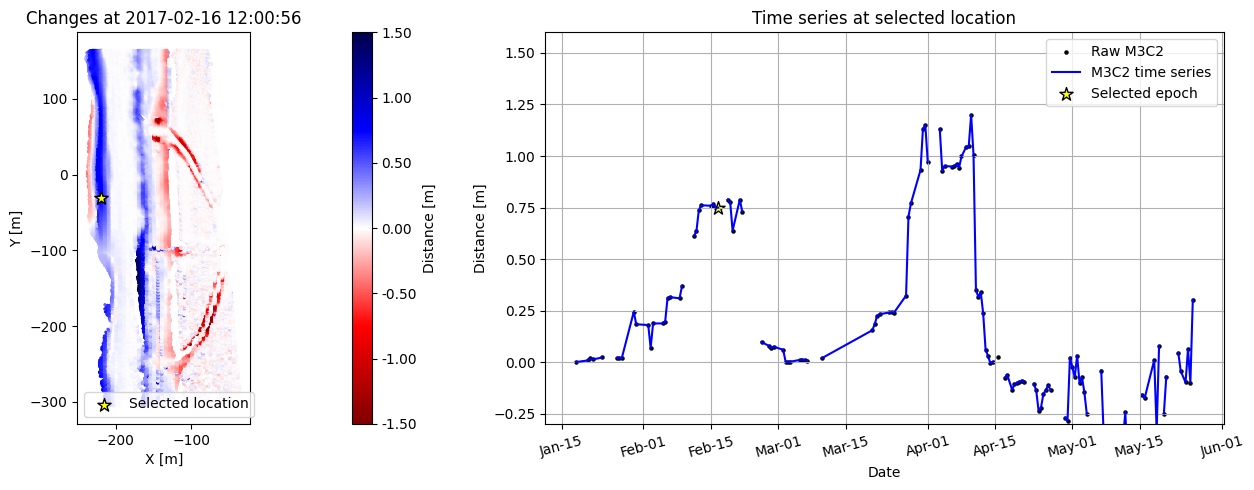


Cell 5 complete: M3C2 distances inspected and visualized.


In [5]:
# ============================================================
# CELL 5 — INSPECT M3C2 DISTANCES AND VISUALIZE CHANGE SERIES
# ============================================================

# ------------------------------------------------------------
# 1. Print basic spatiotemporal arrays
# ------------------------------------------------------------

print(f"Space-time distance array:\n{analysis.distances[:3, :5]}")

print(
    f"\nUncertainties / LoD of M3C2 distance calculation:\n"
    f"{analysis.uncertainties['lodetection'][:3, :5]}"
)

print(f"\nTimestamp deltas of analysis:\n{analysis.timedeltas[:5]}")


# ------------------------------------------------------------
# 2. Store key arrays for later workflows
# ------------------------------------------------------------

corepoints = analysis.corepoints.cloud

# M3C2 distance time series
distances = analysis.distances

# M3C2 level of detection field
lodetection = analysis.uncertainties["lodetection"]

# Other uncertainty-related fields available in structured array
uncertainty_fields = analysis.uncertainties.dtype.names

print("\nAvailable uncertainty fields:")
print(uncertainty_fields)

print("\nCorepoints shape:", corepoints.shape)
print("Distances shape:", distances.shape)
print("LoDetection shape:", lodetection.shape)


# ------------------------------------------------------------
# 3. Create timestamps from reference timestamp and timedeltas
# ------------------------------------------------------------

timestamps_analysis = [
    analysis.reference_epoch.timestamp + t
    for t in analysis.timedeltas
]

print("\nFirst five analysis timestamps:")
print(timestamps_analysis[:5])


# ------------------------------------------------------------
# 4. Create simple summary table
# ------------------------------------------------------------

m3c2_summary = pd.DataFrame({
    "epoch_index": np.arange(distances.shape[1]),
    "timestamp": timestamps_analysis,
    "mean_distance": np.nanmean(distances, axis=0),
    "std_distance": np.nanstd(distances, axis=0),
    "min_distance": np.nanmin(distances, axis=0),
    "max_distance": np.nanmax(distances, axis=0),
    "mean_lodetection": np.nanmean(lodetection, axis=0)
})

display(m3c2_summary.head())

m3c2_summary.to_csv(
    TABLES_DIR / "m3c2_distance_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Select core point and epoch for visualization
# ------------------------------------------------------------
# These values follow the notebook example.
# If your dataset has fewer points or epochs, the code adjusts safely.

cp_idx_sel = min(15162, corepoints.shape[0] - 1)
epoch_idx_sel = min(28, distances.shape[1] - 1)

print("\nSelected core point index:", cp_idx_sel)
print("Selected epoch index:", epoch_idx_sel)


# ------------------------------------------------------------
# 6. Get selected values for plotting
# ------------------------------------------------------------

distances_epoch = distances[:, epoch_idx_sel]

coord_sel = corepoints[cp_idx_sel]

timeseries_sel = distances[cp_idx_sel]


# ------------------------------------------------------------
# 7. Visualize scene and selected time series
# ------------------------------------------------------------

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)


# ------------------------------------------------------------
# Plot spatial M3C2 change for selected epoch
# ------------------------------------------------------------

d = ax1.scatter(
    corepoints[:, 0],
    corepoints[:, 1],
    c=distances_epoch,
    cmap="seismic_r",
    vmin=-1.5,
    vmax=1.5,
    s=1,
    zorder=1
)

plt.colorbar(
    d,
    format="%.2f",
    label="Distance [m]",
    ax=ax1,
    pad=.15
)

# Add selected core point location
ax1.scatter(
    coord_sel[0],
    coord_sel[1],
    facecolor="yellow",
    edgecolor="black",
    s=100,
    zorder=2,
    label="Selected location",
    marker="*"
)

ax1.legend()
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.set_aspect("equal")
ax1.set_title(
    "Changes at %s" %
    timestamps_analysis[epoch_idx_sel]
)


# ------------------------------------------------------------
# Plot time series at selected core point
# ------------------------------------------------------------

ax2.scatter(
    timestamps_analysis,
    timeseries_sel,
    s=5,
    color="black",
    label="Raw M3C2"
)

ax2.plot(
    timestamps_analysis,
    timeseries_sel,
    color="blue",
    label="M3C2 time series"
)

# Mark selected epoch
ax2.scatter(
    timestamps_analysis[epoch_idx_sel],
    timeseries_sel[epoch_idx_sel],
    facecolor="yellow",
    edgecolor="black",
    s=100,
    marker="*",
    label="Selected epoch"
)

ax2.legend()
ax2.set_xlabel("Date")
ax2.tick_params(axis="x", rotation=15)


# ------------------------------------------------------------
# Format date labels
# ------------------------------------------------------------

import matplotlib.dates as mdates

dtFmt = mdates.DateFormatter("%b-%d")
ax2.xaxis.set_major_formatter(dtFmt)

ax2.set_ylabel("Distance [m]")
ax2.grid()
ax2.set_ylim(-0.3, 1.6)
ax2.set_title("Time series at selected location")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Save arrays for later workflows
# ------------------------------------------------------------

np.save(RESULTS_DIR / "corepoints.npy", corepoints)
np.save(RESULTS_DIR / "m3c2_distances.npy", distances)
np.save(RESULTS_DIR / "m3c2_lodetection.npy", lodetection)

print("\nCell 5 complete: M3C2 distances inspected and visualized.")

Applying temporal smoothing...
Smoothing window: 14
[2026-08-01 14:36:24][INFO] Starting: Smoothing temporal data
[2026-08-01 14:37:06][INFO] Finished in 41.6389s: Smoothing temporal data

Temporal smoothing complete.
Raw distances shape:      (215550, 159)
Smoothed distances shape: (215550, 159)

Selected core point: 15162


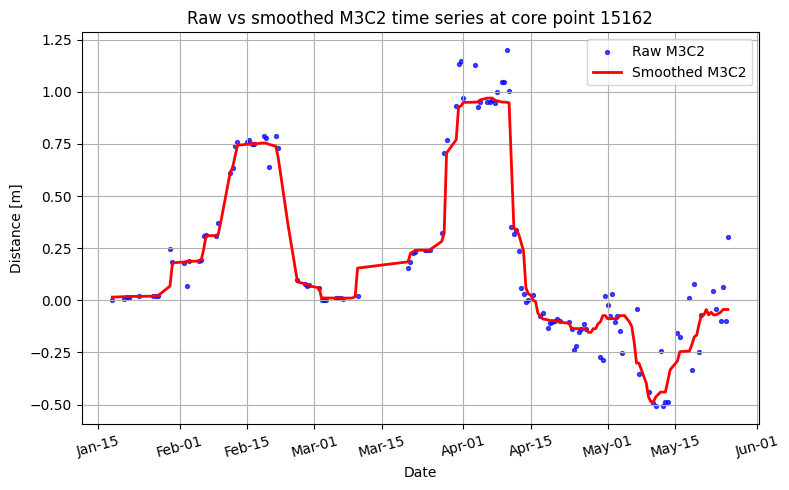


Cell 6 complete: temporal smoothing applied.


In [6]:
# ============================================================
# CELL 6 — TEMPORAL SMOOTHING OF M3C2 TIME SERIES
# ============================================================


# ------------------------------------------------------------
# 1. Define smoothing window
# ------------------------------------------------------------

SMOOTHING_WINDOW = 14

print("Applying temporal smoothing...")
print("Smoothing window:", SMOOTHING_WINDOW)


# ------------------------------------------------------------
# 2. Apply temporal averaging / rolling median
# ------------------------------------------------------------

analysis.smoothed_distances = py4dgeo.temporal_averaging(
    analysis.distances,
    smoothing_window=SMOOTHING_WINDOW
)

print("\nTemporal smoothing complete.")
print("Raw distances shape:     ", analysis.distances.shape)
print("Smoothed distances shape:", analysis.smoothed_distances.shape)


# ------------------------------------------------------------
# 3. Select core point for comparison
# ------------------------------------------------------------

if "cp_idx_sel" not in globals():
    cp_idx_sel = min(15162, analysis.distances.shape[0] - 1)

print("\nSelected core point:", cp_idx_sel)


# ------------------------------------------------------------
# 4. Extract raw and smoothed time series
# ------------------------------------------------------------

raw_timeseries_sel = analysis.distances[cp_idx_sel]
smooth_timeseries_sel = analysis.smoothed_distances[cp_idx_sel]


# ------------------------------------------------------------
# 5. Plot raw vs smoothed time series
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.scatter(
    timestamps_analysis,
    raw_timeseries_sel,
    color="blue",
    label="Raw M3C2",
    s=8,
    alpha=0.7
)

ax.plot(
    timestamps_analysis,
    smooth_timeseries_sel,
    color="red",
    linewidth=2,
    label="Smoothed M3C2"
)

# Format date labels
import matplotlib.dates as mdates

dtFmt = mdates.DateFormatter("%b-%d")
ax.xaxis.set_major_formatter(dtFmt)

ax.set_xlabel("Date")
ax.tick_params(axis="x", rotation=15)
ax.set_ylabel("Distance [m]")
ax.set_title(f"Raw vs smoothed M3C2 time series at core point {cp_idx_sel}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Save smoothed distances
# ------------------------------------------------------------

np.save(
    RESULTS_DIR / "m3c2_smoothed_distances.npy",
    analysis.smoothed_distances
)

print("\nCell 6 complete: temporal smoothing applied.")

In [7]:
# ============================================================
# CELL 7 — K-MEANS CLUSTERING OF M3C2 CHANGE PATTERNS
# ============================================================


# ------------------------------------------------------------
# 1. Select input data for clustering
# ------------------------------------------------------------

distances_for_clustering = analysis.smoothed_distances

print("Input for clustering:")
print("distances_for_clustering shape:", distances_for_clustering.shape)


# ------------------------------------------------------------
# 2. Define cluster numbers
# ------------------------------------------------------------

ks = [5, 10, 20, 50]

print("Cluster numbers to test:", ks)


# ------------------------------------------------------------
# 3. Create array to store cluster labels
# ------------------------------------------------------------

labels = np.full(
    (distances_for_clustering.shape[0], len(ks)),
    np.nan
)


# ------------------------------------------------------------
# 4. Identify valid time series
# ------------------------------------------------------------

valid_timeseries = np.logical_not(
    np.isnan(np.sum(distances_for_clustering, axis=1))
)

print("Valid time series:", np.sum(valid_timeseries))
print("Invalid time series:", np.sum(~valid_timeseries))


# ------------------------------------------------------------
# 5. Run K-means clustering
# ------------------------------------------------------------

for kidx, k in enumerate(ks):
    print(f"\nPerforming clustering with k={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    kmeans.fit(distances_for_clustering[valid_timeseries, :])

    labels[valid_timeseries, kidx] = kmeans.labels_

    print(f"Finished clustering with k={k}")


# ------------------------------------------------------------
# 6. Save clustering labels
# ------------------------------------------------------------

np.save(
    RESULTS_DIR / "kmeans_labels_smoothed_m3c2.npy",
    labels
)

print("\nCluster labels saved to:")
print(RESULTS_DIR / "kmeans_labels_smoothed_m3c2.npy")


# ------------------------------------------------------------
# 7. Save clustering metadata
# ------------------------------------------------------------

clustering_metadata = pd.DataFrame({
    "k_index": list(range(len(ks))),
    "n_clusters": ks
})

display(clustering_metadata)

clustering_metadata.to_csv(
    TABLES_DIR / "kmeans_clustering_metadata.csv",
    index=False
)


print("\nCell 7 complete: K-means clustering finished.")

Input for clustering:
distances_for_clustering shape: (215550, 159)
Cluster numbers to test: [5, 10, 20, 50]
Valid time series: 195100
Invalid time series: 20450

Performing clustering with k=5...
Finished clustering with k=5

Performing clustering with k=10...
Finished clustering with k=10

Performing clustering with k=20...
Finished clustering with k=20

Performing clustering with k=50...
Finished clustering with k=50

Cluster labels saved to:
results\kmeans_labels_smoothed_m3c2.npy


,k_index,n_clusters
0,0,5
1,1,10
2,2,20
3,3,50



Cell 7 complete: K-means clustering finished.


Visualizing clustering result for k=5
Number of valid labelled points: 195100


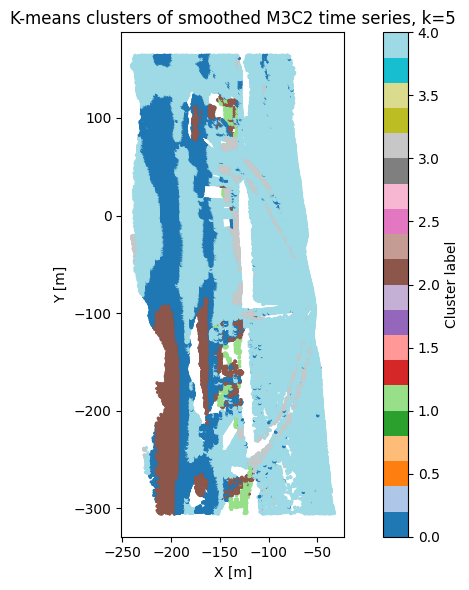

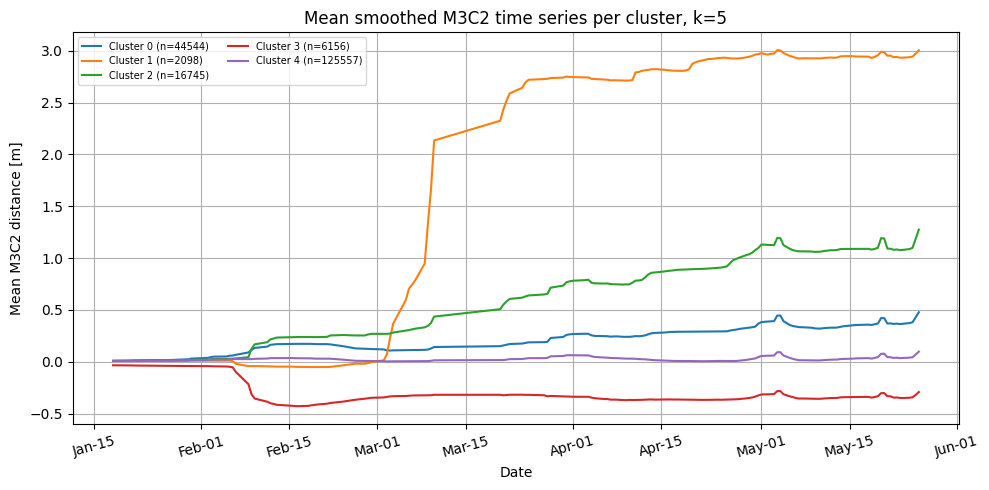


Cluster map saved to:
tables\kmeans_cluster_map_k5.csv

Cell 8 complete: clustering visualization finished.


In [8]:
# ============================================================
# CELL 8 — VISUALIZE K-MEANS CLUSTERING RESULTS
# ============================================================

# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------

required_objects = [
    "labels",
    "ks",
    "corepoints",
    "distances_for_clustering",
    "timestamps_analysis"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(f"{obj} is not defined. Please run previous cells first.")


# ------------------------------------------------------------
# 2. Select clustering result to visualize
# ------------------------------------------------------------

k_selected = 5

if k_selected not in ks:
    raise ValueError(f"k_selected={k_selected} is not in ks={ks}")

k_idx = ks.index(k_selected)
cluster_labels = labels[:, k_idx]

print(f"Visualizing clustering result for k={k_selected}")
print("Number of valid labelled points:", np.sum(~np.isnan(cluster_labels)))


# ------------------------------------------------------------
# 3. Spatial map of cluster labels
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sc = ax.scatter(
    corepoints[:, 0],
    corepoints[:, 1],
    c=cluster_labels,
    cmap="tab20",
    s=2
)

plt.colorbar(sc, ax=ax, label="Cluster label")

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_aspect("equal")
ax.set_title(f"K-means clusters of smoothed M3C2 time series, k={k_selected}")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Plot mean time series per cluster
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for cluster_id in sorted(np.unique(cluster_labels[~np.isnan(cluster_labels)])):
    cluster_id = int(cluster_id)

    mask = cluster_labels == cluster_id

    if np.sum(mask) == 0:
        continue

    mean_ts = np.nanmean(
        distances_for_clustering[mask, :],
        axis=0
    )

    ax.plot(
        timestamps_analysis,
        mean_ts,
        linewidth=1.5,
        label=f"Cluster {cluster_id} (n={np.sum(mask)})"
    )

# Format dates
import matplotlib.dates as mdates

dtFmt = mdates.DateFormatter("%b-%d")
ax.xaxis.set_major_formatter(dtFmt)

ax.set_xlabel("Date")
ax.tick_params(axis="x", rotation=15)
ax.set_ylabel("Mean M3C2 distance [m]")
ax.set_title(f"Mean smoothed M3C2 time series per cluster, k={k_selected}")
ax.grid(True)

ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Save selected cluster map
# ------------------------------------------------------------

cluster_map_table = pd.DataFrame({
    "x": corepoints[:, 0],
    "y": corepoints[:, 1],
    "z": corepoints[:, 2],
    f"cluster_k{k_selected}": cluster_labels
})

cluster_map_table.to_csv(
    TABLES_DIR / f"kmeans_cluster_map_k{k_selected}.csv",
    index=False
)

print("\nCluster map saved to:")
print(TABLES_DIR / f"kmeans_cluster_map_k{k_selected}.csv")


print("\nCell 8 complete: clustering visualization finished.")

Number of available corepoints: 215550

Seed mode: RANGE
User corepoint range: 15000 → 15999
Python index range: 14999 → 15998
Number of candidate corepoints: 1000
Visualization corepoint Python index: 15162

Original 4D-OBC algorithm configured.
[2026-08-01 14:55:13][INFO] Removing intermediate results from the analysis file C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip
Previous seeds and objects cleared.

Running original 4D-OBC extraction...
[2026-08-01 14:55:13][INFO] Starting: Find seed candidates in time series
[2026-08-01 14:55:15][INFO] Finished in 2.5096s: Find seed candidates in time series
[2026-08-01 14:55:15][INFO] Starting: Sort seed candidates by priority
[2026-08-01 14:55:16][INFO] Finished in 1.1397s: Sort seed candidates by priority
[2026-08-01 14:55:17][INFO] Starting: Performing region growing on seed candidate 1/2348
[2026-08-01 14:55:17][INFO] Finished in 0.0985s: Performing region growing on seed candidate 1/2348
[2026-08-01 14:55:17][INFO] Starting: Perfor

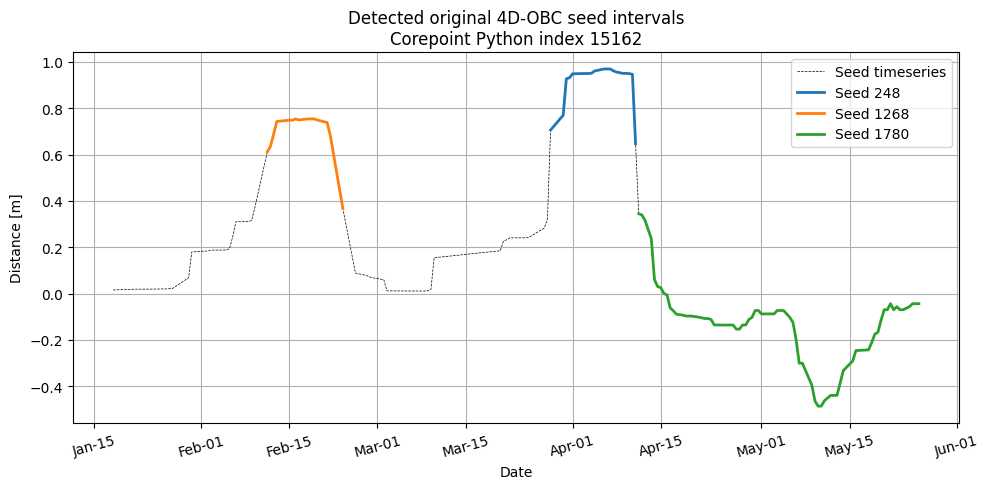


Number of seed intervals plotted for selected corepoint: 3


,seed_number_user,corepoint_index_python,corepoint_number_user,start_epoch,end_epoch,duration_epochs,start_time,end_time
0,1,15049,15050,61,79,19,2017-03-28 12:00:53,2017-04-11 00:00:49
1,2,15193,15194,21,35,15,2017-02-11 12:00:26,2017-02-23 12:00:59
2,3,15282,15283,21,35,15,2017-02-11 12:00:26,2017-02-23 12:00:59
3,4,15312,15313,21,35,15,2017-02-11 12:00:26,2017-02-23 12:00:59
4,5,15041,15042,61,79,19,2017-03-28 12:00:53,2017-04-11 00:00:49


,object_number_user,n_corepoints,start_epoch,start_time,end_epoch,end_time,duration_epochs
0,1,3834,61,2017-03-28 12:00:53,79,2017-04-11 00:00:49,19
1,2,5606,21,2017-02-11 12:00:26,35,2017-02-23 12:00:59,15
2,3,5383,63,2017-03-31 00:00:36,83,2017-04-13 00:00:28,21
3,4,5373,128,2017-05-06 12:00:23,142,2017-05-16 00:00:12,15
4,5,8909,62,2017-03-30 12:00:29,84,2017-04-13 12:00:35,23


,seed_mode,seed_corepoint_number_single,seed_range_start_user,seed_range_end_user,n_candidate_corepoints,window_width,minperiod,height_threshold,neighborhood_radius,min_segments,thresholds,n_detected_seeds,n_extracted_objects,elapsed_seconds
0,range,NaN,15000,15999,1000,14,2,0.05,1.0,10,"[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]",2348,17,27.598765


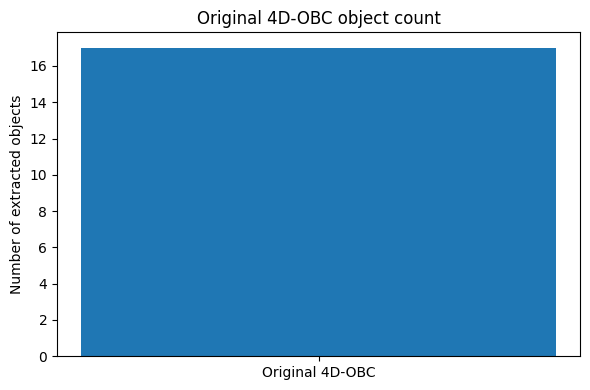


Cell 9 complete.


In [9]:
# ============================================================
# CELL 9 — ORIGINAL 4D-OBC SEED DETECTION + SEED VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------


SEED_MODE = "range" #"single", "range", "full"

# For SEED_MODE = "single"
SEED_COREPOINT_NUMBER = 15163

# For SEED_MODE = "range"
SEED_RANGE_START = 15000
SEED_RANGE_END = 15999

# CONSISTENT VISUALIZATION COREPOINT
PLOT_COREPOINT_INDEX = 15162

# 4D-OBC parameters
WINDOW_WIDTH = 14
MINPERIOD = 2
HEIGHT_THRESHOLD = 0.05
NEIGHBORHOOD_RADIUS = 1.0
MIN_SEGMENTS = 10
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


# ------------------------------------------------------------
# 2. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "corepoints",
    "timestamps_analysis"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run previous cells first."
        )

n_corepoints = analysis.corepoints.cloud.shape[0]

print("Number of available corepoints:", n_corepoints)


# ------------------------------------------------------------
# 3. VALIDATE SEED MODE
# ------------------------------------------------------------

valid_modes = ["single", "range", "full"]

if SEED_MODE not in valid_modes:
    raise ValueError(
        f"Invalid SEED_MODE='{SEED_MODE}'. "
        f"Use one of: {valid_modes}"
    )


# ------------------------------------------------------------
# 4. DEFINE CANDIDATE COREPOINTS
# ------------------------------------------------------------

if SEED_MODE == "single":

    if not isinstance(SEED_COREPOINT_NUMBER, int):
        raise ValueError("SEED_COREPOINT_NUMBER must be an integer.")

    if SEED_COREPOINT_NUMBER <= 0:
        raise ValueError(
            "\nInvalid corepoint number.\n"
            "Corepoint numbering starts from 1, not 0.\n\n"
            "Example:\n"
            "    SEED_COREPOINT_NUMBER = 15163"
        )

    if SEED_COREPOINT_NUMBER > n_corepoints:
        raise ValueError(
            f"SEED_COREPOINT_NUMBER={SEED_COREPOINT_NUMBER} exceeds "
            f"the number of available corepoints ({n_corepoints})."
        )

    cp_idx_sel = SEED_COREPOINT_NUMBER - 1
    seed_candidates = [cp_idx_sel]

    print("\nSeed mode: SINGLE")
    print(f"Selected user corepoint number: {SEED_COREPOINT_NUMBER}")
    print(f"Selected Python corepoint index: {cp_idx_sel}")


elif SEED_MODE == "range":

    if not isinstance(SEED_RANGE_START, int) or not isinstance(SEED_RANGE_END, int):
        raise ValueError("SEED_RANGE_START and SEED_RANGE_END must be integers.")

    if SEED_RANGE_START <= 0 or SEED_RANGE_END <= 0:
        raise ValueError(
            "\nInvalid seed range.\n"
            "Corepoint numbering starts from 1, not 0.\n\n"
            "Example:\n"
            "    SEED_RANGE_START = 1\n"
            "    SEED_RANGE_END   = 20"
        )

    if SEED_RANGE_END < SEED_RANGE_START:
        raise ValueError(
            f"SEED_RANGE_END ({SEED_RANGE_END}) must be greater than or equal to "
            f"SEED_RANGE_START ({SEED_RANGE_START})."
        )

    if SEED_RANGE_START > n_corepoints:
        raise ValueError(
            f"SEED_RANGE_START={SEED_RANGE_START} exceeds available "
            f"corepoints ({n_corepoints})."
        )

    if SEED_RANGE_END > n_corepoints:
        print(
            f"WARNING: SEED_RANGE_END={SEED_RANGE_END} exceeds "
            f"available corepoints ({n_corepoints})."
        )
        print(f"Resetting SEED_RANGE_END to {n_corepoints}.")
        SEED_RANGE_END = n_corepoints

    start_idx = SEED_RANGE_START - 1
    end_idx = SEED_RANGE_END

    seed_candidates = list(range(start_idx, end_idx))

    # CONSISTENT VISUALIZATION
    if PLOT_COREPOINT_INDEX not in seed_candidates:
        raise ValueError(
            f"Python corepoint index {PLOT_COREPOINT_INDEX} "
            "is not in the selected seed range.\n"
            "Adjust SEED_RANGE_START and SEED_RANGE_END."
        )

    cp_idx_sel = PLOT_COREPOINT_INDEX

    print("\nSeed mode: RANGE")
    print(f"User corepoint range: {SEED_RANGE_START} → {SEED_RANGE_END}")
    print(f"Python index range: {start_idx} → {end_idx - 1}")
    print(f"Number of candidate corepoints: {len(seed_candidates)}")
    print(f"Visualization corepoint Python index: {cp_idx_sel}")


else:

    seed_candidates = None

    cp_idx_sel = PLOT_COREPOINT_INDEX

    print("\nSeed mode: FULL")
    print("All corepoints will be used as seed candidates.")
    print("WARNING: This may take a long time.")
    print(f"Visualization corepoint Python index: {cp_idx_sel}")


# ------------------------------------------------------------
# 5. CONFIGURE ORIGINAL 4D-OBC ALGORITHM
# ------------------------------------------------------------

if seed_candidates is None:

    algo_original_4dobc = py4dgeo.RegionGrowingAlgorithm(
        window_width=WINDOW_WIDTH,
        minperiod=MINPERIOD,
        height_threshold=HEIGHT_THRESHOLD,
        neighborhood_radius=NEIGHBORHOOD_RADIUS,
        min_segments=MIN_SEGMENTS,
        thresholds=THRESHOLDS
    )

else:

    algo_original_4dobc = py4dgeo.RegionGrowingAlgorithm(
        window_width=WINDOW_WIDTH,
        minperiod=MINPERIOD,
        height_threshold=HEIGHT_THRESHOLD,
        neighborhood_radius=NEIGHBORHOOD_RADIUS,
        min_segments=MIN_SEGMENTS,
        thresholds=THRESHOLDS,
        seed_candidates=seed_candidates
    )

print("\nOriginal 4D-OBC algorithm configured.")


# ------------------------------------------------------------
# 6. CLEAR PREVIOUS SEEDS AND OBJECTS
# ------------------------------------------------------------

analysis.invalidate_results(
    seeds=True,
    objects=True,
    smoothed_distances=False
)

print("Previous seeds and objects cleared.")


# ------------------------------------------------------------
# 7. RUN ORIGINAL 4D-OBC EXTRACTION
# ------------------------------------------------------------

print("\nRunning original 4D-OBC extraction...")
start_time = time.time()

objects_original_4dobc = algo_original_4dobc.run(analysis)

elapsed = time.time() - start_time

print("\nOriginal 4D-OBC extraction complete.")
print(f"Elapsed time: {elapsed:.2f} seconds")


# ------------------------------------------------------------
# 8. STORE RESULTS
# ------------------------------------------------------------

original_4dobc_objects = objects_original_4dobc
original_4dobc_seeds = analysis.seeds

print("\nNumber of detected temporal seeds:")
print(len(original_4dobc_seeds))

print("\nNumber of extracted 4D-OBC objects:")
print(len(original_4dobc_objects))


# ------------------------------------------------------------
# 9. VISUALIZE SEED INTERVALS AT SELECTED COREPOINT
# ------------------------------------------------------------

seed_timeseries = analysis.smoothed_distances[cp_idx_sel]

plt.figure(figsize=(10, 5))

plt.plot(
    timestamps_analysis,
    seed_timeseries,
    c="black",
    linestyle="--",
    linewidth=0.5,
    label="Seed timeseries"
)

n_plotted_seeds = 0

for sid, example_seed in enumerate(analysis.seeds):

    seed_end = example_seed.end_epoch
    seed_start = example_seed.start_epoch
    seed_cp_idx = example_seed.index

    if seed_cp_idx != cp_idx_sel:
        continue

    plt.plot(
        timestamps_analysis[seed_start:seed_end + 1],
        seed_timeseries[seed_start:seed_end + 1],
        linewidth=2,
        label=f"Seed {sid}"
    )

    n_plotted_seeds += 1


import matplotlib.dates as mdates

dtFmt = mdates.DateFormatter("%b-%d")
plt.gca().xaxis.set_major_formatter(dtFmt)

plt.xlabel("Date")
plt.tick_params(axis="x", rotation=15)
plt.ylabel("Distance [m]")

plt.title(
    f"Detected original 4D-OBC seed intervals\n"
    f"Corepoint Python index {cp_idx_sel}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(
    f"\nNumber of seed intervals plotted for selected corepoint: "
    f"{n_plotted_seeds}"
)


# ------------------------------------------------------------
# 10. SUMMARIZE DETECTED SEEDS
# ------------------------------------------------------------

seed_records = []

for seed_id, seed in enumerate(original_4dobc_seeds, start=1):

    seed_records.append({
        "seed_number_user": seed_id,
        "corepoint_index_python": seed.index,
        "corepoint_number_user": seed.index + 1,
        "start_epoch": seed.start_epoch,
        "end_epoch": seed.end_epoch,
        "duration_epochs": seed.end_epoch - seed.start_epoch + 1,
        "start_time": timestamps_analysis[seed.start_epoch],
        "end_time": timestamps_analysis[seed.end_epoch]
    })

original_seed_summary = pd.DataFrame(seed_records)

display(original_seed_summary.head())

original_seed_summary.to_csv(
    TABLES_DIR / "original_4dobc_seed_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 11. SUMMARIZE EXTRACTED OBJECTS
# ------------------------------------------------------------

object_records = []

for obj_id, obj in enumerate(original_4dobc_objects, start=1):

    record = {
        "object_number_user": obj_id
    }

    if hasattr(obj, "indices"):
        record["n_corepoints"] = len(obj.indices)
    else:
        record["n_corepoints"] = np.nan

    if hasattr(obj, "start_epoch"):
        record["start_epoch"] = obj.start_epoch
        record["start_time"] = timestamps_analysis[obj.start_epoch]

    if hasattr(obj, "end_epoch"):
        record["end_epoch"] = obj.end_epoch
        record["end_time"] = timestamps_analysis[obj.end_epoch]

    if hasattr(obj, "start_epoch") and hasattr(obj, "end_epoch"):
        record["duration_epochs"] = obj.end_epoch - obj.start_epoch + 1

    object_records.append(record)

original_object_summary = pd.DataFrame(object_records)

display(original_object_summary.head())

original_object_summary.to_csv(
    TABLES_DIR / "original_4dobc_object_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 12. SAVE RUN CONFIGURATION
# ------------------------------------------------------------

run_config_original_4dobc = pd.DataFrame([{
    "seed_mode": SEED_MODE,
    "seed_corepoint_number_single": (
        SEED_COREPOINT_NUMBER if SEED_MODE == "single" else np.nan
    ),
    "seed_range_start_user": (
        SEED_RANGE_START if SEED_MODE == "range" else np.nan
    ),
    "seed_range_end_user": (
        SEED_RANGE_END if SEED_MODE == "range" else np.nan
    ),
    "n_candidate_corepoints": (
        n_corepoints if seed_candidates is None else len(seed_candidates)
    ),
    "window_width": WINDOW_WIDTH,
    "minperiod": MINPERIOD,
    "height_threshold": HEIGHT_THRESHOLD,
    "neighborhood_radius": NEIGHBORHOOD_RADIUS,
    "min_segments": MIN_SEGMENTS,
    "thresholds": str(THRESHOLDS),
    "n_detected_seeds": len(original_4dobc_seeds),
    "n_extracted_objects": len(original_4dobc_objects),
    "elapsed_seconds": elapsed
}])

display(run_config_original_4dobc)

run_config_original_4dobc.to_csv(
    TABLES_DIR / "original_4dobc_run_config.csv",
    index=False
)


# ------------------------------------------------------------
# 13. SIMPLE OBJECT COUNT PLOT
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))

plt.bar(
    ["Original 4D-OBC"],
    [len(original_4dobc_objects)]
)

plt.ylabel("Number of extracted objects")
plt.title("Original 4D-OBC object count")

plt.tight_layout()
plt.show()


print("\nCell 9 complete.")

Visualizing object number: 1
Python object index: 0
Object start epoch: 61
Object end epoch: 79
Object duration: 19
Epoch of interest: 70
Number of object corepoints: 3834
Seed corepoint Python index: 15162
Seed corepoint user number: 15163


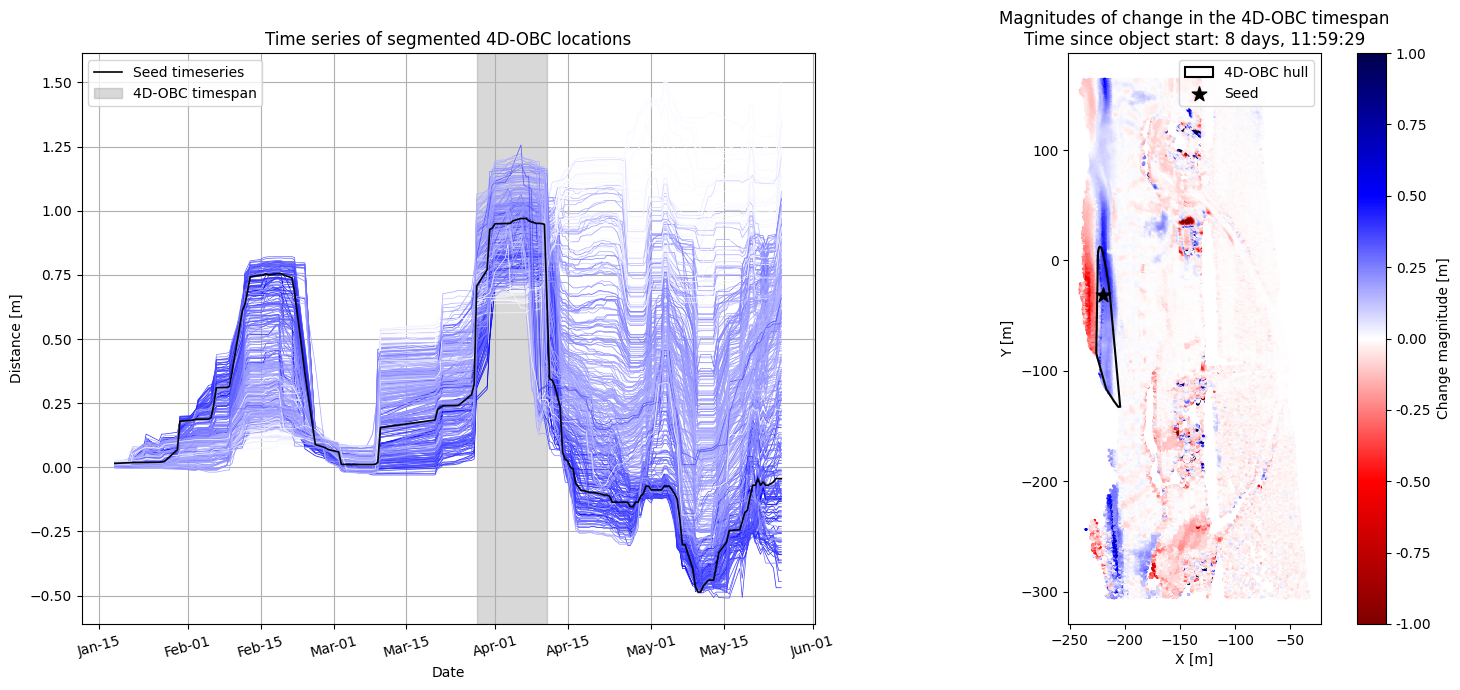

,object_number_user,object_index_python,seed_corepoint_index_python,seed_corepoint_number_user,start_epoch,end_epoch,duration_epochs,epoch_of_interest,n_corepoints,mean_change_magnitude,max_abs_change_magnitude
0,1,0,15162,15163,61,79,19,70,3834,0.219485,0.679449



Cell 10 complete: original 4D-OBC object visualized.


In [10]:
# ============================================================
# CELL 10 — VISUALIZE ORIGINAL 4D-OBC OBJECT PROPERTIES
# ============================================================

# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "original_4dobc_objects",
    "timestamps_analysis",
    "corepoints"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run Cell 9 first."
        )

if len(original_4dobc_objects) == 0:
    raise ValueError(
        "No 4D-OBC objects were extracted in Cell 9. "
        "Try another seed candidate or seed range."
    )


# ------------------------------------------------------------
# 2. Select object to visualize
# ------------------------------------------------------------

OBJECT_NUMBER = 1

if OBJECT_NUMBER <= 0:
    raise ValueError(
        "OBJECT_NUMBER must start from 1, not 0."
    )

if OBJECT_NUMBER > len(original_4dobc_objects):
    raise ValueError(
        f"OBJECT_NUMBER={OBJECT_NUMBER} exceeds the number of "
        f"available objects ({len(original_4dobc_objects)})."
    )

# Convert to Python index
sel_object_idx = OBJECT_NUMBER - 1

selected_object = original_4dobc_objects[sel_object_idx]

print(f"Visualizing object number: {OBJECT_NUMBER}")
print(f"Python object index: {sel_object_idx}")


# ------------------------------------------------------------
# 3. Extract object information
# ------------------------------------------------------------

idxs = selected_object.indices

start_epoch = int(selected_object.start_epoch)
end_epoch = int(selected_object.end_epoch)

epoch_of_interest = int((end_epoch - start_epoch) / 2 + start_epoch)

print("Object start epoch:", start_epoch)
print("Object end epoch:", end_epoch)
print("Object duration:", end_epoch - start_epoch + 1)
print("Epoch of interest:", epoch_of_interest)
print("Number of object corepoints:", len(idxs))


# ------------------------------------------------------------
# 4. FORCE CONSISTENT VISUALIZATION COREPOINT
# ------------------------------------------------------------

seed_cp_idx = 15162

print("Seed corepoint Python index:", seed_cp_idx)
print("Seed corepoint user number:", seed_cp_idx + 1)


# ------------------------------------------------------------
# 5. Compute change magnitude during object timespan
# ------------------------------------------------------------

distances_of_interest = analysis.smoothed_distances[:, epoch_of_interest]

magnitudes_of_interest = (
    analysis.smoothed_distances[:, epoch_of_interest]
    - analysis.smoothed_distances[:, start_epoch]
)


# ------------------------------------------------------------
# 6. Set color scale
# ------------------------------------------------------------

import matplotlib.colors as mcolors
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import matplotlib.dates as mdates

crange = 1.0

cmap = plt.get_cmap("seismic_r").copy()
norm = mcolors.CenteredNorm(halfrange=crange)
cmapvals = norm(magnitudes_of_interest)


# ------------------------------------------------------------
# 7. Create figure
# ------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(15, 7))

ax1, ax2 = axs


# ------------------------------------------------------------
# 8. Plot time series of object locations
# ------------------------------------------------------------

for idx in idxs[::10]:
    ax1.plot(
        timestamps_analysis,
        analysis.smoothed_distances[idx],
        c=cmap(cmapvals[idx]),
        linewidth=0.5
    )

# Plot seed time series
ax1.plot(
    timestamps_analysis,
    analysis.smoothed_distances[seed_cp_idx],
    c="black",
    linewidth=1.2,
    label="Seed timeseries"
)

# Shade the object timespan
ax1.axvspan(
    timestamps_analysis[start_epoch],
    timestamps_analysis[end_epoch],
    alpha=0.3,
    color="grey",
    label="4D-OBC timespan"
)

# Format date labels
dtFmt = mdates.DateFormatter("%b-%d")
ax1.xaxis.set_major_formatter(dtFmt)

ax1.legend()
ax1.set_title("Time series of segmented 4D-OBC locations")
ax1.set_xlabel("Date")
ax1.tick_params(axis="x", rotation=15)
ax1.set_ylabel("Distance [m]")
ax1.grid(True)


# ------------------------------------------------------------
# 9. Plot spatial object extent
# ------------------------------------------------------------

cloud = analysis.corepoints.cloud
subset_cloud = cloud[idxs, :2]

d = ax2.scatter(
    cloud[:, 0],
    cloud[:, 1],
    c=magnitudes_of_interest,
    cmap="seismic_r",
    vmin=-crange,
    vmax=crange,
    s=1
)

plt.colorbar(
    d,
    format="%.2f",
    label="Change magnitude [m]",
    ax=ax2
)

ax2.set_aspect("equal")


# ------------------------------------------------------------
# 10. Plot convex hull of 4D-OBC
# ------------------------------------------------------------


if subset_cloud.shape[0] >= 3:
    try:
        hull = ConvexHull(subset_cloud)

        ax2.add_patch(
            Polygon(
                subset_cloud[hull.vertices, 0:2],
                label="4D-OBC hull",
                fill=False,
                edgecolor="black",
                linewidth=1.5
            )
        )

    except Exception as e:
        print("Convex hull could not be created:")
        print(e)
else:
    print("Object has fewer than 3 points; convex hull skipped.")


# ------------------------------------------------------------
# 11. Plot seed location
# ------------------------------------------------------------

ax2.scatter(
    cloud[seed_cp_idx, 0],
    cloud[seed_cp_idx, 1],
    marker="*",
    c="black",
    s=120,
    label="Seed"
)


# ------------------------------------------------------------
# 12. Add plot labels
# ------------------------------------------------------------

time_delta = timestamps_analysis[epoch_of_interest] - timestamps_analysis[start_epoch]

ax2.set_title(
    "Magnitudes of change in the 4D-OBC timespan\n"
    f"Time since object start: {time_delta}"
)

ax2.set_xlabel("X [m]")
ax2.set_ylabel("Y [m]")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Save simple object metrics
# ------------------------------------------------------------

object_visualization_summary = pd.DataFrame([{
    "object_number_user": OBJECT_NUMBER,
    "object_index_python": sel_object_idx,
    "seed_corepoint_index_python": seed_cp_idx,
    "seed_corepoint_number_user": seed_cp_idx + 1,
    "start_epoch": start_epoch,
    "end_epoch": end_epoch,
    "duration_epochs": end_epoch - start_epoch + 1,
    "epoch_of_interest": epoch_of_interest,
    "n_corepoints": len(idxs),
    "mean_change_magnitude": float(np.nanmean(magnitudes_of_interest[idxs])),
    "max_abs_change_magnitude": float(np.nanmax(np.abs(magnitudes_of_interest[idxs])))
}])

display(object_visualization_summary)

object_visualization_summary.to_csv(
    TABLES_DIR / "original_4dobc_selected_object_visualization_summary.csv",
    index=False
)


print("\nCell 10 complete: original 4D-OBC object visualized.")

Kalman mode: range
Number of corepoints to process: 1000
Number of epochs: 159
First five time steps [days]: [2.49983796 2.49983796 0.50011574 0.50010417 1.99988426]

Running Kalman filtering...
Processed 100/1000 corepoints
Processed 200/1000 corepoints
Processed 300/1000 corepoints
Processed 400/1000 corepoints
Processed 500/1000 corepoints
Processed 600/1000 corepoints
Processed 700/1000 corepoints
Processed 800/1000 corepoints
Processed 900/1000 corepoints
Processed 1000/1000 corepoints

Kalman filtering complete.
Elapsed time: 36.52 seconds


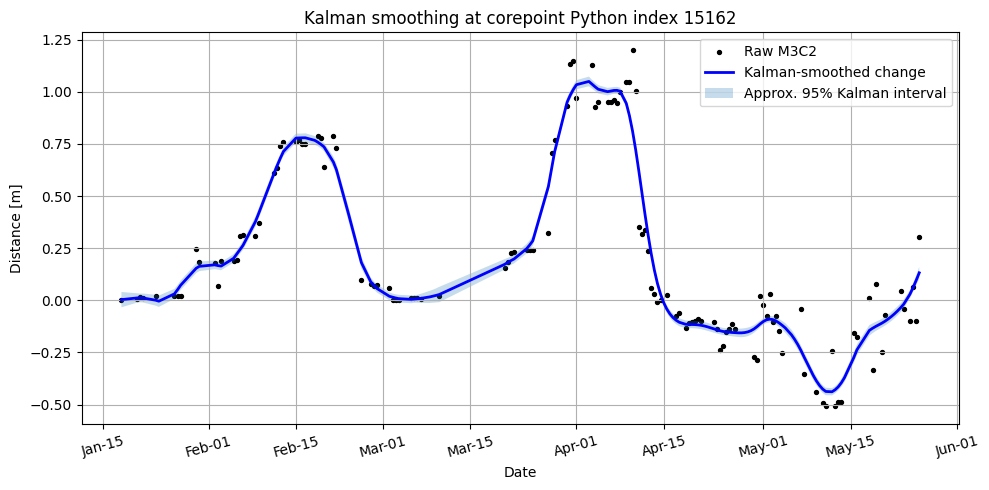

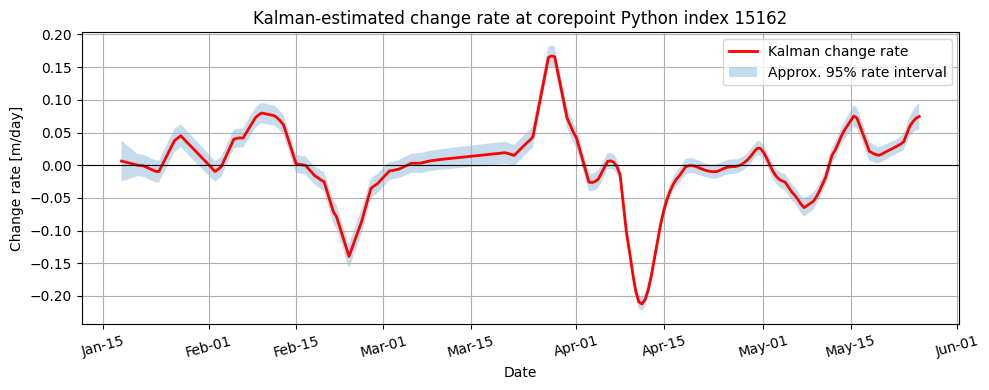

,kalman_mode,process_sigma,min_sigma_obs,n_processed_corepoints,elapsed_seconds
0,range,0.01,0.005,1000,36.517709



Cell 11 complete: Kalman filtering finished.


In [11]:
# ============================================================
# CELL 11 — KALMAN FILTERING OF M3C2 TIME SERIES
# ============================================================

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

KALMAN_MODE = "range"   # options: "single", "range", "full"

# User-friendly numbering starts from 1
KALMAN_COREPOINT_NUMBER = SEED_COREPOINT_NUMBER

SEED_RANGE_START = 15000
SEED_RANGE_END = 15999

KALMAN_RANGE_START = SEED_RANGE_START
KALMAN_RANGE_END = SEED_RANGE_END

# Kalman process noise
PROCESS_SIGMA = 0.01

# Minimum observation uncertainty to avoid division problems
MIN_SIGMA_OBS = 0.005


# ------------------------------------------------------------
# 2. Select corepoints to process
# ------------------------------------------------------------

n_corepoints, n_epochs = analysis.distances.shape

if KALMAN_MODE == "single":
    if KALMAN_COREPOINT_NUMBER <= 0:
        raise ValueError("Corepoint numbering starts from 1, not 0.")

    cp_idx = KALMAN_COREPOINT_NUMBER - 1
    kalman_indices = [cp_idx]

elif KALMAN_MODE == "range":
    if KALMAN_RANGE_START <= 0 or KALMAN_RANGE_END <= 0:
        raise ValueError("Corepoint numbering starts from 1, not 0.")

    start_idx = KALMAN_RANGE_START - 1
    end_idx = KALMAN_RANGE_END

    kalman_indices = list(range(start_idx, end_idx))

elif KALMAN_MODE == "full":
    kalman_indices = list(range(n_corepoints))

else:
    raise ValueError("KALMAN_MODE must be 'single', 'range', or 'full'.")

print("Kalman mode:", KALMAN_MODE)
print("Number of corepoints to process:", len(kalman_indices))


# ------------------------------------------------------------
# 3. Prepare time intervals
# ------------------------------------------------------------

# Convert py4dgeo timedeltas to days
kalman_times_days = np.array([
    td.total_seconds() / (60 * 60 * 24)
    for td in analysis.timedeltas
])

# Time step differences
dt_series = np.diff(kalman_times_days, prepend=kalman_times_days[0])

# Avoid zero dt at first epoch
if len(dt_series) > 1:
    dt_series[0] = dt_series[1]
else:
    dt_series[0] = 1.0

print("Number of epochs:", n_epochs)
print("First five time steps [days]:", dt_series[:5])


# ------------------------------------------------------------
# 4. Observation series and uncertainty proxy
# ------------------------------------------------------------

m3c2_series = analysis.distances

# Use LoD as uncertainty proxy
lod_series = analysis.uncertainties["lodetection"]

# Convert LoD approximately to sigma.
sigma_obs_series = np.maximum(lod_series / 1.96, MIN_SIGMA_OBS)


# ------------------------------------------------------------
# 5. Kalman smoother function
# ------------------------------------------------------------

def kalman_smooth_m3c2_series(z, sigma_obs, dt_series, process_sigma=0.01):
    """
    Apply Kalman filtering + RTS smoothing to one M3C2 time series.

    State vector:
        x = [change, change_rate]

    Parameters
    ----------
    z : array
        M3C2 distance time series.
    sigma_obs : array
        Observation uncertainty proxy.
    dt_series : array
        Time step lengths in days.
    process_sigma : float
        Process noise controlling smoothness/responsiveness.

    Returns
    -------
    smooth_change : array
        Kalman-smoothed change values.
    smooth_rate : array
        Kalman-estimated change rates.
    smooth_sigma_change : array
        Estimated uncertainty of smoothed change.
    smooth_sigma_rate : array
        Estimated uncertainty of change rate.
    """

    n = len(z)

    xs = np.full((n, 2), np.nan)
    Ps = np.full((n, 2, 2), np.nan)

    valid = np.isfinite(z)

    if np.sum(valid) < 2:
        return (
            np.full(n, np.nan),
            np.full(n, np.nan),
            np.full(n, np.nan),
            np.full(n, np.nan)
        )

    first_valid = np.where(valid)[0][0]

    kf = KalmanFilter(dim_x=2, dim_z=1)

    kf.x = np.array([z[first_valid], 0.0])
    kf.P = np.eye(2) * 1.0
    kf.H = np.array([[1.0, 0.0]])

    for t in range(n):
        dt = float(dt_series[t])

        kf.F = np.array([
            [1.0, dt],
            [0.0, 1.0]
        ])

        q = process_sigma ** 2
        kf.Q = np.array([
            [0.25 * dt**4, 0.5 * dt**3],
            [0.5 * dt**3, dt**2]
        ]) * q

        kf.predict()

        if np.isfinite(z[t]):
            kf.R = np.array([[sigma_obs[t] ** 2]])
            kf.update(np.array([z[t]]))

        xs[t] = kf.x
        Ps[t] = kf.P

    # RTS smoother
    x_smooth = xs.copy()
    P_smooth = Ps.copy()

    for t in range(n - 2, -1, -1):
        dt = float(dt_series[t + 1])

        F = np.array([
            [1.0, dt],
            [0.0, 1.0]
        ])

        q = process_sigma ** 2
        Q = np.array([
            [0.25 * dt**4, 0.5 * dt**3],
            [0.5 * dt**3, dt**2]
        ]) * q

        P_pred = F @ Ps[t] @ F.T + Q

        try:
            C = Ps[t] @ F.T @ np.linalg.inv(P_pred)

            x_smooth[t] = xs[t] + C @ (
                x_smooth[t + 1] - F @ xs[t]
            )

            P_smooth[t] = Ps[t] + C @ (
                P_smooth[t + 1] - P_pred
            ) @ C.T

        except np.linalg.LinAlgError:
            continue

    smooth_change = x_smooth[:, 0]
    smooth_rate = x_smooth[:, 1]

    smooth_sigma_change = np.sqrt(
        np.clip(P_smooth[:, 0, 0], 0, None)
    )

    smooth_sigma_rate = np.sqrt(
        np.clip(P_smooth[:, 1, 1], 0, None)
    )

    return (
        smooth_change,
        smooth_rate,
        smooth_sigma_change,
        smooth_sigma_rate
    )


# ------------------------------------------------------------
# 6. Allocate full output arrays
# ------------------------------------------------------------

kalman_change = np.full_like(m3c2_series, np.nan, dtype=float)
kalman_rate = np.full_like(m3c2_series, np.nan, dtype=float)
kalman_sigma_change = np.full_like(m3c2_series, np.nan, dtype=float)
kalman_sigma_rate = np.full_like(m3c2_series, np.nan, dtype=float)


# ------------------------------------------------------------
# 7. Run Kalman filtering
# ------------------------------------------------------------

print("\nRunning Kalman filtering...")
start_time = time.time()

for counter, idx in enumerate(kalman_indices, start=1):
    (
        kalman_change[idx],
        kalman_rate[idx],
        kalman_sigma_change[idx],
        kalman_sigma_rate[idx]
    ) = kalman_smooth_m3c2_series(
        z=m3c2_series[idx],
        sigma_obs=sigma_obs_series[idx],
        dt_series=dt_series,
        process_sigma=PROCESS_SIGMA
    )

    if counter % 100 == 0 or counter == len(kalman_indices):
        print(f"Processed {counter}/{len(kalman_indices)} corepoints")

elapsed = time.time() - start_time

print("\nKalman filtering complete.")
print(f"Elapsed time: {elapsed:.2f} seconds")


# ------------------------------------------------------------
# 8. Plot raw M3C2 vs Kalman result for selected corepoint
# ------------------------------------------------------------

PLOT_COREPOINT_INDEX = 15162

if PLOT_COREPOINT_INDEX not in kalman_indices:
    raise ValueError(
        f"Python corepoint index {PLOT_COREPOINT_INDEX} was not processed. "
        "Adjust your Kalman range."
    )

plot_idx = PLOT_COREPOINT_INDEX

plt.figure(figsize=(10, 5))

plt.scatter(
    timestamps_analysis,
    m3c2_series[plot_idx],
    s=8,
    color="black",
    label="Raw M3C2"
)

plt.plot(
    timestamps_analysis,
    kalman_change[plot_idx],
    color="blue",
    linewidth=2,
    label="Kalman-smoothed change"
)

plt.fill_between(
    timestamps_analysis,
    kalman_change[plot_idx] - 1.96 * kalman_sigma_change[plot_idx],
    kalman_change[plot_idx] + 1.96 * kalman_sigma_change[plot_idx],
    alpha=0.25,
    label="Approx. 95% Kalman interval"
)

dtFmt = mdates.DateFormatter("%b-%d")
plt.gca().xaxis.set_major_formatter(dtFmt)

plt.xlabel("Date")
plt.tick_params(axis="x", rotation=15)
plt.ylabel("Distance [m]")
plt.title(f"Kalman smoothing at corepoint Python index {plot_idx}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Plot Kalman change rate
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    timestamps_analysis,
    kalman_rate[plot_idx],
    color="red",
    linewidth=2,
    label="Kalman change rate"
)

plt.fill_between(
    timestamps_analysis,
    kalman_rate[plot_idx] - 1.96 * kalman_sigma_rate[plot_idx],
    kalman_rate[plot_idx] + 1.96 * kalman_sigma_rate[plot_idx],
    alpha=0.25,
    label="Approx. 95% rate interval"
)

plt.axhline(0, color="black", linewidth=0.8)

plt.gca().xaxis.set_major_formatter(dtFmt)
plt.xlabel("Date")
plt.tick_params(axis="x", rotation=15)
plt.ylabel("Change rate [m/day]")
plt.title(f"Kalman-estimated change rate at corepoint Python index {plot_idx}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Save Kalman outputs
# ------------------------------------------------------------

np.save(RESULTS_DIR / "kalman_change.npy", kalman_change)
np.save(RESULTS_DIR / "kalman_rate.npy", kalman_rate)
np.save(RESULTS_DIR / "kalman_sigma_change.npy", kalman_sigma_change)
np.save(RESULTS_DIR / "kalman_sigma_rate.npy", kalman_sigma_rate)

kalman_config = pd.DataFrame([{
    "kalman_mode": KALMAN_MODE,
    "process_sigma": PROCESS_SIGMA,
    "min_sigma_obs": MIN_SIGMA_OBS,
    "n_processed_corepoints": len(kalman_indices),
    "elapsed_seconds": elapsed
}])

display(kalman_config)

kalman_config.to_csv(
    TABLES_DIR / "kalman_filtering_config.csv",
    index=False
)

print("\nCell 11 complete: Kalman filtering finished.")

Kalman seed detection mode: processed
Detection signals: ['magnitude', 'rate']
Active downstream signal: magnitude
Seed direction: both
Minimum seed duration: 10 epochs
Minimum seed magnitude: 0.05 m
Formation-start extension: True
Baseline tolerance: 0.02
Maximum extension: 45 epochs
Number of corepoints checked: 1000

Running Kalman seed detection using: magnitude

Number of Kalman-detected seed intervals (magnitude):
3117


,corepoint_index_python,corepoint_number_user,start_epoch,end_epoch,duration_epochs,start_time,end_time,raw_significant_start_epoch,raw_significant_end_epoch,raw_significant_duration_epochs,...,mean_rate_sigma,mean_change_lod,mean_rate_lod,seed_detection_method,seed_direction_setting,formation_baseline_tolerance,formation_baseline_sigma_factor,max_formation_extension_epochs,min_extension_slope,seed_rank
0,15175,15176,49,86,38,2017-03-09 00:00:36,2017-04-14 12:00:52,52,86,35,...,0.007039,0.021886,0.013797,magnitude,both,0.02,1.0,45,0.001,1
1,15095,15096,44,86,43,2017-03-05 12:00:32,2017-04-14 12:00:52,45,86,42,...,0.007085,0.021595,0.013887,magnitude,both,0.02,1.0,45,0.001,2
2,15084,15085,44,86,43,2017-03-05 12:00:32,2017-04-14 12:00:52,45,86,42,...,0.007092,0.021728,0.013899,magnitude,both,0.02,1.0,45,0.001,3
3,15067,15068,47,86,40,2017-03-07 00:00:58,2017-04-14 12:00:52,52,86,35,...,0.007081,0.021923,0.013878,magnitude,both,0.02,1.0,45,0.001,4
4,15006,15007,51,86,36,2017-03-10 00:00:53,2017-04-14 12:00:52,52,86,35,...,0.006976,0.021205,0.013673,magnitude,both,0.02,1.0,45,0.001,5


Combined Cell 12 figure saved for magnitude:
figures\cell12_kalman_seed_detection\cell12_kalman_seed_detection_magnitude_corepoint_15162.png


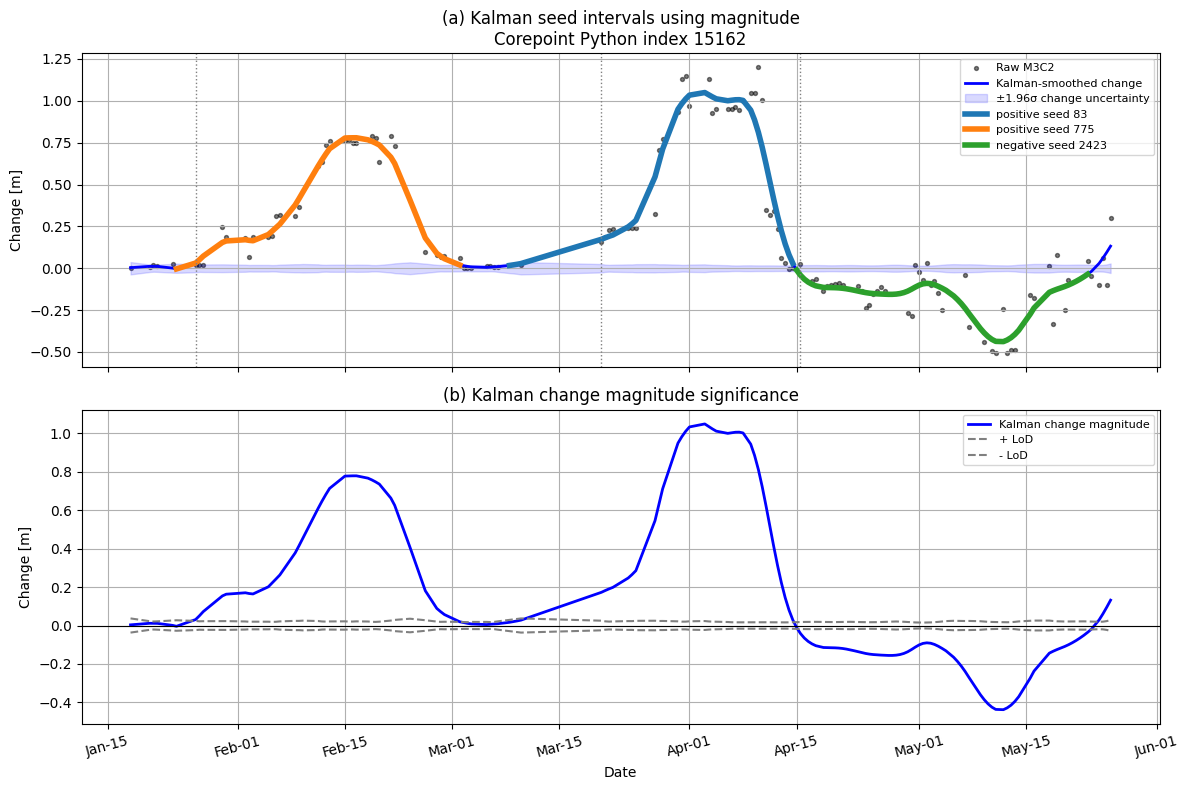


Running Kalman seed detection using: rate

Number of Kalman-detected seed intervals (rate):
3719


,corepoint_index_python,corepoint_number_user,start_epoch,end_epoch,duration_epochs,start_time,end_time,raw_significant_start_epoch,raw_significant_end_epoch,raw_significant_duration_epochs,...,mean_rate_sigma,mean_change_lod,mean_rate_lod,seed_detection_method,seed_direction_setting,formation_baseline_tolerance,formation_baseline_sigma_factor,max_formation_extension_epochs,min_extension_slope,seed_rank
0,15084,15085,56,65,10,2017-03-24 00:00:31,2017-04-01 00:00:52,56,65,10,...,0.008250,0.024427,0.016170,rate,both,0.02,1.0,45,NaN,1
1,15095,15096,56,65,10,2017-03-24 00:00:31,2017-04-01 00:00:52,56,65,10,...,0.008268,0.024519,0.016204,rate,both,0.02,1.0,45,NaN,2
2,15175,15176,56,65,10,2017-03-24 00:00:31,2017-04-01 00:00:52,56,65,10,...,0.008237,0.023890,0.016145,rate,both,0.02,1.0,45,NaN,3
3,15137,15138,52,65,14,2017-03-20 12:00:31,2017-04-01 00:00:52,52,65,14,...,0.008308,0.023989,0.016285,rate,both,0.02,1.0,45,NaN,4
4,15067,15068,52,65,14,2017-03-20 12:00:31,2017-04-01 00:00:52,52,65,14,...,0.008298,0.023873,0.016264,rate,both,0.02,1.0,45,NaN,5


Combined Cell 12 figure saved for rate:
figures\cell12_kalman_seed_detection\cell12_kalman_seed_detection_rate_corepoint_15162.png


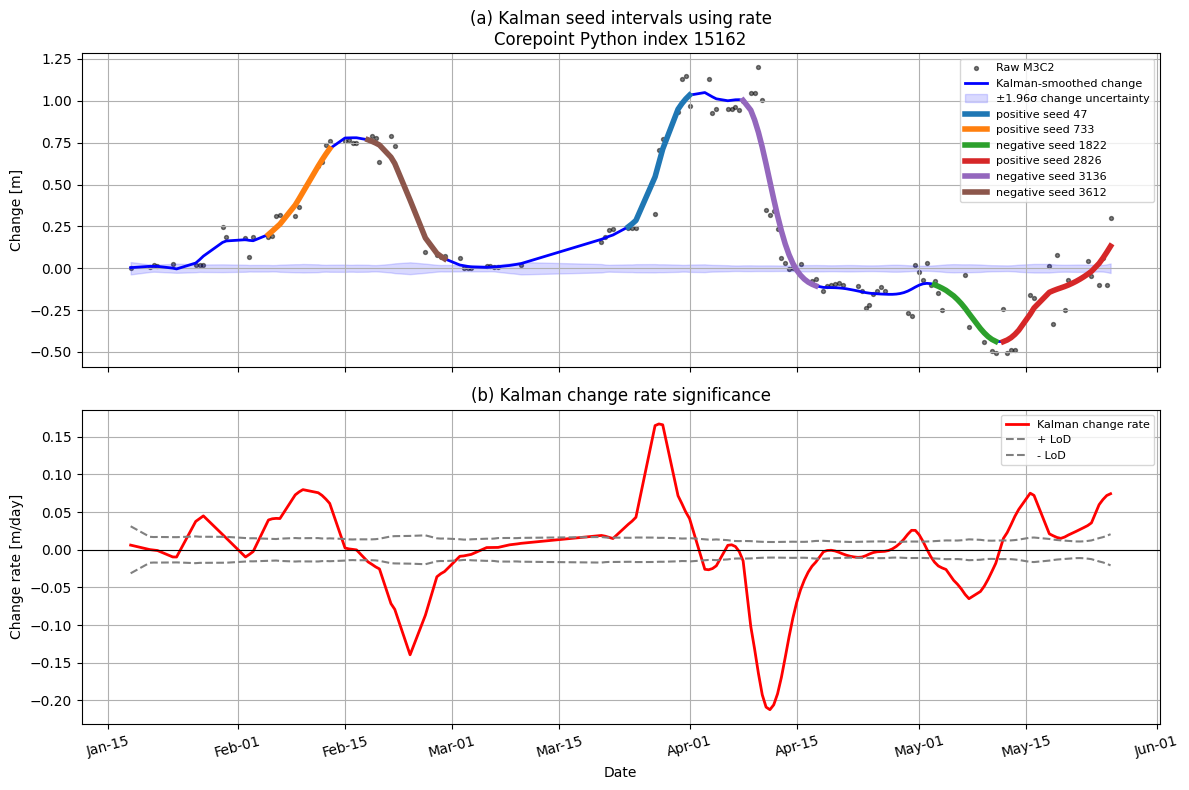

,kalman_seed_mode,kalman_detection_signal,seed_direction,z_threshold,min_seed_duration_epochs,min_seed_magnitude,formation_start_extension_enabled,formation_baseline_tolerance,formation_baseline_sigma_factor,max_formation_extension_epochs,min_extension_slope,n_checked_corepoints,n_detected_kalman_seed_intervals,n_extended_seed_intervals,mean_extension_epochs,plot_corepoint_index,combined_figure_path
0,processed,magnitude,both,1.96,10,0.05,True,0.02,1.0,45,0.001,1000,3117,2646,1.340712,15162,figures\cell12_kalman_seed_detection\cell12_ka...
1,processed,rate,both,1.96,10,0.05,False,0.02,1.0,45,NaN,1000,3719,0,0.000000,15162,figures\cell12_kalman_seed_detection\cell12_ka...



Saved magnitude seed table to:
tables\kalman_seed_table_magnitude.csv

Saved rate seed table to:
tables\kalman_seed_table_rate.csv

Active downstream seed table:
magnitude
Active downstream seeds: 3117

Cell 12 complete: Kalman-based seed detection finished for both magnitude and rate.


In [12]:
# ============================================================
# CELL 12 — KALMAN-BASED SEED DETECTION AND VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# 0. USER SETTINGS
# ------------------------------------------------------------

KALMAN_SEED_MODE = "processed"   # options: "processed", "single", "range"
KALMAN_SEED_COREPOINT_NUMBER = 15163
KALMAN_SEED_RANGE_START = 15000
KALMAN_SEED_RANGE_END = 15999

SEED_DIRECTION = "both"          # options: "positive", "negative", "both"

KALMAN_DETECTION_SIGNALS = ["magnitude", "rate"]
ACTIVE_SIGNAL_FOR_DOWNSTREAM = "magnitude"
# options: "magnitude", "rate"

Z_THRESHOLD = 1.96
MIN_SEED_DURATION = 10
MIN_SEED_MAGNITUDE = 0.05

# Main fix:
EXTEND_TO_FORMATION_START = True

# Formation-start extension controls
FORMATION_BASELINE_TOLERANCE = 0.02
FORMATION_BASELINE_SIGMA_FACTOR = 1.0
MAX_FORMATION_EXTENSION_EPOCHS = 45

# Optional slope guard; keep small.
MIN_EXTENSION_SLOPE = 0.001

PLOT_COREPOINT_INDEX = 15162
SAVE_CELL12_FIGURES = True

cell12_fig_dir = FIGURES_DIR / "cell12_kalman_seed_detection"
cell12_fig_dir.mkdir(exist_ok=True, parents=True)


# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "kalman_change",
    "kalman_rate",
    "kalman_sigma_change",
    "kalman_sigma_rate",
    "timestamps_analysis",
    "analysis"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(f"{obj} is not defined. Please run Cell 11 first.")

n_corepoints, n_epochs = kalman_change.shape


# ------------------------------------------------------------
# 2. SELECT COREPOINTS
# ------------------------------------------------------------

if KALMAN_SEED_MODE == "processed":

    if "kalman_indices" not in globals():
        raise ValueError("kalman_indices not found. Please run Cell 11 first.")

    seed_detection_indices = list(kalman_indices)

elif KALMAN_SEED_MODE == "single":

    if KALMAN_SEED_COREPOINT_NUMBER <= 0:
        raise ValueError("Corepoint numbering starts from 1, not 0.")

    idx = KALMAN_SEED_COREPOINT_NUMBER - 1

    if idx >= n_corepoints:
        raise ValueError(
            f"KALMAN_SEED_COREPOINT_NUMBER={KALMAN_SEED_COREPOINT_NUMBER} "
            f"exceeds available corepoints ({n_corepoints})."
        )

    seed_detection_indices = [idx]

elif KALMAN_SEED_MODE == "range":

    if KALMAN_SEED_RANGE_START <= 0 or KALMAN_SEED_RANGE_END <= 0:
        raise ValueError("Corepoint numbering starts from 1, not 0.")

    start_idx = KALMAN_SEED_RANGE_START - 1
    end_idx = min(KALMAN_SEED_RANGE_END, n_corepoints)

    seed_detection_indices = list(range(start_idx, end_idx))

else:
    raise ValueError("KALMAN_SEED_MODE must be 'processed', 'single', or 'range'.")


print("Kalman seed detection mode:", KALMAN_SEED_MODE)
print("Detection signals:", KALMAN_DETECTION_SIGNALS)
print("Active downstream signal:", ACTIVE_SIGNAL_FOR_DOWNSTREAM)
print("Seed direction:", SEED_DIRECTION)
print("Minimum seed duration:", MIN_SEED_DURATION, "epochs")
print("Minimum seed magnitude:", MIN_SEED_MAGNITUDE, "m")
print("Formation-start extension:", EXTEND_TO_FORMATION_START)
print("Baseline tolerance:", FORMATION_BASELINE_TOLERANCE)
print("Maximum extension:", MAX_FORMATION_EXTENSION_EPOCHS, "epochs")
print("Number of corepoints checked:", len(seed_detection_indices))


# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------

def extract_true_intervals(boolean_series):
    active = np.where(boolean_series)[0]

    if len(active) == 0:
        return []

    intervals = []
    start = active[0]
    previous = active[0]

    for t in active[1:]:

        if t == previous + 1:
            previous = t

        else:
            intervals.append((start, previous))
            start = t
            previous = t

    intervals.append((start, previous))
    return intervals


def get_seed_masks_for_signal(change, change_sigma, rate, rate_sigma, detection_signal):

    if detection_signal == "magnitude":
        signal = change
        sigma = change_sigma

    elif detection_signal == "rate":
        signal = rate
        sigma = rate_sigma

    else:
        raise ValueError("detection_signal must be 'magnitude' or 'rate'.")

    lod = Z_THRESHOLD * sigma

    selected_masks = []

    if SEED_DIRECTION in ["positive", "both"]:
        selected_masks.append(("positive", signal > lod))

    if SEED_DIRECTION in ["negative", "both"]:
        selected_masks.append(("negative", signal < -lod))

    if SEED_DIRECTION not in ["positive", "negative", "both"]:
        raise ValueError("SEED_DIRECTION must be 'positive', 'negative', or 'both'.")

    return selected_masks


def find_formation_start(
    change,
    change_sigma,
    raw_start_epoch,
    direction,
    earliest_allowed_epoch
):
    """
    Find the formation-start epoch before the statistically significant interval.

    Main idea:
    - raw_start_epoch is where the signal first exceeds the LoD.
    - formation start should be earlier, where the signal begins leaving
      near-zero / uncertainty-level baseline.
    - The returned epoch is written directly into start_epoch.
    """

    if not EXTEND_TO_FORMATION_START:
        return raw_start_epoch

    if raw_start_epoch <= 0:
        return raw_start_epoch

    search_start = max(
        earliest_allowed_epoch,
        raw_start_epoch - MAX_FORMATION_EXTENSION_EPOCHS
    )

    search_end = raw_start_epoch

    candidate_epochs = np.arange(search_start, search_end + 1)

    if len(candidate_epochs) == 0:
        return raw_start_epoch

    signal_segment = change[candidate_epochs]
    sigma_segment = change_sigma[candidate_epochs]

    baseline_threshold = np.maximum(
        FORMATION_BASELINE_TOLERANCE,
        FORMATION_BASELINE_SIGMA_FACTOR * sigma_segment
    )

    # Same-sign mask prevents crossing into the previous opposite event.
    if direction == "positive":
        same_sign_mask = signal_segment >= -FORMATION_BASELINE_TOLERANCE
        baseline_mask = np.abs(signal_segment) <= baseline_threshold

    elif direction == "negative":
        same_sign_mask = signal_segment <= FORMATION_BASELINE_TOLERANCE
        baseline_mask = np.abs(signal_segment) <= baseline_threshold

    else:
        return raw_start_epoch

    valid_baseline_epochs = candidate_epochs[
        baseline_mask & same_sign_mask
    ]

    # Preferred rule:
    # use the last near-baseline epoch before significance.
    if len(valid_baseline_epochs) > 0:
        extended_start = int(valid_baseline_epochs[-1])

    else:
        # Fallback:
        # use local near-zero extremum in the search window.
        if direction == "positive":
            extended_start = int(candidate_epochs[np.nanargmin(np.abs(signal_segment))])
        else:
            extended_start = int(candidate_epochs[np.nanargmin(np.abs(signal_segment))])

    # Optional slope sanity check:
    # avoid extending into a completely unrelated earlier episode.
    if extended_start < raw_start_epoch - 1:

        slopes = np.diff(change[extended_start:raw_start_epoch + 1])

        if direction == "positive":
            positive_trend_fraction = np.mean(slopes >= -MIN_EXTENSION_SLOPE)

            if positive_trend_fraction < 0.50:
                # If trend is not sufficiently consistent, keep conservative start.
                extended_start = raw_start_epoch

        elif direction == "negative":
            negative_trend_fraction = np.mean(slopes <= MIN_EXTENSION_SLOPE)

            if negative_trend_fraction < 0.50:
                extended_start = raw_start_epoch

    return int(max(earliest_allowed_epoch, min(extended_start, raw_start_epoch)))


def detect_kalman_seeds_for_signal(detection_signal):

    kalman_seed_records = []

    for cp_idx in seed_detection_indices:

        change = kalman_change[cp_idx]
        rate = kalman_rate[cp_idx]

        change_sigma = kalman_sigma_change[cp_idx]
        rate_sigma = kalman_sigma_rate[cp_idx]

        if np.all(np.isnan(change)):
            continue

        seed_masks = get_seed_masks_for_signal(
            change=change,
            change_sigma=change_sigma,
            rate=rate,
            rate_sigma=rate_sigma,
            detection_signal=detection_signal
        )

        for direction, seed_mask in seed_masks:

            raw_intervals = extract_true_intervals(seed_mask)

            for interval_id, (raw_start_epoch, raw_end_epoch) in enumerate(raw_intervals):

                raw_start_epoch = int(raw_start_epoch)
                raw_end_epoch = int(raw_end_epoch)

                if interval_id == 0:
                    earliest_allowed_epoch = 0
                else:
                    previous_raw_end = int(raw_intervals[interval_id - 1][1])
                    earliest_allowed_epoch = previous_raw_end + 1

                # ------------------------------------------------
                # CRITICAL FIX:
                # ------------------------------------------------
                if detection_signal == "magnitude":

                    start_epoch = find_formation_start(
                        change=change,
                        change_sigma=change_sigma,
                        raw_start_epoch=raw_start_epoch,
                        direction=direction,
                        earliest_allowed_epoch=earliest_allowed_epoch
                    )

                else:
                    # Rate seeds remain based on rate significance.
                    start_epoch = raw_start_epoch

                end_epoch = raw_end_epoch

                duration = end_epoch - start_epoch + 1

                if duration < MIN_SEED_DURATION:
                    continue

                interval_change = change[start_epoch:end_epoch + 1]
                interval_rate = rate[start_epoch:end_epoch + 1]
                interval_change_sigma = change_sigma[start_epoch:end_epoch + 1]
                interval_rate_sigma = rate_sigma[start_epoch:end_epoch + 1]

                raw_interval_change = change[raw_start_epoch:raw_end_epoch + 1]
                raw_interval_rate = rate[raw_start_epoch:raw_end_epoch + 1]

                if direction == "positive":
                    event_magnitude = float(np.nanmax(interval_change))
                    peak_epoch_local = int(np.nanargmax(interval_change))

                elif direction == "negative":
                    event_magnitude = float(abs(np.nanmin(interval_change)))
                    peak_epoch_local = int(np.nanargmin(interval_change))

                else:
                    continue

                if event_magnitude < MIN_SEED_MAGNITUDE:
                    continue

                peak_epoch = start_epoch + peak_epoch_local

                net_change = change[end_epoch] - change[start_epoch]
                abs_net_change = abs(net_change)

                mean_change_lod = Z_THRESHOLD * np.nanmean(interval_change_sigma)
                mean_rate_lod = Z_THRESHOLD * np.nanmean(interval_rate_sigma)

                kalman_seed_records.append({
                    "corepoint_index_python": int(cp_idx),
                    "corepoint_number_user": int(cp_idx + 1),

                    # Corrected/usable timing
                    "start_epoch": int(start_epoch),
                    "end_epoch": int(end_epoch),
                    "duration_epochs": int(duration),
                    "start_time": timestamps_analysis[start_epoch],
                    "end_time": timestamps_analysis[end_epoch],

                    # Raw statistical timing before formation extension
                    "raw_significant_start_epoch": int(raw_start_epoch),
                    "raw_significant_end_epoch": int(raw_end_epoch),
                    "raw_significant_duration_epochs": int(raw_end_epoch - raw_start_epoch + 1),
                    "raw_significant_start_time": timestamps_analysis[raw_start_epoch],
                    "raw_significant_end_time": timestamps_analysis[raw_end_epoch],

                    # Extension metadata
                    "formation_start_extension_applied": bool(start_epoch != raw_start_epoch),
                    "formation_extension_epochs": int(raw_start_epoch - start_epoch),
                    "formation_start_extension_enabled": (
                        EXTEND_TO_FORMATION_START
                        if detection_signal == "magnitude"
                        else False
                    ),

                    "direction": direction,
                    "peak_epoch": int(peak_epoch),
                    "peak_time": timestamps_analysis[peak_epoch],

                    "event_magnitude": float(event_magnitude),
                    "net_change": float(net_change),
                    "abs_net_change": float(abs_net_change),

                    "mean_change": float(np.nanmean(interval_change)),
                    "max_abs_change": float(np.nanmax(np.abs(interval_change))),
                    "mean_rate": float(np.nanmean(interval_rate)),
                    "max_abs_rate": float(np.nanmax(np.abs(interval_rate))),

                    "raw_mean_change": float(np.nanmean(raw_interval_change)),
                    "raw_max_abs_change": float(np.nanmax(np.abs(raw_interval_change))),
                    "raw_mean_rate": float(np.nanmean(raw_interval_rate)),
                    "raw_max_abs_rate": float(np.nanmax(np.abs(raw_interval_rate))),

                    "mean_change_sigma": float(np.nanmean(interval_change_sigma)),
                    "mean_rate_sigma": float(np.nanmean(interval_rate_sigma)),
                    "mean_change_lod": float(mean_change_lod),
                    "mean_rate_lod": float(mean_rate_lod),

                    "seed_detection_method": detection_signal,
                    "seed_direction_setting": SEED_DIRECTION,
                    "formation_baseline_tolerance": FORMATION_BASELINE_TOLERANCE,
                    "formation_baseline_sigma_factor": FORMATION_BASELINE_SIGMA_FACTOR,
                    "max_formation_extension_epochs": MAX_FORMATION_EXTENSION_EPOCHS,
                    "min_extension_slope": (
                        MIN_EXTENSION_SLOPE
                        if detection_signal == "magnitude"
                        else np.nan
                    )
                })

    seed_table = pd.DataFrame(kalman_seed_records)

    if len(seed_table) > 0:

        seed_table = seed_table.sort_values(
            ["event_magnitude", "duration_epochs"],
            ascending=False
        ).reset_index(drop=True)

        seed_table["seed_rank"] = np.arange(1, len(seed_table) + 1)

    return seed_table


def plot_combined_seed_figure(seed_table, detection_signal):

    if PLOT_COREPOINT_INDEX in seed_detection_indices:

        plot_cp_idx = PLOT_COREPOINT_INDEX

    else:

        print(
            f"Warning: Python corepoint index {PLOT_COREPOINT_INDEX} "
            "was not processed in Cell 11."
        )

        if len(seed_table) > 0:
            plot_cp_idx = int(seed_table.iloc[0]["corepoint_index_python"])
            print("Using first detected seed corepoint instead:", plot_cp_idx)
        else:
            plot_cp_idx = int(seed_detection_indices[0])
            print("No seeds detected. Using first processed corepoint instead:", plot_cp_idx)

    plot_seed_table = seed_table[
        seed_table["corepoint_index_python"] == plot_cp_idx
    ].copy()

    import matplotlib.dates as mdates
    dtFmt = mdates.DateFormatter("%b-%d")

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(12, 8),
        sharex=True
    )

    # --------------------------------------------------------
    # TOP: Seed intervals on change curve
    # --------------------------------------------------------

    ax1.scatter(
        timestamps_analysis,
        analysis.distances[plot_cp_idx],
        s=8,
        color="black",
        alpha=0.5,
        label="Raw M3C2"
    )

    ax1.plot(
        timestamps_analysis,
        kalman_change[plot_cp_idx],
        color="blue",
        linewidth=2,
        label="Kalman-smoothed change"
    )

    upper_change = Z_THRESHOLD * kalman_sigma_change[plot_cp_idx]
    lower_change = -Z_THRESHOLD * kalman_sigma_change[plot_cp_idx]

    ax1.fill_between(
        timestamps_analysis,
        lower_change,
        upper_change,
        color="blue",
        alpha=0.15,
        label=f"±{Z_THRESHOLD:.2f}σ change uncertainty"
    )

    if len(plot_seed_table) > 0:

        for _, row in plot_seed_table.iterrows():

            s = int(row["start_epoch"])
            e = int(row["end_epoch"])

            ax1.plot(
                timestamps_analysis[s:e + 1],
                kalman_change[plot_cp_idx, s:e + 1],
                linewidth=4,
                label=f"{row['direction']} seed {int(row['seed_rank'])}"
            )

            # Show raw significant start as thin vertical line if extension was applied
            if (
                "raw_significant_start_epoch" in row
                and int(row["raw_significant_start_epoch"]) != s
            ):
                raw_s = int(row["raw_significant_start_epoch"])
                ax1.axvline(
                    timestamps_analysis[raw_s],
                    color="grey",
                    linestyle=":",
                    linewidth=1
                )

    ax1.set_ylabel("Change [m]")
    ax1.set_title(
        f"(a) Kalman seed intervals using {detection_signal}\n"
        f"Corepoint Python index {plot_cp_idx}"
    )
    ax1.grid(True)
    ax1.legend(loc="upper right", fontsize=8)

    # --------------------------------------------------------
    # BOTTOM: Selected detection signal significance
    # --------------------------------------------------------

    if detection_signal == "magnitude":

        signal = kalman_change[plot_cp_idx]
        sigma = kalman_sigma_change[plot_cp_idx]
        ylabel = "Change [m]"
        title_signal = "Kalman change magnitude"
        signal_color = "blue"

    elif detection_signal == "rate":

        signal = kalman_rate[plot_cp_idx]
        sigma = kalman_sigma_rate[plot_cp_idx]
        ylabel = "Change rate [m/day]"
        title_signal = "Kalman change rate"
        signal_color = "red"

    else:
        raise ValueError("detection_signal must be 'magnitude' or 'rate'.")

    upper_lod = Z_THRESHOLD * sigma
    lower_lod = -Z_THRESHOLD * sigma

    ax2.plot(
        timestamps_analysis,
        signal,
        color=signal_color,
        linewidth=2,
        label=title_signal
    )

    ax2.plot(
        timestamps_analysis,
        upper_lod,
        "--",
        color="grey",
        label="+ LoD"
    )

    ax2.plot(
        timestamps_analysis,
        lower_lod,
        "--",
        color="grey",
        label="- LoD"
    )

    ax2.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    ax2.set_ylabel(ylabel)
    ax2.set_xlabel("Date")
    ax2.set_title(f"(b) {title_signal} significance")
    ax2.grid(True)
    ax2.legend(loc="upper right", fontsize=8)
    ax2.xaxis.set_major_formatter(dtFmt)
    ax2.tick_params(axis="x", rotation=15)

    plt.tight_layout()

    figure_name = (
        f"cell12_kalman_seed_detection_"
        f"{detection_signal}_"
        f"corepoint_{plot_cp_idx}.png"
    )

    figure_path = cell12_fig_dir / figure_name

    if SAVE_CELL12_FIGURES:
        plt.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        print(f"Combined Cell 12 figure saved for {detection_signal}:")
        print(figure_path)

    plt.show()

    return figure_path


# ------------------------------------------------------------
# 4. RUN BOTH MAGNITUDE AND RATE
# ------------------------------------------------------------

kalman_seed_tables = {}
kalman_seed_config_records = {}

for detection_signal in KALMAN_DETECTION_SIGNALS:

    print("\n==========================================")
    print("Running Kalman seed detection using:", detection_signal)
    print("==========================================")

    seed_table = detect_kalman_seeds_for_signal(detection_signal)

    kalman_seed_tables[detection_signal] = seed_table.copy()

    print(f"\nNumber of Kalman-detected seed intervals ({detection_signal}):")
    print(len(seed_table))

    if len(seed_table) > 0:
        display(seed_table.head())
    else:
        display(seed_table)

    seed_table.to_csv(
        TABLES_DIR / f"kalman_seed_table_{detection_signal}.csv",
        index=False
    )

    figure_path = plot_combined_seed_figure(
        seed_table=seed_table,
        detection_signal=detection_signal
    )

    if len(seed_table) > 0:
        n_extended = int(seed_table["formation_start_extension_applied"].sum())
        mean_extension = float(seed_table["formation_extension_epochs"].mean())
    else:
        n_extended = 0
        mean_extension = np.nan

    kalman_seed_config_records[detection_signal] = {
        "kalman_seed_mode": KALMAN_SEED_MODE,
        "kalman_detection_signal": detection_signal,
        "seed_direction": SEED_DIRECTION,
        "z_threshold": Z_THRESHOLD,
        "min_seed_duration_epochs": MIN_SEED_DURATION,
        "min_seed_magnitude": MIN_SEED_MAGNITUDE,
        "formation_start_extension_enabled": (
            EXTEND_TO_FORMATION_START
            if detection_signal == "magnitude"
            else False
        ),
        "formation_baseline_tolerance": FORMATION_BASELINE_TOLERANCE,
        "formation_baseline_sigma_factor": FORMATION_BASELINE_SIGMA_FACTOR,
        "max_formation_extension_epochs": MAX_FORMATION_EXTENSION_EPOCHS,
        "min_extension_slope": (
            MIN_EXTENSION_SLOPE
            if detection_signal == "magnitude"
            else np.nan
        ),
        "n_checked_corepoints": len(seed_detection_indices),
        "n_detected_kalman_seed_intervals": len(seed_table),
        "n_extended_seed_intervals": n_extended,
        "mean_extension_epochs": mean_extension,
        "plot_corepoint_index": PLOT_COREPOINT_INDEX,
        "combined_figure_path": str(figure_path)
    }


# ------------------------------------------------------------
# 5. SAVE BOTH TABLES AND ACTIVE DOWNSTREAM TABLE
# ------------------------------------------------------------

kalman_seed_table_magnitude = kalman_seed_tables["magnitude"].copy()
kalman_seed_table_rate = kalman_seed_tables["rate"].copy()

kalman_seed_config = pd.DataFrame(
    list(kalman_seed_config_records.values())
)

display(kalman_seed_config)

kalman_seed_config.to_csv(
    TABLES_DIR / "kalman_seed_detection_config_both_signals.csv",
    index=False
)

if ACTIVE_SIGNAL_FOR_DOWNSTREAM not in kalman_seed_tables:
    raise ValueError(
        "ACTIVE_SIGNAL_FOR_DOWNSTREAM must be 'magnitude' or 'rate'."
    )

# Backward-compatible variable for downstream cells
kalman_seed_table = kalman_seed_tables[
    ACTIVE_SIGNAL_FOR_DOWNSTREAM
].copy()

print("\nSaved magnitude seed table to:")
print(TABLES_DIR / "kalman_seed_table_magnitude.csv")

print("\nSaved rate seed table to:")
print(TABLES_DIR / "kalman_seed_table_rate.csv")

print("\nActive downstream seed table:")
print(ACTIVE_SIGNAL_FOR_DOWNSTREAM)
print("Active downstream seeds:", len(kalman_seed_table))

print("\nCell 12 complete: Kalman-based seed detection finished for both magnitude and rate.")

In [13]:
# ============================================================
# CELL 12B — CUSTOM PY4DGEO SEED DETECTION FUNCTIONALITY
# MODULAR find_seedpoints() IMPLEMENTATION
# ============================================================


# ------------------------------------------------------------
# 1. IMPORTS
# ------------------------------------------------------------

from py4dgeo.segmentation import RegionGrowingSeed
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 2. REQUIRED CHECKS
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "kalman_seed_tables",
    "kalman_seed_table_magnitude",
    "kalman_seed_table_rate"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run Cell 12 before Cell 12B."
        )


# ------------------------------------------------------------
# 3. SUPPORT-AWARE SEED TIMING HELPERS
# ------------------------------------------------------------

def get_seed_start_epoch(row, use_support_interval=True):
    """
    Prefer support_start_epoch if available.
    Otherwise use start_epoch.
    """

    if (
        use_support_interval
        and "support_start_epoch" in row.index
        and not pd.isna(row["support_start_epoch"])
    ):
        return int(row["support_start_epoch"])

    return int(row["start_epoch"])


def get_seed_end_epoch(row, use_support_interval=True):
    """
    Prefer support_end_epoch if available.
    Otherwise use end_epoch.
    """

    if (
        use_support_interval
        and "support_end_epoch" in row.index
        and not pd.isna(row["support_end_epoch"])
    ):
        return int(row["support_end_epoch"])

    return int(row["end_epoch"])


def prepare_seed_table_for_py4dgeo(
    seed_table,
    seed_mode="all",
    top_n=20,
    use_support_interval=True,
    ranking_columns=None
):
    """
    Prepare any seed table for py4dgeo find_seedpoints().

    Parameters
    ----------
    seed_table : pandas.DataFrame
        Table containing at least:
        corepoint_index_python, start_epoch, end_epoch.

    seed_mode : str
        "all" or "top_n".

    top_n : int
        Number of ranked seeds to use if seed_mode == "top_n".

    use_support_interval : bool
        If True, uses support_start_epoch/support_end_epoch when present.

    ranking_columns : list or None
        Columns used for sorting before selecting top_n.
    """

    if seed_table is None or len(seed_table) == 0:
        raise ValueError("Seed table is empty.")

    required_cols = [
        "corepoint_index_python",
        "start_epoch",
        "end_epoch"
    ]

    for col in required_cols:
        if col not in seed_table.columns:
            raise ValueError(f"Required column missing from seed table: {col}")

    prepared = seed_table.copy()

    prepared["py4dgeo_seed_start_epoch"] = prepared.apply(
        lambda row: get_seed_start_epoch(
            row,
            use_support_interval=use_support_interval
        ),
        axis=1
    )

    prepared["py4dgeo_seed_end_epoch"] = prepared.apply(
        lambda row: get_seed_end_epoch(
            row,
            use_support_interval=use_support_interval
        ),
        axis=1
    )

    prepared["py4dgeo_seed_duration_epochs"] = (
        prepared["py4dgeo_seed_end_epoch"]
        - prepared["py4dgeo_seed_start_epoch"]
        + 1
    )

    prepared = prepared[
        prepared["py4dgeo_seed_duration_epochs"] > 0
    ].copy()

    if len(prepared) == 0:
        raise ValueError("No valid seed intervals after support-interval preparation.")

    if ranking_columns is None:
        ranking_columns = []

        if "event_magnitude" in prepared.columns:
            ranking_columns.append("event_magnitude")

        if "duration_epochs" in prepared.columns:
            ranking_columns.append("duration_epochs")

        if len(ranking_columns) == 0:
            ranking_columns = ["py4dgeo_seed_duration_epochs"]

    prepared = prepared.sort_values(
        ranking_columns,
        ascending=[False] * len(ranking_columns)
    ).reset_index(drop=True)

    if seed_mode == "all":
        selected = prepared.copy()

    elif seed_mode == "top_n":
        selected = prepared.head(top_n).copy()

    else:
        raise ValueError("seed_mode must be 'all' or 'top_n'.")

    selected["py4dgeo_custom_seed_rank"] = np.arange(1, len(selected) + 1)

    return selected


# ------------------------------------------------------------
# 4. CUSTOM PY4DGEO REGION-GROWING CLASS
# ------------------------------------------------------------

class UncertaintyAwareSeedRegionGrowing(py4dgeo.RegionGrowingAlgorithm):
    """
    Custom 4D-OBC region growing with externally defined uncertainty-aware seeds.

    This class does not use py4dgeo's default seed detection.
    Instead, it overrides find_seedpoints() and returns RegionGrowingSeed objects
    from a prepared Kalman / Kalman+NMS seed table.
    """

    def __init__(
        self,
        seed_table,
        seed_mode="all",
        top_n=20,
        use_support_interval=True,
        method_label="custom_uncertainty_aware",
        ranking_columns=None,
        *args,
        **kwargs
    ):

        super().__init__(*args, **kwargs)

        self.original_seed_table = seed_table.copy()
        self.seed_mode = seed_mode
        self.top_n = top_n
        self.use_support_interval = use_support_interval
        self.method_label = method_label
        self.ranking_columns = ranking_columns

        self.prepared_seed_table = prepare_seed_table_for_py4dgeo(
            seed_table=self.original_seed_table,
            seed_mode=self.seed_mode,
            top_n=self.top_n,
            use_support_interval=self.use_support_interval,
            ranking_columns=self.ranking_columns
        )

    def find_seedpoints(self):
        """
        py4dgeo-compatible custom seed detection.

        Returns
        -------
        list[RegionGrowingSeed]
            RegionGrowingSeed(corepoint_index, start_epoch, end_epoch)
        """

        seeds = []

        for _, row in self.prepared_seed_table.iterrows():

            cp_idx = int(row["corepoint_index_python"])
            start_epoch = int(row["py4dgeo_seed_start_epoch"])
            end_epoch = int(row["py4dgeo_seed_end_epoch"])

            seeds.append(
                RegionGrowingSeed(
                    cp_idx,
                    start_epoch,
                    end_epoch
                )
            )

        return seeds


# ------------------------------------------------------------
# 5. FACTORY FUNCTION FOR WORKFLOW 2 / WORKFLOW 3
# ------------------------------------------------------------

def create_custom_4dobc_algorithm(
    seed_table,
    method_label,
    seed_mode="all",
    top_n=20,
    use_support_interval=True,
    ranking_columns=None,
    window_width=14,
    minperiod=2,
    height_threshold=0.05,
    neighborhood_radius=1.0,
    min_segments=10,
    thresholds=None
):
    """
    Creates a py4dgeo RegionGrowingAlgorithm with custom seed detection.
    """

    if thresholds is None:
        thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    algo = UncertaintyAwareSeedRegionGrowing(
        seed_table=seed_table,
        seed_mode=seed_mode,
        top_n=top_n,
        use_support_interval=use_support_interval,
        method_label=method_label,
        ranking_columns=ranking_columns,
        window_width=window_width,
        minperiod=minperiod,
        height_threshold=height_threshold,
        neighborhood_radius=neighborhood_radius,
        min_segments=min_segments,
        thresholds=thresholds
    )

    return algo


# ------------------------------------------------------------
# 6. OPTIONAL BASELINE LoD SEED-TABLE BUILDER
# ------------------------------------------------------------

def build_lod_baseline_seed_table(
    signal_array,
    lod_array,
    corepoint_indices,
    timestamps,
    direction="both",
    min_duration=2,
    min_magnitude=0.0,
    method_label="baseline_lod"
):
    """
    Optional baseline seed detection:
    seed starts where M3C2/change value exceeds the corresponding LoD value.

    This is included for modularity, as suggested by Prof. Anders.
    It is not automatically used unless you call it explicitly.

    Parameters
    ----------
    signal_array : np.ndarray
        Shape: n_corepoints x n_epochs.

    lod_array : np.ndarray
        Same shape as signal_array, or 1D per epoch/corepoint depending on data.
        Must be broadcastable to signal_array[cp_idx].

    corepoint_indices : list
        Corepoints to process.

    timestamps : list/array
        timestamps_analysis.

    direction : str
        "positive", "negative", or "both".
    """

    records = []

    def extract_intervals(mask):
        active = np.where(mask)[0]

        if len(active) == 0:
            return []

        intervals = []
        start = active[0]
        prev = active[0]

        for t in active[1:]:
            if t == prev + 1:
                prev = t
            else:
                intervals.append((start, prev))
                start = t
                prev = t

        intervals.append((start, prev))
        return intervals

    for cp_idx in corepoint_indices:

        signal = signal_array[int(cp_idx)]

        if lod_array.ndim == 2:
            lod = lod_array[int(cp_idx)]
        else:
            lod = lod_array

        masks = []

        if direction in ["positive", "both"]:
            masks.append(("positive", signal > lod))

        if direction in ["negative", "both"]:
            masks.append(("negative", signal < -lod))

        for seed_direction, mask in masks:

            intervals = extract_intervals(mask)

            for start_epoch, end_epoch in intervals:

                start_epoch = int(start_epoch)
                end_epoch = int(end_epoch)

                duration = end_epoch - start_epoch + 1

                if duration < min_duration:
                    continue

                interval_signal = signal[start_epoch:end_epoch + 1]

                if seed_direction == "positive":
                    event_magnitude = float(np.nanmax(interval_signal))
                else:
                    event_magnitude = float(abs(np.nanmin(interval_signal)))

                if event_magnitude < min_magnitude:
                    continue

                records.append({
                    "corepoint_index_python": int(cp_idx),
                    "corepoint_number_user": int(cp_idx + 1),
                    "start_epoch": start_epoch,
                    "end_epoch": end_epoch,
                    "duration_epochs": duration,
                    "start_time": timestamps[start_epoch],
                    "end_time": timestamps[end_epoch],
                    "direction": seed_direction,
                    "event_magnitude": event_magnitude,
                    "seed_detection_method": method_label
                })

    table = pd.DataFrame(records)

    if len(table) > 0:
        table = table.sort_values(
            ["event_magnitude", "duration_epochs"],
            ascending=False
        ).reset_index(drop=True)

        table["seed_rank"] = np.arange(1, len(table) + 1)

    return table


# ------------------------------------------------------------
# 7. QUICK VALIDATION ON CURRENT CELL 12 SEED TABLES
# ------------------------------------------------------------

print("\nCell 12B validation")
print("-------------------")

for signal_name, table in kalman_seed_tables.items():

    prepared = prepare_seed_table_for_py4dgeo(
        seed_table=table,
        seed_mode="all",
        top_n=20,
        use_support_interval=True
    )

    print(f"{signal_name}:")
    print("  original seed intervals:", len(table))
    print("  py4dgeo-compatible seeds:", len(prepared))
    print("  first prepared seeds:")

    display(
        prepared[
            [
                "corepoint_index_python",
                "start_epoch",
                "end_epoch",
                "py4dgeo_seed_start_epoch",
                "py4dgeo_seed_end_epoch",
                "py4dgeo_seed_duration_epochs",
                "event_magnitude",
                "py4dgeo_custom_seed_rank"
            ]
        ].head()
    )


# ------------------------------------------------------------
# 8. OPTIONAL EXAMPLE ALGORITHM OBJECTS
# ------------------------------------------------------------

custom_wf2_magnitude_algorithm_example = create_custom_4dobc_algorithm(
    seed_table=kalman_seed_table_magnitude,
    method_label="workflow2_kalman_magnitude",
    seed_mode="all",
    top_n=20,
    use_support_interval=True,
    ranking_columns=["event_magnitude", "duration_epochs"],
    window_width=14,
    minperiod=2,
    height_threshold=0.05,
    neighborhood_radius=1.0,
    min_segments=10,
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
)

custom_wf2_rate_algorithm_example = create_custom_4dobc_algorithm(
    seed_table=kalman_seed_table_rate,
    method_label="workflow2_kalman_rate",
    seed_mode="all",
    top_n=20,
    use_support_interval=True,
    ranking_columns=["event_magnitude", "duration_epochs"],
    window_width=14,
    minperiod=2,
    height_threshold=0.05,
    neighborhood_radius=1.0,
    min_segments=10,
    thresholds=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
)

print("\nCreated example custom algorithms:")
print("custom_wf2_magnitude_algorithm_example")
print("custom_wf2_rate_algorithm_example")

print("\nCell 12B complete: custom py4dgeo seed detection functionality is ready.")


Cell 12B validation
-------------------
magnitude:
  original seed intervals: 3117
  py4dgeo-compatible seeds: 3117
  first prepared seeds:


,corepoint_index_python,start_epoch,end_epoch,py4dgeo_seed_start_epoch,py4dgeo_seed_end_epoch,py4dgeo_seed_duration_epochs,event_magnitude,py4dgeo_custom_seed_rank
0,15175,49,86,49,86,38,1.106074,1
1,15095,44,86,44,86,43,1.105813,2
2,15084,44,86,44,86,43,1.100631,3
3,15067,47,86,47,86,40,1.097973,4
4,15006,51,86,51,86,36,1.091933,5


rate:
  original seed intervals: 3719
  py4dgeo-compatible seeds: 3719
  first prepared seeds:


,corepoint_index_python,start_epoch,end_epoch,py4dgeo_seed_start_epoch,py4dgeo_seed_end_epoch,py4dgeo_seed_duration_epochs,event_magnitude,py4dgeo_custom_seed_rank
0,15084,56,65,56,65,10,1.084392,1
1,15095,56,65,56,65,10,1.083375,2
2,15175,56,65,56,65,10,1.083119,3
3,15137,52,65,52,65,14,1.080778,4
4,15067,52,65,52,65,14,1.077887,5



Created example custom algorithms:
custom_wf2_magnitude_algorithm_example
custom_wf2_rate_algorithm_example

Cell 12B complete: custom py4dgeo seed detection functionality is ready.



Running Workflow 2 Kalman 4D-OBC: magnitude
Custom py4dgeo find_seedpoints() mode
Seed intervals passed through find_seedpoints(): 3117
Unique candidate corepoints: 990
First candidate corepoints: [15175, 15095, 15084, 15067, 15006, 15009, 15001, 15021, 15137, 15046]
Using support interval for region growing: True
[2026-08-01 15:09:50][INFO] Removing intermediate results from the analysis file C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip

Running raw Workflow 2 extraction for magnitude...
[2026-08-01 15:09:50][INFO] Starting: Find seed candidates in time series
[2026-08-01 15:09:51][INFO] Finished in 0.3019s: Find seed candidates in time series
[2026-08-01 15:09:51][INFO] Starting: Sort seed candidates by priority
[2026-08-01 15:09:52][INFO] Finished in 1.7784s: Sort seed candidates by priority
[2026-08-01 15:09:53][INFO] Starting: Performing region growing on seed candidate 1/3117
[2026-08-01 15:09:53][INFO] Finished in 0.2106s: Performing region growing on seed candidate 1/31

,workflow,object_number,status,original_start_epoch,original_end_epoch,corrected_start_epoch,corrected_end_epoch,original_duration_epochs,corrected_duration_epochs,start_shift_epochs,...,matched_seed_original_start_epoch,matched_seed_original_end_epoch,matched_seed_support_start_epoch,matched_seed_support_end_epoch,matched_seed_start_epoch,matched_seed_end_epoch,matched_seed_direction,matched_seed_event_magnitude,temporal_overlap_with_raw_object,used_support_interval
0,Workflow 2 Kalman magnitude,1,corrected_using_support_aware_kalman_seed,5,39,5,39,35,35,0,...,5,39,5,39,5,39,positive,0.854517,35,True
1,Workflow 2 Kalman magnitude,2,corrected_using_support_aware_kalman_seed,51,87,51,87,37,37,0,...,51,87,51,87,51,87,positive,1.087212,37,True
2,Workflow 2 Kalman magnitude,3,corrected_using_support_aware_kalman_seed,59,89,51,100,31,50,-8,...,51,100,51,100,51,100,positive,0.975934,31,True
3,Workflow 2 Kalman magnitude,4,corrected_using_support_aware_kalman_seed,5,41,5,41,37,37,0,...,5,41,5,41,5,41,positive,0.819896,37,True
4,Workflow 2 Kalman magnitude,5,corrected_using_support_aware_kalman_seed,102,158,88,158,57,71,-14,...,88,158,88,158,88,158,negative,0.466874,57,True
5,Workflow 2 Kalman magnitude,6,corrected_using_support_aware_kalman_seed,126,148,90,154,23,65,-36,...,90,154,90,154,90,154,negative,0.504815,23,True
6,Workflow 2 Kalman magnitude,7,corrected_using_support_aware_kalman_seed,108,146,106,158,39,53,-2,...,106,158,106,158,106,158,negative,0.248835,39,True
7,Workflow 2 Kalman magnitude,8,corrected_using_support_aware_kalman_seed,88,118,88,154,31,67,0,...,88,154,88,154,88,154,negative,0.485652,31,True
8,Workflow 2 Kalman magnitude,9,corrected_using_support_aware_kalman_seed,43,58,43,86,16,44,0,...,43,86,43,86,43,86,positive,0.772103,16,True
9,Workflow 2 Kalman magnitude,10,corrected_using_support_aware_kalman_seed,106,158,105,158,53,54,-1,...,105,158,105,158,105,158,negative,0.446070,53,True


""



Active downstream Workflow 2 signal: magnitude
Active Workflow 2 final objects: 15
Active Workflow 2 raw objects: 15


,workflow,custom_find_seedpoints_used,n_detected_py4dgeo_seeds,n_raw_extracted_objects,n_corrected_objects_before_dedup,n_final_objects_after_dedup,temporal_correction_applied,support_interval_used,deduplication_applied,elapsed_seconds
0,Workflow 2A: Kalman magnitude,True,3117,15,15,15,True,True,False,19.759211
1,Workflow 2B: Kalman rate,True,3719,23,23,23,True,True,False,32.498706


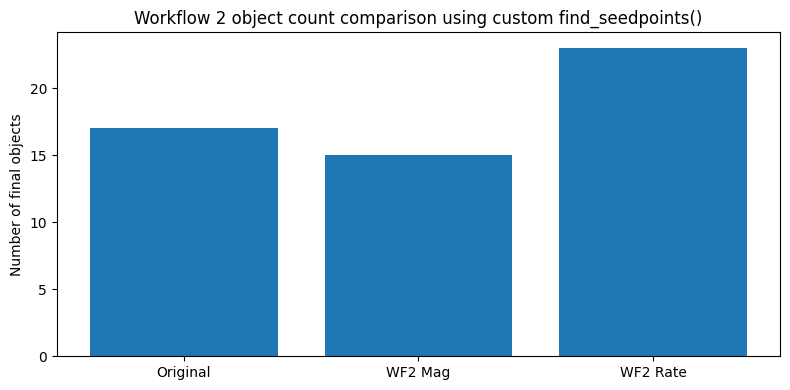


Cell 13 complete: Workflow 2 extraction finished using custom py4dgeo find_seedpoints().


In [14]:
# ============================================================
# CELL 13 — WORKFLOW 2 KALMAN 4D-OBC EXTRACTION
# USING CUSTOM PY4DGEO find_seedpoints() FROM CELL 12B

# ============================================================

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

REFERENCE_COREPOINT_INDEX = 15162
VISUALIZATION_COREPOINT_INDEX = 15162

KALMAN_4DOBC_SEED_MODE = "all"   # options: "all", "top_n"
TOP_N_KALMAN_SEEDS = 20

APPLY_WF2_TEMPORAL_CORRECTION = True
DEDUPLICATE_WF2_OBJECTS = False

DUPLICATE_TEMPORAL_IOU_THRESHOLD = 0.80
DUPLICATE_SPATIAL_IOU_THRESHOLD = 0.50
DUPLICATE_SAME_SEED_REQUIRED = False

USE_SUPPORT_INTERVAL_FOR_REGION_GROWING = True
USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION = True

WINDOW_WIDTH = 14
MINPERIOD = 2
HEIGHT_THRESHOLD = 0.05
NEIGHBORHOOD_RADIUS = 1.0
MIN_SEGMENTS = 10
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

WORKFLOW2_SIGNALS = ["magnitude", "rate"]
ACTIVE_SIGNAL_FOR_DOWNSTREAM = "magnitude"


# ------------------------------------------------------------
# 2. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "kalman_seed_tables",
    "timestamps_analysis",
    "kalman_change",
    "kalman_sigma_change",
    "create_custom_4dobc_algorithm"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run Cells 12 and 12B first."
        )


# ------------------------------------------------------------
# 3. IMPORTS
# ------------------------------------------------------------

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 4. SUPPORT-AWARE SEED TIMING HELPERS
# ------------------------------------------------------------

def seed_start_epoch(row, use_support=True):
    if (
        use_support
        and "support_start_epoch" in row.index
        and not pd.isna(row["support_start_epoch"])
    ):
        return int(row["support_start_epoch"])

    if (
        use_support
        and "py4dgeo_seed_start_epoch" in row.index
        and not pd.isna(row["py4dgeo_seed_start_epoch"])
    ):
        return int(row["py4dgeo_seed_start_epoch"])

    return int(row["start_epoch"])


def seed_end_epoch(row, use_support=True):
    if (
        use_support
        and "support_end_epoch" in row.index
        and not pd.isna(row["support_end_epoch"])
    ):
        return int(row["support_end_epoch"])

    if (
        use_support
        and "py4dgeo_seed_end_epoch" in row.index
        and not pd.isna(row["py4dgeo_seed_end_epoch"])
    ):
        return int(row["py4dgeo_seed_end_epoch"])

    return int(row["end_epoch"])


# ------------------------------------------------------------
# 5. TEMPORALLY CORRECTED OBJECT CLASS
# ------------------------------------------------------------

class TemporallyCorrectedObject:
    def __init__(self, obj, start_epoch, end_epoch, matched_seed):
        self.original_obj = obj
        self.indices = np.array(obj.indices, dtype=int)

        self.original_start_epoch = int(obj.start_epoch)
        self.original_end_epoch = int(obj.end_epoch)

        self.start_epoch = int(start_epoch)
        self.end_epoch = int(end_epoch)

        self.matched_seed = matched_seed

        if hasattr(obj, "seed"):
            self.seed = obj.seed


# ------------------------------------------------------------
# 6. HELPER FUNCTIONS
# ------------------------------------------------------------

def temporal_overlap(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start) + 1)


def temporal_iou(a_start, a_end, b_start, b_end):
    intersection = temporal_overlap(a_start, a_end, b_start, b_end)
    union = max(a_end, b_end) - min(a_start, b_start) + 1
    return intersection / union if union > 0 else 0.0


def spatial_iou(indices_a, indices_b):
    set_a = set(np.array(indices_a, dtype=int))
    set_b = set(np.array(indices_b, dtype=int))

    if len(set_a) == 0 or len(set_b) == 0:
        return 0.0

    intersection = len(set_a.intersection(set_b))
    union = len(set_a.union(set_b))

    return intersection / union if union > 0 else 0.0


def get_object_quality_score(obj):
    matched_magnitude = 0.0
    matched_overlap = 0.0

    if hasattr(obj, "matched_seed") and obj.matched_seed is not None:

        if "event_magnitude" in obj.matched_seed:
            matched_magnitude = float(obj.matched_seed["event_magnitude"])
        elif "abs_net_change" in obj.matched_seed:
            matched_magnitude = float(abs(obj.matched_seed["abs_net_change"]))

        raw_start = int(obj.original_start_epoch)
        raw_end = int(obj.original_end_epoch)

        matched_start = seed_start_epoch(
            obj.matched_seed,
            use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
        )

        matched_end = seed_end_epoch(
            obj.matched_seed,
            use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
        )

        matched_overlap = temporal_overlap(
            raw_start,
            raw_end,
            matched_start,
            matched_end
        )

    object_size = len(obj.indices) if hasattr(obj, "indices") else 0

    return (
        matched_magnitude,
        matched_overlap,
        object_size
    )


def deduplicate_corrected_objects(objects, workflow_name):

    if len(objects) == 0:
        return objects, pd.DataFrame()

    keep_flags = [True] * len(objects)
    duplicate_records = []

    for i in range(len(objects)):

        if not keep_flags[i]:
            continue

        obj_i = objects[i]

        for j in range(i + 1, len(objects)):

            if not keep_flags[j]:
                continue

            obj_j = objects[j]

            t_iou = temporal_iou(
                int(obj_i.start_epoch),
                int(obj_i.end_epoch),
                int(obj_j.start_epoch),
                int(obj_j.end_epoch)
            )

            s_iou = spatial_iou(
                obj_i.indices,
                obj_j.indices
            )

            same_seed = False

            if (
                hasattr(obj_i, "matched_seed")
                and obj_i.matched_seed is not None
                and hasattr(obj_j, "matched_seed")
                and obj_j.matched_seed is not None
            ):
                same_seed = (
                    int(obj_i.matched_seed["corepoint_index_python"])
                    == int(obj_j.matched_seed["corepoint_index_python"])
                    and seed_start_epoch(obj_i.matched_seed) == seed_start_epoch(obj_j.matched_seed)
                    and seed_end_epoch(obj_i.matched_seed) == seed_end_epoch(obj_j.matched_seed)
                )

            duplicate_condition = (
                (
                    t_iou >= DUPLICATE_TEMPORAL_IOU_THRESHOLD
                    and s_iou >= DUPLICATE_SPATIAL_IOU_THRESHOLD
                )
                or same_seed
            )

            if not duplicate_condition:
                continue

            score_i = get_object_quality_score(obj_i)
            score_j = get_object_quality_score(obj_j)

            if score_i >= score_j:
                keep_index = i
                remove_index = j
                keep_flags[j] = False
            else:
                keep_index = j
                remove_index = i
                keep_flags[i] = False

            duplicate_records.append({
                "workflow": workflow_name,
                "kept_original_position": keep_index + 1,
                "removed_original_position": remove_index + 1,
                "temporal_iou": t_iou,
                "spatial_iou": s_iou,
                "same_matched_seed": same_seed,
                "kept_score": str(get_object_quality_score(objects[keep_index])),
                "removed_score": str(get_object_quality_score(objects[remove_index])),
                "kept_start_epoch": int(objects[keep_index].start_epoch),
                "kept_end_epoch": int(objects[keep_index].end_epoch),
                "removed_start_epoch": int(objects[remove_index].start_epoch),
                "removed_end_epoch": int(objects[remove_index].end_epoch)
            })

            if remove_index == i:
                break

    deduplicated_objects = [
        obj for obj, keep in zip(objects, keep_flags) if keep
    ]

    duplicate_table = pd.DataFrame(duplicate_records)

    return deduplicated_objects, duplicate_table


def correct_objects_with_kalman_seed_intervals(objects, seed_table, workflow_name):

    corrected_objects = []
    records = []

    seed_table = seed_table.copy()

    seed_table["support_aware_start_epoch"] = seed_table.apply(
        lambda row: seed_start_epoch(
            row,
            use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
        ),
        axis=1
    )

    seed_table["support_aware_end_epoch"] = seed_table.apply(
        lambda row: seed_end_epoch(
            row,
            use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
        ),
        axis=1
    )

    seed_table["support_aware_duration_epochs"] = (
        seed_table["support_aware_end_epoch"]
        - seed_table["support_aware_start_epoch"]
        + 1
    )

    for obj_number, obj in enumerate(objects, start=1):

        obj_indices = set(np.array(obj.indices, dtype=int))

        obj_start = int(obj.start_epoch)
        obj_end = int(obj.end_epoch)

        seeds_inside = seed_table[
            seed_table["corepoint_index_python"].isin(obj_indices)
        ].copy()

        if len(seeds_inside) == 0:

            corrected_objects.append(
                TemporallyCorrectedObject(
                    obj=obj,
                    start_epoch=obj_start,
                    end_epoch=obj_end,
                    matched_seed=None
                )
            )

            records.append({
                "workflow": workflow_name,
                "object_number": obj_number,
                "status": "no_seed_inside_object",
                "original_start_epoch": obj_start,
                "original_end_epoch": obj_end,
                "corrected_start_epoch": obj_start,
                "corrected_end_epoch": obj_end,
                "original_duration_epochs": obj_end - obj_start + 1,
                "corrected_duration_epochs": obj_end - obj_start + 1,
                "start_shift_epochs": 0,
                "end_shift_epochs": 0,
                "duration_change_epochs": 0,
                "matched_seed_corepoint": np.nan,
                "matched_seed_rank": np.nan,
                "matched_seed_start_epoch": np.nan,
                "matched_seed_end_epoch": np.nan,
                "matched_seed_direction": None,
                "matched_seed_event_magnitude": np.nan,
                "temporal_overlap_with_raw_object": np.nan,
                "used_support_interval": USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
            })

            continue

        seeds_inside["temporal_overlap"] = seeds_inside.apply(
            lambda row: temporal_overlap(
                obj_start,
                obj_end,
                int(row["support_aware_start_epoch"]),
                int(row["support_aware_end_epoch"])
            ),
            axis=1
        )

        if "event_magnitude" not in seeds_inside.columns:
            seeds_inside["event_magnitude"] = seeds_inside["abs_net_change"].abs()

        best_seed = seeds_inside.sort_values(
            ["temporal_overlap", "event_magnitude", "support_aware_duration_epochs"],
            ascending=[False, False, False]
        ).iloc[0]

        corrected_start = int(best_seed["support_aware_start_epoch"])
        corrected_end = int(best_seed["support_aware_end_epoch"])

        corrected_objects.append(
            TemporallyCorrectedObject(
                obj=obj,
                start_epoch=corrected_start,
                end_epoch=corrected_end,
                matched_seed=best_seed
            )
        )

        records.append({
            "workflow": workflow_name,
            "object_number": obj_number,
            "status": "corrected_using_support_aware_kalman_seed",
            "original_start_epoch": obj_start,
            "original_end_epoch": obj_end,
            "corrected_start_epoch": corrected_start,
            "corrected_end_epoch": corrected_end,
            "original_duration_epochs": obj_end - obj_start + 1,
            "corrected_duration_epochs": corrected_end - corrected_start + 1,
            "start_shift_epochs": corrected_start - obj_start,
            "end_shift_epochs": corrected_end - obj_end,
            "duration_change_epochs": (
                corrected_end - corrected_start + 1
            ) - (
                obj_end - obj_start + 1
            ),
            "matched_seed_corepoint": int(best_seed["corepoint_index_python"]),
            "matched_seed_rank": (
                int(best_seed["seed_rank"])
                if "seed_rank" in best_seed and not pd.isna(best_seed["seed_rank"])
                else np.nan
            ),
            "matched_seed_original_start_epoch": int(best_seed["start_epoch"]),
            "matched_seed_original_end_epoch": int(best_seed["end_epoch"]),
            "matched_seed_support_start_epoch": corrected_start,
            "matched_seed_support_end_epoch": corrected_end,
            "matched_seed_start_epoch": corrected_start,
            "matched_seed_end_epoch": corrected_end,
            "matched_seed_direction": best_seed["direction"],
            "matched_seed_event_magnitude": float(best_seed["event_magnitude"]),
            "temporal_overlap_with_raw_object": int(best_seed["temporal_overlap"]),
            "used_support_interval": USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
        })

    return corrected_objects, pd.DataFrame(records)


def summarize_objects(workflow_name, objects, object_set):

    records = []

    for obj_id, obj in enumerate(objects, start=1):

        object_indices = set(np.array(obj.indices, dtype=int))

        record = {
            "workflow": workflow_name,
            "object_set": object_set,
            "object_number_user": obj_id,
            "n_corepoints": len(obj.indices) if hasattr(obj, "indices") else np.nan,
            "start_epoch": int(obj.start_epoch),
            "end_epoch": int(obj.end_epoch),
            "duration_epochs": int(obj.end_epoch - obj.start_epoch + 1),
            "start_time": timestamps_analysis[int(obj.start_epoch)],
            "end_time": timestamps_analysis[int(obj.end_epoch)],

            "reference_corepoint_index_python": REFERENCE_COREPOINT_INDEX,
            "visualization_corepoint_index_python": VISUALIZATION_COREPOINT_INDEX,
            "object_contains_reference_corepoint": (
                int(REFERENCE_COREPOINT_INDEX) in object_indices
            ),
            "object_contains_visualization_corepoint": (
                int(VISUALIZATION_COREPOINT_INDEX) in object_indices
            ),

            "original_py4dgeo_start_epoch": (
                int(obj.original_start_epoch)
                if hasattr(obj, "original_start_epoch")
                else np.nan
            ),
            "original_py4dgeo_end_epoch": (
                int(obj.original_end_epoch)
                if hasattr(obj, "original_end_epoch")
                else np.nan
            )
        }

        if hasattr(obj, "matched_seed") and obj.matched_seed is not None:

            matched_start = seed_start_epoch(
                obj.matched_seed,
                use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
            )

            matched_end = seed_end_epoch(
                obj.matched_seed,
                use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
            )

            record["object_generating_seed_corepoint"] = int(
                obj.matched_seed["corepoint_index_python"]
            )
            record["object_generating_seed_start_epoch"] = matched_start
            record["object_generating_seed_end_epoch"] = matched_end
            record["object_generating_seed_direction"] = obj.matched_seed["direction"]
            record["object_generating_seed_event_magnitude"] = float(
                obj.matched_seed["event_magnitude"]
            )
            record["object_generating_seed_original_start_epoch"] = int(
                obj.matched_seed["start_epoch"]
            )
            record["object_generating_seed_original_end_epoch"] = int(
                obj.matched_seed["end_epoch"]
            )
        else:
            record["object_generating_seed_corepoint"] = np.nan
            record["object_generating_seed_start_epoch"] = np.nan
            record["object_generating_seed_end_epoch"] = np.nan
            record["object_generating_seed_direction"] = None
            record["object_generating_seed_event_magnitude"] = np.nan
            record["object_generating_seed_original_start_epoch"] = np.nan
            record["object_generating_seed_original_end_epoch"] = np.nan

        records.append(record)

    return pd.DataFrame(records)


# ------------------------------------------------------------
# 7. RUN WORKFLOW 2 WITH CUSTOM PY4DGEO find_seedpoints()
# ------------------------------------------------------------

def run_workflow2_kalman_4dobc(signal_name, seed_table):

    print("\n==========================================")
    print(f"Running Workflow 2 Kalman 4D-OBC: {signal_name}")
    print("Custom py4dgeo find_seedpoints() mode")
    print("==========================================")

    if len(seed_table) == 0:
        raise ValueError(f"Seed table for {signal_name} is empty.")

    required_seed_columns = [
        "corepoint_index_python",
        "start_epoch",
        "end_epoch",
        "event_magnitude",
        "direction"
    ]

    for col in required_seed_columns:
        if col not in seed_table.columns:
            raise ValueError(
                f"Column '{col}' missing from {signal_name} seed table."
            )

    algo = create_custom_4dobc_algorithm(
        seed_table=seed_table,
        method_label=f"workflow2_kalman_{signal_name}",
        seed_mode=KALMAN_4DOBC_SEED_MODE,
        top_n=TOP_N_KALMAN_SEEDS,
        use_support_interval=USE_SUPPORT_INTERVAL_FOR_REGION_GROWING,
        ranking_columns=["event_magnitude", "duration_epochs"],
        window_width=WINDOW_WIDTH,
        minperiod=MINPERIOD,
        height_threshold=HEIGHT_THRESHOLD,
        neighborhood_radius=NEIGHBORHOOD_RADIUS,
        min_segments=MIN_SEGMENTS,
        thresholds=THRESHOLDS
    )

    prepared_seed_table = algo.prepared_seed_table.copy()

    candidate_corepoints = (
        prepared_seed_table["corepoint_index_python"]
        .drop_duplicates()
        .astype(int)
        .tolist()
    )

    print("Seed intervals passed through find_seedpoints():", len(prepared_seed_table))
    print("Unique candidate corepoints:", len(candidate_corepoints))
    print("First candidate corepoints:", candidate_corepoints[:10])
    print("Using support interval for region growing:", USE_SUPPORT_INTERVAL_FOR_REGION_GROWING)

    analysis.invalidate_results(
        seeds=True,
        objects=True,
        smoothed_distances=False
    )

    print(f"\nRunning raw Workflow 2 extraction for {signal_name}...")

    start_time = time.time()
    raw_objects = algo.run(analysis)
    elapsed = time.time() - start_time

    seeds = analysis.seeds

    print(f"\nRaw Workflow 2 {signal_name} extraction complete.")
    print(f"Elapsed time: {elapsed:.2f} seconds")
    print("Detected py4dgeo temporal seeds:", len(seeds))
    print("Raw extracted objects:", len(raw_objects))

    if APPLY_WF2_TEMPORAL_CORRECTION:

        corrected_objects, temporal_correction_table = (
            correct_objects_with_kalman_seed_intervals(
                objects=raw_objects,
                seed_table=prepared_seed_table,
                workflow_name=f"Workflow 2 Kalman {signal_name}"
            )
        )

        corrected_objects_before_dedup = corrected_objects

        if DEDUPLICATE_WF2_OBJECTS:
            final_objects, duplicate_table = deduplicate_corrected_objects(
                corrected_objects,
                workflow_name=f"Workflow 2 Kalman {signal_name}"
            )
        else:
            final_objects = corrected_objects
            duplicate_table = pd.DataFrame()

        print("\nTemporal correction applied.")
        print("Using support interval for correction:", USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION)
        print("Corrected objects before deduplication:", len(corrected_objects_before_dedup))
        print("Final objects after deduplication:", len(final_objects))

    else:

        temporal_correction_table = pd.DataFrame()
        duplicate_table = pd.DataFrame()
        corrected_objects_before_dedup = raw_objects
        final_objects = raw_objects

        print("\nTemporal correction NOT applied.")
        print("Final objects are raw py4dgeo objects.")

    seed_records = []

    for seed_id, seed in enumerate(seeds, start=1):

        seed_records.append({
            "workflow": f"Workflow 2 Kalman {signal_name}",
            "seed_number_user": seed_id,
            "corepoint_index_python": int(seed.index),
            "corepoint_number_user": int(seed.index + 1),
            "start_epoch": int(seed.start_epoch),
            "end_epoch": int(seed.end_epoch),
            "duration_epochs": int(seed.end_epoch - seed.start_epoch + 1),
            "start_time": timestamps_analysis[int(seed.start_epoch)],
            "end_time": timestamps_analysis[int(seed.end_epoch)]
        })

    seed_summary = pd.DataFrame(seed_records)

    seed_summary.to_csv(
        TABLES_DIR / f"workflow2_{signal_name}_4dobc_seed_summary.csv",
        index=False
    )

    prepared_seed_table.to_csv(
        TABLES_DIR / f"workflow2_{signal_name}_prepared_custom_seed_table.csv",
        index=False
    )

    raw_object_summary = summarize_objects(
        workflow_name=f"Workflow 2 Kalman {signal_name}",
        objects=raw_objects,
        object_set="raw_py4dgeo"
    )

    corrected_object_summary_before_dedup = summarize_objects(
        workflow_name=f"Workflow 2 Kalman {signal_name}",
        objects=corrected_objects_before_dedup,
        object_set="corrected_before_dedup"
    )

    object_summary = summarize_objects(
        workflow_name=f"Workflow 2 Kalman {signal_name}",
        objects=final_objects,
        object_set=(
            "final_corrected_deduplicated"
            if DEDUPLICATE_WF2_OBJECTS
            else "final_corrected"
        )
    )

    raw_object_summary.to_csv(
        TABLES_DIR / f"workflow2_{signal_name}_4dobc_object_summary_raw.csv",
        index=False
    )

    corrected_object_summary_before_dedup.to_csv(
        TABLES_DIR / f"workflow2_{signal_name}_4dobc_object_summary_corrected_before_dedup.csv",
        index=False
    )

    object_summary.to_csv(
        TABLES_DIR / f"workflow2_{signal_name}_4dobc_object_summary.csv",
        index=False
    )

    if len(temporal_correction_table) > 0:
        temporal_correction_table.to_csv(
            TABLES_DIR / f"workflow2_{signal_name}_temporal_correction_table.csv",
            index=False
        )

    if len(duplicate_table) > 0:
        duplicate_table.to_csv(
            TABLES_DIR / f"workflow2_{signal_name}_duplicate_object_removal_table.csv",
            index=False
        )

    run_config = pd.DataFrame([{
        "workflow": f"Workflow 2 Kalman {signal_name}",
        "kalman_detection_signal": signal_name,
        "custom_find_seedpoints_used": True,
        "kalman_4dobc_seed_mode": KALMAN_4DOBC_SEED_MODE,
        "top_n_kalman_seeds": (
            TOP_N_KALMAN_SEEDS
            if KALMAN_4DOBC_SEED_MODE == "top_n"
            else np.nan
        ),
        "n_seed_intervals_passed_to_find_seedpoints": len(prepared_seed_table),
        "n_candidate_corepoints": len(candidate_corepoints),
        "seed_ranking_metric": "event_magnitude + duration_epochs",
        "use_support_interval_for_region_growing": USE_SUPPORT_INTERVAL_FOR_REGION_GROWING,
        "use_support_interval_for_temporal_correction": USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION,
        "temporal_correction_applied": APPLY_WF2_TEMPORAL_CORRECTION,
        "deduplicate_objects": DEDUPLICATE_WF2_OBJECTS,
        "duplicate_temporal_iou_threshold": DUPLICATE_TEMPORAL_IOU_THRESHOLD,
        "duplicate_spatial_iou_threshold": DUPLICATE_SPATIAL_IOU_THRESHOLD,
        "window_width": WINDOW_WIDTH,
        "minperiod": MINPERIOD,
        "height_threshold": HEIGHT_THRESHOLD,
        "neighborhood_radius": NEIGHBORHOOD_RADIUS,
        "min_segments": MIN_SEGMENTS,
        "thresholds": str(THRESHOLDS),
        "n_detected_py4dgeo_seeds": len(seeds),
        "n_raw_extracted_objects": len(raw_objects),
        "n_corrected_objects_before_dedup": len(corrected_objects_before_dedup),
        "n_final_objects": len(final_objects),
        "elapsed_seconds": elapsed
    }])

    run_config.to_csv(
        TABLES_DIR / f"workflow2_{signal_name}_4dobc_run_config.csv",
        index=False
    )

    return {
        "signal": signal_name,
        "seed_table": seed_table.copy(),
        "prepared_seed_table": prepared_seed_table.copy(),
        "candidate_corepoints": candidate_corepoints,
        "algorithm": algo,
        "seeds": seeds,
        "raw_objects": raw_objects,
        "corrected_objects_before_dedup": corrected_objects_before_dedup,
        "objects": final_objects,
        "seed_summary": seed_summary,
        "raw_object_summary": raw_object_summary,
        "corrected_object_summary_before_dedup": corrected_object_summary_before_dedup,
        "object_summary": object_summary,
        "temporal_correction_table": temporal_correction_table,
        "duplicate_table": duplicate_table,
        "run_config": run_config,
        "elapsed_seconds": elapsed
    }


# ------------------------------------------------------------
# 8. RUN WORKFLOW 2 FOR BOTH MAGNITUDE AND RATE
# ------------------------------------------------------------

workflow2_results = {}

for signal_name in WORKFLOW2_SIGNALS:

    if signal_name not in kalman_seed_tables:
        raise ValueError(
            f"{signal_name} not found in kalman_seed_tables. "
            "Please rerun Cell 12."
        )

    workflow2_results[signal_name] = run_workflow2_kalman_4dobc(
        signal_name=signal_name,
        seed_table=kalman_seed_tables[signal_name]
    )


# ------------------------------------------------------------
# 9. CREATE EASY-TO-USE ALIASES
# ------------------------------------------------------------

wf2_magnitude_objects_raw = workflow2_results["magnitude"]["raw_objects"]
wf2_rate_objects_raw = workflow2_results["rate"]["raw_objects"]

wf2_magnitude_objects_corrected_before_dedup = workflow2_results["magnitude"]["corrected_objects_before_dedup"]
wf2_rate_objects_corrected_before_dedup = workflow2_results["rate"]["corrected_objects_before_dedup"]

wf2_magnitude_objects = workflow2_results["magnitude"]["objects"]
wf2_rate_objects = workflow2_results["rate"]["objects"]

wf2_magnitude_seeds = workflow2_results["magnitude"]["seeds"]
wf2_rate_seeds = workflow2_results["rate"]["seeds"]

wf2_magnitude_seed_summary = workflow2_results["magnitude"]["seed_summary"]
wf2_rate_seed_summary = workflow2_results["rate"]["seed_summary"]

wf2_magnitude_object_summary = workflow2_results["magnitude"]["object_summary"]
wf2_rate_object_summary = workflow2_results["rate"]["object_summary"]

wf2_magnitude_temporal_correction_table = workflow2_results["magnitude"]["temporal_correction_table"]
wf2_rate_temporal_correction_table = workflow2_results["rate"]["temporal_correction_table"]

wf2_magnitude_duplicate_table = workflow2_results["magnitude"]["duplicate_table"]
wf2_rate_duplicate_table = workflow2_results["rate"]["duplicate_table"]

wf2_magnitude_prepared_seed_table = workflow2_results["magnitude"]["prepared_seed_table"]
wf2_rate_prepared_seed_table = workflow2_results["rate"]["prepared_seed_table"]


# ------------------------------------------------------------
# 10. COMBINED TABLES
# ------------------------------------------------------------

workflow2_temporal_correction_table = pd.concat(
    [
        wf2_magnitude_temporal_correction_table,
        wf2_rate_temporal_correction_table
    ],
    ignore_index=True
)

display(workflow2_temporal_correction_table)

workflow2_temporal_correction_table.to_csv(
    TABLES_DIR / "workflow2_temporal_correction_table.csv",
    index=False
)


workflow2_duplicate_object_removal_table = pd.concat(
    [
        wf2_magnitude_duplicate_table,
        wf2_rate_duplicate_table
    ],
    ignore_index=True
)

display(workflow2_duplicate_object_removal_table)

workflow2_duplicate_object_removal_table.to_csv(
    TABLES_DIR / "workflow2_duplicate_object_removal_table.csv",
    index=False
)


# ------------------------------------------------------------
# 11. BACKWARD-COMPATIBLE ACTIVE WORKFLOW
# ------------------------------------------------------------

if ACTIVE_SIGNAL_FOR_DOWNSTREAM not in workflow2_results:
    raise ValueError("ACTIVE_SIGNAL_FOR_DOWNSTREAM must be 'magnitude' or 'rate'.")

kalman_4dobc_seeds = workflow2_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["seeds"]
kalman_4dobc_objects = workflow2_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["objects"]
kalman_4dobc_objects_raw = workflow2_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["raw_objects"]
kalman_4dobc_seed_summary = workflow2_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["seed_summary"]
kalman_4dobc_object_summary = workflow2_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["object_summary"]
kalman_4dobc_run_config = workflow2_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["run_config"]

print("\nActive downstream Workflow 2 signal:", ACTIVE_SIGNAL_FOR_DOWNSTREAM)
print("Active Workflow 2 final objects:", len(kalman_4dobc_objects))
print("Active Workflow 2 raw objects:", len(kalman_4dobc_objects_raw))


# ------------------------------------------------------------
# 12. COMBINED SUMMARY TABLE
# ------------------------------------------------------------

workflow2_combined_summary = pd.DataFrame([
    {
        "workflow": "Workflow 2A: Kalman magnitude",
        "custom_find_seedpoints_used": True,
        "n_detected_py4dgeo_seeds": len(wf2_magnitude_seeds),
        "n_raw_extracted_objects": len(wf2_magnitude_objects_raw),
        "n_corrected_objects_before_dedup": len(wf2_magnitude_objects_corrected_before_dedup),
        "n_final_objects_after_dedup": len(wf2_magnitude_objects),
        "temporal_correction_applied": APPLY_WF2_TEMPORAL_CORRECTION,
        "support_interval_used": USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION,
        "deduplication_applied": DEDUPLICATE_WF2_OBJECTS,
        "elapsed_seconds": workflow2_results["magnitude"]["elapsed_seconds"]
    },
    {
        "workflow": "Workflow 2B: Kalman rate",
        "custom_find_seedpoints_used": True,
        "n_detected_py4dgeo_seeds": len(wf2_rate_seeds),
        "n_raw_extracted_objects": len(wf2_rate_objects_raw),
        "n_corrected_objects_before_dedup": len(wf2_rate_objects_corrected_before_dedup),
        "n_final_objects_after_dedup": len(wf2_rate_objects),
        "temporal_correction_applied": APPLY_WF2_TEMPORAL_CORRECTION,
        "support_interval_used": USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION,
        "deduplication_applied": DEDUPLICATE_WF2_OBJECTS,
        "elapsed_seconds": workflow2_results["rate"]["elapsed_seconds"]
    }
])

display(workflow2_combined_summary)

workflow2_combined_summary.to_csv(
    TABLES_DIR / "workflow2_magnitude_rate_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 13. OBJECT COUNT COMPARISON
# ------------------------------------------------------------

n_original = len(original_4dobc_objects) if "original_4dobc_objects" in globals() else np.nan

plt.figure(figsize=(8, 4))

plt.bar(
    ["Original", "WF2 Mag", "WF2 Rate"],
    [
        n_original,
        len(wf2_magnitude_objects),
        len(wf2_rate_objects)
    ]
)

plt.ylabel("Number of final objects")
plt.title("Workflow 2 object count comparison using custom find_seedpoints()")

plt.tight_layout()
plt.show()

print("\nCell 13 complete: Workflow 2 extraction finished using custom py4dgeo find_seedpoints().")


DIAGNOSTIC FOR OBJECT 1
Workflow: Workflow 2A: Kalman magnitude
Corrected object start epoch: 5
Corrected object end epoch: 39
Corrected object duration: 35
Original py4dgeo start epoch: 5
Original py4dgeo end epoch: 39
Original py4dgeo duration: 35
Target corepoint: 15162
True object-generating corepoint: 15373
Generating seed rank: 498
Object contains target: True
Object contains generator: True

Seeds at target corepoint:


,seed_rank,corepoint_index_python,direction,start_epoch,end_epoch,duration_epochs,event_magnitude
82,83,15162,positive,48,86,39,1.049586
774,775,15162,positive,5,40,36,0.779429
2422,2423,15162,negative,87,153,67,0.438303



Seeds at true object-generating corepoint:


,seed_rank,corepoint_index_python,direction,start_epoch,end_epoch,duration_epochs,event_magnitude
113,114,15373,positive,51,85,35,1.041453
497,498,15373,positive,5,39,35,0.854517
2173,2174,15373,negative,86,155,70,0.459612



Saved figure:
figures\supervisor_issue1_target_vs_true_object_seed_all_objects\magnitude_object_1_target_15162_vs_generator_15373.png


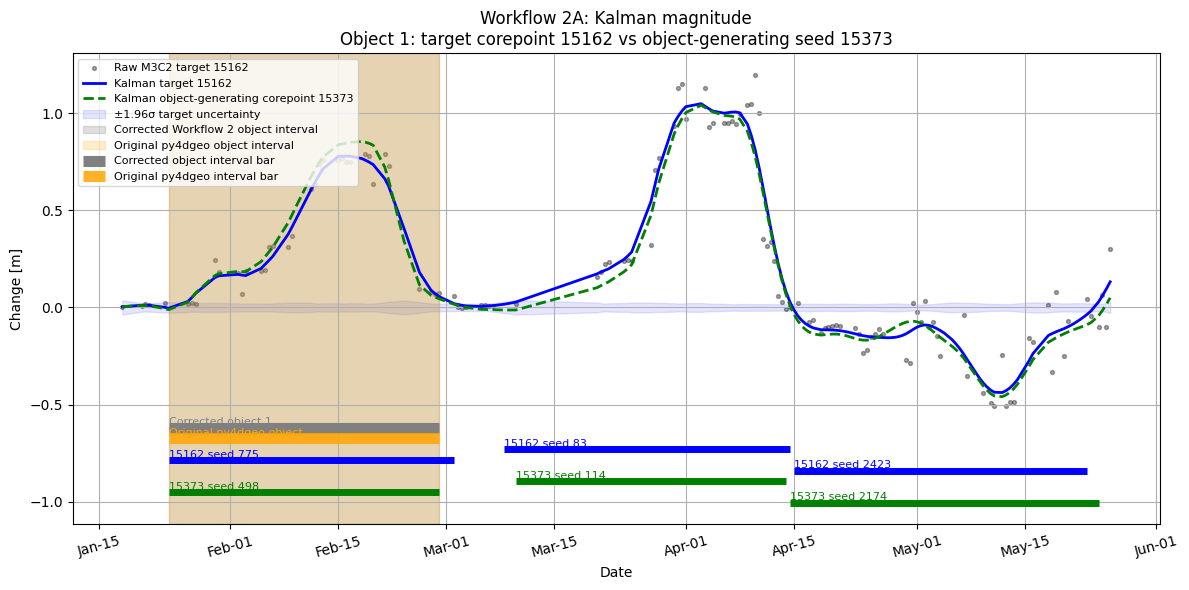


DIAGNOSTIC FOR OBJECT 2
Workflow: Workflow 2A: Kalman magnitude
Corrected object start epoch: 51
Corrected object end epoch: 87
Corrected object duration: 37
Original py4dgeo start epoch: 51
Original py4dgeo end epoch: 87
Original py4dgeo duration: 37
Target corepoint: 15162
True object-generating corepoint: 15021
Generating seed rank: 8
Object contains target: True
Object contains generator: True

Seeds at target corepoint:


,seed_rank,corepoint_index_python,direction,start_epoch,end_epoch,duration_epochs,event_magnitude
82,83,15162,positive,48,86,39,1.049586
774,775,15162,positive,5,40,36,0.779429
2422,2423,15162,negative,87,153,67,0.438303



Seeds at true object-generating corepoint:


,seed_rank,corepoint_index_python,direction,start_epoch,end_epoch,duration_epochs,event_magnitude
7,8,15021,positive,51,87,37,1.087212
1508,1509,15021,positive,5,39,35,0.658822
2566,2567,15021,negative,126,152,27,0.402521
2916,2917,15021,negative,88,118,31,0.146422



Saved figure:
figures\supervisor_issue1_target_vs_true_object_seed_all_objects\magnitude_object_2_target_15162_vs_generator_15021.png


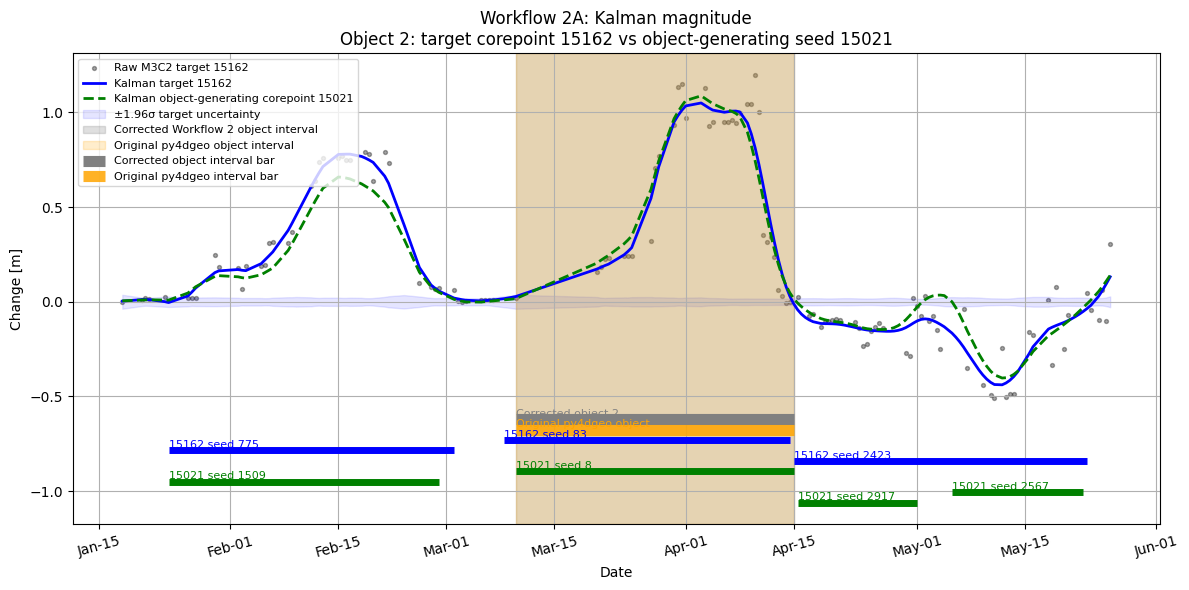

,workflow,object_number,target_corepoint,object_generating_corepoint,generating_seed_rank,object_start_epoch,object_end_epoch,object_duration_epochs,object_contains_target,object_contains_generator,figure_path
0,Workflow 2A: Kalman magnitude,1,15162,15373,498,5,39,35,True,True,figures\supervisor_issue1_target_vs_true_objec...
1,Workflow 2A: Kalman magnitude,2,15162,15021,8,51,87,37,True,True,figures\supervisor_issue1_target_vs_true_objec...



Diagnostic complete.


In [15]:
# ============================================================
# DIAGNOSTIC — TARGET SEED VS TRUE OBJECT-GENERATING SEED
# FOR MULTIPLE WORKFLOW 2 OBJECTS
# ============================================================

TARGET_COREPOINT_INDEX = 15162
OBJECT_NUMBERS_TO_PLOT = [1, 2]   # edit this list
WORKFLOW2_SIGNAL = "magnitude"          # options: "magnitude", "rate"
SAVE_FIGURE = True

fig_dir = FIGURES_DIR / "supervisor_issue1_target_vs_true_object_seed_all_objects"
fig_dir.mkdir(exist_ok=True, parents=True)


# ------------------------------------------------------------
# 1. SELECT WORKFLOW 2 DATA
# ------------------------------------------------------------

if WORKFLOW2_SIGNAL == "magnitude":
    seed_table = kalman_seed_table_magnitude
    objects = wf2_magnitude_objects
    workflow_label = "Workflow 2A: Kalman magnitude"

elif WORKFLOW2_SIGNAL == "rate":
    seed_table = kalman_seed_table_rate
    objects = wf2_rate_objects
    workflow_label = "Workflow 2B: Kalman rate"

else:
    raise ValueError("WORKFLOW2_SIGNAL must be 'magnitude' or 'rate'.")


# ------------------------------------------------------------
# 2. SUPPORT-AWARE HELPERS
# ------------------------------------------------------------

def get_seed_plot_start(row):
    if "support_start_epoch" in row.index and not pd.isna(row["support_start_epoch"]):
        return int(row["support_start_epoch"])
    if "support_aware_start_epoch" in row.index and not pd.isna(row["support_aware_start_epoch"]):
        return int(row["support_aware_start_epoch"])
    if "py4dgeo_seed_start_epoch" in row.index and not pd.isna(row["py4dgeo_seed_start_epoch"]):
        return int(row["py4dgeo_seed_start_epoch"])
    return int(row["start_epoch"])


def get_seed_plot_end(row):
    if "support_end_epoch" in row.index and not pd.isna(row["support_end_epoch"]):
        return int(row["support_end_epoch"])
    if "support_aware_end_epoch" in row.index and not pd.isna(row["support_aware_end_epoch"]):
        return int(row["support_aware_end_epoch"])
    if "py4dgeo_seed_end_epoch" in row.index and not pd.isna(row["py4dgeo_seed_end_epoch"]):
        return int(row["py4dgeo_seed_end_epoch"])
    return int(row["end_epoch"])


def get_true_object_seed(selected_obj):
    if hasattr(selected_obj, "matched_seed") and selected_obj.matched_seed is not None:
        seed = selected_obj.matched_seed

        seed_rank = np.nan
        for rank_col in ["cell14_seed_rank", "seed_rank", "nms_rank"]:
            if rank_col in seed and not pd.isna(seed[rank_col]):
                seed_rank = int(seed[rank_col])
                break

        return int(seed["corepoint_index_python"]), seed_rank

    raise ValueError(
        "This object has no matched_seed. "
        "Run revised Cell 13/14 with seed assignment first."
    )


# ------------------------------------------------------------
# 3. PLOT FUNCTION
# ------------------------------------------------------------

def plot_target_vs_object_seed(object_number):

    if object_number < 1 or object_number > len(objects):
        print(
            f"Skipping OBJECT_NUMBER={object_number}. "
            f"Available objects: {len(objects)}"
        )
        return None

    selected_obj = objects[object_number - 1]
    object_indices = set(np.array(selected_obj.indices, dtype=int))

    OBJECT_GENERATING_COREPOINT_INDEX, generating_seed_rank = get_true_object_seed(
        selected_obj
    )

    target_seeds = seed_table[
        seed_table["corepoint_index_python"] == TARGET_COREPOINT_INDEX
    ].copy()

    generator_seeds = seed_table[
        seed_table["corepoint_index_python"] == OBJECT_GENERATING_COREPOINT_INDEX
    ].copy()

    seed_cols = [
        "seed_rank",
        "cell14_seed_rank",
        "corepoint_index_python",
        "direction",
        "start_epoch",
        "end_epoch",
        "support_start_epoch",
        "support_end_epoch",
        "duration_epochs",
        "support_duration_epochs",
        "event_magnitude"
    ]
    seed_cols = [c for c in seed_cols if c in seed_table.columns]

    print("\n" + "=" * 80)
    print(f"DIAGNOSTIC FOR OBJECT {object_number}")
    print("=" * 80)
    print("Workflow:", workflow_label)
    print("Corrected object start epoch:", int(selected_obj.start_epoch))
    print("Corrected object end epoch:", int(selected_obj.end_epoch))
    print("Corrected object duration:", int(selected_obj.end_epoch - selected_obj.start_epoch + 1))

    if hasattr(selected_obj, "original_start_epoch"):
        print("Original py4dgeo start epoch:", int(selected_obj.original_start_epoch))
        print("Original py4dgeo end epoch:", int(selected_obj.original_end_epoch))
        print(
            "Original py4dgeo duration:",
            int(selected_obj.original_end_epoch - selected_obj.original_start_epoch + 1)
        )

    print("Target corepoint:", TARGET_COREPOINT_INDEX)
    print("True object-generating corepoint:", OBJECT_GENERATING_COREPOINT_INDEX)
    print("Generating seed rank:", generating_seed_rank)
    print("Object contains target:", TARGET_COREPOINT_INDEX in object_indices)
    print("Object contains generator:", OBJECT_GENERATING_COREPOINT_INDEX in object_indices)

    print("\nSeeds at target corepoint:")
    display(target_seeds[seed_cols] if len(target_seeds) > 0 else target_seeds)

    print("\nSeeds at true object-generating corepoint:")
    display(generator_seeds[seed_cols] if len(generator_seeds) > 0 else generator_seeds)

    import matplotlib.dates as mdates
    dtFmt = mdates.DateFormatter("%b-%d")

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(
        timestamps_analysis,
        analysis.distances[TARGET_COREPOINT_INDEX],
        s=8,
        color="black",
        alpha=0.35,
        label=f"Raw M3C2 target {TARGET_COREPOINT_INDEX}"
    )

    ax.plot(
        timestamps_analysis,
        kalman_change[TARGET_COREPOINT_INDEX],
        color="blue",
        linewidth=2,
        label=f"Kalman target {TARGET_COREPOINT_INDEX}"
    )

    ax.plot(
        timestamps_analysis,
        kalman_change[OBJECT_GENERATING_COREPOINT_INDEX],
        color="green",
        linewidth=2,
        linestyle="--",
        label=f"Kalman object-generating corepoint {OBJECT_GENERATING_COREPOINT_INDEX}"
    )

    upper = 1.96 * kalman_sigma_change[TARGET_COREPOINT_INDEX]
    lower = -1.96 * kalman_sigma_change[TARGET_COREPOINT_INDEX]

    ax.fill_between(
        timestamps_analysis,
        lower,
        upper,
        color="blue",
        alpha=0.10,
        label="±1.96σ target uncertainty"
    )

    ax.axvspan(
        timestamps_analysis[int(selected_obj.start_epoch)],
        timestamps_analysis[int(selected_obj.end_epoch)],
        color="grey",
        alpha=0.25,
        label="Corrected Workflow 2 object interval"
    )

    if hasattr(selected_obj, "original_start_epoch"):
        ax.axvspan(
            timestamps_analysis[int(selected_obj.original_start_epoch)],
            timestamps_analysis[int(selected_obj.original_end_epoch)],
            color="orange",
            alpha=0.20,
            label="Original py4dgeo object interval"
        )

    y_base = -0.62
    y_step = 0.055

    ax.hlines(
        y_base,
        timestamps_analysis[int(selected_obj.start_epoch)],
        timestamps_analysis[int(selected_obj.end_epoch)],
        color="grey",
        linewidth=8,
        label="Corrected object interval bar"
    )

    ax.text(
        timestamps_analysis[int(selected_obj.start_epoch)],
        y_base + 0.012,
        f"Corrected object {object_number}",
        fontsize=8,
        color="grey"
    )

    current_y = y_base - y_step

    if hasattr(selected_obj, "original_start_epoch"):

        ax.hlines(
            current_y,
            timestamps_analysis[int(selected_obj.original_start_epoch)],
            timestamps_analysis[int(selected_obj.original_end_epoch)],
            color="orange",
            linewidth=8,
            alpha=0.85,
            label="Original py4dgeo interval bar"
        )

        ax.text(
            timestamps_analysis[int(selected_obj.original_start_epoch)],
            current_y + 0.012,
            "Original py4dgeo object",
            fontsize=8,
            color="orange"
        )

        current_y -= y_step

    for _, row in target_seeds.iterrows():

        s = get_seed_plot_start(row)
        e = get_seed_plot_end(row)

        rank_label = (
            int(row["seed_rank"])
            if "seed_rank" in row.index and not pd.isna(row["seed_rank"])
            else "?"
        )

        ax.hlines(
            current_y,
            timestamps_analysis[s],
            timestamps_analysis[e],
            color="blue",
            linewidth=5
        )

        ax.text(
            timestamps_analysis[s],
            current_y + 0.012,
            f"{TARGET_COREPOINT_INDEX} seed {rank_label}",
            fontsize=8,
            color="blue"
        )

        current_y -= y_step

    for _, row in generator_seeds.iterrows():

        s = get_seed_plot_start(row)
        e = get_seed_plot_end(row)

        rank_label = (
            int(row["seed_rank"])
            if "seed_rank" in row.index and not pd.isna(row["seed_rank"])
            else "?"
        )

        ax.hlines(
            current_y,
            timestamps_analysis[s],
            timestamps_analysis[e],
            color="green",
            linewidth=5
        )

        ax.text(
            timestamps_analysis[s],
            current_y + 0.012,
            f"{OBJECT_GENERATING_COREPOINT_INDEX} seed {rank_label}",
            fontsize=8,
            color="green"
        )

        current_y -= y_step

    ax.set_xlabel("Date")
    ax.set_ylabel("Change [m]")
    ax.tick_params(axis="x", rotation=15)
    ax.xaxis.set_major_formatter(dtFmt)

    ax.set_title(
        f"{workflow_label}\n"
        f"Object {object_number}: target corepoint {TARGET_COREPOINT_INDEX} "
        f"vs object-generating seed {OBJECT_GENERATING_COREPOINT_INDEX}"
    )

    ax.grid(True)
    ax.legend(fontsize=8, loc="upper left")

    plt.tight_layout()

    fig_path = fig_dir / (
        f"{WORKFLOW2_SIGNAL}_object_{object_number}_"
        f"target_{TARGET_COREPOINT_INDEX}_"
        f"vs_generator_{OBJECT_GENERATING_COREPOINT_INDEX}.png"
    )

    if SAVE_FIGURE:
        plt.savefig(
            fig_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        print("\nSaved figure:")
        print(fig_path)

    plt.show()

    return {
        "workflow": workflow_label,
        "object_number": object_number,
        "target_corepoint": TARGET_COREPOINT_INDEX,
        "object_generating_corepoint": OBJECT_GENERATING_COREPOINT_INDEX,
        "generating_seed_rank": generating_seed_rank,
        "object_start_epoch": int(selected_obj.start_epoch),
        "object_end_epoch": int(selected_obj.end_epoch),
        "object_duration_epochs": int(selected_obj.end_epoch - selected_obj.start_epoch + 1),
        "object_contains_target": TARGET_COREPOINT_INDEX in object_indices,
        "object_contains_generator": OBJECT_GENERATING_COREPOINT_INDEX in object_indices,
        "figure_path": str(fig_path)
    }


# ------------------------------------------------------------
# 4. RUN FOR ALL REQUESTED OBJECTS
# ------------------------------------------------------------

diagnostic_records = []

for obj_num in OBJECT_NUMBERS_TO_PLOT:
    record = plot_target_vs_object_seed(obj_num)

    if record is not None:
        diagnostic_records.append(record)

diagnostic_summary = pd.DataFrame(diagnostic_records)

display(diagnostic_summary)

diagnostic_summary.to_csv(
    TABLES_DIR / (
        f"diagnostic_target_vs_true_seed_"
        f"{WORKFLOW2_SIGNAL}_objects.csv"
    ),
    index=False
)

print("\nDiagnostic complete.")


Workflow 2 magnitude: seed-defined objects
Raw Workflow 2 objects: 15
Seed-defined objects: 15
Ranking metric: event_magnitude + support_duration_epochs


,raw_object_number,status,object_start_epoch,object_end_epoch,object_duration_epochs,raw_object_start_epoch,raw_object_end_epoch,object_generating_seed_corepoint,object_generating_seed_user_number,object_generating_seed_rank,...,seed_original_end_epoch,seed_support_start_epoch,seed_support_end_epoch,seed_support_duration_epochs,seed_direction,seed_event_magnitude,seed_ranking_metric,temporal_overlap_with_raw_object,signal,ranking_metric
0,1,top_ranked_seed_assigned,5,39,35,5,39,15373,15374,498,...,39,5,39,35,positive,0.854517,event_magnitude + support_duration_epochs,35,magnitude,event_magnitude + support_duration_epochs
1,2,top_ranked_seed_assigned,49,86,38,51,87,15175,15176,1,...,86,49,86,38,positive,1.106074,event_magnitude + support_duration_epochs,36,magnitude,event_magnitude + support_duration_epochs
2,3,top_ranked_seed_assigned,51,87,37,51,100,15400,15401,208,...,87,51,87,37,positive,1.004910,event_magnitude + support_duration_epochs,37,magnitude,event_magnitude + support_duration_epochs
3,4,top_ranked_seed_assigned,5,39,35,5,41,15374,15375,513,...,39,5,39,35,positive,0.848118,event_magnitude + support_duration_epochs,35,magnitude,event_magnitude + support_duration_epochs
4,5,top_ranked_seed_assigned,51,88,38,88,158,15028,15029,13,...,88,51,88,38,positive,1.079236,event_magnitude + support_duration_epochs,1,magnitude,event_magnitude + support_duration_epochs


Saved: tables\workflow2_magnitude_cell14_seed_assignment_table.csv

Workflow 2 rate: seed-defined objects
Raw Workflow 2 objects: 23
Seed-defined objects: 23
Ranking metric: event_magnitude + support_duration_epochs


,raw_object_number,status,object_start_epoch,object_end_epoch,object_duration_epochs,raw_object_start_epoch,raw_object_end_epoch,object_generating_seed_corepoint,object_generating_seed_user_number,object_generating_seed_rank,...,seed_original_end_epoch,seed_support_start_epoch,seed_support_end_epoch,seed_support_duration_epochs,seed_direction,seed_event_magnitude,seed_ranking_metric,temporal_overlap_with_raw_object,signal,ranking_metric
0,1,top_ranked_seed_assigned,14,24,11,14,24,15381,15382,544,...,24,14,24,11,positive,0.775588,event_magnitude + support_duration_epochs,11,rate,event_magnitude + support_duration_epochs
1,2,top_ranked_seed_assigned,56,65,10,52,65,15084,15085,1,...,65,56,65,10,positive,1.084392,event_magnitude + support_duration_epochs,10,rate,event_magnitude + support_duration_epochs
2,3,top_ranked_seed_assigned,56,67,12,66,101,15076,15077,145,...,67,56,67,12,positive,0.991568,event_magnitude + support_duration_epochs,2,rate,event_magnitude + support_duration_epochs
3,4,top_ranked_seed_assigned,120,138,19,120,138,15305,15306,1492,...,138,120,138,19,negative,0.494138,event_magnitude + support_duration_epochs,19,rate,event_magnitude + support_duration_epochs
4,5,top_ranked_seed_assigned,56,65,10,56,65,15084,15085,1,...,65,56,65,10,positive,1.084392,event_magnitude + support_duration_epochs,10,rate,event_magnitude + support_duration_epochs


Saved: tables\workflow2_rate_cell14_seed_assignment_table.csv

Workflow 2 magnitude clean object visualisation
Object number: 1
Object support-aware interval: 5 → 39
Object duration: 35 epochs
Visualisation corepoint: 15162
Object-generating top-ranked seed corepoint: 15373
Object-generating seed rank: 498
Seed support interval: 5 → 39
Object contains visualisation corepoint: True
Object contains reference corepoint: True
Saved Workflow 2 clean object figure:
figures\workflow2_clean_support_seed_defined_visualisation\workflow2_magnitude_seed_defined_object_1_visualcp_15162.png


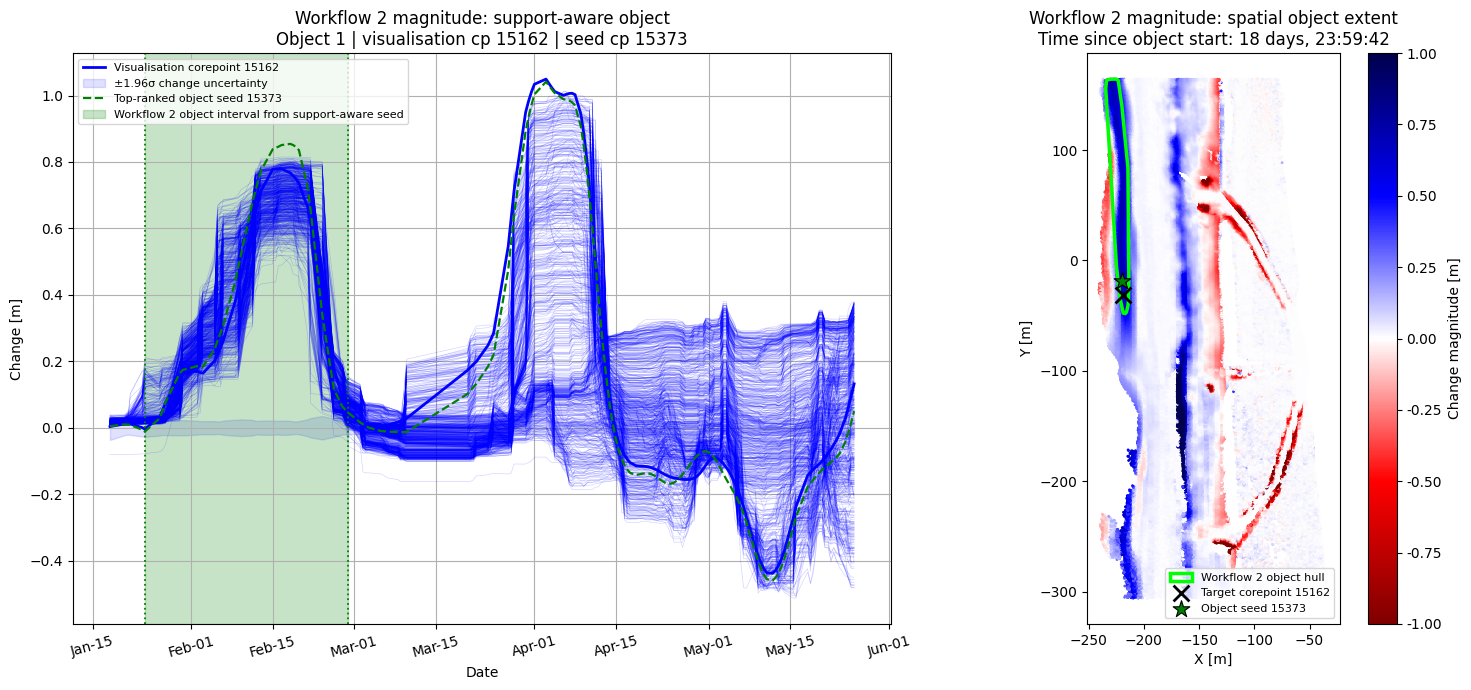


Workflow 2 magnitude clean object visualisation
Object number: 2
Object support-aware interval: 49 → 86
Object duration: 38 epochs
Visualisation corepoint: 15162
Object-generating top-ranked seed corepoint: 15175
Object-generating seed rank: 1
Seed support interval: 49 → 86
Object contains visualisation corepoint: True
Object contains reference corepoint: True
Saved Workflow 2 clean object figure:
figures\workflow2_clean_support_seed_defined_visualisation\workflow2_magnitude_seed_defined_object_2_visualcp_15162.png


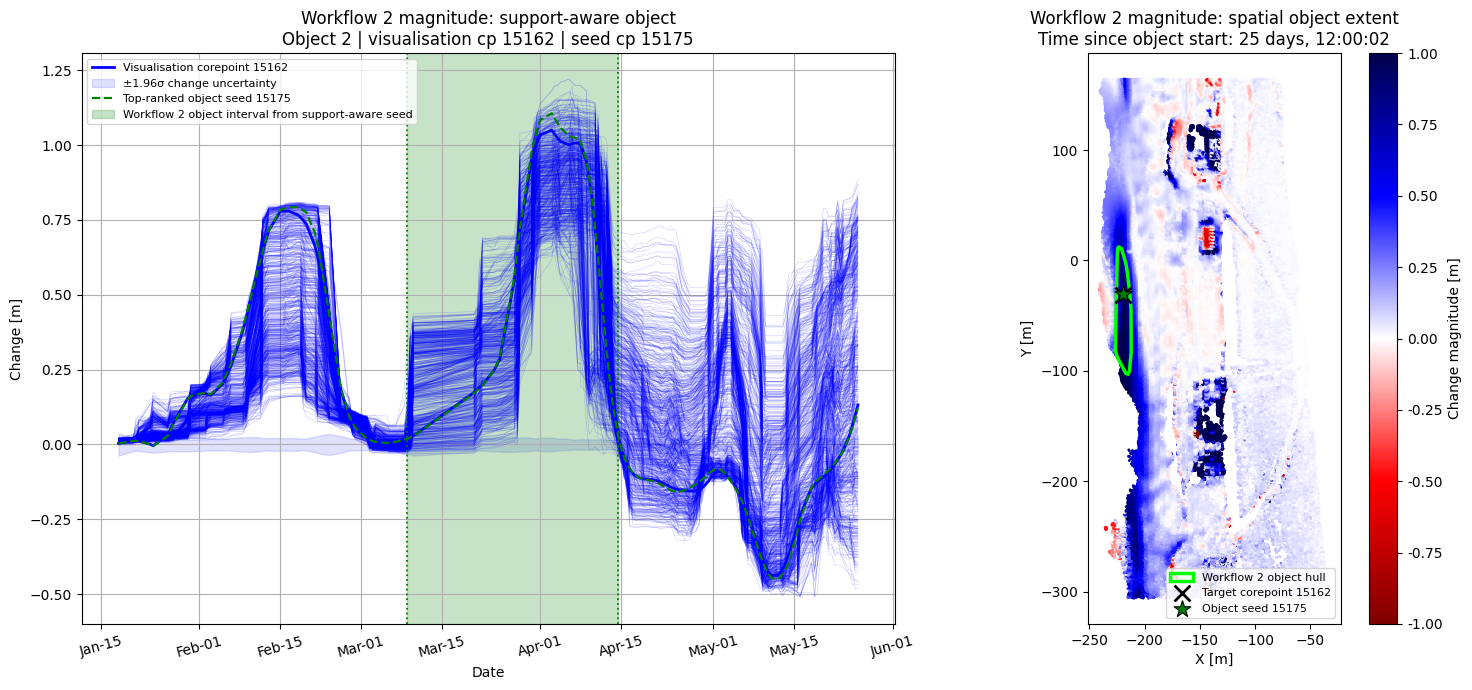


Workflow 2 rate clean object visualisation
Object number: 1
Object support-aware interval: 14 → 24
Object duration: 11 epochs
Visualisation corepoint: 15162
Object-generating top-ranked seed corepoint: 15381
Object-generating seed rank: 544
Seed support interval: 14 → 24
Object contains visualisation corepoint: True
Object contains reference corepoint: True
Saved Workflow 2 clean object figure:
figures\workflow2_clean_support_seed_defined_visualisation\workflow2_rate_seed_defined_object_1_visualcp_15162.png


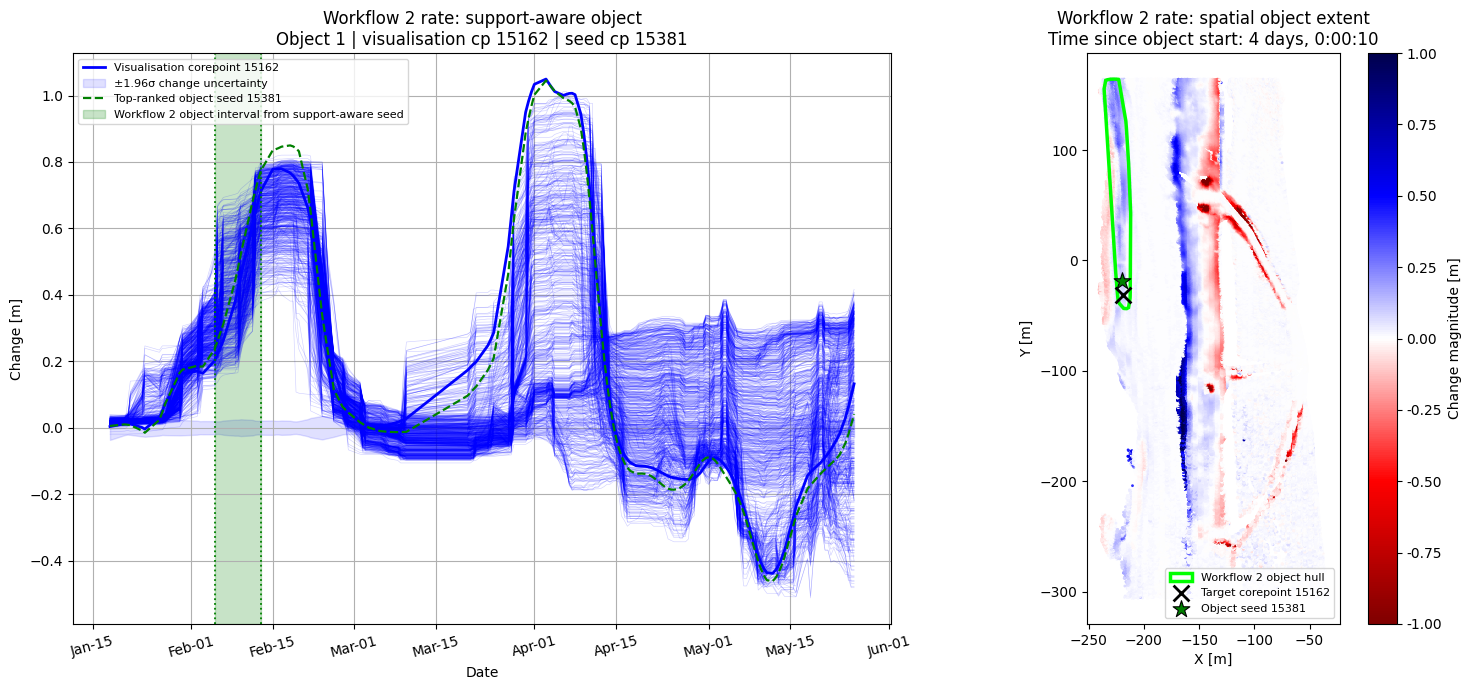


Workflow 2 rate clean object visualisation
Object number: 2
Object support-aware interval: 56 → 65
Object duration: 10 epochs
Visualisation corepoint: 15162
Object-generating top-ranked seed corepoint: 15084
Object-generating seed rank: 1
Seed support interval: 56 → 65
Object contains visualisation corepoint: True
Object contains reference corepoint: True
Saved Workflow 2 clean object figure:
figures\workflow2_clean_support_seed_defined_visualisation\workflow2_rate_seed_defined_object_2_visualcp_15162.png


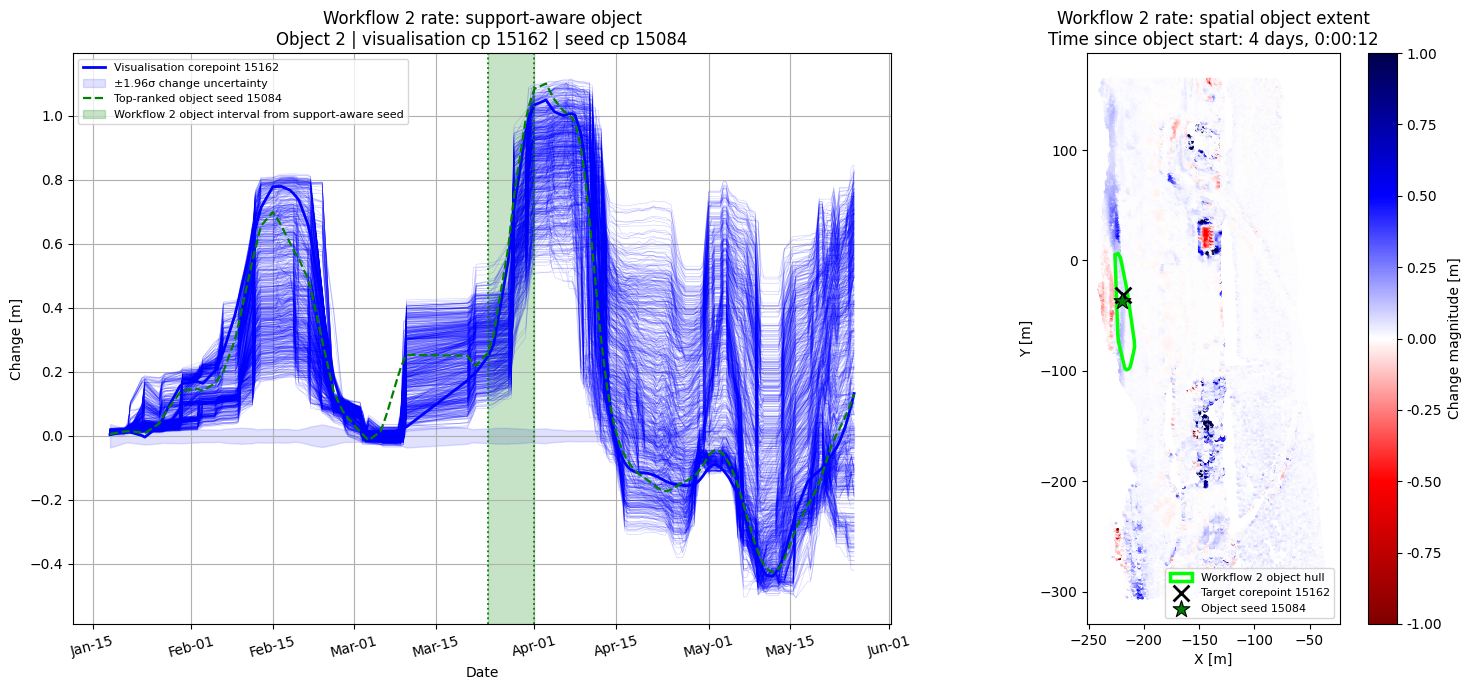

,signal,workflow,object_number_user,reference_corepoint_index_python,visualization_corepoint_index_python,object_contains_reference_corepoint,object_contains_visualization_corepoint,object_generating_seed_corepoint,object_generating_seed_rank,object_generating_seed_support_start_epoch,...,object_support_start_epoch,object_support_end_epoch,object_duration_epochs,object_start_time,object_end_time,epoch_of_interest,n_corepoints,mean_change_magnitude,max_abs_change_magnitude,figure_path
0,magnitude,Workflow 2 Kalman magnitude,1,15162,15162,True,True,15373,498,5,...,5,39,35,2017-01-24 00:00:54,2017-02-28 00:00:53,22,5339,0.619480,0.764042,figures\workflow2_clean_support_seed_defined_v...
1,magnitude,Workflow 2 Kalman magnitude,2,15162,15162,True,True,15175,1,49,...,49,86,38,2017-03-09 00:00:36,2017-04-14 12:00:52,67,2976,0.880186,1.149787,figures\workflow2_clean_support_seed_defined_v...
2,rate,Workflow 2 Kalman rate,1,15162,15162,True,True,15381,544,14,...,14,24,11,2017-02-05 00:00:30,2017-02-13 00:00:52,19,6691,0.131548,0.374272,figures\workflow2_clean_support_seed_defined_v...
3,rate,Workflow 2 Kalman rate,2,15162,15162,True,True,15084,1,56,...,56,65,10,2017-03-24 00:00:31,2017-04-01 00:00:52,60,2588,0.045860,0.210124,figures\workflow2_clean_support_seed_defined_v...


Saved: tables\workflow2_clean_seed_defined_object_visualization_summary_both_signals.csv

Improved seed filtering for: magnitude
Candidate Kalman seeds from Cell 12: 3117
Number of improved Kalman seed intervals (magnitude):
3117


,signal,corepoint_index_python,corepoint_number_user,start_epoch,end_epoch,duration_epochs,support_start_epoch,support_end_epoch,support_duration_epochs,start_time,...,abs_net_change,mean_change,max_abs_change,mean_rate,max_abs_rate,n_neighbours,neighbour_support_count,support_fraction,spatial_support_used,seed_rank
0,magnitude,15175,15176,49,86,38,49,86,38,2017-03-09 00:00:36,...,0.009075,0.600344,1.106074,-0.029307,0.214120,23,NaN,NaN,False,1
1,magnitude,15095,15096,44,86,43,44,86,43,2017-03-05 12:00:32,...,0.039195,0.556996,1.105813,-0.019118,0.200642,24,NaN,NaN,False,2
2,magnitude,15084,15085,44,86,43,44,86,43,2017-03-05 12:00:32,...,0.039278,0.553107,1.100631,-0.018977,0.197098,24,NaN,NaN,False,3
3,magnitude,15067,15068,47,86,40,47,86,40,2017-03-07 00:00:58,...,0.011037,0.553583,1.097973,-0.026732,0.206218,25,NaN,NaN,False,4
4,magnitude,15006,15007,51,86,36,51,86,36,2017-03-10 00:00:53,...,0.026265,0.622928,1.091933,-0.030049,0.199114,20,NaN,NaN,False,5


Saved: tables\improved_kalman_seed_table_magnitude.csv
Saved: tables\improved_seed_detection_config_magnitude.csv

Improved seed filtering for: rate
Candidate Kalman seeds from Cell 12: 3719
Number of improved Kalman seed intervals (rate):
3719


,signal,corepoint_index_python,corepoint_number_user,start_epoch,end_epoch,duration_epochs,support_start_epoch,support_end_epoch,support_duration_epochs,start_time,...,abs_net_change,mean_change,max_abs_change,mean_rate,max_abs_rate,n_neighbours,neighbour_support_count,support_fraction,spatial_support_used,seed_rank
0,rate,15084,15085,56,65,10,56,65,10,2017-03-24 00:00:31,...,0.825264,0.701718,1.084392,0.090592,0.160911,24,NaN,NaN,False,1
1,rate,15095,15096,56,65,10,56,65,10,2017-03-24 00:00:31,...,0.828573,0.697883,1.083375,0.090985,0.161873,24,NaN,NaN,False,2
2,rate,15175,15176,56,65,10,56,65,10,2017-03-24 00:00:31,...,0.834233,0.685125,1.083119,0.091001,0.168011,23,NaN,NaN,False,3
3,rate,15137,15138,52,65,14,52,65,14,2017-03-20 12:00:31,...,0.900846,0.559884,1.080778,0.068603,0.166544,21,NaN,NaN,False,4
4,rate,15067,15068,52,65,14,52,65,14,2017-03-20 12:00:31,...,0.879916,0.561791,1.077887,0.067763,0.158703,25,NaN,NaN,False,5


Saved: tables\improved_kalman_seed_table_rate.csv
Saved: tables\improved_seed_detection_config_rate.csv


,signal,improved_seed_mode,use_spatial_support,spatial_support_radius,min_neighbour_support,min_support_fraction,support_time_tolerance_epochs,neighbour_magnitude_ratio,support_interval_preserved_from_cell12,n_candidate_cell12_seeds,n_improved_seeds,seed_ranking_metric
0,magnitude,processed,False,1.5,3,0.3,5,0.5,True,3117,3117,event_magnitude + support_duration_epochs
1,rate,processed,False,1.5,3,0.3,5,0.5,True,3719,3719,event_magnitude + support_duration_epochs


Saved: tables\improved_seed_detection_config_both_signals.csv

Cell 14 complete.
Workflow 2 seed-defined clean visualisations created.
Magnitude seed-defined objects: 15
Rate seed-defined objects: 23
Magnitude improved seeds: 3117
Rate improved seeds: 3719
Active downstream improved seed table: magnitude


In [16]:
# ============================================================
# CELL 14 — WORKFLOW 2 CLEAN VISUALISATION + IMPROVED SEEDS
# TOP-RANKED SUPPORT-AWARE SEED DEFINES EACH OBJECT
# NO DEDUPLICATION
# ============================================================

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

REFERENCE_COREPOINT_INDEX = 15162
VISUALIZATION_COREPOINT_INDEX = 15162

OBJECT_SELECTION_MODE = "object_number"   # options: "object_number", "contains_reference"
KALMAN_OBJECT_NUMBERS = [1, 2]

IMPROVED_SEED_MODE = "processed"   # options: "processed", "single", "range"
IMPROVED_SEED_COREPOINT_NUMBER = 15163
IMPROVED_SEED_RANGE_START = 15000
IMPROVED_SEED_RANGE_END = 15999

USE_SPATIAL_SUPPORT = False
SPATIAL_SUPPORT_RADIUS = 1.5
MIN_NEIGHBOUR_SUPPORT = 3
MIN_SUPPORT_FRACTION = 0.30
SUPPORT_TIME_TOLERANCE = 5
NEIGHBOUR_MAGNITUDE_RATIO = 0.5

CRANGE = 1.0
SAVE_WORKFLOW2_OBJECT_FIGURE = True
SAVE_IMPROVED_SEED_TABLES = True

WORKFLOW_SIGNALS = ["magnitude", "rate"]
ACTIVE_SIGNAL_FOR_DOWNSTREAM = "magnitude"

workflow2_fig_dir = FIGURES_DIR / "workflow2_clean_support_seed_defined_visualisation"
workflow2_fig_dir.mkdir(exist_ok=True, parents=True)


# ------------------------------------------------------------
# 2. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "kalman_seed_tables",
    "kalman_change",
    "kalman_rate",
    "kalman_sigma_change",
    "corepoints",
    "timestamps_analysis",
    "wf2_magnitude_objects",
    "wf2_rate_objects",
    "wf2_magnitude_seeds",
    "wf2_rate_seeds",
    "TABLES_DIR",
    "FIGURES_DIR"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run Cells 12, 12B and 13 first."
        )

n_corepoints, n_epochs = kalman_change.shape


# ------------------------------------------------------------
# 3. IMPORTS
# ------------------------------------------------------------

from pathlib import Path
from scipy.spatial import ConvexHull, cKDTree
from matplotlib.patches import Polygon
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cloud = analysis.corepoints.cloud
dtFmt = mdates.DateFormatter("%b-%d")


# ------------------------------------------------------------
# 4. HELPER FUNCTIONS
# ------------------------------------------------------------

def safe_to_csv(df, path, index=False):
    path = Path(path)

    try:
        df.to_csv(path, index=index)
        print("Saved:", path)
        return path

    except PermissionError:
        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        backup_path = path.with_name(f"{path.stem}_{timestamp}{path.suffix}")
        df.to_csv(backup_path, index=index)

        print("PermissionError: file is probably open or locked.")
        print("Saved backup instead:", backup_path)

        return backup_path


def support_start(row):
    if "support_start_epoch" in row.index and not pd.isna(row["support_start_epoch"]):
        return int(row["support_start_epoch"])

    if "support_aware_start_epoch" in row.index and not pd.isna(row["support_aware_start_epoch"]):
        return int(row["support_aware_start_epoch"])

    if "py4dgeo_seed_start_epoch" in row.index and not pd.isna(row["py4dgeo_seed_start_epoch"]):
        return int(row["py4dgeo_seed_start_epoch"])

    return int(row["start_epoch"])


def support_end(row):
    if "support_end_epoch" in row.index and not pd.isna(row["support_end_epoch"]):
        return int(row["support_end_epoch"])

    if "support_aware_end_epoch" in row.index and not pd.isna(row["support_aware_end_epoch"]):
        return int(row["support_aware_end_epoch"])

    if "py4dgeo_seed_end_epoch" in row.index and not pd.isna(row["py4dgeo_seed_end_epoch"]):
        return int(row["py4dgeo_seed_end_epoch"])

    return int(row["end_epoch"])


def temporal_overlap(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start) + 1)


def find_object_containing_corepoint(objects, cp_idx):
    for i, obj in enumerate(objects):
        indices = np.array(obj.indices, dtype=int)
        if int(cp_idx) in indices:
            return i
    return None


def add_clean_hull(ax, points_xy, edgecolor="lime", label="Workflow 2 hull", linewidth=2.5):
    if points_xy.shape[0] < 3:
        return False

    try:
        hull = ConvexHull(points_xy)
        hull_xy = points_xy[hull.vertices, 0:2]

        ax.add_patch(
            Polygon(
                hull_xy,
                fill=False,
                edgecolor=edgecolor,
                linewidth=linewidth,
                label=label
            )
        )

        return True

    except Exception as e:
        print("Convex hull could not be created:", e)
        return False


# ------------------------------------------------------------
# 5. SEED RANKING + OBJECT DEFINITION
# ------------------------------------------------------------

def prepare_seed_table_for_object_assignment(seed_table):
    table = seed_table.copy()

    table["support_start_epoch"] = table.apply(support_start, axis=1)
    table["support_end_epoch"] = table.apply(support_end, axis=1)

    table["support_duration_epochs"] = (
        table["support_end_epoch"] -
        table["support_start_epoch"] + 1
    )

    if "event_magnitude" not in table.columns:
        if "abs_net_change" in table.columns:
            table["event_magnitude"] = table["abs_net_change"].abs()
        else:
            raise ValueError("Seed table must contain event_magnitude or abs_net_change.")

    if "support_fraction" not in table.columns:
        table["support_fraction"] = np.nan

    use_support_fraction_for_ranking = (
        USE_SPATIAL_SUPPORT
        and "support_fraction" in table.columns
        and table["support_fraction"].notna().any()
    )

    if use_support_fraction_for_ranking:
        ranking_columns = [
            "event_magnitude",
            "support_fraction",
            "support_duration_epochs"
        ]
        ranking_metric = "event_magnitude + support_fraction + support_duration_epochs"
    else:
        ranking_columns = [
            "event_magnitude",
            "support_duration_epochs"
        ]
        ranking_metric = "event_magnitude + support_duration_epochs"

    table = table.sort_values(
        ranking_columns,
        ascending=[False] * len(ranking_columns)
    ).reset_index(drop=True)

    table["cell14_seed_rank"] = np.arange(1, len(table) + 1)
    table["cell14_ranking_metric"] = ranking_metric

    return table, ranking_metric


def select_top_ranked_seed_for_object(obj, prepared_seed_table):
    obj_indices = set(np.array(obj.indices, dtype=int))
    obj_start = int(obj.start_epoch)
    obj_end = int(obj.end_epoch)

    candidate_seeds = prepared_seed_table[
        prepared_seed_table["corepoint_index_python"].isin(obj_indices)
    ].copy()

    if len(candidate_seeds) == 0:
        return None

    candidate_seeds["temporal_overlap_with_raw_object"] = candidate_seeds.apply(
        lambda row: temporal_overlap(
            obj_start,
            obj_end,
            int(row["support_start_epoch"]),
            int(row["support_end_epoch"])
        ),
        axis=1
    )

    overlapping = candidate_seeds[
        candidate_seeds["temporal_overlap_with_raw_object"] > 0
    ].copy()

    if len(overlapping) == 0:
        overlapping = candidate_seeds.copy()

    best_seed = overlapping.sort_values(
        ["cell14_seed_rank"],
        ascending=True
    ).iloc[0]

    return best_seed


class Cell14SeedDefinedObject:
    def __init__(self, obj, matched_seed):
        self.original_obj = obj
        self.indices = np.array(obj.indices, dtype=int)

        self.original_start_epoch = int(obj.start_epoch)
        self.original_end_epoch = int(obj.end_epoch)

        self.matched_seed = matched_seed
        self.parent_seed = matched_seed

        if matched_seed is not None:
            self.start_epoch = int(matched_seed["support_start_epoch"])
            self.end_epoch = int(matched_seed["support_end_epoch"])
        else:
            self.start_epoch = int(obj.start_epoch)
            self.end_epoch = int(obj.end_epoch)

        if hasattr(obj, "seed"):
            self.seed = obj.seed


def assign_top_ranked_seeds_to_objects(objects, prepared_seed_table):
    assigned_objects = []
    records = []

    for obj_number, obj in enumerate(objects, start=1):

        best_seed = select_top_ranked_seed_for_object(
            obj=obj,
            prepared_seed_table=prepared_seed_table
        )

        assigned_obj = Cell14SeedDefinedObject(
            obj=obj,
            matched_seed=best_seed
        )

        assigned_objects.append(assigned_obj)

        if best_seed is not None:
            records.append({
                "raw_object_number": obj_number,
                "status": "top_ranked_seed_assigned",
                "object_start_epoch": int(assigned_obj.start_epoch),
                "object_end_epoch": int(assigned_obj.end_epoch),
                "object_duration_epochs": int(assigned_obj.end_epoch - assigned_obj.start_epoch + 1),
                "raw_object_start_epoch": int(obj.start_epoch),
                "raw_object_end_epoch": int(obj.end_epoch),
                "object_generating_seed_corepoint": int(best_seed["corepoint_index_python"]),
                "object_generating_seed_user_number": int(best_seed["corepoint_index_python"] + 1),
                "object_generating_seed_rank": int(best_seed["cell14_seed_rank"]),
                "seed_original_start_epoch": int(best_seed["start_epoch"]),
                "seed_original_end_epoch": int(best_seed["end_epoch"]),
                "seed_support_start_epoch": int(best_seed["support_start_epoch"]),
                "seed_support_end_epoch": int(best_seed["support_end_epoch"]),
                "seed_support_duration_epochs": int(best_seed["support_duration_epochs"]),
                "seed_direction": best_seed["direction"],
                "seed_event_magnitude": float(best_seed["event_magnitude"]),
                "seed_ranking_metric": best_seed["cell14_ranking_metric"],
                "temporal_overlap_with_raw_object": int(best_seed["temporal_overlap_with_raw_object"])
            })
        else:
            records.append({
                "raw_object_number": obj_number,
                "status": "no_seed_found_inside_object",
                "object_start_epoch": int(assigned_obj.start_epoch),
                "object_end_epoch": int(assigned_obj.end_epoch),
                "object_duration_epochs": int(assigned_obj.end_epoch - assigned_obj.start_epoch + 1),
                "raw_object_start_epoch": int(obj.start_epoch),
                "raw_object_end_epoch": int(obj.end_epoch),
                "object_generating_seed_corepoint": np.nan,
                "object_generating_seed_user_number": np.nan,
                "object_generating_seed_rank": np.nan,
                "seed_original_start_epoch": np.nan,
                "seed_original_end_epoch": np.nan,
                "seed_support_start_epoch": np.nan,
                "seed_support_end_epoch": np.nan,
                "seed_support_duration_epochs": np.nan,
                "seed_direction": None,
                "seed_event_magnitude": np.nan,
                "seed_ranking_metric": None,
                "temporal_overlap_with_raw_object": np.nan
            })

    return assigned_objects, pd.DataFrame(records)


def get_object_generating_seed_info(obj):
    if hasattr(obj, "matched_seed") and obj.matched_seed is not None:
        seed = obj.matched_seed

        return {
            "corepoint": int(seed["corepoint_index_python"]),
            "support_start_epoch": int(seed["support_start_epoch"]),
            "support_end_epoch": int(seed["support_end_epoch"]),
            "original_start_epoch": int(seed["start_epoch"]),
            "original_end_epoch": int(seed["end_epoch"]),
            "direction": seed["direction"] if "direction" in seed else None,
            "event_magnitude": (
                float(seed["event_magnitude"])
                if "event_magnitude" in seed and not pd.isna(seed["event_magnitude"])
                else np.nan
            ),
            "seed_rank": (
                int(seed["cell14_seed_rank"])
                if "cell14_seed_rank" in seed and not pd.isna(seed["cell14_seed_rank"])
                else np.nan
            )
        }

    return {
        "corepoint": np.nan,
        "support_start_epoch": np.nan,
        "support_end_epoch": np.nan,
        "original_start_epoch": np.nan,
        "original_end_epoch": np.nan,
        "direction": None,
        "event_magnitude": np.nan,
        "seed_rank": np.nan
    }


# ------------------------------------------------------------
# 6. CLEAN WORKFLOW 2 OBJECT VISUALISATION
# ------------------------------------------------------------

def plot_workflow2_clean_object(signal_name, objects, object_number):

    if len(objects) == 0:
        print(f"No Workflow 2 objects for {signal_name}.")
        return None

    if OBJECT_SELECTION_MODE == "object_number":
        obj_idx = object_number - 1

        if obj_idx < 0 or obj_idx >= len(objects):
            print(
                f"Skipping Workflow 2 {signal_name} object {object_number}: "
                f"only {len(objects)} objects available."
            )
            return None

    elif OBJECT_SELECTION_MODE == "contains_reference":
        obj_idx = find_object_containing_corepoint(
            objects,
            REFERENCE_COREPOINT_INDEX
        )

        if obj_idx is None:
            print(
                f"No Workflow 2 {signal_name} object contains corepoint "
                f"{REFERENCE_COREPOINT_INDEX}."
            )
            return None

    else:
        raise ValueError("OBJECT_SELECTION_MODE must be 'object_number' or 'contains_reference'.")

    selected_obj = objects[obj_idx]
    object_number_used = obj_idx + 1

    idxs = np.array(selected_obj.indices, dtype=int)
    object_indices = set(idxs)

    obj_start = int(selected_obj.start_epoch)
    obj_end = int(selected_obj.end_epoch)
    obj_duration = obj_end - obj_start + 1

    epoch_of_interest = int((obj_start + obj_end) / 2)
    epoch_of_interest = max(0, min(epoch_of_interest, n_epochs - 1))

    visualization_cp_idx = int(VISUALIZATION_COREPOINT_INDEX)
    reference_cp_idx = int(REFERENCE_COREPOINT_INDEX)

    seed_info = get_object_generating_seed_info(selected_obj)
    object_generating_cp = seed_info["corepoint"]

    object_contains_visualization_cp = visualization_cp_idx in object_indices
    object_contains_reference_cp = reference_cp_idx in object_indices

    print("\n==========================================")
    print(f"Workflow 2 {signal_name} clean object visualisation")
    print("==========================================")
    print("Object number:", object_number_used)
    print("Object support-aware interval:", obj_start, "→", obj_end)
    print("Object duration:", obj_duration, "epochs")
    print("Visualisation corepoint:", visualization_cp_idx)
    print("Object-generating top-ranked seed corepoint:", object_generating_cp)
    print("Object-generating seed rank:", seed_info["seed_rank"])
    print("Seed support interval:", seed_info["support_start_epoch"], "→", seed_info["support_end_epoch"])
    print("Object contains visualisation corepoint:", object_contains_visualization_cp)
    print("Object contains reference corepoint:", object_contains_reference_cp)

    magnitudes_of_interest = (
        analysis.smoothed_distances[:, epoch_of_interest]
        - analysis.smoothed_distances[:, obj_start]
    )

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(15, 7),
        gridspec_kw={"width_ratios": [1.45, 1.0]}
    )

    ax1, ax2 = axs

    sampled_idxs = idxs[::max(1, len(idxs) // 700)]

    for idx in sampled_idxs:
        ax1.plot(
            timestamps_analysis,
            analysis.smoothed_distances[idx],
            color="blue",
            linewidth=0.45,
            alpha=0.18
        )

    ax1.plot(
        timestamps_analysis,
        kalman_change[visualization_cp_idx],
        color="blue",
        linewidth=2.0,
        label=f"Visualisation corepoint {visualization_cp_idx}"
    )

    upper = 1.96 * kalman_sigma_change[visualization_cp_idx]
    lower = -1.96 * kalman_sigma_change[visualization_cp_idx]

    ax1.fill_between(
        timestamps_analysis,
        lower,
        upper,
        color="blue",
        alpha=0.12,
        label="±1.96σ change uncertainty"
    )

    if not pd.isna(object_generating_cp):
        ax1.plot(
            timestamps_analysis,
            kalman_change[int(object_generating_cp)],
            color="green",
            linestyle="--",
            linewidth=1.6,
            label=f"Top-ranked object seed {int(object_generating_cp)}"
        )

    ax1.axvspan(
        timestamps_analysis[obj_start],
        timestamps_analysis[obj_end],
        alpha=0.22,
        color="green",
        label="Workflow 2 object interval from support-aware seed"
    )

    if not pd.isna(seed_info["support_start_epoch"]):
        seed_s = int(seed_info["support_start_epoch"])
        seed_e = int(seed_info["support_end_epoch"])

        ax1.axvline(
            timestamps_analysis[seed_s],
            color="green",
            linestyle=":",
            linewidth=1.3
        )

        ax1.axvline(
            timestamps_analysis[seed_e],
            color="green",
            linestyle=":",
            linewidth=1.3
        )

    ax1.set_title(
        f"Workflow 2 {signal_name}: support-aware object\n"
        f"Object {object_number_used} | visualisation cp {visualization_cp_idx} | "
        f"seed cp {object_generating_cp}"
    )

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Change [m]")
    ax1.tick_params(axis="x", rotation=15)
    ax1.xaxis.set_major_formatter(dtFmt)
    ax1.grid(True)
    ax1.legend(fontsize=8, loc="upper left")

    d = ax2.scatter(
        cloud[:, 0],
        cloud[:, 1],
        c=magnitudes_of_interest,
        cmap="seismic_r",
        vmin=-CRANGE,
        vmax=CRANGE,
        s=1
    )

    plt.colorbar(
        d,
        format="%.2f",
        label="Change magnitude [m]",
        ax=ax2
    )

    add_clean_hull(
        ax=ax2,
        points_xy=cloud[idxs, :2],
        edgecolor="lime",
        label="Workflow 2 object hull",
        linewidth=2.5
    )

    ax2.scatter(
        cloud[visualization_cp_idx, 0],
        cloud[visualization_cp_idx, 1],
        marker="x",
        c="black",
        s=130,
        linewidths=2,
        label=f"Target corepoint {visualization_cp_idx}"
    )

    if not pd.isna(object_generating_cp):
        ax2.scatter(
            cloud[int(object_generating_cp), 0],
            cloud[int(object_generating_cp), 1],
            marker="*",
            c="green",
            edgecolors="black",
            s=160,
            linewidths=0.8,
            label=f"Object seed {int(object_generating_cp)}"
        )

    time_delta = timestamps_analysis[epoch_of_interest] - timestamps_analysis[obj_start]

    ax2.set_title(
        f"Workflow 2 {signal_name}: spatial object extent\n"
        f"Time since object start: {time_delta}"
    )

    ax2.set_xlabel("X [m]")
    ax2.set_ylabel("Y [m]")
    ax2.set_aspect("equal")
    ax2.legend(loc="lower right", fontsize=8)

    plt.tight_layout()

    fig_path = workflow2_fig_dir / (
        f"workflow2_{signal_name}_seed_defined_object_"
        f"{object_number_used}_visualcp_{visualization_cp_idx}.png"
    )

    if SAVE_WORKFLOW2_OBJECT_FIGURE:
        plt.savefig(
            fig_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        print("Saved Workflow 2 clean object figure:")
        print(fig_path)

    plt.show()

    return {
        "signal": signal_name,
        "workflow": f"Workflow 2 Kalman {signal_name}",
        "object_number_user": object_number_used,
        "reference_corepoint_index_python": reference_cp_idx,
        "visualization_corepoint_index_python": visualization_cp_idx,
        "object_contains_reference_corepoint": object_contains_reference_cp,
        "object_contains_visualization_corepoint": object_contains_visualization_cp,
        "object_generating_seed_corepoint": object_generating_cp,
        "object_generating_seed_rank": seed_info["seed_rank"],
        "object_generating_seed_support_start_epoch": seed_info["support_start_epoch"],
        "object_generating_seed_support_end_epoch": seed_info["support_end_epoch"],
        "object_generating_seed_original_start_epoch": seed_info["original_start_epoch"],
        "object_generating_seed_original_end_epoch": seed_info["original_end_epoch"],
        "object_generating_seed_direction": seed_info["direction"],
        "object_generating_seed_event_magnitude": seed_info["event_magnitude"],
        "object_support_start_epoch": obj_start,
        "object_support_end_epoch": obj_end,
        "object_duration_epochs": obj_duration,
        "object_start_time": timestamps_analysis[obj_start],
        "object_end_time": timestamps_analysis[obj_end],
        "epoch_of_interest": epoch_of_interest,
        "n_corepoints": len(idxs),
        "mean_change_magnitude": float(np.nanmean(magnitudes_of_interest[idxs])),
        "max_abs_change_magnitude": float(np.nanmax(np.abs(magnitudes_of_interest[idxs]))),
        "figure_path": str(fig_path)
    }


# ------------------------------------------------------------
# 7. IMPROVED SEED TABLE FOR CELL 15
# ------------------------------------------------------------

def select_seed_indices():

    if IMPROVED_SEED_MODE == "processed":

        if "kalman_indices" not in globals():
            raise ValueError("kalman_indices not found. Please run Cell 11 first.")

        return kalman_indices

    elif IMPROVED_SEED_MODE == "single":

        if IMPROVED_SEED_COREPOINT_NUMBER <= 0:
            raise ValueError("Corepoint numbering starts from 1, not 0.")

        return [IMPROVED_SEED_COREPOINT_NUMBER - 1]

    elif IMPROVED_SEED_MODE == "range":

        if IMPROVED_SEED_RANGE_START <= 0 or IMPROVED_SEED_RANGE_END <= 0:
            raise ValueError("Corepoint numbering starts from 1, not 0.")

        start_idx = IMPROVED_SEED_RANGE_START - 1
        end_idx = min(IMPROVED_SEED_RANGE_END, n_corepoints)

        return list(range(start_idx, end_idx))

    else:
        raise ValueError("IMPROVED_SEED_MODE must be 'processed', 'single', or 'range'.")


def run_optional_improved_seed_detection(signal_name, source_seed_table):

    print("\n==========================================")
    print(f"Improved seed filtering for: {signal_name}")
    print("==========================================")

    seed_indices = select_seed_indices()

    candidate_seed_table = source_seed_table[
        source_seed_table["corepoint_index_python"].isin(seed_indices)
    ].copy()

    print("Candidate Kalman seeds from Cell 12:", len(candidate_seed_table))

    tree_xy = cKDTree(corepoints[:, :2])

    improved_seed_records = []

    for _, seed_row in candidate_seed_table.iterrows():

        cp_idx = int(seed_row["corepoint_index_python"])

        start_epoch = int(seed_row["start_epoch"])
        end_epoch = int(seed_row["end_epoch"])

        support_start_epoch = support_start(seed_row)
        support_end_epoch = support_end(seed_row)

        direction = seed_row["direction"]

        duration = end_epoch - start_epoch + 1
        support_duration = support_end_epoch - support_start_epoch + 1

        if support_duration < 2:
            continue

        change = kalman_change[cp_idx]
        rate = kalman_rate[cp_idx]

        if np.all(np.isnan(change)):
            continue

        interval_change = change[support_start_epoch:support_end_epoch + 1]
        interval_rate = rate[support_start_epoch:support_end_epoch + 1]

        if direction == "positive":
            event_magnitude = float(np.nanmax(interval_change))
            peak_epoch_local = int(np.nanargmax(interval_change))

        elif direction == "negative":
            event_magnitude = float(abs(np.nanmin(interval_change)))
            peak_epoch_local = int(np.nanargmin(interval_change))

        else:
            continue

        peak_epoch = support_start_epoch + peak_epoch_local

        net_change = change[support_end_epoch] - change[support_start_epoch]
        abs_net_change = abs(net_change)

        neighbours = tree_xy.query_ball_point(
            corepoints[cp_idx, :2],
            r=SPATIAL_SUPPORT_RADIUS
        )

        neighbours = [n for n in neighbours if n != cp_idx]

        neighbour_support_count = 0
        support_fraction = np.nan

        spatial_support_start = max(0, support_start_epoch - SUPPORT_TIME_TOLERANCE)
        spatial_support_end = min(n_epochs - 1, support_end_epoch + SUPPORT_TIME_TOLERANCE)

        if USE_SPATIAL_SUPPORT:

            if len(neighbours) == 0:
                continue

            for nb in neighbours:

                nb_change = kalman_change[nb]

                if np.all(np.isnan(nb_change)):
                    continue

                nb_interval = nb_change[spatial_support_start:spatial_support_end + 1]

                if direction == "positive":

                    nb_event_magnitude = np.nanmax(nb_interval)
                    same_direction = nb_event_magnitude > 0
                    meaningful = (
                        nb_event_magnitude >=
                        NEIGHBOUR_MAGNITUDE_RATIO * event_magnitude
                    )

                elif direction == "negative":

                    nb_event_magnitude = abs(np.nanmin(nb_interval))
                    same_direction = np.nanmin(nb_interval) < 0
                    meaningful = (
                        nb_event_magnitude >=
                        NEIGHBOUR_MAGNITUDE_RATIO * event_magnitude
                    )

                else:
                    same_direction = False
                    meaningful = False

                if same_direction and meaningful:
                    neighbour_support_count += 1

            support_fraction = neighbour_support_count / max(len(neighbours), 1)

            if neighbour_support_count < MIN_NEIGHBOUR_SUPPORT:
                continue

            if support_fraction < MIN_SUPPORT_FRACTION:
                continue

        else:
            support_fraction = np.nan
            neighbour_support_count = np.nan

        improved_seed_records.append({
            "signal": signal_name,
            "corepoint_index_python": int(cp_idx),
            "corepoint_number_user": int(cp_idx + 1),

            "start_epoch": int(start_epoch),
            "end_epoch": int(end_epoch),
            "duration_epochs": int(duration),

            "support_start_epoch": int(support_start_epoch),
            "support_end_epoch": int(support_end_epoch),
            "support_duration_epochs": int(support_duration),

            "start_time": timestamps_analysis[start_epoch],
            "end_time": timestamps_analysis[end_epoch],
            "support_start_time": timestamps_analysis[support_start_epoch],
            "support_end_time": timestamps_analysis[support_end_epoch],

            "direction": direction,
            "peak_epoch": int(peak_epoch),
            "peak_time": timestamps_analysis[peak_epoch],

            "event_magnitude": float(event_magnitude),
            "net_change": float(net_change),
            "abs_net_change": float(abs_net_change),

            "mean_change": float(np.nanmean(interval_change)),
            "max_abs_change": float(np.nanmax(np.abs(interval_change))),
            "mean_rate": float(np.nanmean(interval_rate)),
            "max_abs_rate": float(np.nanmax(np.abs(interval_rate))),

            "n_neighbours": int(len(neighbours)),
            "neighbour_support_count": neighbour_support_count,
            "support_fraction": support_fraction,
            "spatial_support_used": USE_SPATIAL_SUPPORT
        })

    improved_table = pd.DataFrame(improved_seed_records)

    if len(improved_table) > 0:

        if USE_SPATIAL_SUPPORT:
            improved_table = improved_table.sort_values(
                ["event_magnitude", "support_fraction", "support_duration_epochs"],
                ascending=False
            ).reset_index(drop=True)

            ranking_metric = "event_magnitude + support_fraction + support_duration_epochs"

        else:
            improved_table = improved_table.sort_values(
                ["event_magnitude", "support_duration_epochs"],
                ascending=False
            ).reset_index(drop=True)

            ranking_metric = "event_magnitude + support_duration_epochs"

        improved_table["seed_rank"] = np.arange(1, len(improved_table) + 1)

    else:
        improved_table["seed_rank"] = []
        ranking_metric = "none"

    print(f"Number of improved Kalman seed intervals ({signal_name}):")
    print(len(improved_table))

    display(improved_table.head())

    if SAVE_IMPROVED_SEED_TABLES:
        safe_to_csv(
            improved_table,
            TABLES_DIR / f"improved_kalman_seed_table_{signal_name}.csv",
            index=False
        )

    config = pd.DataFrame([{
        "signal": signal_name,
        "improved_seed_mode": IMPROVED_SEED_MODE,
        "use_spatial_support": USE_SPATIAL_SUPPORT,
        "spatial_support_radius": SPATIAL_SUPPORT_RADIUS,
        "min_neighbour_support": MIN_NEIGHBOUR_SUPPORT,
        "min_support_fraction": MIN_SUPPORT_FRACTION,
        "support_time_tolerance_epochs": SUPPORT_TIME_TOLERANCE,
        "neighbour_magnitude_ratio": NEIGHBOUR_MAGNITUDE_RATIO,
        "support_interval_preserved_from_cell12": True,
        "n_candidate_cell12_seeds": len(candidate_seed_table),
        "n_improved_seeds": len(improved_table),
        "seed_ranking_metric": ranking_metric
    }])

    if SAVE_IMPROVED_SEED_TABLES:
        safe_to_csv(
            config,
            TABLES_DIR / f"improved_seed_detection_config_{signal_name}.csv",
            index=False
        )

    return improved_table, config


# ------------------------------------------------------------
# 8. ASSIGN TOP SEEDS TO OBJECTS
# ------------------------------------------------------------

workflow2_visualization_records = []
workflow2_seed_assignment_tables = {}
workflow2_seed_defined_objects = {}

workflow2_inputs = {
    "magnitude": wf2_magnitude_objects,
    "rate": wf2_rate_objects
}

for signal_name in WORKFLOW_SIGNALS:

    prepared_seed_table, ranking_metric = prepare_seed_table_for_object_assignment(
        kalman_seed_tables[signal_name]
    )

    assigned_objects, assignment_table = assign_top_ranked_seeds_to_objects(
        workflow2_inputs[signal_name],
        prepared_seed_table
    )

    assignment_table["signal"] = signal_name
    assignment_table["ranking_metric"] = ranking_metric

    workflow2_seed_assignment_tables[signal_name] = assignment_table
    workflow2_seed_defined_objects[signal_name] = assigned_objects

    print("\n==========================================")
    print(f"Workflow 2 {signal_name}: seed-defined objects")
    print("==========================================")
    print("Raw Workflow 2 objects:", len(workflow2_inputs[signal_name]))
    print("Seed-defined objects:", len(assigned_objects))
    print("Ranking metric:", ranking_metric)

    display(assignment_table.head())

    safe_to_csv(
        assignment_table,
        TABLES_DIR / f"workflow2_{signal_name}_cell14_seed_assignment_table.csv",
        index=False
    )


# Easy aliases for Cell 14 outputs
wf2_magnitude_objects_cell14_seed_defined = workflow2_seed_defined_objects["magnitude"]
wf2_rate_objects_cell14_seed_defined = workflow2_seed_defined_objects["rate"]

wf2_magnitude_cell14_seed_assignment_table = workflow2_seed_assignment_tables["magnitude"]
wf2_rate_cell14_seed_assignment_table = workflow2_seed_assignment_tables["rate"]


# ------------------------------------------------------------
# 9. PLOT WORKFLOW 2 OBJECTS
# ------------------------------------------------------------

workflow2_plot_inputs = {
    "magnitude": wf2_magnitude_objects_cell14_seed_defined,
    "rate": wf2_rate_objects_cell14_seed_defined
}

for signal_name in WORKFLOW_SIGNALS:

    for object_number in KALMAN_OBJECT_NUMBERS:

        record = plot_workflow2_clean_object(
            signal_name=signal_name,
            objects=workflow2_plot_inputs[signal_name],
            object_number=object_number
        )

        if record is not None:
            workflow2_visualization_records.append(record)

workflow2_object_visualization_summary = pd.DataFrame(workflow2_visualization_records)

display(workflow2_object_visualization_summary)

safe_to_csv(
    workflow2_object_visualization_summary,
    TABLES_DIR / "workflow2_clean_seed_defined_object_visualization_summary_both_signals.csv",
    index=False
)


# ------------------------------------------------------------
# 10. RUN OPTIONAL IMPROVED SEED FILTERING FOR CELL 15
# ------------------------------------------------------------

improved_seed_tables = {}
improved_seed_configs = {}

for signal_name in WORKFLOW_SIGNALS:

    if signal_name not in kalman_seed_tables:
        raise ValueError(
            f"{signal_name} not found in kalman_seed_tables. Run Cell 12 first."
        )

    table, config = run_optional_improved_seed_detection(
        signal_name=signal_name,
        source_seed_table=kalman_seed_tables[signal_name]
    )

    improved_seed_tables[signal_name] = table.copy()
    improved_seed_configs[signal_name] = config.copy()


# ------------------------------------------------------------
# 11. CREATE EASY ALIASES AND BACKWARD-COMPATIBLE VARIABLES
# ------------------------------------------------------------

improved_seed_table_magnitude = improved_seed_tables["magnitude"].copy()
improved_seed_table_rate = improved_seed_tables["rate"].copy()

if ACTIVE_SIGNAL_FOR_DOWNSTREAM not in improved_seed_tables:
    raise ValueError("ACTIVE_SIGNAL_FOR_DOWNSTREAM must be 'magnitude' or 'rate'.")

improved_seed_table = improved_seed_tables[
    ACTIVE_SIGNAL_FOR_DOWNSTREAM
].copy()

improved_seed_config = improved_seed_configs[
    ACTIVE_SIGNAL_FOR_DOWNSTREAM
].copy()

combined_improved_seed_config = pd.concat(
    list(improved_seed_configs.values()),
    ignore_index=True
)

display(combined_improved_seed_config)

safe_to_csv(
    combined_improved_seed_config,
    TABLES_DIR / "improved_seed_detection_config_both_signals.csv",
    index=False
)

print("\nCell 14 complete.")
print("Workflow 2 seed-defined clean visualisations created.")
print("Magnitude seed-defined objects:", len(wf2_magnitude_objects_cell14_seed_defined))
print("Rate seed-defined objects:", len(wf2_rate_objects_cell14_seed_defined))
print("Magnitude improved seeds:", len(improved_seed_table_magnitude))
print("Rate improved seeds:", len(improved_seed_table_rate))
print("Active downstream improved seed table:", ACTIVE_SIGNAL_FOR_DOWNSTREAM)

In [20]:
# ============================================================
# CELL 15 — WORKFLOW 3 KALMAN + NMS 4D-OBC
# RANKED NMS SEED → CHECK EXISTING OBJECTS → GROW ONLY NEW OBJECTS
# ============================================================

# ------------------------------------------------------------
# 0. USER SETTINGS
# ------------------------------------------------------------

REFERENCE_COREPOINT_INDEX = 15162
VISUALIZATION_COREPOINT_INDEX = 15162

USE_SUPPORT_INTERVAL_FOR_REGION_GROWING = True
USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION = True

# NMS settings
NMS_RADIUS = 3.0
MIN_NMS_SUPPORT_COUNT = 3
MIN_NMS_SUPPORT_FRACTION = 0.30

# Pre-growth object skip rule
SKIP_SEED_IF_INSIDE_ACCEPTED_OBJECT = True
SEED_TEMPORAL_OVERLAP_SKIP_THRESHOLD = 0.30

# Optional post-growth duplicate safety check
REMOVE_DUPLICATE_WF3_OBJECTS = True
DUPLICATE_TEMPORAL_IOU_THRESHOLD = 0.30
DUPLICATE_SPATIAL_IOU_THRESHOLD = 0.20

# py4dgeo region-growing settings
WINDOW_WIDTH = 14
MINPERIOD = 2
HEIGHT_THRESHOLD = 0.05
NEIGHBORHOOD_RADIUS = 1.0
MIN_SEGMENTS = 10
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

WORKFLOW_SIGNALS = ["magnitude", "rate"]
ACTIVE_SIGNAL_FOR_DOWNSTREAM = "magnitude"

SAVE_WF3_TABLES = True


# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "improved_seed_tables",
    "timestamps_analysis",
    "corepoints",
    "create_custom_4dobc_algorithm",
    "TABLES_DIR"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run Cells 12B and 14 first."
        )


# ------------------------------------------------------------
# 2. IMPORTS
# ------------------------------------------------------------

import time
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from pathlib import Path


# ------------------------------------------------------------
# 3. SAFE CSV WRITER
# ------------------------------------------------------------

def safe_to_csv(df, path, index=False):
    path = Path(path)

    try:
        df.to_csv(path, index=index)
        print("Saved:", path)
        return path

    except PermissionError:
        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        backup_path = path.with_name(f"{path.stem}_{timestamp}{path.suffix}")
        df.to_csv(backup_path, index=index)

        print("PermissionError: file is probably open or locked.")
        print("Saved backup instead:", backup_path)

        return backup_path


# ------------------------------------------------------------
# 4. SUPPORT-AWARE HELPERS
# ------------------------------------------------------------

def seed_start_epoch(row, use_support=True):
    if (
        use_support
        and "support_start_epoch" in row.index
        and not pd.isna(row["support_start_epoch"])
    ):
        return int(row["support_start_epoch"])

    if (
        use_support
        and "support_aware_start_epoch" in row.index
        and not pd.isna(row["support_aware_start_epoch"])
    ):
        return int(row["support_aware_start_epoch"])

    if (
        use_support
        and "py4dgeo_seed_start_epoch" in row.index
        and not pd.isna(row["py4dgeo_seed_start_epoch"])
    ):
        return int(row["py4dgeo_seed_start_epoch"])

    return int(row["start_epoch"])


def seed_end_epoch(row, use_support=True):
    if (
        use_support
        and "support_end_epoch" in row.index
        and not pd.isna(row["support_end_epoch"])
    ):
        return int(row["support_end_epoch"])

    if (
        use_support
        and "support_aware_end_epoch" in row.index
        and not pd.isna(row["support_aware_end_epoch"])
    ):
        return int(row["support_aware_end_epoch"])

    if (
        use_support
        and "py4dgeo_seed_end_epoch" in row.index
        and not pd.isna(row["py4dgeo_seed_end_epoch"])
    ):
        return int(row["py4dgeo_seed_end_epoch"])

    return int(row["end_epoch"])


def interval_overlap(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start) + 1)


def interval_iou(a_start, a_end, b_start, b_end):
    overlap = interval_overlap(a_start, a_end, b_start, b_end)
    union = max(a_end, b_end) - min(a_start, b_start) + 1
    return overlap / union if union > 0 else 0.0


def interval_overlap_fraction(seed_start, seed_end, obj_start, obj_end):
    overlap = interval_overlap(seed_start, seed_end, obj_start, obj_end)
    seed_duration = seed_end - seed_start + 1
    return overlap / seed_duration if seed_duration > 0 else 0.0


def spatial_iou(indices_a, indices_b):
    set_a = set(np.array(indices_a, dtype=int))
    set_b = set(np.array(indices_b, dtype=int))

    if len(set_a) == 0 or len(set_b) == 0:
        return 0.0

    return len(set_a.intersection(set_b)) / len(set_a.union(set_b))


# ------------------------------------------------------------
# 5. OBJECT WRAPPER WITH EXPLICIT PARENT SEED
# ------------------------------------------------------------

class SeedAssignedObject:
    def __init__(self, obj, parent_seed, start_epoch, end_epoch):
        self.original_obj = obj
        self.indices = np.array(obj.indices, dtype=int)

        self.original_start_epoch = int(obj.start_epoch)
        self.original_end_epoch = int(obj.end_epoch)

        self.start_epoch = int(start_epoch)
        self.end_epoch = int(end_epoch)

        self.parent_seed = parent_seed
        self.matched_seed = parent_seed

        if hasattr(obj, "seed"):
            self.seed = obj.seed


# ------------------------------------------------------------
# 6. PREPARE SEEDS AND APPLY NMS
# ------------------------------------------------------------

def prepare_seed_table_for_nms(improved_seed_table, signal_name):

    required_columns = [
        "corepoint_index_python",
        "start_epoch",
        "end_epoch",
        "direction",
        "abs_net_change"
    ]

    for col in required_columns:
        if col not in improved_seed_table.columns:
            raise ValueError(
                f"{col} missing in improved_seed_table for {signal_name}."
            )

    seed_table = improved_seed_table.copy()

    seed_table["corepoint_index_python"] = seed_table["corepoint_index_python"].astype(int)
    seed_table["start_epoch"] = seed_table["start_epoch"].astype(int)
    seed_table["end_epoch"] = seed_table["end_epoch"].astype(int)

    if "support_start_epoch" not in seed_table.columns:
        seed_table["support_start_epoch"] = seed_table["start_epoch"]

    if "support_end_epoch" not in seed_table.columns:
        seed_table["support_end_epoch"] = seed_table["end_epoch"]

    seed_table["support_start_epoch"] = seed_table["support_start_epoch"].fillna(
        seed_table["start_epoch"]
    ).astype(int)

    seed_table["support_end_epoch"] = seed_table["support_end_epoch"].fillna(
        seed_table["end_epoch"]
    ).astype(int)

    seed_table["support_duration_epochs"] = (
        seed_table["support_end_epoch"] -
        seed_table["support_start_epoch"] + 1
    )

    if "event_magnitude" not in seed_table.columns:
        seed_table["event_magnitude"] = seed_table["abs_net_change"].abs()

    if "support_fraction" not in seed_table.columns:
        seed_table["support_fraction"] = 0.0

    seed_table["support_fraction_for_ranking"] = seed_table["support_fraction"].fillna(0.0)

    seed_table = seed_table.sort_values(
        ["abs_net_change", "support_fraction_for_ranking", "support_duration_epochs"],
        ascending=False
    ).reset_index(drop=True)

    seed_table["pre_nms_rank"] = np.arange(1, len(seed_table) + 1)

    return seed_table


def run_nms(seed_table):

    tree_xy = cKDTree(corepoints[:, :2])

    kept_rows = []
    suppressed = set()

    for idx, seed_row in seed_table.iterrows():

        if idx in suppressed:
            continue

        cp_idx = int(seed_row["corepoint_index_python"])
        start = seed_start_epoch(seed_row)
        end = seed_end_epoch(seed_row)
        direction = seed_row["direction"]

        neighbours = tree_xy.query_ball_point(
            corepoints[cp_idx, :2],
            r=NMS_RADIUS
        )

        neighbours = [int(n) for n in neighbours if int(n) != cp_idx]

        nearby_seeds = seed_table[
            seed_table["corepoint_index_python"].isin(neighbours)
        ]

        support_count = 0

        for _, nb_seed in nearby_seeds.iterrows():

            if nb_seed["direction"] != direction:
                continue

            nb_start = seed_start_epoch(nb_seed)
            nb_end = seed_end_epoch(nb_seed)

            if interval_overlap(start, end, nb_start, nb_end) > 0:
                support_count += 1

        support_fraction = support_count / max(len(neighbours), 1)

        if support_count < MIN_NMS_SUPPORT_COUNT:
            continue

        if support_fraction < MIN_NMS_SUPPORT_FRACTION:
            continue

        seed_row = seed_row.copy()
        seed_row["nms_support_count"] = support_count
        seed_row["nms_support_fraction"] = support_fraction
        seed_row["nms_neighbour_count"] = len(neighbours)

        kept_rows.append(seed_row)

        for j, other_seed in seed_table.iterrows():

            if j == idx or j in suppressed:
                continue

            other_cp = int(other_seed["corepoint_index_python"])

            if other_cp not in neighbours:
                continue

            if other_seed["direction"] != direction:
                continue

            other_start = seed_start_epoch(other_seed)
            other_end = seed_end_epoch(other_seed)

            if interval_overlap(start, end, other_start, other_end) > 0:
                suppressed.add(j)

    nms_table = pd.DataFrame(kept_rows)

    if len(nms_table) == 0:
        return nms_table

    nms_table = nms_table.sort_values(
        ["abs_net_change", "nms_support_fraction", "support_duration_epochs"],
        ascending=False
    ).reset_index(drop=True)

    nms_table["nms_rank"] = np.arange(1, len(nms_table) + 1)

    return nms_table


# ------------------------------------------------------------
# 7. PRE-GROWTH SKIP CHECK
# ------------------------------------------------------------

def seed_belongs_to_existing_object(seed_row, accepted_objects):

    if not SKIP_SEED_IF_INSIDE_ACCEPTED_OBJECT:
        return False, None, np.nan, np.nan

    seed_cp = int(seed_row["corepoint_index_python"])
    seed_start = seed_start_epoch(seed_row)
    seed_end = seed_end_epoch(seed_row)

    for accepted_number, obj in enumerate(accepted_objects, start=1):

        obj_indices = set(np.array(obj.indices, dtype=int))

        if seed_cp not in obj_indices:
            continue

        overlap_fraction = interval_overlap_fraction(
            seed_start,
            seed_end,
            int(obj.start_epoch),
            int(obj.end_epoch)
        )

        if overlap_fraction >= SEED_TEMPORAL_OVERLAP_SKIP_THRESHOLD:
            return True, accepted_number, overlap_fraction, 1.0

    return False, None, np.nan, np.nan


# ------------------------------------------------------------
# 8. REGION GROW ONE SEED ONLY IF IT IS A NEW EVENT
# ------------------------------------------------------------

def run_region_growing_for_single_seed(seed_row, signal_name):

    one_seed_table = pd.DataFrame([seed_row]).copy()

    algo = create_custom_4dobc_algorithm(
        seed_table=one_seed_table,
        method_label=f"workflow3_{signal_name}_nms_seed_{int(seed_row['nms_rank'])}",
        seed_mode="all",
        top_n=1,
        use_support_interval=USE_SUPPORT_INTERVAL_FOR_REGION_GROWING,
        ranking_columns=["nms_rank"],
        window_width=WINDOW_WIDTH,
        minperiod=MINPERIOD,
        height_threshold=HEIGHT_THRESHOLD,
        neighborhood_radius=NEIGHBORHOOD_RADIUS,
        min_segments=MIN_SEGMENTS,
        thresholds=THRESHOLDS
    )

    analysis.invalidate_results(
        seeds=True,
        objects=True,
        smoothed_distances=False
    )

    objects = algo.run(analysis)
    seeds = analysis.seeds

    if len(objects) == 0:
        return None, seeds

    parent_cp = int(seed_row["corepoint_index_python"])

    selected_object = None

    for obj in objects:
        if parent_cp in set(np.array(obj.indices, dtype=int)):
            selected_object = obj
            break

    if selected_object is None:
        selected_object = objects[0]

    corrected_start = seed_start_epoch(
        seed_row,
        use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
    )

    corrected_end = seed_end_epoch(
        seed_row,
        use_support=USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION
    )

    assigned_object = SeedAssignedObject(
        obj=selected_object,
        parent_seed=seed_row,
        start_epoch=corrected_start,
        end_epoch=corrected_end
    )

    return assigned_object, seeds


# ------------------------------------------------------------
# 9. POST-GROWTH DUPLICATE SAFETY CHECK
# ------------------------------------------------------------

def is_duplicate_of_existing_object(candidate, accepted_objects):

    if not REMOVE_DUPLICATE_WF3_OBJECTS:
        return False, None, np.nan, np.nan

    for accepted_number, kept in enumerate(accepted_objects, start=1):

        t_iou = interval_iou(
            int(candidate.start_epoch),
            int(candidate.end_epoch),
            int(kept.start_epoch),
            int(kept.end_epoch)
        )

        s_iou = spatial_iou(
            candidate.indices,
            kept.indices
        )

        if (
            t_iou >= DUPLICATE_TEMPORAL_IOU_THRESHOLD
            and s_iou >= DUPLICATE_SPATIAL_IOU_THRESHOLD
        ):
            return True, accepted_number, t_iou, s_iou

    return False, None, np.nan, np.nan


# ------------------------------------------------------------
# 10. SUMMARY
# ------------------------------------------------------------

def summarize_objects(signal_name, objects, object_set):

    records = []

    workflow_label = (
        "Workflow 3A: Kalman magnitude + NMS"
        if signal_name == "magnitude"
        else "Workflow 3B: Kalman rate + NMS"
    )

    for obj_number, obj in enumerate(objects, start=1):

        seed = obj.matched_seed
        object_indices = set(np.array(obj.indices, dtype=int))

        records.append({
            "workflow": workflow_label,
            "signal": signal_name,
            "object_set": object_set,
            "object_number_user": obj_number,

            "object_generating_seed_corepoint": int(seed["corepoint_index_python"]),
            "object_generating_seed_user_number": int(seed["corepoint_index_python"] + 1),
            "object_generating_nms_rank": int(seed["nms_rank"]),
            "object_generating_pre_nms_rank": int(seed["pre_nms_rank"]),

            "object_start_epoch": int(obj.start_epoch),
            "object_end_epoch": int(obj.end_epoch),
            "object_duration_epochs": int(obj.end_epoch - obj.start_epoch + 1),

            "seed_original_start_epoch": int(seed["start_epoch"]),
            "seed_original_end_epoch": int(seed["end_epoch"]),
            "seed_support_start_epoch": seed_start_epoch(seed),
            "seed_support_end_epoch": seed_end_epoch(seed),
            "seed_support_duration_epochs": (
                seed_end_epoch(seed) - seed_start_epoch(seed) + 1
            ),

            "direction": seed["direction"],
            "event_magnitude": float(seed["event_magnitude"]),
            "abs_net_change": float(seed["abs_net_change"]),
            "nms_support_count": int(seed["nms_support_count"]),
            "nms_support_fraction": float(seed["nms_support_fraction"]),

            "n_corepoints": len(obj.indices),
            "reference_corepoint_index_python": REFERENCE_COREPOINT_INDEX,
            "visualization_corepoint_index_python": VISUALIZATION_COREPOINT_INDEX,
            "object_contains_reference_corepoint": (
                int(REFERENCE_COREPOINT_INDEX) in object_indices
            ),
            "object_contains_visualization_corepoint": (
                int(VISUALIZATION_COREPOINT_INDEX) in object_indices
            ),

            "start_time": timestamps_analysis[int(obj.start_epoch)],
            "end_time": timestamps_analysis[int(obj.end_epoch)]
        })

    return pd.DataFrame(records)


# ------------------------------------------------------------
# 11. RUN WORKFLOW 3
# ------------------------------------------------------------

workflow3_results = {}

for signal_name in WORKFLOW_SIGNALS:

    print("\n================================================")
    print(f"WORKFLOW 3 — {signal_name.upper()}")
    print("Ranked NMS seed → skip existing object → grow new object")
    print("================================================")

    if signal_name not in improved_seed_tables:
        raise ValueError(
            f"{signal_name} missing from improved_seed_tables. Run Cell 14 first."
        )

    start_all = time.time()

    seed_table = prepare_seed_table_for_nms(
        improved_seed_table=improved_seed_tables[signal_name],
        signal_name=signal_name
    )

    nms_table = run_nms(seed_table)

    if len(nms_table) == 0:
        raise ValueError(
            f"NMS removed all seeds for {signal_name}. Relax NMS thresholds."
        )

    print("Initial improved seeds:", len(seed_table))
    print("NMS retained seeds:", len(nms_table))

    display(nms_table.head())

    accepted_objects = []
    all_py4dgeo_seeds = []
    object_generation_records = []
    skipped_seed_records = []
    duplicate_records = []

    for _, seed_row in nms_table.iterrows():

        nms_rank = int(seed_row["nms_rank"])
        seed_cp = int(seed_row["corepoint_index_python"])
        seed_start = seed_start_epoch(seed_row)
        seed_end = seed_end_epoch(seed_row)

        belongs, accepted_number, overlap_fraction, _ = seed_belongs_to_existing_object(
            seed_row,
            accepted_objects
        )

        if belongs:
            skipped_seed_records.append({
                "signal": signal_name,
                "nms_rank": nms_rank,
                "seed_corepoint": seed_cp,
                "seed_support_start_epoch": seed_start,
                "seed_support_end_epoch": seed_end,
                "skipped_because": "seed_inside_existing_object_with_temporal_overlap",
                "existing_object_number": accepted_number,
                "seed_temporal_overlap_fraction": overlap_fraction
            })

            continue

        print(
            f"Growing new object from {signal_name} NMS seed "
            f"{nms_rank} at corepoint {seed_cp}"
        )

        candidate_obj, py4dgeo_seeds = run_region_growing_for_single_seed(
            seed_row=seed_row,
            signal_name=signal_name
        )

        all_py4dgeo_seeds.extend(py4dgeo_seeds)

        if candidate_obj is None:
            object_generation_records.append({
                "signal": signal_name,
                "nms_rank": nms_rank,
                "seed_corepoint": seed_cp,
                "status": "no_object_generated"
            })
            continue

        duplicate, duplicate_of, t_iou, s_iou = is_duplicate_of_existing_object(
            candidate_obj,
            accepted_objects
        )

        if duplicate:
            duplicate_records.append({
                "signal": signal_name,
                "candidate_nms_rank": nms_rank,
                "candidate_seed_corepoint": seed_cp,
                "duplicate_of_object_number": duplicate_of,
                "temporal_iou": t_iou,
                "spatial_iou": s_iou,
                "decision": "candidate_object_removed_after_growth"
            })

            continue

        accepted_objects.append(candidate_obj)

        object_generation_records.append({
            "signal": signal_name,
            "object_number_user": len(accepted_objects),
            "nms_rank": nms_rank,
            "seed_corepoint": seed_cp,
            "status": "accepted_new_object",
            "object_start_epoch": int(candidate_obj.start_epoch),
            "object_end_epoch": int(candidate_obj.end_epoch),
            "object_duration_epochs": int(candidate_obj.end_epoch - candidate_obj.start_epoch + 1),
            "n_corepoints": len(candidate_obj.indices)
        })

    elapsed = time.time() - start_all

    object_generation_table = pd.DataFrame(object_generation_records)
    skipped_seed_table = pd.DataFrame(skipped_seed_records)
    duplicate_table = pd.DataFrame(duplicate_records)

    object_summary = summarize_objects(
        signal_name=signal_name,
        objects=accepted_objects,
        object_set="final_ranked_nms_seed_assigned"
    )

    workflow_label = (
        "Workflow 3A: Kalman magnitude + NMS"
        if signal_name == "magnitude"
        else "Workflow 3B: Kalman rate + NMS"
    )

    run_config = pd.DataFrame([{
        "workflow": workflow_label,
        "signal": signal_name,
        "ranked_nms_seed_to_object": True,
        "pre_growth_skip_enabled": SKIP_SEED_IF_INSIDE_ACCEPTED_OBJECT,
        "seed_temporal_overlap_skip_threshold": SEED_TEMPORAL_OVERLAP_SKIP_THRESHOLD,
        "post_growth_duplicate_check_enabled": REMOVE_DUPLICATE_WF3_OBJECTS,
        "duplicate_temporal_iou_threshold": DUPLICATE_TEMPORAL_IOU_THRESHOLD,
        "duplicate_spatial_iou_threshold": DUPLICATE_SPATIAL_IOU_THRESHOLD,
        "n_initial_improved_seeds": len(seed_table),
        "n_nms_seeds": len(nms_table),
        "n_skipped_seeds_before_growth": len(skipped_seed_table),
        "n_post_growth_duplicates_removed": len(duplicate_table),
        "n_final_objects": len(accepted_objects),
        "nms_radius": NMS_RADIUS,
        "min_nms_support_count": MIN_NMS_SUPPORT_COUNT,
        "min_nms_support_fraction": MIN_NMS_SUPPORT_FRACTION,
        "use_support_interval_for_region_growing": USE_SUPPORT_INTERVAL_FOR_REGION_GROWING,
        "use_support_interval_for_temporal_correction": USE_SUPPORT_INTERVAL_FOR_TEMPORAL_CORRECTION,
        "window_width": WINDOW_WIDTH,
        "minperiod": MINPERIOD,
        "height_threshold": HEIGHT_THRESHOLD,
        "neighborhood_radius": NEIGHBORHOOD_RADIUS,
        "min_segments": MIN_SEGMENTS,
        "thresholds": str(THRESHOLDS),
        "elapsed_seconds": elapsed
    }])

    display(object_generation_table)
    display(skipped_seed_table)
    display(duplicate_table)
    display(object_summary)

    if SAVE_WF3_TABLES:
        safe_to_csv(
            seed_table,
            TABLES_DIR / f"workflow3_{signal_name}_pre_nms_seed_table.csv",
            index=False
        )

        safe_to_csv(
            nms_table,
            TABLES_DIR / f"workflow3_{signal_name}_nms_seed_table.csv",
            index=False
        )

        safe_to_csv(
            object_generation_table,
            TABLES_DIR / f"workflow3_{signal_name}_object_generation_table.csv",
            index=False
        )

        safe_to_csv(
            skipped_seed_table,
            TABLES_DIR / f"workflow3_{signal_name}_skipped_seed_table.csv",
            index=False
        )

        safe_to_csv(
            duplicate_table,
            TABLES_DIR / f"workflow3_{signal_name}_duplicate_object_table.csv",
            index=False
        )

        safe_to_csv(
            object_summary,
            TABLES_DIR / f"workflow3_{signal_name}_4dobc_object_summary.csv",
            index=False
        )

        safe_to_csv(
            run_config,
            TABLES_DIR / f"workflow3_{signal_name}_4dobc_run_config.csv",
            index=False
        )

    workflow3_results[signal_name] = {
        "seed_table": seed_table,
        "nms_seed_table": nms_table,
        "objects": accepted_objects,
        "seeds": all_py4dgeo_seeds,
        "object_generation_table": object_generation_table,
        "skipped_seed_table": skipped_seed_table,
        "duplicate_table": duplicate_table,
        "object_summary": object_summary,
        "run_config": run_config,
        "elapsed_seconds": elapsed
    }


# ------------------------------------------------------------
# 12. EASY ALIASES
# ------------------------------------------------------------

wf3_magnitude_nms_seed_table = workflow3_results["magnitude"]["nms_seed_table"]
wf3_rate_nms_seed_table = workflow3_results["rate"]["nms_seed_table"]

wf3_magnitude_objects = workflow3_results["magnitude"]["objects"]
wf3_rate_objects = workflow3_results["rate"]["objects"]

wf3_magnitude_seeds = workflow3_results["magnitude"]["seeds"]
wf3_rate_seeds = workflow3_results["rate"]["seeds"]

wf3_magnitude_object_summary = workflow3_results["magnitude"]["object_summary"]
wf3_rate_object_summary = workflow3_results["rate"]["object_summary"]

wf3_magnitude_skipped_seed_table = workflow3_results["magnitude"]["skipped_seed_table"]
wf3_rate_skipped_seed_table = workflow3_results["rate"]["skipped_seed_table"]

wf3_magnitude_duplicate_table = workflow3_results["magnitude"]["duplicate_table"]
wf3_rate_duplicate_table = workflow3_results["rate"]["duplicate_table"]

if ACTIVE_SIGNAL_FOR_DOWNSTREAM not in workflow3_results:
    raise ValueError("ACTIVE_SIGNAL_FOR_DOWNSTREAM must be 'magnitude' or 'rate'.")

nms_seed_table = workflow3_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["nms_seed_table"]
improved_4dobc_objects = workflow3_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["objects"]
improved_4dobc_seeds = workflow3_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["seeds"]
improved_4dobc_object_summary = workflow3_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["object_summary"]
improved_4dobc_run_config = workflow3_results[ACTIVE_SIGNAL_FOR_DOWNSTREAM]["run_config"]


# ------------------------------------------------------------
# 13. COMBINED SUMMARY
# ------------------------------------------------------------

n_original = len(original_4dobc_objects) if "original_4dobc_objects" in globals() else np.nan
n_wf2_mag = len(wf2_magnitude_objects) if "wf2_magnitude_objects" in globals() else np.nan
n_wf2_rate = len(wf2_rate_objects) if "wf2_rate_objects" in globals() else np.nan

workflow3_combined_summary = pd.DataFrame([
    {
        "workflow": "Original 4D-OBC",
        "signal": "original",
        "n_final_objects": n_original,
        "ranked_nms_seed_to_object": False
    },
    {
        "workflow": "Workflow 2A: Kalman magnitude",
        "signal": "magnitude",
        "n_final_objects": n_wf2_mag,
        "ranked_nms_seed_to_object": False
    },
    {
        "workflow": "Workflow 2B: Kalman rate",
        "signal": "rate",
        "n_final_objects": n_wf2_rate,
        "ranked_nms_seed_to_object": False
    },
    {
        "workflow": "Workflow 3A: Kalman magnitude + NMS",
        "signal": "magnitude",
        "n_final_objects": len(wf3_magnitude_objects),
        "n_nms_seeds": len(wf3_magnitude_nms_seed_table),
        "n_skipped_seeds_before_growth": len(wf3_magnitude_skipped_seed_table),
        "n_post_growth_duplicates_removed": len(wf3_magnitude_duplicate_table),
        "ranked_nms_seed_to_object": True,
        "elapsed_seconds": workflow3_results["magnitude"]["elapsed_seconds"]
    },
    {
        "workflow": "Workflow 3B: Kalman rate + NMS",
        "signal": "rate",
        "n_final_objects": len(wf3_rate_objects),
        "n_nms_seeds": len(wf3_rate_nms_seed_table),
        "n_skipped_seeds_before_growth": len(wf3_rate_skipped_seed_table),
        "n_post_growth_duplicates_removed": len(wf3_rate_duplicate_table),
        "ranked_nms_seed_to_object": True,
        "elapsed_seconds": workflow3_results["rate"]["elapsed_seconds"]
    }
])

display(workflow3_combined_summary)

safe_to_csv(
    workflow3_combined_summary,
    TABLES_DIR / "workflow3_magnitude_rate_summary.csv",
    index=False
)

print("\nCell 15 complete.")
print("Workflow 3 now uses ranked NMS seed → skip existing object → grow new object.")
print("Magnitude final objects:", len(wf3_magnitude_objects))
print("Rate final objects:", len(wf3_rate_objects))


WORKFLOW 3 — MAGNITUDE
Ranked NMS seed → skip existing object → grow new object
Initial improved seeds: 3117
NMS retained seeds: 101


,signal,corepoint_index_python,corepoint_number_user,start_epoch,end_epoch,duration_epochs,support_start_epoch,support_end_epoch,support_duration_epochs,start_time,...,neighbour_support_count,support_fraction,spatial_support_used,seed_rank,support_fraction_for_ranking,pre_nms_rank,nms_support_count,nms_support_fraction,nms_neighbour_count,nms_rank
0,magnitude,15579,15580,89,158,70,89,158,70,2017-04-16 00:00:20,...,NaN,NaN,False,2543,0.0,1,79,0.908046,87,1
1,magnitude,15533,15534,88,158,71,88,158,71,2017-04-15 12:00:10,...,NaN,NaN,False,2357,0.0,6,83,0.922222,90,2
2,magnitude,15504,15505,106,158,53,106,158,53,2017-04-25 00:00:59,...,NaN,NaN,False,2360,0.0,7,49,0.521277,94,3
3,magnitude,15983,15984,140,158,19,140,158,19,2017-05-14 00:00:38,...,NaN,NaN,False,2706,0.0,13,34,0.386364,88,4
4,magnitude,15617,15618,105,158,54,105,158,54,2017-04-24 12:00:52,...,NaN,NaN,False,2603,0.0,42,51,0.579545,88,5


Growing new object from magnitude NMS seed 1 at corepoint 15579
[2026-08-01 16:06:40][INFO] Removing intermediate results from the analysis file C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip
[2026-08-01 16:06:40][INFO] Starting: Find seed candidates in time series
[2026-08-01 16:06:40][INFO] Finished in 0.0007s: Find seed candidates in time series
[2026-08-01 16:06:40][INFO] Starting: Sort seed candidates by priority
[2026-08-01 16:06:40][INFO] Finished in 0.0046s: Sort seed candidates by priority
[2026-08-01 16:06:40][INFO] Starting: Performing region growing on seed candidate 1/1
[2026-08-01 16:06:40][INFO] Finished in 0.1798s: Performing region growing on seed candidate 1/1
Growing new object from magnitude NMS seed 4 at corepoint 15983
[2026-08-01 16:06:40][INFO] Removing intermediate results from the analysis file C:\Users\tenbi\4D OBC PROJECT\kijkduin\kijkduin.zip
[2026-08-01 16:06:40][INFO] Starting: Find seed candidates in time series
[2026-08-01 16:06:40][INFO] Finished 

,signal,object_number_user,nms_rank,seed_corepoint,status,object_start_epoch,object_end_epoch,object_duration_epochs,n_corepoints
0,magnitude,1,1,15579,accepted_new_object,89,158,70,1190
1,magnitude,2,4,15983,accepted_new_object,140,158,19,295
2,magnitude,3,11,15718,accepted_new_object,59,87,29,5337
3,magnitude,4,23,15798,accepted_new_object,106,158,53,190
4,magnitude,5,26,15909,accepted_new_object,5,39,35,11127
5,magnitude,6,51,15817,accepted_new_object,59,106,48,10
6,magnitude,7,61,15947,accepted_new_object,110,140,31,246
7,magnitude,8,68,15955,accepted_new_object,43,108,66,3158
8,magnitude,9,76,15988,accepted_new_object,88,142,55,781
9,magnitude,10,101,15012,accepted_new_object,103,118,16,23


,signal,nms_rank,seed_corepoint,seed_support_start_epoch,seed_support_end_epoch,skipped_because,existing_object_number,seed_temporal_overlap_fraction
0,magnitude,2,15533,88,158,seed_inside_existing_object_with_temporal_overlap,1,0.985915
1,magnitude,3,15504,106,158,seed_inside_existing_object_with_temporal_overlap,1,1.000000
2,magnitude,5,15617,105,158,seed_inside_existing_object_with_temporal_overlap,1,1.000000
3,magnitude,6,15673,105,158,seed_inside_existing_object_with_temporal_overlap,1,1.000000
4,magnitude,7,15740,89,158,seed_inside_existing_object_with_temporal_overlap,1,1.000000
...,...,...,...,...,...,...,...,...
77,magnitude,96,15143,5,41,seed_inside_existing_object_with_temporal_overlap,5,0.945946
78,magnitude,97,15014,5,40,seed_inside_existing_object_with_temporal_overlap,5,0.972222
79,magnitude,98,15996,111,139,seed_inside_existing_object_with_temporal_overlap,7,1.000000
80,magnitude,99,15014,51,103,seed_inside_existing_object_with_temporal_overlap,3,0.547170


...

,signal,candidate_nms_rank,candidate_seed_corepoint,duplicate_of_object_number,temporal_iou,spatial_iou,decision
0,rate,25,15529,2,0.714286,0.626964,candidate_object_removed_after_growth
1,rate,30,15581,2,0.714286,0.357654,candidate_object_removed_after_growth
2,rate,34,15635,2,0.714286,0.360937,candidate_object_removed_after_growth
3,rate,37,15684,1,0.472222,0.388548,candidate_object_removed_after_growth
4,rate,49,15305,3,0.857143,0.266883,candidate_object_removed_after_growth
5,rate,56,15369,3,0.904762,0.264816,candidate_object_removed_after_growth
6,rate,91,15678,5,0.916667,0.458590,candidate_object_removed_after_growth
7,rate,104,15776,5,0.916667,0.353270,candidate_object_removed_after_growth
8,rate,106,15625,5,0.916667,0.396639,candidate_object_removed_after_growth
9,rate,108,15595,6,0.687500,0.660173,candidate_object_removed_after_growth


,workflow,signal,object_set,object_number_user,object_generating_seed_corepoint,object_generating_seed_user_number,object_generating_nms_rank,object_generating_pre_nms_rank,object_start_epoch,object_end_epoch,...,abs_net_change,nms_support_count,nms_support_fraction,n_corepoints,reference_corepoint_index_python,visualization_corepoint_index_python,object_contains_reference_corepoint,object_contains_visualization_corepoint,start_time,end_time
0,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,1,15095,15096,1,1,66,101,...,1.273614,36,0.391304,2838,15162,15162,True,True,2017-04-03 00:00:32,2017-04-22 12:00:15
1,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,2,15359,15360,15,251,52,65,...,0.911531,49,0.532609,2400,15162,15162,True,True,2017-03-20 12:00:31,2017-04-01 00:00:52
2,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,3,15053,15054,26,502,138,158,...,0.813256,43,0.488636,1090,15162,15162,True,True,2017-05-13 00:00:19,2017-05-26 00:00:34
3,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,4,15753,15754,42,1074,77,92,...,0.706998,48,0.527473,1119,15162,15162,False,False,2017-04-10 00:00:37,2017-04-17 12:00:47
4,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,5,15500,15501,50,1369,13,24,...,0.557194,45,0.483871,6463,15162,15162,True,True,2017-02-03 00:00:54,2017-02-13 00:00:52
5,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,6,14999,15000,68,1704,125,135,...,0.479816,34,0.390805,4781,15162,15162,True,True,2017-05-04 12:00:49,2017-05-11 00:00:43
6,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,7,15313,15314,84,2157,144,158,...,0.393681,41,0.476744,989,15162,15162,True,True,2017-05-18 12:00:23,2017-05-26 00:00:34
7,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,8,15330,15331,110,3116,101,112,...,0.248085,36,0.391304,658,15162,15162,False,False,2017-04-22 12:00:15,2017-04-28 00:00:53
8,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,9,15947,15948,117,3184,147,158,...,0.215204,30,0.319149,68,15162,15162,False,False,2017-05-20 00:00:50,2017-05-26 00:00:34
9,Workflow 3B: Kalman rate + NMS,rate,final_ranked_nms_seed_assigned,10,15819,15820,127,3457,120,130,...,0.146899,32,0.347826,1131,15162,15162,False,False,2017-05-02 00:00:04,2017-05-07 12:00:43


Saved: tables\workflow3_rate_pre_nms_seed_table.csv
Saved: tables\workflow3_rate_nms_seed_table.csv
Saved: tables\workflow3_rate_object_generation_table.csv
Saved: tables\workflow3_rate_skipped_seed_table.csv
Saved: tables\workflow3_rate_duplicate_object_table.csv
Saved: tables\workflow3_rate_4dobc_object_summary.csv
Saved: tables\workflow3_rate_4dobc_run_config.csv


,workflow,signal,n_final_objects,ranked_nms_seed_to_object,n_nms_seeds,n_skipped_seeds_before_growth,n_post_growth_duplicates_removed,elapsed_seconds
0,Original 4D-OBC,original,17,False,NaN,NaN,NaN,NaN
1,Workflow 2A: Kalman magnitude,magnitude,15,False,NaN,NaN,NaN,NaN
2,Workflow 2B: Kalman rate,rate,23,False,NaN,NaN,NaN,NaN
3,Workflow 3A: Kalman magnitude + NMS,magnitude,10,True,101.0,82.0,9.0,78.996121
4,Workflow 3B: Kalman rate + NMS,rate,11,True,130.0,107.0,11.0,108.407761


Saved: tables\workflow3_magnitude_rate_summary.csv

Cell 15 complete.
Workflow 3 now uses ranked NMS seed → skip existing object → grow new object.
Magnitude final objects: 10
Rate final objects: 11



Magnitude | Workflow 3 object 1
No Workflow 1 object satisfies the temporal-overlap criteria. No figure was produced.

Magnitude | Workflow 3 object 2
No Workflow 1 object satisfies the temporal-overlap criteria. No figure was produced.

Rate | Workflow 3 object 1
Saved: figures\cell15b_workflow1_vs_workflow3_diagnostics\cell15b_rate_workflow3_object_1_matched_workflow1_object_1.png


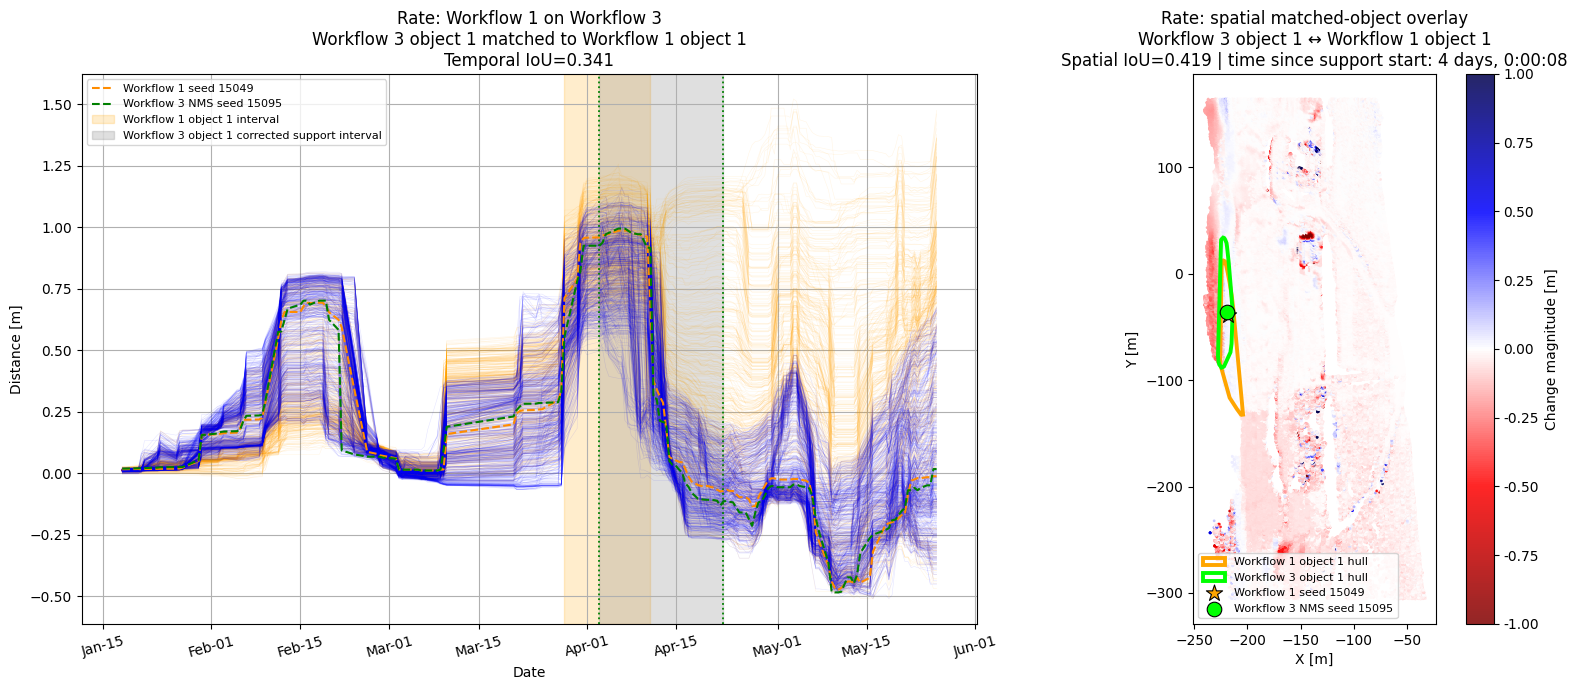

Matched Workflow 1 object: 1
Workflow 1 interval: 61 → 79 | 2017-03-28 12:00:53 → 2017-04-11 00:00:49
Workflow 3 corrected support interval: 66 → 101 | 2017-04-03 00:00:32 → 2017-04-22 12:00:15
Temporal IoU: 0.34146341463414637
Spatial IoU: 0.4189706507868992
Spatiotemporal IoU: 0.1430631490491851
Spatial intersecting corepoints: 1970

Rate | Workflow 3 object 2
No Workflow 1 object satisfies the temporal-overlap criteria. No figure was produced.


,signal,workflow3_object_number,matched_workflow1_object_number,matching_rule,workflow1_seed_corepoint,workflow3_nms_seed_corepoint,workflow1_start_epoch,workflow1_end_epoch,workflow1_start_time,workflow1_end_time,...,workflow3_support_end_time,workflow1_n_corepoints,workflow3_n_corepoints,temporal_iou,spatial_iou,spatiotemporal_iou,spatial_intersection_corepoints,background_epoch,background_time,figure_path
0,rate,1,1,highest_temporal_iou_then_spatial_iou,15049,15095,61,79,2017-03-28 12:00:53,2017-04-11 00:00:49,...,2017-04-22 12:00:15,3834,2838,0.341463,0.418971,0.143063,1970,72,2017-04-07 00:00:40,figures\cell15b_workflow1_vs_workflow3_diagnos...


Saved: tables\cell15b_workflow1_vs_workflow3_matched_objects.csv
Saved: tables\cell15b_all_workflow1_candidates_for_workflow3.csv

Cell 15B Workflow 3 diagnostics complete.
Every Workflow 3 object was independently matched to the Workflow 1 object with the highest temporal IoU.
Spatial IoU was used only as a tie-breaker.
Cell 15 objects, NMS seeds, memberships, and corrected support intervals were not modified.


In [21]:
# ============================================================
# CELL 15B — WORKFLOW 1 VS WORKFLOW 3 MATCHING DIAGNOSTICS
# HIGHEST TEMPORAL IoU MATCH, SPATIAL IoU TIE-BREAK
#
# RUN AFTER CELL 15 OR CELL 15A.

# ============================================================


# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

DIAGNOSTIC_SIGNALS = ["magnitude", "rate"]

# One-based Workflow 3 object positions to inspect.
DIAGNOSTIC_WORKFLOW3_OBJECT_NUMBERS = [1, 2]

# Require the matched objects to overlap in time.
REQUIRE_POSITIVE_TEMPORAL_OVERLAP = True

# Optional filters.
MIN_TEMPORAL_IOU = 0.30
MIN_SPATIAL_IOU = 0.30

# Plot settings.
DIAGNOSTIC_CRANGE = 1.0
MAX_MEMBER_CURVES_PER_OBJECT = 500
PLOT_MEMBER_CURVES = True
PLOT_OBJECT_MEAN_CURVES = False

# Background change-map epoch:
#   "overlap_midpoint"
#   "workflow3_midpoint"
DIAGNOSTIC_BACKGROUND_EPOCH_MODE = "overlap_midpoint"

# Outputs.
SAVE_DIAGNOSTIC_FIGURES = True
SAVE_DIAGNOSTIC_TABLE = True
SAVE_ALL_CANDIDATE_SCORES = True

workflow3_diagnostic_output_dir = (
    FIGURES_DIR / "cell15b_workflow1_vs_workflow3_diagnostics"
)
workflow3_diagnostic_output_dir.mkdir(
    exist_ok=True,
    parents=True
)


# ------------------------------------------------------------
# 2. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "timestamps_analysis",
    "corepoints",
    "original_4dobc_objects",
    "wf3_magnitude_objects",
    "wf3_rate_objects",
    "TABLES_DIR",
    "FIGURES_DIR"
]

for object_name in required_objects:
    if object_name not in globals():
        raise ValueError(
            f"{object_name} is not defined. "
            "Run the original Workflow 1 cell and Cell 15 or 15A first."
        )


# ------------------------------------------------------------
# 3. IMPORTS AND REFERENCES
# ------------------------------------------------------------

from pathlib import Path
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

diagnostic_cloud = analysis.corepoints.cloud
diagnostic_date_formatter = mdates.DateFormatter("%b-%d")

workflow3_diagnostic_inputs = {
    "magnitude": wf3_magnitude_objects,
    "rate": wf3_rate_objects
}


# ------------------------------------------------------------
# 4. GENERAL HELPERS
# ------------------------------------------------------------

def diagnostic_safe_to_csv(df, path, index=False):
    path = Path(path)

    try:
        df.to_csv(path, index=index)
        print("Saved:", path)
        return path

    except PermissionError:
        timestamp = pd.Timestamp.now().strftime(
            "%Y%m%d_%H%M%S"
        )
        backup_path = path.with_name(
            f"{path.stem}_{timestamp}{path.suffix}"
        )
        df.to_csv(backup_path, index=index)

        print("PermissionError: output file may be open.")
        print("Saved backup instead:", backup_path)

        return backup_path


def diagnostic_temporal_overlap(
    start_a,
    end_a,
    start_b,
    end_b
):
    return max(
        0,
        min(int(end_a), int(end_b))
        - max(int(start_a), int(start_b))
        + 1
    )


def diagnostic_temporal_iou(
    start_a,
    end_a,
    start_b,
    end_b
):
    intersection = diagnostic_temporal_overlap(
        start_a,
        end_a,
        start_b,
        end_b
    )

    union = (
        max(int(end_a), int(end_b))
        - min(int(start_a), int(start_b))
        + 1
    )

    return intersection / union if union > 0 else np.nan


def diagnostic_spatial_iou(indices_a, indices_b):
    set_a = set(np.asarray(indices_a, dtype=int))
    set_b = set(np.asarray(indices_b, dtype=int))

    union = set_a.union(set_b)

    if len(union) == 0:
        return np.nan

    return len(set_a.intersection(set_b)) / len(union)


def diagnostic_spatial_intersection_count(
    indices_a,
    indices_b
):
    set_a = set(np.asarray(indices_a, dtype=int))
    set_b = set(np.asarray(indices_b, dtype=int))

    return len(set_a.intersection(set_b))


def diagnostic_get_object_seed(obj):
    """
    Return the explicitly assigned Workflow 3 parent/NMS seed first,
    followed by matched_seed and then the raw py4dgeo seed.
    """
    if hasattr(obj, "parent_seed") and obj.parent_seed is not None:
        try:
            value = obj.parent_seed["corepoint_index_python"]

            if not pd.isna(value):
                return int(value)
        except Exception:
            pass

    if hasattr(obj, "matched_seed") and obj.matched_seed is not None:
        try:
            value = obj.matched_seed["corepoint_index_python"]

            if not pd.isna(value):
                return int(value)
        except Exception:
            pass

    if hasattr(obj, "seed"):
        try:
            return int(obj.seed.index)
        except Exception:
            pass

    return None


def diagnostic_get_workflow3_interval(obj):
    """
    Return the corrected Workflow 3 support-aware object interval.

    Cell 15/15A assigns corrected support epochs directly to
    obj.start_epoch and obj.end_epoch. The matched/parent seed is
    checked first for auditability, with object epochs as fallback.
    """
    start_epoch = None
    end_epoch = None

    seed = None

    if hasattr(obj, "parent_seed") and obj.parent_seed is not None:
        seed = obj.parent_seed
    elif hasattr(obj, "matched_seed") and obj.matched_seed is not None:
        seed = obj.matched_seed

    if seed is not None:
        try:
            if (
                "support_start_epoch" in seed.index
                and not pd.isna(seed["support_start_epoch"])
            ):
                start_epoch = int(seed["support_start_epoch"])
        except Exception:
            pass

        try:
            if (
                "support_end_epoch" in seed.index
                and not pd.isna(seed["support_end_epoch"])
            ):
                end_epoch = int(seed["support_end_epoch"])
        except Exception:
            pass

        if start_epoch is None:
            try:
                if (
                    "support_aware_start_epoch" in seed.index
                    and not pd.isna(
                        seed["support_aware_start_epoch"]
                    )
                ):
                    start_epoch = int(
                        seed["support_aware_start_epoch"]
                    )
            except Exception:
                pass

        if end_epoch is None:
            try:
                if (
                    "support_aware_end_epoch" in seed.index
                    and not pd.isna(
                        seed["support_aware_end_epoch"]
                    )
                ):
                    end_epoch = int(
                        seed["support_aware_end_epoch"]
                    )
            except Exception:
                pass

    if start_epoch is None:
        start_epoch = int(obj.start_epoch)

    if end_epoch is None:
        end_epoch = int(obj.end_epoch)

    max_epoch = len(timestamps_analysis) - 1

    start_epoch = max(
        0,
        min(int(start_epoch), max_epoch)
    )
    end_epoch = max(
        0,
        min(int(end_epoch), max_epoch)
    )

    if end_epoch < start_epoch:
        start_epoch, end_epoch = (
            end_epoch,
            start_epoch
        )

    return start_epoch, end_epoch


def diagnostic_get_workflow3_raw_interval(obj):
    """
    Return the pre-correction py4dgeo interval for auditing only.
    """
    raw_start = (
        int(obj.original_start_epoch)
        if hasattr(obj, "original_start_epoch")
        else int(obj.start_epoch)
    )

    raw_end = (
        int(obj.original_end_epoch)
        if hasattr(obj, "original_end_epoch")
        else int(obj.end_epoch)
    )

    max_epoch = len(timestamps_analysis) - 1

    raw_start = max(
        0,
        min(raw_start, max_epoch)
    )
    raw_end = max(
        0,
        min(raw_end, max_epoch)
    )

    if raw_end < raw_start:
        raw_start, raw_end = raw_end, raw_start

    return raw_start, raw_end


def diagnostic_add_hull(
    ax,
    indices,
    edgecolor,
    label,
    linewidth=2.5,
    linestyle="-"
):
    indices = np.asarray(indices, dtype=int)

    if len(indices) < 3:
        print(f"Too few points for hull: {label}")
        return False

    points_xy = diagnostic_cloud[indices, :2]

    try:
        hull = ConvexHull(points_xy)
        hull_xy = points_xy[hull.vertices]

        ax.add_patch(
            Polygon(
                hull_xy,
                fill=False,
                edgecolor=edgecolor,
                linewidth=linewidth,
                linestyle=linestyle,
                label=label
            )
        )

        return True

    except Exception as exc:
        print(
            f"Hull could not be created for {label}: {exc}"
        )
        return False


# ------------------------------------------------------------
# 5. SCORE ALL WORKFLOW 1 CANDIDATES
# ------------------------------------------------------------

def diagnostic_build_workflow1_candidate_table(
    signal_name,
    workflow3_object_number,
    workflow3_obj
):
    workflow3_indices = np.asarray(
        workflow3_obj.indices,
        dtype=int
    )

    workflow3_start, workflow3_end = (
        diagnostic_get_workflow3_interval(
            workflow3_obj
        )
    )

    workflow3_raw_start, workflow3_raw_end = (
        diagnostic_get_workflow3_raw_interval(
            workflow3_obj
        )
    )

    workflow3_seed = diagnostic_get_object_seed(
        workflow3_obj
    )

    records = []

    for workflow1_object_number, workflow1_obj in enumerate(
        original_4dobc_objects,
        start=1
    ):
        workflow1_indices = np.asarray(
            workflow1_obj.indices,
            dtype=int
        )

        workflow1_start = int(
            workflow1_obj.start_epoch
        )
        workflow1_end = int(
            workflow1_obj.end_epoch
        )

        temporal_overlap_epochs = (
            diagnostic_temporal_overlap(
                workflow1_start,
                workflow1_end,
                workflow3_start,
                workflow3_end
            )
        )

        temporal_iou_value = diagnostic_temporal_iou(
            workflow1_start,
            workflow1_end,
            workflow3_start,
            workflow3_end
        )

        spatial_iou_value = diagnostic_spatial_iou(
            workflow1_indices,
            workflow3_indices
        )

        spatial_intersection = (
            diagnostic_spatial_intersection_count(
                workflow1_indices,
                workflow3_indices
            )
        )

        spatiotemporal_iou_value = (
            temporal_iou_value * spatial_iou_value
            if not pd.isna(temporal_iou_value)
            and not pd.isna(spatial_iou_value)
            else np.nan
        )

        workflow1_seed = diagnostic_get_object_seed(
            workflow1_obj
        )

        records.append({
            "signal": signal_name,

            "workflow3_object_number": int(
                workflow3_object_number
            ),
            "workflow3_seed_corepoint": workflow3_seed,
            "workflow3_support_start_epoch": (
                workflow3_start
            ),
            "workflow3_support_end_epoch": (
                workflow3_end
            ),
            "workflow3_support_start_time": (
                timestamps_analysis[workflow3_start]
            ),
            "workflow3_support_end_time": (
                timestamps_analysis[workflow3_end]
            ),
            "workflow3_raw_start_epoch": (
                workflow3_raw_start
            ),
            "workflow3_raw_end_epoch": (
                workflow3_raw_end
            ),
            "workflow3_n_corepoints": len(
                workflow3_indices
            ),

            "workflow1_object_number": int(
                workflow1_object_number
            ),
            "workflow1_seed_corepoint": workflow1_seed,
            "workflow1_start_epoch": workflow1_start,
            "workflow1_end_epoch": workflow1_end,
            "workflow1_start_time": (
                timestamps_analysis[workflow1_start]
            ),
            "workflow1_end_time": (
                timestamps_analysis[workflow1_end]
            ),
            "workflow1_n_corepoints": len(
                workflow1_indices
            ),

            "temporal_overlap_epochs": (
                temporal_overlap_epochs
            ),
            "temporal_iou": temporal_iou_value,
            "spatial_intersection_corepoints": (
                spatial_intersection
            ),
            "spatial_iou": spatial_iou_value,
            "spatiotemporal_iou": (
                spatiotemporal_iou_value
            )
        })

    candidate_table = pd.DataFrame(records)

    if REQUIRE_POSITIVE_TEMPORAL_OVERLAP:
        candidate_table = candidate_table[
            candidate_table["temporal_overlap_epochs"] > 0
        ].copy()

    candidate_table = candidate_table[
        (candidate_table["temporal_iou"] >= MIN_TEMPORAL_IOU)
        & (candidate_table["spatial_iou"] >= MIN_SPATIAL_IOU)
    ].copy()

    if len(candidate_table) == 0:
        return candidate_table

    candidate_table = candidate_table.sort_values(
        [
            "temporal_iou",
            "spatial_iou",
            "spatial_intersection_corepoints"
        ],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    candidate_table["match_rank"] = np.arange(
        1,
        len(candidate_table) + 1
    )

    candidate_table["selected_match"] = (
        candidate_table["match_rank"] == 1
    )

    candidate_table["matching_rule"] = (
        "highest_temporal_iou_then_spatial_iou"
    )

    return candidate_table


def diagnostic_match_workflow1_object(
    signal_name,
    workflow3_object_number,
    workflow3_obj
):
    candidate_table = (
        diagnostic_build_workflow1_candidate_table(
            signal_name=signal_name,
            workflow3_object_number=workflow3_object_number,
            workflow3_obj=workflow3_obj
        )
    )

    if len(candidate_table) == 0:
        return None, None, candidate_table

    best_row = candidate_table.iloc[0]

    matched_workflow1_number = int(
        best_row["workflow1_object_number"]
    )

    matched_workflow1_obj = original_4dobc_objects[
        matched_workflow1_number - 1
    ]

    return (
        matched_workflow1_number,
        matched_workflow1_obj,
        candidate_table
    )


# ------------------------------------------------------------
# 6. SELECT BACKGROUND EPOCH
# ------------------------------------------------------------

def diagnostic_select_background_epoch(
    workflow1_start,
    workflow1_end,
    workflow3_start,
    workflow3_end
):
    if DIAGNOSTIC_BACKGROUND_EPOCH_MODE == "overlap_midpoint":
        overlap_start = max(
            int(workflow1_start),
            int(workflow3_start)
        )

        overlap_end = min(
            int(workflow1_end),
            int(workflow3_end)
        )

        if overlap_end >= overlap_start:
            epoch = int(
                (overlap_start + overlap_end) / 2
            )
        else:
            epoch = int(
                (int(workflow3_start)
                 + int(workflow3_end)) / 2
            )

    elif DIAGNOSTIC_BACKGROUND_EPOCH_MODE == "workflow3_midpoint":
        epoch = int(
            (int(workflow3_start)
             + int(workflow3_end)) / 2
        )

    else:
        raise ValueError(
            "DIAGNOSTIC_BACKGROUND_EPOCH_MODE must be "
            "'overlap_midpoint' or 'workflow3_midpoint'."
        )

    return max(
        0,
        min(epoch, len(timestamps_analysis) - 1)
    )


# ------------------------------------------------------------
# 7. PLOT ONE MATCHED WORKFLOW 1 / WORKFLOW 3 PAIR
# ------------------------------------------------------------

def diagnostic_plot_workflow3_matched_pair(
    signal_name,
    workflow3_objects,
    workflow3_object_number
):
    workflow3_index = int(workflow3_object_number) - 1

    if (
        workflow3_index < 0
        or workflow3_index >= len(workflow3_objects)
    ):
        print(
            f"Skipping Workflow 3 {signal_name} object "
            f"{workflow3_object_number}: only "
            f"{len(workflow3_objects)} objects are available."
        )
        return None, pd.DataFrame()

    workflow3_obj = workflow3_objects[
        workflow3_index
    ]

    (
        workflow1_object_number,
        workflow1_obj,
        candidate_table
    ) = diagnostic_match_workflow1_object(
        signal_name=signal_name,
        workflow3_object_number=workflow3_object_number,
        workflow3_obj=workflow3_obj
    )

    print("\n====================================================")
    print(
        f"{signal_name.capitalize()} | "
        f"Workflow 3 object {workflow3_object_number}"
    )
    print("====================================================")

    if workflow1_obj is None:
        print(
            "No Workflow 1 object satisfies the temporal-overlap "
            "criteria. No figure was produced."
        )
        return None, candidate_table

    workflow1_indices = np.asarray(
        workflow1_obj.indices,
        dtype=int
    )

    workflow3_indices = np.asarray(
        workflow3_obj.indices,
        dtype=int
    )

    workflow1_start = int(
        workflow1_obj.start_epoch
    )
    workflow1_end = int(
        workflow1_obj.end_epoch
    )

    workflow3_start, workflow3_end = (
        diagnostic_get_workflow3_interval(
            workflow3_obj
        )
    )

    workflow1_seed = diagnostic_get_object_seed(
        workflow1_obj
    )

    workflow3_seed = diagnostic_get_object_seed(
        workflow3_obj
    )

    temporal_iou_value = diagnostic_temporal_iou(
        workflow1_start,
        workflow1_end,
        workflow3_start,
        workflow3_end
    )

    spatial_iou_value = diagnostic_spatial_iou(
        workflow1_indices,
        workflow3_indices
    )

    spatial_intersection = (
        diagnostic_spatial_intersection_count(
            workflow1_indices,
            workflow3_indices
        )
    )

    spatiotemporal_iou_value = (
        temporal_iou_value * spatial_iou_value
        if not pd.isna(temporal_iou_value)
        and not pd.isna(spatial_iou_value)
        else np.nan
    )

    epoch_of_interest = (
        diagnostic_select_background_epoch(
            workflow1_start,
            workflow1_end,
            workflow3_start,
            workflow3_end
        )
    )

    magnitudes_of_interest = (
        analysis.smoothed_distances[:, epoch_of_interest]
        - analysis.smoothed_distances[:, workflow3_start]
    )

    fig, (ax_time, ax_space) = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        gridspec_kw={"width_ratios": [1.5, 1.0]}
    )

    # --------------------------------------------------------
    # TEMPORAL PANEL
    # --------------------------------------------------------

    if PLOT_MEMBER_CURVES:
        workflow1_step = max(
            1,
            len(workflow1_indices)
            // max(1, MAX_MEMBER_CURVES_PER_OBJECT)
        )

        workflow3_step = max(
            1,
            len(workflow3_indices)
            // max(1, MAX_MEMBER_CURVES_PER_OBJECT)
        )

        for cp_idx in workflow1_indices[::workflow1_step]:
            ax_time.plot(
                timestamps_analysis,
                analysis.smoothed_distances[cp_idx],
                color="orange",
                linewidth=0.4,
                alpha=0.10
            )

        for cp_idx in workflow3_indices[::workflow3_step]:
            ax_time.plot(
                timestamps_analysis,
                analysis.smoothed_distances[cp_idx],
                color="blue",
                linewidth=0.4,
                alpha=0.10
            )

    if PLOT_OBJECT_MEAN_CURVES:
        workflow1_mean = np.nanmean(
            analysis.smoothed_distances[
                workflow1_indices,
                :
            ],
            axis=0
        )

        workflow3_mean = np.nanmean(
            analysis.smoothed_distances[
                workflow3_indices,
                :
            ],
            axis=0
        )

        ax_time.plot(
            timestamps_analysis,
            workflow1_mean,
            color="orange",
            linewidth=2.3,
            label=(
                f"Workflow 1 object "
                f"{workflow1_object_number} mean"
            )
        )

        ax_time.plot(
            timestamps_analysis,
            workflow3_mean,
            color="blue",
            linewidth=2.3,
            label=(
                f"Workflow 3 object "
                f"{workflow3_object_number} mean"
            )
        )

    if workflow1_seed is not None:
        ax_time.plot(
            timestamps_analysis,
            analysis.smoothed_distances[workflow1_seed],
            color="darkorange",
            linestyle="--",
            linewidth=1.5,
            label=f"Workflow 1 seed {workflow1_seed}"
        )

    if workflow3_seed is not None:
        ax_time.plot(
            timestamps_analysis,
            analysis.smoothed_distances[workflow3_seed],
            color="green",
            linestyle="--",
            linewidth=1.5,
            label=(
                f"Workflow 3 NMS seed {workflow3_seed}"
            )
        )

    ax_time.axvspan(
        timestamps_analysis[workflow1_start],
        timestamps_analysis[workflow1_end],
        color="orange",
        alpha=0.20,
        label=(
            f"Workflow 1 object "
            f"{workflow1_object_number} interval"
        )
    )

    ax_time.axvspan(
        timestamps_analysis[workflow3_start],
        timestamps_analysis[workflow3_end],
        color="grey",
        alpha=0.25,
        label=(
            f"Workflow 3 object "
            f"{workflow3_object_number} corrected support interval"
        )
    )

    ax_time.axvline(
        timestamps_analysis[workflow3_start],
        color="green",
        linestyle=":",
        linewidth=1.3
    )

    ax_time.axvline(
        timestamps_analysis[workflow3_end],
        color="green",
        linestyle=":",
        linewidth=1.3
    )

    ax_time.set_title(
        f"{signal_name.capitalize()}: Workflow 1 on Workflow 3\n"
        f"Workflow 3 object {workflow3_object_number} matched to "
        f"Workflow 1 object {workflow1_object_number}\n"
        f"Temporal IoU={temporal_iou_value:.3f}"
    )

    ax_time.set_xlabel("Date")
    ax_time.set_ylabel("Distance [m]")
    ax_time.xaxis.set_major_formatter(
        diagnostic_date_formatter
    )
    ax_time.tick_params(axis="x", rotation=15)
    ax_time.grid(True)
    ax_time.legend(fontsize=8, loc="best")

    # --------------------------------------------------------
    # SPATIAL PANEL
    # --------------------------------------------------------

    background = ax_space.scatter(
        diagnostic_cloud[:, 0],
        diagnostic_cloud[:, 1],
        c=magnitudes_of_interest,
        cmap="seismic_r",
        vmin=-DIAGNOSTIC_CRANGE,
        vmax=DIAGNOSTIC_CRANGE,
        s=1,
        alpha=0.85
    )

    plt.colorbar(
        background,
        ax=ax_space,
        format="%.2f",
        label="Change magnitude [m]"
    )

    diagnostic_add_hull(
        ax=ax_space,
        indices=workflow1_indices,
        edgecolor="orange",
        label=(
            f"Workflow 1 object "
            f"{workflow1_object_number} hull"
        ),
        linewidth=2.8
    )

    diagnostic_add_hull(
        ax=ax_space,
        indices=workflow3_indices,
        edgecolor="lime",
        label=(
            f"Workflow 3 object "
            f"{workflow3_object_number} hull"
        ),
        linewidth=2.8
    )

    if workflow1_seed is not None:
        ax_space.scatter(
            diagnostic_cloud[workflow1_seed, 0],
            diagnostic_cloud[workflow1_seed, 1],
            marker="*",
            s=150,
            c="orange",
            edgecolors="black",
            linewidths=0.8,
            label=f"Workflow 1 seed {workflow1_seed}"
        )

    if workflow3_seed is not None:
        ax_space.scatter(
            diagnostic_cloud[workflow3_seed, 0],
            diagnostic_cloud[workflow3_seed, 1],
            marker="o",
            s=110,
            c="lime",
            edgecolors="black",
            linewidths=0.8,
            label=(
                f"Workflow 3 NMS seed {workflow3_seed}"
            )
        )

    elapsed_time = (
        timestamps_analysis[epoch_of_interest]
        - timestamps_analysis[workflow3_start]
    )

    ax_space.set_title(
        f"{signal_name.capitalize()}: spatial matched-object overlay\n"
        f"Workflow 3 object {workflow3_object_number} ↔ "
        f"Workflow 1 object {workflow1_object_number}\n"
        f"Spatial IoU={spatial_iou_value:.3f} | "
        f"time since support start: {elapsed_time}"
    )

    ax_space.set_xlabel("X [m]")
    ax_space.set_ylabel("Y [m]")
    ax_space.set_aspect("equal")
    ax_space.legend(fontsize=8, loc="best")

    plt.tight_layout()

    figure_path = workflow3_diagnostic_output_dir / (
        f"cell15b_{signal_name}_workflow3_object_"
        f"{workflow3_object_number}_matched_workflow1_object_"
        f"{workflow1_object_number}.png"
    )

    if SAVE_DIAGNOSTIC_FIGURES:
        plt.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        print("Saved:", figure_path)

    plt.show()

    print(
        "Matched Workflow 1 object:",
        workflow1_object_number
    )
    print(
        "Workflow 1 interval:",
        workflow1_start,
        "→",
        workflow1_end,
        "|",
        timestamps_analysis[workflow1_start],
        "→",
        timestamps_analysis[workflow1_end]
    )
    print(
        "Workflow 3 corrected support interval:",
        workflow3_start,
        "→",
        workflow3_end,
        "|",
        timestamps_analysis[workflow3_start],
        "→",
        timestamps_analysis[workflow3_end]
    )
    print("Temporal IoU:", temporal_iou_value)
    print("Spatial IoU:", spatial_iou_value)
    print(
        "Spatiotemporal IoU:",
        spatiotemporal_iou_value
    )
    print(
        "Spatial intersecting corepoints:",
        spatial_intersection
    )

    result_record = {
        "signal": signal_name,

        "workflow3_object_number": int(
            workflow3_object_number
        ),
        "matched_workflow1_object_number": int(
            workflow1_object_number
        ),

        "matching_rule": (
            "highest_temporal_iou_then_spatial_iou"
        ),

        "workflow1_seed_corepoint": workflow1_seed,
        "workflow3_nms_seed_corepoint": workflow3_seed,

        "workflow1_start_epoch": workflow1_start,
        "workflow1_end_epoch": workflow1_end,
        "workflow1_start_time": (
            timestamps_analysis[workflow1_start]
        ),
        "workflow1_end_time": (
            timestamps_analysis[workflow1_end]
        ),

        "workflow3_support_start_epoch": workflow3_start,
        "workflow3_support_end_epoch": workflow3_end,
        "workflow3_support_start_time": (
            timestamps_analysis[workflow3_start]
        ),
        "workflow3_support_end_time": (
            timestamps_analysis[workflow3_end]
        ),

        "workflow1_n_corepoints": len(
            workflow1_indices
        ),
        "workflow3_n_corepoints": len(
            workflow3_indices
        ),

        "temporal_iou": temporal_iou_value,
        "spatial_iou": spatial_iou_value,
        "spatiotemporal_iou": (
            spatiotemporal_iou_value
        ),
        "spatial_intersection_corepoints": (
            spatial_intersection
        ),

        "background_epoch": epoch_of_interest,
        "background_time": (
            timestamps_analysis[epoch_of_interest]
        ),
        "figure_path": str(figure_path)
    }

    return result_record, candidate_table


# ------------------------------------------------------------
# 8. RUN DIAGNOSTICS
# ------------------------------------------------------------

workflow3_matched_pair_records = []
workflow3_all_candidate_tables = []

for signal_name in DIAGNOSTIC_SIGNALS:

    if signal_name not in workflow3_diagnostic_inputs:
        raise ValueError(
            f"Unsupported signal: {signal_name}"
        )

    workflow3_objects = workflow3_diagnostic_inputs[
        signal_name
    ]

    for workflow3_object_number in (
        DIAGNOSTIC_WORKFLOW3_OBJECT_NUMBERS
    ):
        (
            result_record,
            candidate_table
        ) = diagnostic_plot_workflow3_matched_pair(
            signal_name=signal_name,
            workflow3_objects=workflow3_objects,
            workflow3_object_number=workflow3_object_number
        )

        if result_record is not None:
            workflow3_matched_pair_records.append(
                result_record
            )

        if len(candidate_table) > 0:
            workflow3_all_candidate_tables.append(
                candidate_table
            )


# ------------------------------------------------------------
# 9. SAVE SUMMARY TABLES
# ------------------------------------------------------------

cell15b_workflow3_matched_object_summary = pd.DataFrame(
    workflow3_matched_pair_records
)

display(cell15b_workflow3_matched_object_summary)

if SAVE_DIAGNOSTIC_TABLE:
    diagnostic_safe_to_csv(
        cell15b_workflow3_matched_object_summary,
        TABLES_DIR
        / "cell15b_workflow1_vs_workflow3_matched_objects.csv",
        index=False
    )

if workflow3_all_candidate_tables:
    cell15b_all_workflow1_candidate_scores = pd.concat(
        workflow3_all_candidate_tables,
        ignore_index=True
    )
else:
    cell15b_all_workflow1_candidate_scores = (
        pd.DataFrame()
    )

if SAVE_ALL_CANDIDATE_SCORES:
    diagnostic_safe_to_csv(
        cell15b_all_workflow1_candidate_scores,
        TABLES_DIR
        / "cell15b_all_workflow1_candidates_for_workflow3.csv",
        index=False
    )

print("\nCell 15B Workflow 3 diagnostics complete.")
print(
    "Every Workflow 3 object was independently matched to "
    "the Workflow 1 object with the highest temporal IoU."
)
print(
    "Spatial IoU was used only as a tie-breaker."
)
print(
    "Cell 15 objects, NMS seeds, memberships, and corrected "
    "support intervals were not modified."
)


Workflow 3 diagnostic for signal: magnitude

Matched NMS events for magnitude:


,signal,reference_corepoint_index,visualization_corepoint_index,target_event_start,target_event_end,direction,matched_nms_corepoint,matched_nms_rank,matched_nms_start,matched_nms_end,distance_to_visualisation_corepoint_m,match_type
0,magnitude,15162,15162,48,86,positive,15199,77,49,86,2.240591,nearest_neighbour_nms_seed
1,magnitude,15162,15162,5,40,positive,15184,48,5,39,1.199661,nearest_neighbour_nms_seed
2,magnitude,15162,15162,87,153,negative,15174,81,91,153,2.065555,nearest_neighbour_nms_seed


Saved NMS fallback seed plot:
figures\workflow3_improved_nms_diagnostics\workflow3_magnitude_auto_fallback_nms_seeds_visualcp_15162.png


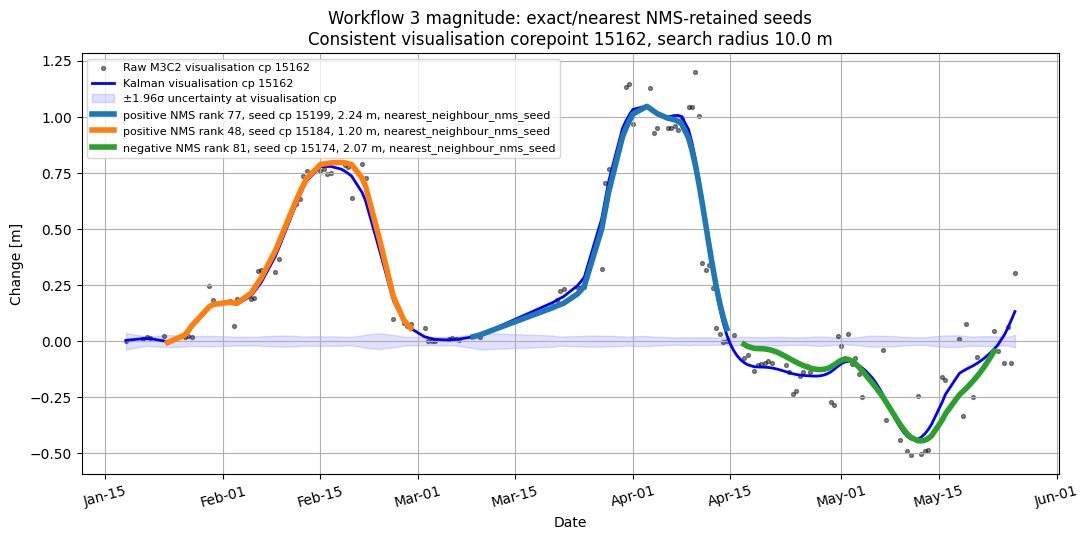

Workflow 3 object number: 1
Reference corepoint: 15162
Visualisation corepoint: 15162
Object-generating NMS seed corepoint: 15579
Object selection reason: visualisation corepoint membership
Corrected object start: 89
Corrected object end: 158
Raw py4dgeo object start: 89
Raw py4dgeo object end: 158
Saved Workflow 3 object-style figure:
figures\workflow3_improved_nms_diagnostics\workflow3_magnitude_4dobc_object_1_visualcp_15162.png


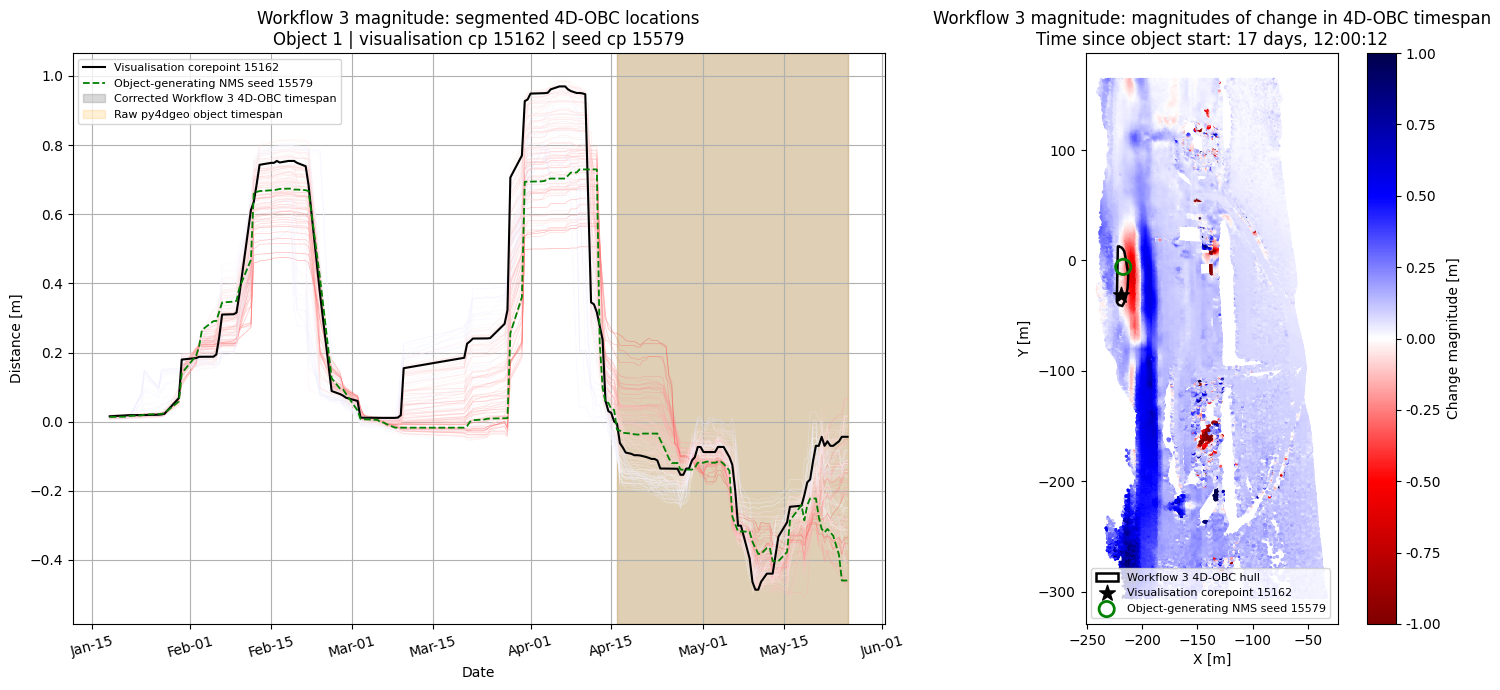

,signal,reference_corepoint_index,visualization_corepoint_index,object_generating_nms_seed_corepoint,object_generating_nms_seed_rank,object_generating_nms_seed_start_epoch,object_generating_nms_seed_end_epoch,object_generating_nms_seed_direction,object_generating_nms_seed_event_magnitude,object_selection_reason,workflow3_object_number,corrected_start_epoch,corrected_end_epoch,corrected_duration_epochs,raw_py4dgeo_start_epoch,raw_py4dgeo_end_epoch,n_corepoints,epoch_of_interest,search_radius_m
0,magnitude,15162,15162,15579,1,89,158,negative,0.412201,visualisation corepoint membership,1,89,158,70,89,158,1190,123,10.0



Workflow 3 diagnostic for signal: rate
No NMS match found within 10.0 m for rate negative event 29–39

Matched NMS events for rate:


,signal,reference_corepoint_index,visualization_corepoint_index,target_event_start,target_event_end,direction,matched_nms_corepoint,matched_nms_rank,matched_nms_start,matched_nms_end,distance_to_visualisation_corepoint_m,match_type
0,rate,15162,15162,56,65,positive,15184,24,56,65,1.199661,nearest_neighbour_nms_seed
1,rate,15162,15162,14,24,positive,15196,61,14,24,1.748849,nearest_neighbour_nms_seed
2,rate,15162,15162,122,135,negative,15166,90,120,135,1.329149,nearest_neighbour_nms_seed
3,rate,15162,15162,136,158,positive,15147,53,137,158,1.775086,nearest_neighbour_nms_seed
4,rate,15162,15162,74,92,negative,15175,6,74,92,0.579159,nearest_neighbour_nms_seed


Saved NMS fallback seed plot:
figures\workflow3_improved_nms_diagnostics\workflow3_rate_auto_fallback_nms_seeds_visualcp_15162.png


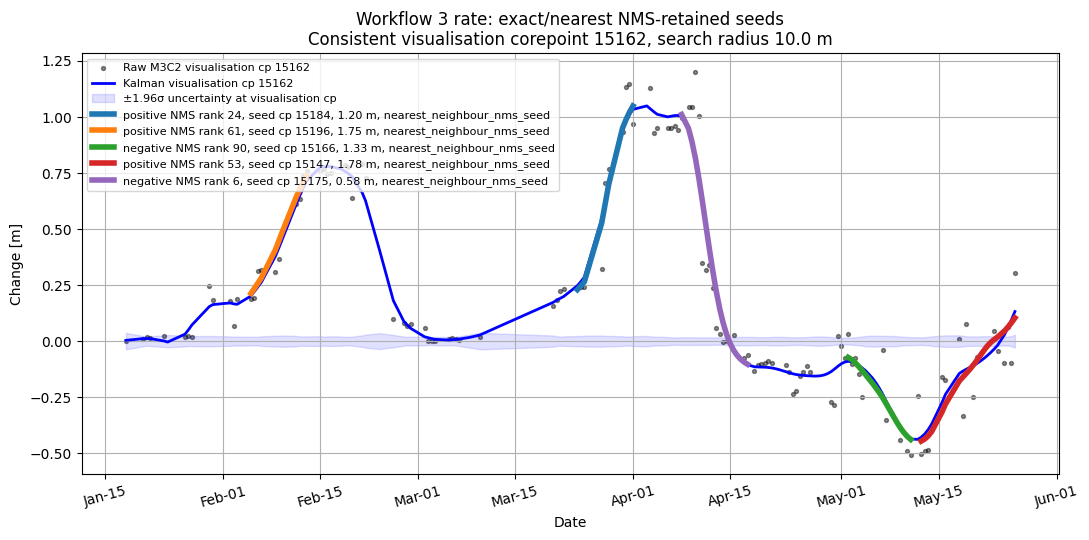

Workflow 3 object number: 1
Reference corepoint: 15162
Visualisation corepoint: 15162
Object-generating NMS seed corepoint: 15095
Object selection reason: visualisation corepoint membership
Corrected object start: 66
Corrected object end: 101
Raw py4dgeo object start: 66
Raw py4dgeo object end: 101
Saved Workflow 3 object-style figure:
figures\workflow3_improved_nms_diagnostics\workflow3_rate_4dobc_object_1_visualcp_15162.png


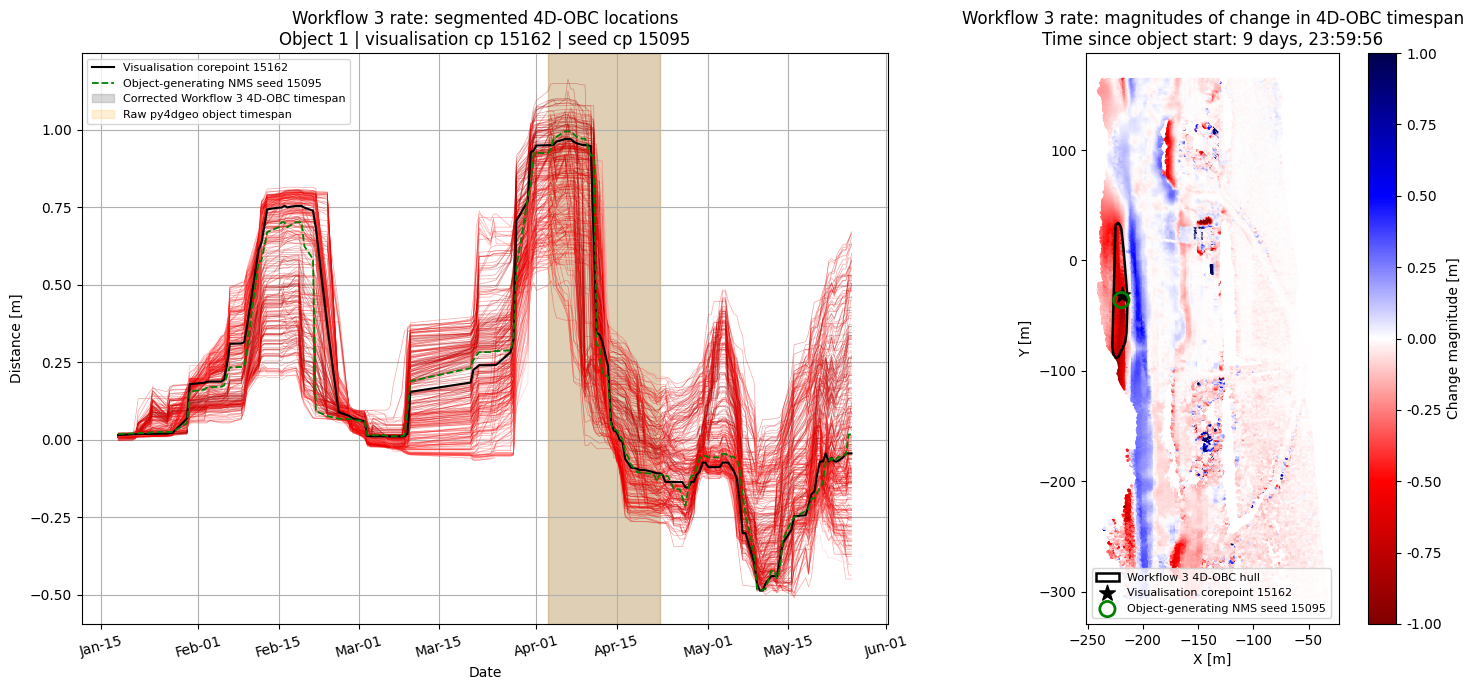

,signal,reference_corepoint_index,visualization_corepoint_index,object_generating_nms_seed_corepoint,object_generating_nms_seed_rank,object_generating_nms_seed_start_epoch,object_generating_nms_seed_end_epoch,object_generating_nms_seed_direction,object_generating_nms_seed_event_magnitude,object_selection_reason,workflow3_object_number,corrected_start_epoch,corrected_end_epoch,corrected_duration_epochs,raw_py4dgeo_start_epoch,raw_py4dgeo_end_epoch,n_corepoints,epoch_of_interest,search_radius_m
0,rate,15162,15162,15095,1,66,101,negative,0.167802,visualisation corepoint membership,1,66,101,36,66,101,2838,83,10.0


,signal,reference_corepoint_index,visualization_corepoint_index,object_generating_nms_seed_corepoint,object_generating_nms_seed_rank,object_generating_nms_seed_start_epoch,object_generating_nms_seed_end_epoch,object_generating_nms_seed_direction,object_generating_nms_seed_event_magnitude,object_selection_reason,workflow3_object_number,corrected_start_epoch,corrected_end_epoch,corrected_duration_epochs,raw_py4dgeo_start_epoch,raw_py4dgeo_end_epoch,n_corepoints,epoch_of_interest,search_radius_m
0,magnitude,15162,15162,15579,1,89,158,negative,0.412201,visualisation corepoint membership,1,89,158,70,89,158,1190,123,10.0
1,rate,15162,15162,15095,1,66,101,negative,0.167802,visualisation corepoint membership,1,66,101,36,66,101,2838,83,10.0



Workflow 3 auto-fallback diagnostic complete for both magnitude and rate.


In [22]:
# ============================================================
# DIAGNOSTIC — WORKFLOW 3 AUTO-FALLBACK NMS SEED SEARCH + OBJECT
# ============================================================

REFERENCE_COREPOINT_INDEX = 15162
VISUALIZATION_COREPOINT_INDEX = 15162
TARGET_COREPOINT_INDEX = VISUALIZATION_COREPOINT_INDEX

MAX_SEARCH_RADIUS = 10.0
CRANGE = 1.0
SAVE_WORKFLOW3_FIGURES = True

WORKFLOW3_SIGNALS_TO_PLOT = ["magnitude", "rate"]

workflow3_fig_dir = FIGURES_DIR / "workflow3_improved_nms_diagnostics"
workflow3_fig_dir.mkdir(exist_ok=True, parents=True)


# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "corepoints",
    "kalman_change",
    "kalman_sigma_change",
    "analysis",
    "timestamps_analysis",
    "wf3_magnitude_nms_seed_table",
    "wf3_rate_nms_seed_table",
    "improved_seed_table_magnitude",
    "improved_seed_table_rate",
    "wf3_magnitude_objects",
    "wf3_rate_objects"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run revised Cells 14 and 15 first."
        )


# ------------------------------------------------------------
# 2. IMPORTS AND HELPERS
# ------------------------------------------------------------

from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

dtFmt = mdates.DateFormatter("%b-%d")
cloud = analysis.corepoints.cloud


def find_object_containing_corepoint(objects, cp_idx):

    for obj_number, obj in enumerate(objects, start=1):
        indices = np.array(obj.indices, dtype=int)

        if int(cp_idx) in indices:
            return obj_number, obj

    return None, None


def draw_hull(ax, obj, color="black", label="4D-OBC hull"):

    idxs = np.array(obj.indices, dtype=int)
    xy = cloud[idxs, :2]

    if xy.shape[0] < 3:
        return

    try:
        hull = ConvexHull(xy)

        ax.add_patch(
            Polygon(
                xy[hull.vertices],
                fill=False,
                edgecolor=color,
                linewidth=1.8,
                label=label
            )
        )

    except Exception as e:
        print("Convex hull could not be created:", e)


def get_workflow3_signal_data(signal_name):

    if signal_name == "magnitude":

        return {
            "signal": "magnitude",
            "nms_seed_table": wf3_magnitude_nms_seed_table,
            "improved_seed_table": improved_seed_table_magnitude,
            "objects": wf3_magnitude_objects,
            "raw_objects": (
                wf3_magnitude_objects_raw
                if "wf3_magnitude_objects_raw" in globals()
                else None
            )
        }

    elif signal_name == "rate":

        return {
            "signal": "rate",
            "nms_seed_table": wf3_rate_nms_seed_table,
            "improved_seed_table": improved_seed_table_rate,
            "objects": wf3_rate_objects,
            "raw_objects": (
                wf3_rate_objects_raw
                if "wf3_rate_objects_raw" in globals()
                else None
            )
        }

    else:
        raise ValueError("signal_name must be 'magnitude' or 'rate'.")


def find_nearest_nms_for_target_event(
    target_event,
    nms_table,
    target_xy,
    max_radius
):

    event_start = int(target_event["start_epoch"])
    event_end = int(target_event["end_epoch"])
    event_direction = target_event["direction"]

    candidates = nms_table.copy()

    candidates["distance_to_visualisation_corepoint_m"] = candidates[
        "corepoint_index_python"
    ].apply(
        lambda idx: float(
            np.linalg.norm(corepoints[int(idx), :2] - target_xy)
        )
    )

    candidates = candidates[
        (candidates["distance_to_visualisation_corepoint_m"] <= max_radius) &
        (candidates["direction"] == event_direction) &
        (candidates["start_epoch"] <= event_end) &
        (candidates["end_epoch"] >= event_start)
    ].copy()

    if len(candidates) == 0:
        return None

    exact = candidates[
        candidates["corepoint_index_python"] == VISUALIZATION_COREPOINT_INDEX
    ]

    if len(exact) > 0:
        return exact.sort_values("nms_rank").iloc[0]

    return candidates.sort_values("distance_to_visualisation_corepoint_m").iloc[0]


def get_object_generating_seed_info(obj):

    if hasattr(obj, "matched_seed") and obj.matched_seed is not None:

        return {
            "corepoint": int(obj.matched_seed["corepoint_index_python"]),
            "start_epoch": int(obj.matched_seed["start_epoch"]),
            "end_epoch": int(obj.matched_seed["end_epoch"]),
            "direction": obj.matched_seed["direction"],
            "event_magnitude": (
                float(obj.matched_seed["event_magnitude"])
                if "event_magnitude" in obj.matched_seed
                else np.nan
            ),
            "nms_rank": (
                int(obj.matched_seed["nms_rank"])
                if "nms_rank" in obj.matched_seed
                and not pd.isna(obj.matched_seed["nms_rank"])
                else np.nan
            )
        }

    return {
        "corepoint": np.nan,
        "start_epoch": np.nan,
        "end_epoch": np.nan,
        "direction": None,
        "event_magnitude": np.nan,
        "nms_rank": np.nan
    }


def run_auto_fallback_diagnostic_for_signal(signal_name):

    print("\n==========================================")
    print(f"Workflow 3 diagnostic for signal: {signal_name}")
    print("==========================================")

    signal_data = get_workflow3_signal_data(signal_name)

    selected_signal = signal_data["signal"]
    selected_nms_seed_table = signal_data["nms_seed_table"]
    selected_improved_seed_table = signal_data["improved_seed_table"]
    selected_objects = signal_data["objects"]

    if selected_nms_seed_table is None or len(selected_nms_seed_table) == 0:
        print(f"No NMS seeds available for {selected_signal}. Skipping.")
        return None

    if selected_improved_seed_table is None or len(selected_improved_seed_table) == 0:
        print(f"No improved seeds available for {selected_signal}. Skipping.")
        return None

    if selected_objects is None or len(selected_objects) == 0:
        print(f"No Workflow 3 objects available for {selected_signal}. Skipping.")
        return None

    visualisation_xy = corepoints[VISUALIZATION_COREPOINT_INDEX, :2]

    target_events = selected_improved_seed_table[
        selected_improved_seed_table["corepoint_index_python"]
        == VISUALIZATION_COREPOINT_INDEX
    ].copy()

    if len(target_events) == 0:
        print(
            f"No improved seeds found at visualisation corepoint "
            f"{VISUALIZATION_COREPOINT_INDEX} for {selected_signal}. Skipping."
        )
        return None

    matched_records = []

    for _, event in target_events.iterrows():

        nearest = find_nearest_nms_for_target_event(
            target_event=event,
            nms_table=selected_nms_seed_table,
            target_xy=visualisation_xy,
            max_radius=MAX_SEARCH_RADIUS
        )

        event_start = int(event["start_epoch"])
        event_end = int(event["end_epoch"])
        event_direction = event["direction"]

        if nearest is None:
            print(
                f"No NMS match found within {MAX_SEARCH_RADIUS} m for "
                f"{selected_signal} {event_direction} event {event_start}–{event_end}"
            )
            continue

        nearest_cp = int(nearest["corepoint_index_python"])

        if nearest_cp == VISUALIZATION_COREPOINT_INDEX:
            match_type = "exact_visualisation_corepoint_nms_seed"
        else:
            match_type = "nearest_neighbour_nms_seed"

        matched_records.append({
            "signal": selected_signal,
            "reference_corepoint_index": REFERENCE_COREPOINT_INDEX,
            "visualization_corepoint_index": VISUALIZATION_COREPOINT_INDEX,
            "target_event_start": event_start,
            "target_event_end": event_end,
            "direction": event_direction,
            "matched_nms_corepoint": nearest_cp,
            "matched_nms_rank": int(nearest["nms_rank"]),
            "matched_nms_start": int(nearest["start_epoch"]),
            "matched_nms_end": int(nearest["end_epoch"]),
            "distance_to_visualisation_corepoint_m": float(
                nearest["distance_to_visualisation_corepoint_m"]
            ),
            "match_type": match_type
        })

    matched_nms_events = pd.DataFrame(matched_records)

    print(f"\nMatched NMS events for {selected_signal}:")
    display(matched_nms_events)

    if len(matched_nms_events) == 0:
        print(f"No matched NMS events for {selected_signal}. Skipping plots.")
        return None

    matched_nms_events.to_csv(
        TABLES_DIR / (
            f"workflow3_{selected_signal}_auto_fallback_nms_matches_"
            f"visualcp_{VISUALIZATION_COREPOINT_INDEX}.csv"
        ),
        index=False
    )

    # --------------------------------------------------------
    # PLOT A — NMS SEEDS AROUND CONSISTENT COREPOINT 15162
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.scatter(
        timestamps_analysis,
        analysis.distances[VISUALIZATION_COREPOINT_INDEX],
        s=8,
        color="black",
        alpha=0.45,
        label=f"Raw M3C2 visualisation cp {VISUALIZATION_COREPOINT_INDEX}"
    )

    ax.plot(
        timestamps_analysis,
        kalman_change[VISUALIZATION_COREPOINT_INDEX],
        color="blue",
        linewidth=2,
        label=f"Kalman visualisation cp {VISUALIZATION_COREPOINT_INDEX}"
    )

    upper_lod = 1.96 * kalman_sigma_change[VISUALIZATION_COREPOINT_INDEX]
    lower_lod = -1.96 * kalman_sigma_change[VISUALIZATION_COREPOINT_INDEX]

    ax.fill_between(
        timestamps_analysis,
        lower_lod,
        upper_lod,
        color="blue",
        alpha=0.12,
        label="±1.96σ uncertainty at visualisation cp"
    )

    for _, row in matched_nms_events.iterrows():

        matched_cp = int(row["matched_nms_corepoint"])
        s = int(row["matched_nms_start"])
        e = int(row["matched_nms_end"])
        rank = int(row["matched_nms_rank"])
        direction = row["direction"]
        dist = row["distance_to_visualisation_corepoint_m"]
        match_type = row["match_type"]

        ax.plot(
            timestamps_analysis[s:e + 1],
            kalman_change[matched_cp, s:e + 1],
            linewidth=4,
            label=(
                f"{direction} NMS rank {rank}, "
                f"seed cp {matched_cp}, {dist:.2f} m, {match_type}"
            )
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Change [m]")
    ax.tick_params(axis="x", rotation=15)

    ax.set_title(
        f"Workflow 3 {selected_signal}: exact/nearest NMS-retained seeds\n"
        f"Consistent visualisation corepoint {VISUALIZATION_COREPOINT_INDEX}, "
        f"search radius {MAX_SEARCH_RADIUS} m"
    )

    ax.xaxis.set_major_formatter(dtFmt)
    ax.grid(True)
    ax.legend(fontsize=8)

    plt.tight_layout()

    if SAVE_WORKFLOW3_FIGURES:

        fig_path = workflow3_fig_dir / (
            f"workflow3_{selected_signal}_auto_fallback_nms_seeds_"
            f"visualcp_{VISUALIZATION_COREPOINT_INDEX}.png"
        )

        plt.savefig(
            fig_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        print("Saved NMS fallback seed plot:")
        print(fig_path)

    plt.show()

    # --------------------------------------------------------
    # FIND WORKFLOW 3 OBJECT
    # --------------------------------------------------------

    workflow3_object_number, workflow3_obj = find_object_containing_corepoint(
        selected_objects,
        VISUALIZATION_COREPOINT_INDEX
    )

    object_selection_reason = "visualisation corepoint membership"

    if workflow3_obj is None:

        matched_cp = int(matched_nms_events.iloc[0]["matched_nms_corepoint"])

        workflow3_object_number, workflow3_obj = find_object_containing_corepoint(
            selected_objects,
            matched_cp
        )

        object_selection_reason = "matched NMS seed membership"

    if workflow3_obj is None:
        print(
            f"No Workflow 3 {selected_signal} object contains the visualisation "
            "corepoint or matched NMS seed. Skipping object plot."
        )
        return None

    object_generating_seed_info = get_object_generating_seed_info(workflow3_obj)
    object_generating_cp = object_generating_seed_info["corepoint"]

    print("Workflow 3 object number:", workflow3_object_number)
    print("Reference corepoint:", REFERENCE_COREPOINT_INDEX)
    print("Visualisation corepoint:", VISUALIZATION_COREPOINT_INDEX)
    print("Object-generating NMS seed corepoint:", object_generating_cp)
    print("Object selection reason:", object_selection_reason)
    print("Corrected object start:", int(workflow3_obj.start_epoch))
    print("Corrected object end:", int(workflow3_obj.end_epoch))

    if hasattr(workflow3_obj, "original_start_epoch"):
        print("Raw py4dgeo object start:", int(workflow3_obj.original_start_epoch))
        print("Raw py4dgeo object end:", int(workflow3_obj.original_end_epoch))

    # --------------------------------------------------------
    # PLOT B — OBJECT STYLE FIGURE
    # --------------------------------------------------------

    idxs = np.array(workflow3_obj.indices, dtype=int)

    start_epoch = int(workflow3_obj.start_epoch)
    end_epoch = int(workflow3_obj.end_epoch)
    epoch_of_interest = int((start_epoch + end_epoch) / 2)

    magnitudes_of_interest = (
        analysis.smoothed_distances[:, epoch_of_interest]
        - analysis.smoothed_distances[:, start_epoch]
    )

    visualisation_timeseries = analysis.smoothed_distances[
        VISUALIZATION_COREPOINT_INDEX
    ]

    if not pd.isna(object_generating_cp):
        generating_seed_timeseries = analysis.smoothed_distances[
            int(object_generating_cp)
        ]
    else:
        generating_seed_timeseries = None

    cmap = plt.get_cmap("seismic_r").copy()
    norm = mcolors.CenteredNorm(halfrange=CRANGE)
    cmapvals = norm(magnitudes_of_interest)

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(15, 7),
        gridspec_kw={"width_ratios": [1.4, 1.0]}
    )

    ax1, ax2 = axs

    for idx in idxs[::10]:
        ax1.plot(
            timestamps_analysis,
            analysis.smoothed_distances[idx],
            c=cmap(cmapvals[idx]),
            linewidth=0.5,
            alpha=0.35
        )

    # Always plot corepoint 15162 as the main visualisation curve
    ax1.plot(
        timestamps_analysis,
        visualisation_timeseries,
        c="black",
        linewidth=1.5,
        label=f"Visualisation corepoint {VISUALIZATION_COREPOINT_INDEX}"
    )

    # Show object-generating NMS seed separately
    if (
        generating_seed_timeseries is not None
        and int(object_generating_cp) != VISUALIZATION_COREPOINT_INDEX
    ):
        ax1.plot(
            timestamps_analysis,
            generating_seed_timeseries,
            c="green",
            linestyle="--",
            linewidth=1.3,
            label=f"Object-generating NMS seed {int(object_generating_cp)}"
        )

    ax1.axvspan(
        timestamps_analysis[start_epoch],
        timestamps_analysis[end_epoch],
        alpha=0.30,
        color="grey",
        label="Corrected Workflow 3 4D-OBC timespan"
    )

    if hasattr(workflow3_obj, "original_start_epoch"):
        ax1.axvspan(
            timestamps_analysis[int(workflow3_obj.original_start_epoch)],
            timestamps_analysis[int(workflow3_obj.original_end_epoch)],
            alpha=0.16,
            color="orange",
            label="Raw py4dgeo object timespan"
        )

    ax1.set_title(
        f"Workflow 3 {selected_signal}: segmented 4D-OBC locations\n"
        f"Object {workflow3_object_number} | visualisation cp "
        f"{VISUALIZATION_COREPOINT_INDEX} | seed cp {object_generating_cp}"
    )

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Distance [m]")
    ax1.xaxis.set_major_formatter(dtFmt)
    ax1.tick_params(axis="x", rotation=15)
    ax1.grid(True)
    ax1.legend(fontsize=8)

    d = ax2.scatter(
        cloud[:, 0],
        cloud[:, 1],
        c=magnitudes_of_interest,
        cmap="seismic_r",
        vmin=-CRANGE,
        vmax=CRANGE,
        s=1
    )

    plt.colorbar(
        d,
        format="%.2f",
        label="Change magnitude [m]",
        ax=ax2
    )

    draw_hull(
        ax2,
        workflow3_obj,
        color="black",
        label="Workflow 3 4D-OBC hull"
    )

    # Always show visualisation corepoint 15162 as black star
    ax2.scatter(
        cloud[VISUALIZATION_COREPOINT_INDEX, 0],
        cloud[VISUALIZATION_COREPOINT_INDEX, 1],
        marker="*",
        c="black",
        s=140,
        label=f"Visualisation corepoint {VISUALIZATION_COREPOINT_INDEX}"
    )

    # Show object-generating seed as green circle
    if (
        not pd.isna(object_generating_cp)
        and int(object_generating_cp) != VISUALIZATION_COREPOINT_INDEX
    ):
        ax2.scatter(
            cloud[int(object_generating_cp), 0],
            cloud[int(object_generating_cp), 1],
            marker="o",
            facecolors="none",
            edgecolors="green",
            s=120,
            linewidths=2,
            label=f"Object-generating NMS seed {int(object_generating_cp)}"
        )

    time_delta = timestamps_analysis[epoch_of_interest] - timestamps_analysis[start_epoch]

    ax2.set_title(
        f"Workflow 3 {selected_signal}: magnitudes of change in 4D-OBC timespan\n"
        f"Time since object start: {time_delta}"
    )

    ax2.set_xlabel("X [m]")
    ax2.set_ylabel("Y [m]")
    ax2.set_aspect("equal")
    ax2.legend(fontsize=8)

    plt.tight_layout()

    if SAVE_WORKFLOW3_FIGURES:

        fig_path = workflow3_fig_dir / (
            f"workflow3_{selected_signal}_4dobc_object_"
            f"{workflow3_object_number}_visualcp_"
            f"{VISUALIZATION_COREPOINT_INDEX}.png"
        )

        plt.savefig(
            fig_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        print("Saved Workflow 3 object-style figure:")
        print(fig_path)

    plt.show()

    summary = pd.DataFrame([{
        "signal": selected_signal,
        "reference_corepoint_index": REFERENCE_COREPOINT_INDEX,
        "visualization_corepoint_index": VISUALIZATION_COREPOINT_INDEX,
        "object_generating_nms_seed_corepoint": object_generating_cp,
        "object_generating_nms_seed_rank": object_generating_seed_info["nms_rank"],
        "object_generating_nms_seed_start_epoch": object_generating_seed_info["start_epoch"],
        "object_generating_nms_seed_end_epoch": object_generating_seed_info["end_epoch"],
        "object_generating_nms_seed_direction": object_generating_seed_info["direction"],
        "object_generating_nms_seed_event_magnitude": object_generating_seed_info["event_magnitude"],
        "object_selection_reason": object_selection_reason,
        "workflow3_object_number": workflow3_object_number,
        "corrected_start_epoch": start_epoch,
        "corrected_end_epoch": end_epoch,
        "corrected_duration_epochs": end_epoch - start_epoch + 1,
        "raw_py4dgeo_start_epoch": (
            int(workflow3_obj.original_start_epoch)
            if hasattr(workflow3_obj, "original_start_epoch")
            else np.nan
        ),
        "raw_py4dgeo_end_epoch": (
            int(workflow3_obj.original_end_epoch)
            if hasattr(workflow3_obj, "original_end_epoch")
            else np.nan
        ),
        "n_corepoints": len(idxs),
        "epoch_of_interest": epoch_of_interest,
        "search_radius_m": MAX_SEARCH_RADIUS
    }])

    display(summary)

    summary.to_csv(
        TABLES_DIR / (
            f"workflow3_{selected_signal}_object_diagnostic_"
            f"visualcp_{VISUALIZATION_COREPOINT_INDEX}.csv"
        ),
        index=False
    )

    return summary


# ------------------------------------------------------------
# 3. RUN BOTH MAGNITUDE AND RATE DIAGNOSTICS
# ------------------------------------------------------------

workflow3_diagnostic_summaries = []

for signal_name in WORKFLOW3_SIGNALS_TO_PLOT:

    summary = run_auto_fallback_diagnostic_for_signal(signal_name)

    if summary is not None:
        workflow3_diagnostic_summaries.append(summary)


if len(workflow3_diagnostic_summaries) > 0:

    workflow3_diagnostic_summary_both_signals = pd.concat(
        workflow3_diagnostic_summaries,
        ignore_index=True
    )

else:

    workflow3_diagnostic_summary_both_signals = pd.DataFrame()

display(workflow3_diagnostic_summary_both_signals)

workflow3_diagnostic_summary_both_signals.to_csv(
    TABLES_DIR / (
        f"workflow3_auto_fallback_object_diagnostic_both_signals_"
        f"visualcp_{VISUALIZATION_COREPOINT_INDEX}.csv"
    ),
    index=False
)

print("\nWorkflow 3 auto-fallback diagnostic complete for both magnitude and rate.")

In [23]:
# ============================================================
# CELL 16A — MANUAL REFERENCE EVENT TABLE
# ============================================================

REFERENCE_COREPOINT_INDEX = 15162

# Edit only these start/end epochs after visual inspection
manual_events = pd.DataFrame([
    {
        "manual_object_id": "M1",
        "event_label": "April positive accumulation",
        "direction": "positive",
        "manual_start_epoch": 44,
        "manual_end_epoch": 91,
        "reference_corepoint_index_python": REFERENCE_COREPOINT_INDEX
    },
    {
        "manual_object_id": "M2",
        "event_label": "February positive accumulation",
        "direction": "positive",
        "manual_start_epoch": 1,
        "manual_end_epoch": 45,
        "reference_corepoint_index_python": REFERENCE_COREPOINT_INDEX
    },
    {
        "manual_object_id": "M3",
        "event_label": "April-May negative change",
        "direction": "negative",
        "manual_start_epoch": 82,
        "manual_end_epoch": 158,
        "reference_corepoint_index_python": REFERENCE_COREPOINT_INDEX
    }
])

manual_events["manual_duration_epochs"] = (
    manual_events["manual_end_epoch"]
    - manual_events["manual_start_epoch"]
    + 1
)

manual_events["manual_start_time"] = manual_events["manual_start_epoch"].apply(
    lambda e: timestamps_analysis[int(e)]
)

manual_events["manual_end_time"] = manual_events["manual_end_epoch"].apply(
    lambda e: timestamps_analysis[int(e)]
)

# Optional spatial reference.
# Leave as None if you only want temporal evaluation.
manual_spatial_objects = {
    "M1": None,
    "M2": None,
    "M3": None
}

manual_events["manual_corepoint_indices"] = manual_events["manual_object_id"].map(
    manual_spatial_objects
)

display(manual_events)

manual_events.to_csv(
    TABLES_DIR / "manual_reference_events_for_evaluation.csv",
    index=False
)

print("Manual reference event table ready.")

,manual_object_id,event_label,direction,manual_start_epoch,manual_end_epoch,reference_corepoint_index_python,manual_duration_epochs,manual_start_time,manual_end_time,manual_corepoint_indices
0,M1,April positive accumulation,positive,44,91,15162,48,2017-03-05 12:00:32,2017-04-17 00:00:37,None
1,M2,February positive accumulation,positive,1,45,15162,45,2017-01-20 12:00:36,2017-03-06 00:00:43,None
2,M3,April-May negative change,negative,82,158,15162,77,2017-04-12 12:00:19,2017-05-26 00:00:34,None


Manual reference event table ready.


,workflow,signal,detected_object_number,start_epoch,end_epoch,duration_epochs,start_time,end_time,n_corepoints,area_m2,contains_reference_corepoint,matched_seed_corepoint,matched_seed_start_epoch,matched_seed_end_epoch,matched_seed_direction,signed_volume_m3,absolute_volume_m3,mean_change_m,max_abs_change_m
0,Workflow 1: Original 4D-OBC,original,1,61,79,19,2017-03-28 12:00:53,2017-04-11 00:00:49,3834,239.6250,True,NaN,NaN,NaN,None,23.689297,58.755744,0.098860,0.669760
1,Workflow 1: Original 4D-OBC,original,2,21,35,15,2017-02-11 12:00:26,2017-02-23 12:00:59,5606,350.3750,True,NaN,NaN,NaN,None,-55.514217,64.521256,-0.158442,0.571352
2,Workflow 1: Original 4D-OBC,original,3,63,83,21,2017-03-31 00:00:36,2017-04-13 00:00:28,5383,336.4375,False,NaN,NaN,NaN,None,2.091896,74.282118,0.006218,0.624928
3,Workflow 1: Original 4D-OBC,original,4,128,142,15,2017-05-06 12:00:23,2017-05-16 00:00:12,5373,335.8125,True,NaN,NaN,NaN,None,0.953725,31.869014,0.002840,0.370717
4,Workflow 1: Original 4D-OBC,original,5,62,84,23,2017-03-30 12:00:29,2017-04-13 12:00:35,8909,556.8125,True,NaN,NaN,NaN,None,-2.291926,189.974629,-0.004116,0.782905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Workflow 3B: Kalman rate + NMS,rate,7,144,158,15,2017-05-18 12:00:23,2017-05-26 00:00:34,989,61.8125,True,15313.0,144.0,158.0,positive,11.955949,11.982885,0.193423,0.390311
72,Workflow 3B: Kalman rate + NMS,rate,8,101,112,12,2017-04-22 12:00:15,2017-04-28 00:00:53,658,41.1250,False,15330.0,101.0,112.0,negative,-6.469152,6.469152,-0.157305,0.314635
73,Workflow 3B: Kalman rate + NMS,rate,9,147,158,12,2017-05-20 00:00:50,2017-05-26 00:00:34,68,4.2500,False,15947.0,147.0,158.0,positive,0.229875,0.229875,0.054088,0.098034
74,Workflow 3B: Kalman rate + NMS,rate,10,120,130,11,2017-05-02 00:00:04,2017-05-07 12:00:43,1131,70.6875,False,15819.0,120.0,130.0,negative,-13.838439,13.838439,-0.195769,0.313492


,detected_index,manual_object_id,event_label,manual_direction,manual_start_epoch,manual_end_epoch,manual_duration_epochs,workflow,signal,detected_object_number,...,signed_volume_m3,absolute_volume_m3,mean_change_m,max_abs_change_m,matched_seed_corepoint,matched_seed_direction,detection_status,tp,fn,fp
0,4.0,M1,April positive accumulation,positive,44.0,91.0,48.0,Workflow 1: Original 4D-OBC,original,5,...,-2.291926,189.974629,-0.004116,0.782905,NaN,None,TP,1,0,0
1,1.0,M2,February positive accumulation,positive,1.0,45.0,45.0,Workflow 1: Original 4D-OBC,original,2,...,-55.514217,64.521256,-0.158442,0.571352,NaN,None,TP,1,0,0
2,10.0,M3,April-May negative change,negative,82.0,158.0,77.0,Workflow 1: Original 4D-OBC,original,11,...,-11.238875,11.238875,-0.322840,0.739199,NaN,None,TP,1,0,0
3,NaN,None,No matching manual object,None,NaN,NaN,NaN,Workflow 1: Original 4D-OBC,original,1,...,23.689297,58.755744,0.098860,0.669760,NaN,None,FP,0,0,1
4,NaN,None,No matching manual object,None,NaN,NaN,NaN,Workflow 1: Original 4D-OBC,original,3,...,2.091896,74.282118,0.006218,0.624928,NaN,None,FP,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,NaN,None,No matching manual object,None,NaN,NaN,NaN,Workflow 3B: Kalman rate + NMS,rate,7,...,11.955949,11.982885,0.193423,0.390311,15313.0,positive,FP,0,0,1
76,NaN,None,No matching manual object,None,NaN,NaN,NaN,Workflow 3B: Kalman rate + NMS,rate,8,...,-6.469152,6.469152,-0.157305,0.314635,15330.0,negative,FP,0,0,1
77,NaN,None,No matching manual object,None,NaN,NaN,NaN,Workflow 3B: Kalman rate + NMS,rate,9,...,0.229875,0.229875,0.054088,0.098034,15947.0,positive,FP,0,0,1
78,NaN,None,No matching manual object,None,NaN,NaN,NaN,Workflow 3B: Kalman rate + NMS,rate,10,...,-13.838439,13.838439,-0.195769,0.313492,15819.0,negative,FP,0,0,1


,workflow,signal,TP,FP,FN,Precision,Recall_Sensitivity,F1_score,mean_start_error_epochs,mean_abs_start_error_epochs,mean_end_error_epochs,mean_abs_end_error_epochs,mean_duration_error_epochs,mean_abs_duration_error_epochs,mean_temporal_iou,mean_spatial_iou,total_signed_volume_m3_TP,total_absolute_volume_m3_TP,mean_absolute_volume_m3_TP
0,Workflow 1: Original 4D-OBC,original,3,14,0,0.176471,1.000000,0.300000,13.333333,13.333333,-5.666667,5.666667,-19.000000,19.000000,0.595509,NaN,-69.045019,265.734761,88.578254
1,Workflow 2A: Kalman magnitude,magnitude,3,12,0,0.200000,1.000000,0.333333,5.666667,5.666667,-2.666667,2.666667,-8.333333,8.333333,0.838378,NaN,-51.841278,77.417794,25.805931
2,Workflow 2B: Kalman rate,rate,1,22,2,0.043478,0.333333,0.076923,22.000000,22.000000,10.000000,10.000000,-12.000000,12.000000,0.448276,NaN,-173.947171,173.947171,173.947171
3,Workflow 3A: Kalman magnitude + NMS,magnitude,3,7,0,0.300000,1.000000,0.461538,8.666667,8.666667,-3.333333,3.333333,-12.000000,12.000000,0.763678,NaN,-28.895337,144.500479,48.166826
4,Workflow 3B: Kalman rate + NMS,rate,1,10,2,0.090909,0.333333,0.142857,22.000000,22.000000,10.000000,10.000000,-12.000000,12.000000,0.448276,NaN,-159.550526,159.550526,159.550526


,manual_object_id,event_label,workflow,detected_object_number,absolute_volume_m3,signed_volume_m3,baseline_workflow1_absolute_volume_m3,volume_difference_from_workflow1_m3,volume_ratio_to_workflow1
0,M1,April positive accumulation,Workflow 1: Original 4D-OBC,5,189.974629,-2.291926,189.974629,0.000000,1.000000
1,M1,April positive accumulation,Workflow 2A: Kalman magnitude,2,17.444353,-4.894526,189.974629,-172.530277,0.091825
2,M1,April positive accumulation,Workflow 2B: Kalman rate,3,173.947171,-173.947171,189.974629,-16.027458,0.915634
3,M1,April positive accumulation,Workflow 3A: Kalman magnitude + NMS,3,77.158782,-27.940023,189.974629,-112.815847,0.406153
4,M1,April positive accumulation,Workflow 3B: Kalman rate + NMS,1,159.550526,-159.550526,189.974629,-30.424103,0.839852
5,M2,February positive accumulation,Workflow 1: Original 4D-OBC,2,64.521256,-55.514217,64.521256,0.000000,1.000000
6,M2,February positive accumulation,Workflow 2A: Kalman magnitude,4,32.890162,-19.927782,64.521256,-31.631094,0.509757
7,M2,February positive accumulation,Workflow 3A: Kalman magnitude + NMS,5,51.745262,14.553795,64.521256,-12.775993,0.801988
8,M3,April-May negative change,Workflow 1: Original 4D-OBC,11,11.238875,-11.238875,11.238875,0.000000,1.000000
9,M3,April-May negative change,Workflow 2A: Kalman magnitude,5,27.083279,-27.018970,11.238875,15.844404,2.409786


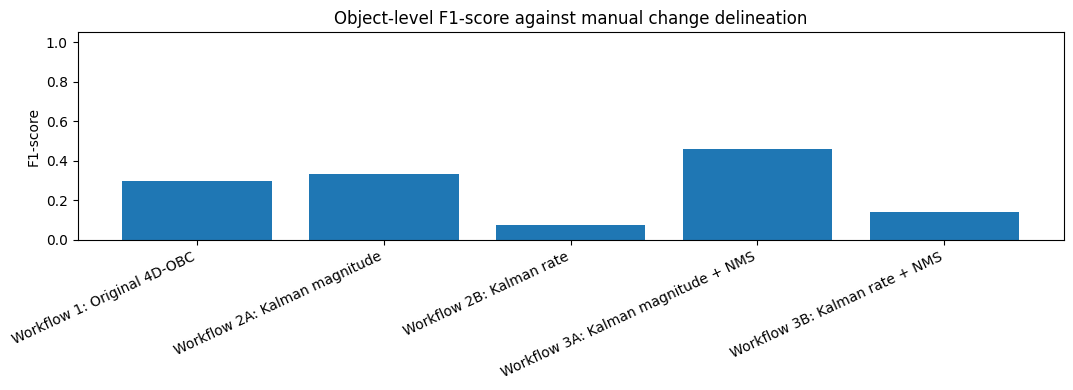

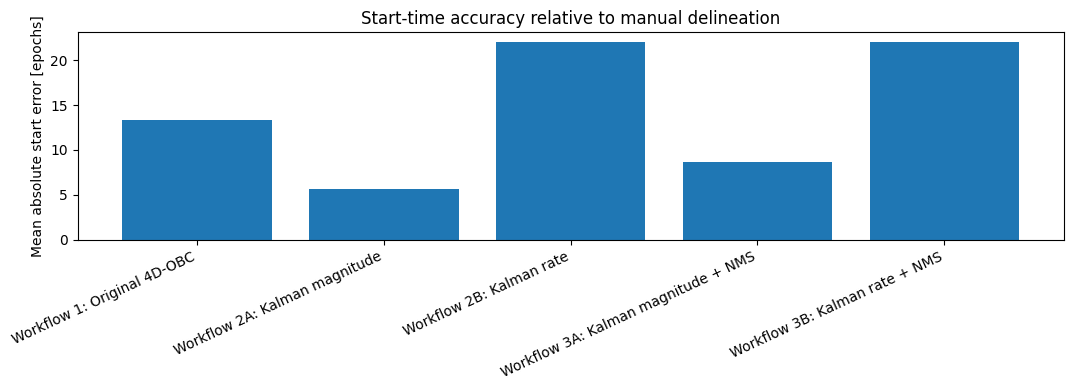

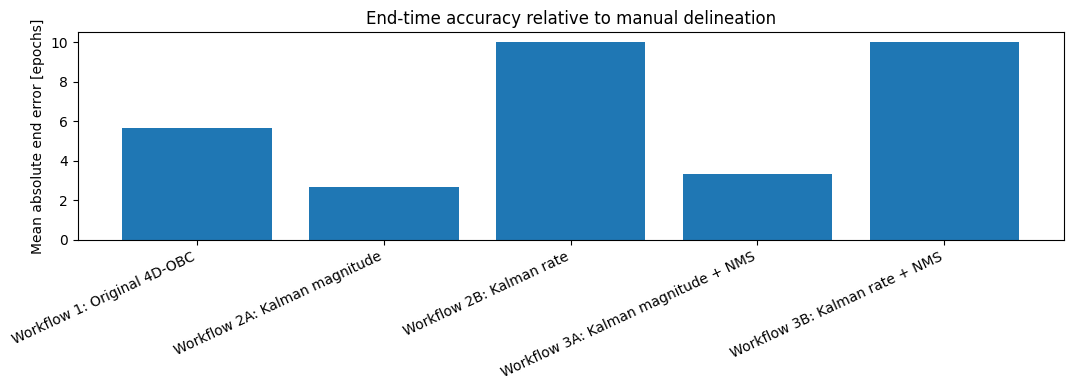

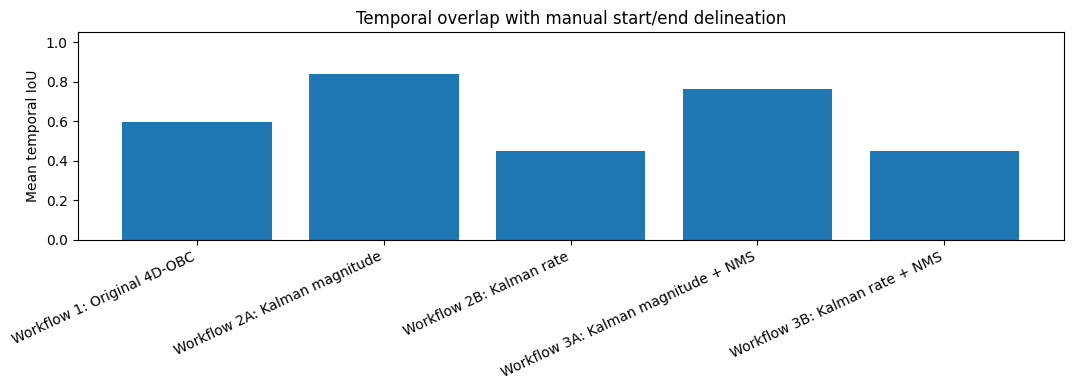

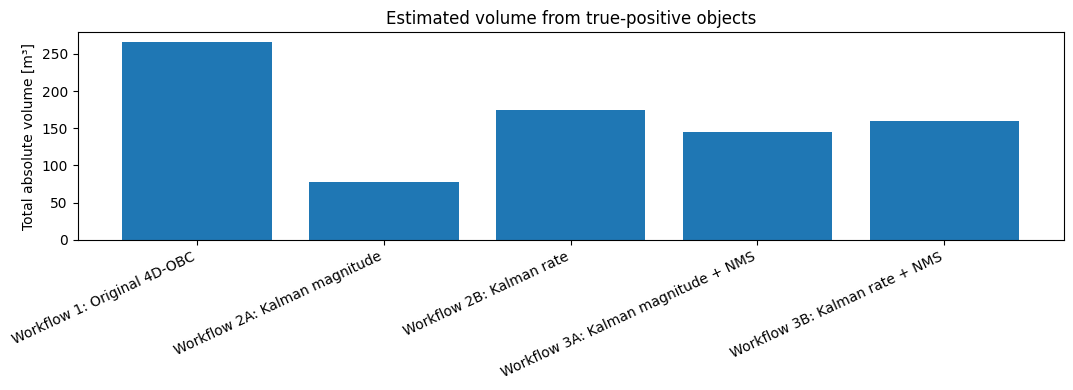

,reference_corepoint_index,visualization_corepoint_index,corepoint_spacing_m,area_per_corepoint_m2,min_temporal_iou_for_tp,use_spatial_iou_for_tp,min_spatial_iou_for_tp,manual_events_file,evaluation_logic
0,15162,15162,0.25,0.0625,0.3,True,0.1,manual_change_delineation_events.csv,Manual event start/end delineation matched to ...



Cell 16 complete: supervisor-aligned TP/FP/FN, temporal accuracy, IoU, and volume evaluation finished.


In [24]:
# ============================================================
# CELL 16 — EVALUATION: SPATIOTEMPORAL + VOLUME EVALUATION

# ============================================================

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

REFERENCE_COREPOINT_INDEX = 15162
VISUALIZATION_COREPOINT_INDEX = 15162

COREPOINT_SPACING = 0.25
AREA_PER_COREPOINT = COREPOINT_SPACING ** 2

MIN_TEMPORAL_IOU_FOR_TP = 0.30
MIN_SPATIAL_IOU_FOR_TP = 0.10
USE_SPATIAL_IOU_FOR_TP = True   # set True only if manual corepoint sets are defined

SAVE_EVALUATION_FIGURES = True

evaluation_fig_dir = FIGURES_DIR / "cell16_supervisor_aligned_evaluation"
evaluation_fig_dir.mkdir(exist_ok=True, parents=True)


# ------------------------------------------------------------
# 2. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "manual_events",
    "analysis",
    "corepoints",
    "timestamps_analysis",
    "original_4dobc_objects",
    "wf2_magnitude_objects",
    "wf2_rate_objects",
    "wf3_magnitude_objects",
    "wf3_rate_objects"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run Cell 16A and Cells 13–15 first."
        )

# ------------------------------------------------------------
# 4. HELPER FUNCTIONS
# ------------------------------------------------------------

def temporal_overlap_epochs(start_a, end_a, start_b, end_b):
    return max(0, min(end_a, end_b) - max(start_a, start_b) + 1)


def temporal_iou_epochs(start_a, end_a, start_b, end_b):
    intersection = temporal_overlap_epochs(start_a, end_a, start_b, end_b)
    union = max(end_a, end_b) - min(start_a, start_b) + 1
    return intersection / union if union > 0 else np.nan


def spatial_iou_indices(indices_a, indices_b):
    if indices_a is None or indices_b is None:
        return np.nan

    set_a = set(np.array(indices_a, dtype=int))
    set_b = set(np.array(indices_b, dtype=int))

    if len(set_a) == 0 or len(set_b) == 0:
        return np.nan

    intersection = len(set_a.intersection(set_b))
    union = len(set_a.union(set_b))

    return intersection / union if union > 0 else np.nan


def object_contains_corepoint(obj, cp_idx):
    return int(cp_idx) in set(np.array(obj.indices, dtype=int))


def estimate_object_volume(obj, start_epoch, end_epoch):
    indices = np.array(obj.indices, dtype=int)

    dz = (
        analysis.smoothed_distances[indices, int(end_epoch)] -
        analysis.smoothed_distances[indices, int(start_epoch)]
    )

    signed_volume_m3 = float(np.nansum(dz) * AREA_PER_COREPOINT)
    absolute_volume_m3 = float(np.nansum(np.abs(dz)) * AREA_PER_COREPOINT)

    mean_change_m = float(np.nanmean(dz))
    max_abs_change_m = float(np.nanmax(np.abs(dz)))

    return signed_volume_m3, absolute_volume_m3, mean_change_m, max_abs_change_m


def build_detected_object_table(objects, workflow_name, signal_name):

    records = []

    for object_number, obj in enumerate(objects, start=1):

        start_epoch = int(obj.start_epoch)
        end_epoch = int(obj.end_epoch)
        duration_epochs = end_epoch - start_epoch + 1

        signed_volume, abs_volume, mean_change, max_abs_change = estimate_object_volume(
            obj=obj,
            start_epoch=start_epoch,
            end_epoch=end_epoch
        )

        matched_seed_corepoint = np.nan
        matched_seed_direction = None
        matched_seed_start = np.nan
        matched_seed_end = np.nan

        if hasattr(obj, "matched_seed") and obj.matched_seed is not None:
            matched_seed_corepoint = int(obj.matched_seed["corepoint_index_python"])
            matched_seed_start = int(obj.matched_seed["start_epoch"])
            matched_seed_end = int(obj.matched_seed["end_epoch"])
            matched_seed_direction = obj.matched_seed["direction"]

        records.append({
            "workflow": workflow_name,
            "signal": signal_name,
            "detected_object_number": object_number,
            "start_epoch": start_epoch,
            "end_epoch": end_epoch,
            "duration_epochs": duration_epochs,
            "start_time": timestamps_analysis[start_epoch],
            "end_time": timestamps_analysis[end_epoch],
            "n_corepoints": len(obj.indices),
            "area_m2": len(obj.indices) * AREA_PER_COREPOINT,
            "contains_reference_corepoint": object_contains_corepoint(
                obj,
                REFERENCE_COREPOINT_INDEX
            ),
            "matched_seed_corepoint": matched_seed_corepoint,
            "matched_seed_start_epoch": matched_seed_start,
            "matched_seed_end_epoch": matched_seed_end,
            "matched_seed_direction": matched_seed_direction,
            "signed_volume_m3": signed_volume,
            "absolute_volume_m3": abs_volume,
            "mean_change_m": mean_change,
            "max_abs_change_m": max_abs_change,
            "object_ref": obj
        })

    return pd.DataFrame(records)


def get_workflow_object_sets():

    return [
        {
            "workflow": "Workflow 1: Original 4D-OBC",
            "signal": "original",
            "objects": original_4dobc_objects
        },
        {
            "workflow": "Workflow 2A: Kalman magnitude",
            "signal": "magnitude",
            "objects": wf2_magnitude_objects
        },
        {
            "workflow": "Workflow 2B: Kalman rate",
            "signal": "rate",
            "objects": wf2_rate_objects
        },
        {
            "workflow": "Workflow 3A: Kalman magnitude + NMS",
            "signal": "magnitude",
            "objects": wf3_magnitude_objects
        },
        {
            "workflow": "Workflow 3B: Kalman rate + NMS",
            "signal": "rate",
            "objects": wf3_rate_objects
        }
    ]


def match_manual_events_to_workflow(manual_events, detected_table):

    match_records = []
    used_detected_indices = set()

    for _, manual in manual_events.iterrows():

        manual_start = int(manual["manual_start_epoch"])
        manual_end = int(manual["manual_end_epoch"])
        manual_duration = manual_end - manual_start + 1
        manual_cp = int(manual["reference_corepoint_index_python"])

        manual_indices = manual["manual_corepoint_indices"]

        candidate_records = []

        for det_idx, detected in detected_table.iterrows():

            detected_obj = detected["object_ref"]

            detected_start = int(detected["start_epoch"])
            detected_end = int(detected["end_epoch"])
            detected_duration = detected_end - detected_start + 1

            t_iou = temporal_iou_epochs(
                manual_start,
                manual_end,
                detected_start,
                detected_end
            )

            s_iou = spatial_iou_indices(
                manual_indices,
                detected_obj.indices
            )

            contains_reference = bool(detected["contains_reference_corepoint"])

            if USE_SPATIAL_IOU_FOR_TP and not np.isnan(s_iou):
                match_score = t_iou * s_iou
            else:
                reference_bonus = 0.15 if contains_reference else 0.0
                match_score = t_iou + reference_bonus

            candidate_records.append({
                "detected_index": det_idx,
                "manual_object_id": manual["manual_object_id"],
                "event_label": manual["event_label"],
                "manual_direction": manual["direction"],
                "manual_start_epoch": manual_start,
                "manual_end_epoch": manual_end,
                "manual_duration_epochs": manual_duration,
                "workflow": detected["workflow"],
                "signal": detected["signal"],
                "detected_object_number": int(detected["detected_object_number"]),
                "detected_start_epoch": detected_start,
                "detected_end_epoch": detected_end,
                "detected_duration_epochs": detected_duration,
                "start_error_epochs": detected_start - manual_start,
                "end_error_epochs": detected_end - manual_end,
                "duration_error_epochs": detected_duration - manual_duration,
                "abs_start_error_epochs": abs(detected_start - manual_start),
                "abs_end_error_epochs": abs(detected_end - manual_end),
                "abs_duration_error_epochs": abs(detected_duration - manual_duration),
                "temporal_iou": t_iou,
                "spatial_iou": s_iou,
                "contains_reference_corepoint": contains_reference,
                "match_score": match_score,
                "n_corepoints": int(detected["n_corepoints"]),
                "area_m2": float(detected["area_m2"]),
                "signed_volume_m3": float(detected["signed_volume_m3"]),
                "absolute_volume_m3": float(detected["absolute_volume_m3"]),
                "mean_change_m": float(detected["mean_change_m"]),
                "max_abs_change_m": float(detected["max_abs_change_m"]),
                "matched_seed_corepoint": detected["matched_seed_corepoint"],
                "matched_seed_direction": detected["matched_seed_direction"]
            })

        candidates = pd.DataFrame(candidate_records)

        if len(candidates) == 0:
            match_records.append({
                "manual_object_id": manual["manual_object_id"],
                "event_label": manual["event_label"],
                "detection_status": "FN",
                "tp": 0,
                "fn": 1,
                "fp": 0
            })
            continue

        candidates = candidates.sort_values(
            ["match_score", "temporal_iou"],
            ascending=False
        )

        best = candidates.iloc[0].copy()

        temporal_pass = best["temporal_iou"] >= MIN_TEMPORAL_IOU_FOR_TP

        if USE_SPATIAL_IOU_FOR_TP and not np.isnan(best["spatial_iou"]):
            spatial_pass = best["spatial_iou"] >= MIN_SPATIAL_IOU_FOR_TP
        else:
            spatial_pass = True

        if temporal_pass and spatial_pass:
            detection_status = "TP"
            tp = 1
            fn = 0
            used_detected_indices.add(int(best["detected_index"]))
        else:
            detection_status = "FN"
            tp = 0
            fn = 1

        best["detection_status"] = detection_status
        best["tp"] = tp
        best["fn"] = fn
        best["fp"] = 0

        match_records.append(best.to_dict())

    match_table = pd.DataFrame(match_records)

    fp_records = []

    for det_idx, detected in detected_table.iterrows():

        if det_idx in used_detected_indices:
            continue

        fp_records.append({
            "manual_object_id": None,
            "event_label": "No matching manual object",
            "manual_direction": None,
            "manual_start_epoch": np.nan,
            "manual_end_epoch": np.nan,
            "manual_duration_epochs": np.nan,
            "workflow": detected["workflow"],
            "signal": detected["signal"],
            "detected_object_number": int(detected["detected_object_number"]),
            "detected_start_epoch": int(detected["start_epoch"]),
            "detected_end_epoch": int(detected["end_epoch"]),
            "detected_duration_epochs": int(detected["duration_epochs"]),
            "start_error_epochs": np.nan,
            "end_error_epochs": np.nan,
            "duration_error_epochs": np.nan,
            "abs_start_error_epochs": np.nan,
            "abs_end_error_epochs": np.nan,
            "abs_duration_error_epochs": np.nan,
            "temporal_iou": np.nan,
            "spatial_iou": np.nan,
            "contains_reference_corepoint": bool(detected["contains_reference_corepoint"]),
            "match_score": np.nan,
            "n_corepoints": int(detected["n_corepoints"]),
            "area_m2": float(detected["area_m2"]),
            "signed_volume_m3": float(detected["signed_volume_m3"]),
            "absolute_volume_m3": float(detected["absolute_volume_m3"]),
            "mean_change_m": float(detected["mean_change_m"]),
            "max_abs_change_m": float(detected["max_abs_change_m"]),
            "matched_seed_corepoint": detected["matched_seed_corepoint"],
            "matched_seed_direction": detected["matched_seed_direction"],
            "detection_status": "FP",
            "tp": 0,
            "fn": 0,
            "fp": 1
        })

    if len(fp_records) > 0:
        match_table = pd.concat(
            [match_table, pd.DataFrame(fp_records)],
            ignore_index=True
        )

    return match_table


def safe_divide(a, b):
    return a / b if b not in [0, np.nan] and b != 0 else np.nan


# ------------------------------------------------------------
# 5. BUILD DETECTED OBJECT TABLES
# ------------------------------------------------------------

detected_tables = []

for item in get_workflow_object_sets():

    df = build_detected_object_table(
        objects=item["objects"],
        workflow_name=item["workflow"],
        signal_name=item["signal"]
    )

    detected_tables.append(df)

detected_objects_all_workflows = pd.concat(
    detected_tables,
    ignore_index=True
)

detected_objects_export = detected_objects_all_workflows.drop(
    columns=["object_ref"]
)

display(detected_objects_export)

detected_objects_export.to_csv(
    TABLES_DIR / "cell16_detected_objects_all_workflows.csv",
    index=False
)


# ------------------------------------------------------------
# 6. MATCH MANUAL OBJECTS TO EACH WORKFLOW
# ------------------------------------------------------------

workflow_evaluation_tables = []

for workflow_name in detected_objects_all_workflows["workflow"].unique():

    workflow_detected = detected_objects_all_workflows[
        detected_objects_all_workflows["workflow"] == workflow_name
    ].copy()

    workflow_eval = match_manual_events_to_workflow(
        manual_events=manual_events,
        detected_table=workflow_detected
    )

    workflow_evaluation_tables.append(workflow_eval)

object_level_evaluation = pd.concat(
    workflow_evaluation_tables,
    ignore_index=True
)

display(object_level_evaluation)

object_level_evaluation.to_csv(
    TABLES_DIR / "cell16_object_level_TP_FP_FN_temporal_volume_evaluation.csv",
    index=False
)


# ------------------------------------------------------------
# 7. METHOD-LEVEL 12-METRIC SUMMARY
# ------------------------------------------------------------

summary_records = []

for workflow_name, group in object_level_evaluation.groupby("workflow"):

    tp = int(group["tp"].sum())
    fp = int(group["fp"].sum())
    fn = int(group["fn"].sum())

    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    sensitivity = recall

    f1 = (
        2 * precision * recall / (precision + recall)
        if not np.isnan(precision)
        and not np.isnan(recall)
        and (precision + recall) > 0
        else np.nan
    )

    tp_group = group[group["detection_status"] == "TP"].copy()

    summary_records.append({
        "workflow": workflow_name,
        "signal": (
            group["signal"].dropna().iloc[0]
            if "signal" in group.columns and len(group["signal"].dropna()) > 0
            else None
        ),

        # 1–6 detection metrics
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall_Sensitivity": sensitivity,
        "F1_score": f1,

        # 7–11 temporal/spatial metrics
        "mean_start_error_epochs": tp_group["start_error_epochs"].mean(),
        "mean_abs_start_error_epochs": tp_group["abs_start_error_epochs"].mean(),
        "mean_end_error_epochs": tp_group["end_error_epochs"].mean(),
        "mean_abs_end_error_epochs": tp_group["abs_end_error_epochs"].mean(),
        "mean_duration_error_epochs": tp_group["duration_error_epochs"].mean(),
        "mean_abs_duration_error_epochs": tp_group["abs_duration_error_epochs"].mean(),
        "mean_temporal_iou": tp_group["temporal_iou"].mean(),
        "mean_spatial_iou": tp_group["spatial_iou"].mean(),

        # 12 volume metric
        "total_signed_volume_m3_TP": tp_group["signed_volume_m3"].sum(),
        "total_absolute_volume_m3_TP": tp_group["absolute_volume_m3"].sum(),
        "mean_absolute_volume_m3_TP": tp_group["absolute_volume_m3"].mean()
    })

supervisor_evaluation_summary = pd.DataFrame(summary_records)

display(supervisor_evaluation_summary)

supervisor_evaluation_summary.to_csv(
    TABLES_DIR / "cell16_supervisor_12_metric_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 8. VOLUME COMPARISON AGAINST WORKFLOW 1
# ------------------------------------------------------------

volume_records = []

for manual_id, group in object_level_evaluation[
    object_level_evaluation["detection_status"] == "TP"
].groupby("manual_object_id"):

    baseline = group[
        group["workflow"] == "Workflow 1: Original 4D-OBC"
    ]

    baseline_volume = (
        float(baseline["absolute_volume_m3"].iloc[0])
        if len(baseline) > 0
        else np.nan
    )

    for _, row in group.iterrows():

        volume_records.append({
            "manual_object_id": manual_id,
            "event_label": row["event_label"],
            "workflow": row["workflow"],
            "detected_object_number": row["detected_object_number"],
            "absolute_volume_m3": row["absolute_volume_m3"],
            "signed_volume_m3": row["signed_volume_m3"],
            "baseline_workflow1_absolute_volume_m3": baseline_volume,
            "volume_difference_from_workflow1_m3": (
                row["absolute_volume_m3"] - baseline_volume
                if not np.isnan(baseline_volume)
                else np.nan
            ),
            "volume_ratio_to_workflow1": (
                row["absolute_volume_m3"] / baseline_volume
                if not np.isnan(baseline_volume) and baseline_volume != 0
                else np.nan
            )
        })

volume_comparison_table = pd.DataFrame(volume_records)

display(volume_comparison_table)

volume_comparison_table.to_csv(
    TABLES_DIR / "cell16_volume_comparison_against_workflow1.csv",
    index=False
)


# ------------------------------------------------------------
# 9. PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(11, 4))
plt.bar(
    supervisor_evaluation_summary["workflow"],
    supervisor_evaluation_summary["F1_score"]
)
plt.ylabel("F1-score")
plt.title("Object-level F1-score against manual change delineation")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()

if SAVE_EVALUATION_FIGURES:
    plt.savefig(
        evaluation_fig_dir / "cell16_f1_score_by_workflow.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()


plt.figure(figsize=(11, 4))
plt.bar(
    supervisor_evaluation_summary["workflow"],
    supervisor_evaluation_summary["mean_abs_start_error_epochs"]
)
plt.ylabel("Mean absolute start error [epochs]")
plt.title("Start-time accuracy relative to manual delineation")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

if SAVE_EVALUATION_FIGURES:
    plt.savefig(
        evaluation_fig_dir / "cell16_mean_abs_start_error_by_workflow.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()


plt.figure(figsize=(11, 4))
plt.bar(
    supervisor_evaluation_summary["workflow"],
    supervisor_evaluation_summary["mean_abs_end_error_epochs"]
)
plt.ylabel("Mean absolute end error [epochs]")
plt.title("End-time accuracy relative to manual delineation")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

if SAVE_EVALUATION_FIGURES:
    plt.savefig(
        evaluation_fig_dir / "cell16_mean_abs_end_error_by_workflow.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()


plt.figure(figsize=(11, 4))
plt.bar(
    supervisor_evaluation_summary["workflow"],
    supervisor_evaluation_summary["mean_temporal_iou"]
)
plt.ylabel("Mean temporal IoU")
plt.title("Temporal overlap with manual start/end delineation")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()

if SAVE_EVALUATION_FIGURES:
    plt.savefig(
        evaluation_fig_dir / "cell16_mean_temporal_iou_by_workflow.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()


plt.figure(figsize=(11, 4))
plt.bar(
    supervisor_evaluation_summary["workflow"],
    supervisor_evaluation_summary["total_absolute_volume_m3_TP"]
)
plt.ylabel("Total absolute volume [m³]")
plt.title("Estimated volume from true-positive objects")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

if SAVE_EVALUATION_FIGURES:
    plt.savefig(
        evaluation_fig_dir / "cell16_total_absolute_volume_by_workflow.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

plt.show()


# ------------------------------------------------------------
# 10. CONFIG SUMMARY
# ------------------------------------------------------------

evaluation_config = pd.DataFrame([{
    "reference_corepoint_index": REFERENCE_COREPOINT_INDEX,
    "visualization_corepoint_index": VISUALIZATION_COREPOINT_INDEX,
    "corepoint_spacing_m": COREPOINT_SPACING,
    "area_per_corepoint_m2": AREA_PER_COREPOINT,
    "min_temporal_iou_for_tp": MIN_TEMPORAL_IOU_FOR_TP,
    "use_spatial_iou_for_tp": USE_SPATIAL_IOU_FOR_TP,
    "min_spatial_iou_for_tp": MIN_SPATIAL_IOU_FOR_TP,
    "manual_events_file": "manual_change_delineation_events.csv",
    "evaluation_logic": (
        "Manual event start/end delineation matched to detected objects. "
        "TP/FP/FN are derived from temporal IoU and optional spatial IoU. "
        "Temporal accuracy uses start/end/duration errors and temporal IoU. "
        "Volume is estimated from object corepoint change multiplied by area per corepoint."
    )
}])

display(evaluation_config)

evaluation_config.to_csv(
    TABLES_DIR / "cell16_supervisor_evaluation_config.csv",
    index=False
)

print("\nCell 16 complete: supervisor-aligned TP/FP/FN, temporal accuracy, IoU, and volume evaluation finished.")

In [25]:
# ============================================================
# DIAGNOSTIC — SINGLE OBJECT 12-METRIC EVALUATION
# WITH MANUAL-EVENT RANKING TABLE
# ============================================================

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

REFERENCE_COREPOINT = 15162
OBJECT_NUMBER = 1

WORKFLOW = "wf2_magnitude"
# options:
# "original"
# "wf2_magnitude"
# "wf2_rate"
# "wf3_magnitude"
# "wf3_rate"


# ------------------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "analysis",
    "timestamps_analysis",
    "manual_events",
    "AREA_PER_COREPOINT",
    "MIN_TEMPORAL_IOU_FOR_TP"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} is not defined. Please run Cell 16 first.")


workflow_lookup = {
    "original": original_4dobc_objects,
    "wf2_magnitude": wf2_magnitude_objects,
    "wf2_rate": wf2_rate_objects,
    "wf3_magnitude": wf3_magnitude_objects,
    "wf3_rate": wf3_rate_objects,
}

if WORKFLOW not in workflow_lookup:
    raise ValueError("WORKFLOW must be one of: " + ", ".join(workflow_lookup.keys()))

objects = workflow_lookup[WORKFLOW]

if OBJECT_NUMBER < 1 or OBJECT_NUMBER > len(objects):
    raise ValueError(
        f"OBJECT_NUMBER={OBJECT_NUMBER} is invalid. "
        f"{WORKFLOW} has {len(objects)} objects."
    )


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def diagnostic_temporal_iou(start_a, end_a, start_b, end_b):
    intersection = max(
        0,
        min(end_a, end_b) - max(start_a, start_b) + 1
    )

    union = max(end_a, end_b) - min(start_a, start_b) + 1

    return intersection / union if union > 0 else np.nan


def diagnostic_temporal_overlap(start_a, end_a, start_b, end_b):
    return max(
        0,
        min(end_a, end_b) - max(start_a, start_b) + 1
    )


# ------------------------------------------------------------
# EXTRACT OBJECT
# ------------------------------------------------------------

obj = objects[OBJECT_NUMBER - 1]

indices = np.asarray(obj.indices, dtype=int)

contains_reference = int(REFERENCE_COREPOINT) in set(indices)

start_epoch = int(obj.start_epoch)
end_epoch = int(obj.end_epoch)
duration_epochs = end_epoch - start_epoch + 1

start_time = timestamps_analysis[start_epoch]
end_time = timestamps_analysis[end_epoch]

area_m2 = len(indices) * AREA_PER_COREPOINT


# ------------------------------------------------------------
# VOLUME / CHANGE ESTIMATION
# ------------------------------------------------------------

dz = (
    analysis.smoothed_distances[indices, end_epoch]
    - analysis.smoothed_distances[indices, start_epoch]
)

signed_volume_m3 = float(np.nansum(dz) * AREA_PER_COREPOINT)
absolute_volume_m3 = float(np.nansum(np.abs(dz)) * AREA_PER_COREPOINT)

mean_change_m = float(np.nanmean(dz))
max_abs_change_m = float(np.nanmax(np.abs(dz)))


# ------------------------------------------------------------
# OBJECT-GENERATING SEED INFORMATION
# ------------------------------------------------------------

seed_corepoint = np.nan
seed_start = np.nan
seed_end = np.nan
seed_direction = None
seed_rank = np.nan

if hasattr(obj, "matched_seed") and obj.matched_seed is not None:

    seed_corepoint = int(obj.matched_seed["corepoint_index_python"])
    seed_start = int(obj.matched_seed["start_epoch"])
    seed_end = int(obj.matched_seed["end_epoch"])

    if "direction" in obj.matched_seed:
        seed_direction = obj.matched_seed["direction"]

    if "seed_rank" in obj.matched_seed and not pd.isna(obj.matched_seed["seed_rank"]):
        seed_rank = int(obj.matched_seed["seed_rank"])

    if "nms_rank" in obj.matched_seed and not pd.isna(obj.matched_seed["nms_rank"]):
        seed_rank = int(obj.matched_seed["nms_rank"])


# ------------------------------------------------------------
# MANUAL-EVENT RANKING
# ------------------------------------------------------------

manual_match_records = []

for _, manual in manual_events.iterrows():

    manual_start = int(manual["manual_start_epoch"])
    manual_end = int(manual["manual_end_epoch"])
    manual_duration = manual_end - manual_start + 1

    t_overlap = diagnostic_temporal_overlap(
        start_epoch,
        end_epoch,
        manual_start,
        manual_end
    )

    t_iou = diagnostic_temporal_iou(
        start_epoch,
        end_epoch,
        manual_start,
        manual_end
    )

    manual_match_records.append({
        "manual_object_id": manual["manual_object_id"],
        "event_label": manual["event_label"],
        "manual_direction": manual["direction"],
        "manual_start_epoch": manual_start,
        "manual_end_epoch": manual_end,
        "manual_duration_epochs": manual_duration,
        "temporal_overlap_epochs": t_overlap,
        "temporal_iou": t_iou,
        "start_error_epochs": start_epoch - manual_start,
        "end_error_epochs": end_epoch - manual_end,
        "duration_error_epochs": duration_epochs - manual_duration,
        "abs_start_error_epochs": abs(start_epoch - manual_start),
        "abs_end_error_epochs": abs(end_epoch - manual_end),
        "abs_duration_error_epochs": abs(duration_epochs - manual_duration)
    })

manual_event_ranking_for_object = (
    pd.DataFrame(manual_match_records)
    .sort_values(
        ["temporal_iou", "temporal_overlap_epochs"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(manual_event_ranking_for_object)


# ------------------------------------------------------------
# BEST MANUAL MATCH
# ------------------------------------------------------------

best_manual = manual_event_ranking_for_object.iloc[0]

TP = int(best_manual["temporal_iou"] >= MIN_TEMPORAL_IOU_FOR_TP)
FP = int(best_manual["temporal_iou"] < MIN_TEMPORAL_IOU_FOR_TP)
FN = 0

precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan

f1_score = (
    2 * precision * recall / (precision + recall)
    if not np.isnan(precision)
    and not np.isnan(recall)
    and (precision + recall) > 0
    else np.nan
)


# ------------------------------------------------------------
# SINGLE-OBJECT 12-METRIC SUMMARY
# ------------------------------------------------------------

single_object_12_metric_summary = pd.DataFrame([{
    "workflow": WORKFLOW,
    "object_number": OBJECT_NUMBER,
    "reference_corepoint": REFERENCE_COREPOINT,
    "contains_reference_corepoint": contains_reference,

    "object_generating_seed_corepoint": seed_corepoint,
    "object_generating_seed_rank": seed_rank,
    "object_generating_seed_start_epoch": seed_start,
    "object_generating_seed_end_epoch": seed_end,
    "object_generating_seed_direction": seed_direction,

    "detected_start_epoch": start_epoch,
    "detected_end_epoch": end_epoch,
    "detected_duration_epochs": duration_epochs,
    "detected_start_time": start_time,
    "detected_end_time": end_time,

    "best_manual_object_id": best_manual["manual_object_id"],
    "best_manual_event_label": best_manual["event_label"],
    "manual_direction": best_manual["manual_direction"],
    "manual_start_epoch": int(best_manual["manual_start_epoch"]),
    "manual_end_epoch": int(best_manual["manual_end_epoch"]),
    "manual_duration_epochs": int(best_manual["manual_duration_epochs"]),

    # 12 evaluation variables
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "Precision": precision,
    "Recall_Sensitivity": recall,
    "F1_score": f1_score,
    "Spatial_IoU": np.nan,
    "Temporal_IoU": float(best_manual["temporal_iou"]),
    "Start_error_epochs": int(best_manual["start_error_epochs"]),
    "End_error_epochs": int(best_manual["end_error_epochs"]),
    "Duration_error_epochs": int(best_manual["duration_error_epochs"]),
    "Estimated_absolute_volume_m3": absolute_volume_m3,

    # extra useful diagnostics
    "area_m2": area_m2,
    "n_corepoints": len(indices),
    "mean_change_m": mean_change_m,
    "max_abs_change_m": max_abs_change_m,
    "signed_volume_m3": signed_volume_m3
}])

display(single_object_12_metric_summary)


# ------------------------------------------------------------
# PRINT COMPACT TEXT SUMMARY
# ------------------------------------------------------------

print("=" * 80)
print("SINGLE OBJECT EVALUATION DIAGNOSTIC")
print("=" * 80)
print(f"Workflow                    : {WORKFLOW}")
print(f"Object number               : {OBJECT_NUMBER}")
print(f"Reference corepoint          : {REFERENCE_COREPOINT}")
print(f"Contains reference corepoint : {contains_reference}")
print("-" * 80)
print(f"Detected interval            : {start_epoch} → {end_epoch}")
print(f"Detected duration            : {duration_epochs} epochs")
print(f"Object-generating seed cp    : {seed_corepoint}")
print(f"Object-generating seed rank  : {seed_rank}")
print(f"Seed interval                : {seed_start} → {seed_end}")
print(f"Seed direction               : {seed_direction}")
print("-" * 80)
print(f"Best manual object           : {best_manual['manual_object_id']}")
print(f"Manual label                 : {best_manual['event_label']}")
print(f"Manual interval              : {int(best_manual['manual_start_epoch'])} → {int(best_manual['manual_end_epoch'])}")
print(f"Manual duration              : {int(best_manual['manual_duration_epochs'])} epochs")
print("-" * 80)
print("12 evaluation variables")
print("-" * 80)
print(f"1  TP                        : {TP}")
print(f"2  FP                        : {FP}")
print(f"3  FN                        : {FN}")
print(f"4  Precision                 : {precision:.3f}")
print(f"5  Recall / Sensitivity      : {recall:.3f}")
print(f"6  F1-score                  : {f1_score:.3f}")
print(f"7  Spatial IoU               : not used / manual spatial object not defined")
print(f"8  Temporal IoU              : {float(best_manual['temporal_iou']):.3f}")
print(f"9  Start error [epochs]      : {int(best_manual['start_error_epochs'])}")
print(f"10 End error [epochs]        : {int(best_manual['end_error_epochs'])}")
print(f"11 Duration error [epochs]   : {int(best_manual['duration_error_epochs'])}")
print(f"12 Estimated volume [m³]     : {absolute_volume_m3:.4f}")
print("=" * 80)


# ------------------------------------------------------------
# SAVE TABLES
# ------------------------------------------------------------

single_object_12_metric_summary.to_csv(
    TABLES_DIR / (
        f"diagnostic_12_metrics_{WORKFLOW}_"
        f"object_{OBJECT_NUMBER}_cp_{REFERENCE_COREPOINT}.csv"
    ),
    index=False
)

manual_event_ranking_for_object.to_csv(
    TABLES_DIR / (
        f"diagnostic_manual_event_ranking_{WORKFLOW}_"
        f"object_{OBJECT_NUMBER}_cp_{REFERENCE_COREPOINT}.csv"
    ),
    index=False
)

print("\nDiagnostic complete. Tables saved.")

,manual_object_id,event_label,manual_direction,manual_start_epoch,manual_end_epoch,manual_duration_epochs,temporal_overlap_epochs,temporal_iou,start_error_epochs,end_error_epochs,duration_error_epochs,abs_start_error_epochs,abs_end_error_epochs,abs_duration_error_epochs
0,M2,February positive accumulation,positive,1,45,45,35,0.777778,4,-6,-10,4,6,10
1,M1,April positive accumulation,positive,44,91,48,0,0.000000,-39,-52,-13,39,52,13
2,M3,April-May negative change,negative,82,158,77,0,0.000000,-77,-119,-42,77,119,42


,workflow,object_number,reference_corepoint,contains_reference_corepoint,object_generating_seed_corepoint,object_generating_seed_rank,object_generating_seed_start_epoch,object_generating_seed_end_epoch,object_generating_seed_direction,detected_start_epoch,...,Temporal_IoU,Start_error_epochs,End_error_epochs,Duration_error_epochs,Estimated_absolute_volume_m3,area_m2,n_corepoints,mean_change_m,max_abs_change_m,signed_volume_m3
0,wf2_magnitude,1,15162,True,15373,498,5,39,positive,5,...,0.777778,4,-6,-10,18.199777,333.6875,5339,0.024934,0.231076,8.32029


SINGLE OBJECT EVALUATION DIAGNOSTIC
Workflow                    : wf2_magnitude
Object number               : 1
Reference corepoint          : 15162
Contains reference corepoint : True
--------------------------------------------------------------------------------
Detected interval            : 5 → 39
Detected duration            : 35 epochs
Object-generating seed cp    : 15373
Object-generating seed rank  : 498
Seed interval                : 5 → 39
Seed direction               : positive
--------------------------------------------------------------------------------
Best manual object           : M2
Manual label                 : February positive accumulation
Manual interval              : 1 → 45
Manual duration              : 45 epochs
--------------------------------------------------------------------------------
12 evaluation variables
--------------------------------------------------------------------------------
1  TP                        : 1
2  FP                        :

In [26]:
# ============================================================
# CELL 16B — NMS BENEFIT + LIMITATION DIAGNOSTIC TABLES
# ============================================================

# ------------------------------------------------------------
# 1. USER SETTINGS
# ------------------------------------------------------------

REFERENCE_COREPOINT_INDEX = 15162
VISUALIZATION_COREPOINT_INDEX = 15162

MAX_NEAREST_RETAINED_SEED_DISTANCE_M = 10.0
MIN_TEMPORAL_OVERLAP_FOR_SAME_EVENT = 1

SAVE_NMS_EVALUATION_TABLES = True

nms_eval_dir = TABLES_DIR / "nms_benefit_limitation_tables"
nms_eval_dir.mkdir(exist_ok=True, parents=True)


# ------------------------------------------------------------
# 2. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_objects = [
    "improved_seed_table_magnitude",
    "improved_seed_table_rate",
    "wf3_magnitude_nms_seed_table",
    "wf3_rate_nms_seed_table",
    "workflow3_combined_summary",
    "supervisor_evaluation_summary",
    "object_level_evaluation",
    "corepoints",
    "wf3_magnitude_objects",
    "wf3_rate_objects"
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(
            f"{obj} is not defined. Please run Cells 14, 15 and 16 first."
        )


# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------

def interval_overlap_epochs(a_start, a_end, b_start, b_end):
    return max(0, min(a_end, b_end) - max(a_start, b_start) + 1)


def interval_iou_epochs(a_start, a_end, b_start, b_end):
    overlap = interval_overlap_epochs(a_start, a_end, b_start, b_end)
    union = max(a_end, b_end) - min(a_start, b_start) + 1
    return overlap / union if union > 0 else np.nan


def get_workflow_metrics(workflow_name):
    rows = supervisor_evaluation_summary[
        supervisor_evaluation_summary["workflow"] == workflow_name
    ]

    if len(rows) == 0:
        return {
            "TP": np.nan,
            "FP": np.nan,
            "FN": np.nan,
            "Precision": np.nan,
            "Recall_Sensitivity": np.nan,
            "F1_score": np.nan,
            "mean_temporal_iou": np.nan,
            "total_absolute_volume_m3_TP": np.nan
        }

    row = rows.iloc[0]

    return {
        "TP": row.get("TP", np.nan),
        "FP": row.get("FP", np.nan),
        "FN": row.get("FN", np.nan),
        "Precision": row.get("Precision", np.nan),
        "Recall_Sensitivity": row.get("Recall_Sensitivity", np.nan),
        "F1_score": row.get("F1_score", np.nan),
        "mean_temporal_iou": row.get("mean_temporal_iou", np.nan),
        "total_absolute_volume_m3_TP": row.get("total_absolute_volume_m3_TP", np.nan)
    }


def count_objects_for_workflow(workflow_name):
    rows = workflow3_combined_summary[
        workflow3_combined_summary["workflow"] == workflow_name
    ]

    if len(rows) == 0:
        return {
            "n_raw_objects": np.nan,
            "n_final_objects": np.nan,
            "elapsed_seconds": np.nan
        }

    row = rows.iloc[0]

    return {
        "n_raw_objects": row.get("n_raw_objects", np.nan),
        "n_final_objects": row.get("n_final_objects", np.nan),
        "elapsed_seconds": row.get("elapsed_seconds", np.nan)
    }


def seed_key(row):
    return (
        int(row["corepoint_index_python"]),
        int(row["start_epoch"]),
        int(row["end_epoch"]),
        str(row["direction"])
    )


def get_removed_seed_table(before_table, after_table, signal_name):
    before = before_table.copy()
    after = after_table.copy()

    before["seed_key"] = before.apply(seed_key, axis=1)
    after["seed_key"] = after.apply(seed_key, axis=1)

    retained_keys = set(after["seed_key"].tolist())

    removed = before[
        ~before["seed_key"].isin(retained_keys)
    ].copy()

    removed["signal"] = signal_name
    removed["nms_status"] = "removed_by_nms"

    return removed


def find_nearest_retained_seed(removed_seed, retained_table):
    removed_cp = int(removed_seed["corepoint_index_python"])
    removed_xy = corepoints[removed_cp, :2]

    removed_start = int(removed_seed["start_epoch"])
    removed_end = int(removed_seed["end_epoch"])
    removed_direction = removed_seed["direction"]

    candidates = retained_table.copy()

    if len(candidates) == 0:
        return None

    candidates["distance_to_removed_seed_m"] = candidates[
        "corepoint_index_python"
    ].apply(
        lambda cp: float(
            np.linalg.norm(corepoints[int(cp), :2] - removed_xy)
        )
    )

    candidates["temporal_overlap_epochs"] = candidates.apply(
        lambda row: interval_overlap_epochs(
            removed_start,
            removed_end,
            int(row["start_epoch"]),
            int(row["end_epoch"])
        ),
        axis=1
    )

    candidates["temporal_iou"] = candidates.apply(
        lambda row: interval_iou_epochs(
            removed_start,
            removed_end,
            int(row["start_epoch"]),
            int(row["end_epoch"])
        ),
        axis=1
    )

    candidates["same_direction"] = (
        candidates["direction"] == removed_direction
    )

    candidates = candidates[
        candidates["distance_to_removed_seed_m"] <=
        MAX_NEAREST_RETAINED_SEED_DISTANCE_M
    ].copy()

    if len(candidates) == 0:
        return None

    candidates = candidates.sort_values(
        [
            "same_direction",
            "temporal_overlap_epochs",
            "temporal_iou",
            "distance_to_removed_seed_m"
        ],
        ascending=[False, False, False, True]
    )

    return candidates.iloc[0]


def object_contains_cp(objects, cp_idx):
    for object_number, obj in enumerate(objects, start=1):
        indices = set(np.array(obj.indices, dtype=int))
        if int(cp_idx) in indices:
            return object_number
    return np.nan


def classify_removed_seed(row):
    if pd.isna(row["nearest_retained_seed_corepoint"]):
        return "Potential over-suppression: no nearby retained seed"

    if (
        row["same_direction_as_nearest_retained_seed"]
        and row["temporal_overlap_with_nearest_retained_seed"] >=
        MIN_TEMPORAL_OVERLAP_FOR_SAME_EVENT
        and row["nearest_retained_seed_distance_m"] <=
        MAX_NEAREST_RETAINED_SEED_DISTANCE_M
    ):
        return "Likely redundant: nearby retained seed represents same event"

    return "Potential limitation: removed seed may represent distinct event"


def get_signal_inputs(signal_name):
    if signal_name == "magnitude":
        return {
            "signal": "magnitude",
            "before_table": improved_seed_table_magnitude,
            "after_table": wf3_magnitude_nms_seed_table,
            "wf2_workflow": "Workflow 2A: Kalman magnitude",
            "wf3_workflow": "Workflow 3A: Kalman magnitude + NMS",
            "wf3_objects": wf3_magnitude_objects
        }

    if signal_name == "rate":
        return {
            "signal": "rate",
            "before_table": improved_seed_table_rate,
            "after_table": wf3_rate_nms_seed_table,
            "wf2_workflow": "Workflow 2B: Kalman rate",
            "wf3_workflow": "Workflow 3B: Kalman rate + NMS",
            "wf3_objects": wf3_rate_objects
        }

    raise ValueError("signal_name must be 'magnitude' or 'rate'.")


# ------------------------------------------------------------
# 4. SLIDE A — NMS BENEFIT SUMMARY
# ------------------------------------------------------------

slide_a_records = []

for signal_name in ["magnitude", "rate"]:

    data = get_signal_inputs(signal_name)

    before_table = data["before_table"]
    after_table = data["after_table"]

    wf2_metrics = get_workflow_metrics(data["wf2_workflow"])
    wf3_metrics = get_workflow_metrics(data["wf3_workflow"])

    wf3_counts = count_objects_for_workflow(data["wf3_workflow"])

    n_before = len(before_table)
    n_after = len(after_table)
    n_removed = n_before - n_after
    removal_percent = 100 * n_removed / n_before if n_before > 0 else np.nan

    slide_a_records.append({
        "signal": signal_name,

        "before_nms_seed_table": f"improved_seed_table_{signal_name}",
        "after_nms_seed_table": f"wf3_{signal_name}_nms_seed_table",

        "seeds_before_nms": n_before,
        "seeds_after_nms": n_after,
        "seeds_removed_by_nms": n_removed,
        "seed_reduction_percent": removal_percent,

        "workflow2_precision_before_nms": wf2_metrics["Precision"],
        "workflow3_precision_after_nms": wf3_metrics["Precision"],
        "precision_change_after_nms": (
            wf3_metrics["Precision"] - wf2_metrics["Precision"]
            if not pd.isna(wf2_metrics["Precision"])
            and not pd.isna(wf3_metrics["Precision"])
            else np.nan
        ),

        "workflow2_FP_before_nms": wf2_metrics["FP"],
        "workflow3_FP_after_nms": wf3_metrics["FP"],
        "FP_change_after_nms": (
            wf3_metrics["FP"] - wf2_metrics["FP"]
            if not pd.isna(wf2_metrics["FP"])
            and not pd.isna(wf3_metrics["FP"])
            else np.nan
        ),

        "workflow2_F1_before_nms": wf2_metrics["F1_score"],
        "workflow3_F1_after_nms": wf3_metrics["F1_score"],
        "F1_change_after_nms": (
            wf3_metrics["F1_score"] - wf2_metrics["F1_score"]
            if not pd.isna(wf2_metrics["F1_score"])
            and not pd.isna(wf3_metrics["F1_score"])
            else np.nan
        ),

        "workflow3_raw_objects": wf3_counts["n_raw_objects"],
        "workflow3_final_objects": wf3_counts["n_final_objects"],
        "workflow3_elapsed_seconds": wf3_counts["elapsed_seconds"],

        "slide_message": (
            "NMS reduces redundant seed candidates and is beneficial "
            "if precision/F1 improve or FP decreases while recall is preserved."
        )
    })


slide_a_nms_benefit_summary = pd.DataFrame(slide_a_records)

display(slide_a_nms_benefit_summary)

if SAVE_NMS_EVALUATION_TABLES:
    slide_a_nms_benefit_summary.to_csv(
        nms_eval_dir / "slide_A_nms_benefit_summary.csv",
        index=False
    )


# ------------------------------------------------------------
# 5. SLIDE B — NMS LIMITATION / REMOVED SEED ANALYSIS
# ------------------------------------------------------------

removed_seed_records = []

for signal_name in ["magnitude", "rate"]:

    data = get_signal_inputs(signal_name)

    before_table = data["before_table"]
    after_table = data["after_table"]
    wf3_objects = data["wf3_objects"]

    removed_table = get_removed_seed_table(
        before_table=before_table,
        after_table=after_table,
        signal_name=signal_name
    )

    for _, removed_seed in removed_table.iterrows():

        nearest = find_nearest_retained_seed(
            removed_seed=removed_seed,
            retained_table=after_table
        )

        removed_cp = int(removed_seed["corepoint_index_python"])

        if nearest is None:

            nearest_cp = np.nan
            nearest_rank = np.nan
            nearest_start = np.nan
            nearest_end = np.nan
            nearest_distance = np.nan
            same_direction = False
            temporal_overlap = 0
            temporal_iou = np.nan

        else:

            nearest_cp = int(nearest["corepoint_index_python"])
            nearest_rank = (
                int(nearest["nms_rank"])
                if "nms_rank" in nearest and not pd.isna(nearest["nms_rank"])
                else np.nan
            )
            nearest_start = int(nearest["start_epoch"])
            nearest_end = int(nearest["end_epoch"])
            nearest_distance = float(nearest["distance_to_removed_seed_m"])
            same_direction = bool(nearest["same_direction"])
            temporal_overlap = int(nearest["temporal_overlap_epochs"])
            temporal_iou = float(nearest["temporal_iou"])

        removed_object_number = object_contains_cp(
            wf3_objects,
            removed_cp
        )

        nearest_object_number = (
            object_contains_cp(wf3_objects, nearest_cp)
            if not pd.isna(nearest_cp)
            else np.nan
        )

        same_object_after_nms = (
            not pd.isna(removed_object_number)
            and not pd.isna(nearest_object_number)
            and int(removed_object_number) == int(nearest_object_number)
        )

        object_survived_after_nms = (
            not pd.isna(removed_object_number)
            or not pd.isna(nearest_object_number)
        )

        removed_seed_records.append({
            "signal": signal_name,

            "removed_seed_corepoint": removed_cp,
            "removed_seed_start_epoch": int(removed_seed["start_epoch"]),
            "removed_seed_end_epoch": int(removed_seed["end_epoch"]),
            "removed_seed_duration_epochs": (
                int(removed_seed["end_epoch"])
                - int(removed_seed["start_epoch"]) + 1
            ),
            "removed_seed_direction": removed_seed["direction"],
            "removed_seed_event_magnitude": (
                float(removed_seed["event_magnitude"])
                if "event_magnitude" in removed_seed
                else np.nan
            ),
            "removed_seed_abs_net_change": (
                float(removed_seed["abs_net_change"])
                if "abs_net_change" in removed_seed
                else np.nan
            ),

            "nearest_retained_seed_corepoint": nearest_cp,
            "nearest_retained_seed_rank": nearest_rank,
            "nearest_retained_seed_start_epoch": nearest_start,
            "nearest_retained_seed_end_epoch": nearest_end,
            "nearest_retained_seed_distance_m": nearest_distance,
            "same_direction_as_nearest_retained_seed": same_direction,
            "temporal_overlap_with_nearest_retained_seed": temporal_overlap,
            "temporal_iou_with_nearest_retained_seed": temporal_iou,

            "removed_seed_object_after_nms": removed_object_number,
            "nearest_seed_object_after_nms": nearest_object_number,
            "same_object_after_nms": same_object_after_nms,
            "object_survived_after_nms": object_survived_after_nms
        })


slide_b_removed_seed_analysis = pd.DataFrame(removed_seed_records)

if len(slide_b_removed_seed_analysis) > 0:
    slide_b_removed_seed_analysis["interpretation"] = (
        slide_b_removed_seed_analysis.apply(classify_removed_seed, axis=1)
    )

display(slide_b_removed_seed_analysis.head(30))

if SAVE_NMS_EVALUATION_TABLES:
    slide_b_removed_seed_analysis.to_csv(
        nms_eval_dir / "slide_B_removed_seed_analysis.csv",
        index=False
    )


# ------------------------------------------------------------
# 6. SLIDE B — RECALL / FN IMPACT SUMMARY
# ------------------------------------------------------------

slide_b_recall_records = []

for signal_name in ["magnitude", "rate"]:

    data = get_signal_inputs(signal_name)

    wf2_metrics = get_workflow_metrics(data["wf2_workflow"])
    wf3_metrics = get_workflow_metrics(data["wf3_workflow"])

    signal_removed = slide_b_removed_seed_analysis[
        slide_b_removed_seed_analysis["signal"] == signal_name
    ].copy()

    n_removed = len(signal_removed)

    n_likely_redundant = (
        signal_removed["interpretation"]
        .astype(str)
        .str.contains("Likely redundant")
        .sum()
        if n_removed > 0
        else 0
    )

    n_potential_limitations = (
        signal_removed["interpretation"]
        .astype(str)
        .str.contains("Potential")
        .sum()
        if n_removed > 0
        else 0
    )

    n_object_survived = (
        signal_removed["object_survived_after_nms"].sum()
        if n_removed > 0
        else 0
    )

    slide_b_recall_records.append({
        "signal": signal_name,

        "removed_seeds_total": n_removed,
        "removed_seeds_likely_redundant": int(n_likely_redundant),
        "removed_seeds_potential_limitation": int(n_potential_limitations),
        "removed_seeds_with_object_survived": int(n_object_survived),

        "workflow2_recall_before_nms": wf2_metrics["Recall_Sensitivity"],
        "workflow3_recall_after_nms": wf3_metrics["Recall_Sensitivity"],
        "recall_change_after_nms": (
            wf3_metrics["Recall_Sensitivity"]
            - wf2_metrics["Recall_Sensitivity"]
            if not pd.isna(wf2_metrics["Recall_Sensitivity"])
            and not pd.isna(wf3_metrics["Recall_Sensitivity"])
            else np.nan
        ),

        "workflow2_FN_before_nms": wf2_metrics["FN"],
        "workflow3_FN_after_nms": wf3_metrics["FN"],
        "FN_change_after_nms": (
            wf3_metrics["FN"] - wf2_metrics["FN"]
            if not pd.isna(wf2_metrics["FN"])
            and not pd.isna(wf3_metrics["FN"])
            else np.nan
        ),

        "slide_message": (
            "NMS limitation is indicated if recall decreases, FN increases, "
            "or removed seeds have no nearby retained seed/object surviving."
        )
    })


slide_b_nms_limitation_summary = pd.DataFrame(slide_b_recall_records)

display(slide_b_nms_limitation_summary)

if SAVE_NMS_EVALUATION_TABLES:
    slide_b_nms_limitation_summary.to_csv(
        nms_eval_dir / "slide_B_nms_limitation_summary.csv",
        index=False
    )


# ------------------------------------------------------------
# 7. COMBINED SLIDE-READY INTERPRETATION TABLE
# ------------------------------------------------------------

slide_ready_nms_interpretation = slide_a_nms_benefit_summary.merge(
    slide_b_nms_limitation_summary,
    on="signal",
    how="left",
    suffixes=("_benefit", "_limitation")
)

slide_ready_nms_interpretation["overall_nms_interpretation"] = (
    slide_ready_nms_interpretation.apply(
        lambda row: (
            "NMS benefit visible: fewer seeds with no recall loss."
            if (
                row["seeds_removed_by_nms"] > 0
                and (
                    pd.isna(row["recall_change_after_nms"])
                    or row["recall_change_after_nms"] >= 0
                )
                and (
                    pd.isna(row["FN_change_after_nms"])
                    or row["FN_change_after_nms"] <= 0
                )
            )
            else
            "NMS effect mixed: seed reduction must be discussed with recall/FN and removed-seed diagnostics."
        ),
        axis=1
    )
)

display(slide_ready_nms_interpretation)

if SAVE_NMS_EVALUATION_TABLES:
    slide_ready_nms_interpretation.to_csv(
        nms_eval_dir / "slide_ready_nms_interpretation_summary.csv",
        index=False
    )


print("\nCell 16B complete.")
print("Slide A table: slide_A_nms_benefit_summary")
print("Slide B tables: slide_B_removed_seed_analysis and slide_B_nms_limitation_summary")
print("Combined table: slide_ready_nms_interpretation")

,signal,before_nms_seed_table,after_nms_seed_table,seeds_before_nms,seeds_after_nms,seeds_removed_by_nms,seed_reduction_percent,workflow2_precision_before_nms,workflow3_precision_after_nms,precision_change_after_nms,workflow2_FP_before_nms,workflow3_FP_after_nms,FP_change_after_nms,workflow2_F1_before_nms,workflow3_F1_after_nms,F1_change_after_nms,workflow3_raw_objects,workflow3_final_objects,workflow3_elapsed_seconds,slide_message
0,magnitude,improved_seed_table_magnitude,wf3_magnitude_nms_seed_table,3117,101,3016,96.759705,0.200000,0.300000,0.100000,12,7,-5,0.333333,0.461538,0.128205,NaN,10,78.996121,NMS reduces redundant seed candidates and is b...
1,rate,improved_seed_table_rate,wf3_rate_nms_seed_table,3719,130,3589,96.504437,0.043478,0.090909,0.047431,22,10,-12,0.076923,0.142857,0.065934,NaN,11,108.407761,NMS reduces redundant seed candidates and is b...


,signal,removed_seed_corepoint,removed_seed_start_epoch,removed_seed_end_epoch,removed_seed_duration_epochs,removed_seed_direction,removed_seed_event_magnitude,removed_seed_abs_net_change,nearest_retained_seed_corepoint,nearest_retained_seed_rank,...,nearest_retained_seed_end_epoch,nearest_retained_seed_distance_m,same_direction_as_nearest_retained_seed,temporal_overlap_with_nearest_retained_seed,temporal_iou_with_nearest_retained_seed,removed_seed_object_after_nms,nearest_seed_object_after_nms,same_object_after_nms,object_survived_after_nms,interpretation
0,magnitude,15175,49,86,38,positive,1.106074,0.009075,15199,77,...,86,1.784142,True,38,1.000000,1.0,1,True,True,Likely redundant: nearby retained seed represe...
1,magnitude,15095,44,86,43,positive,1.105813,0.039195,15114,69,...,86,1.263000,True,40,0.930233,1.0,1,True,True,Likely redundant: nearby retained seed represe...
2,magnitude,15084,44,86,43,positive,1.100631,0.039278,15114,69,...,86,1.836690,True,40,0.930233,1.0,1,True,True,Likely redundant: nearby retained seed represe...
3,magnitude,15067,47,86,40,positive,1.097973,0.011037,15114,69,...,86,2.797932,True,40,1.000000,1.0,1,True,True,Likely redundant: nearby retained seed represe...
4,magnitude,15006,51,86,36,positive,1.091933,0.026265,15027,83,...,86,1.816997,True,36,1.000000,5.0,1,False,True,Likely redundant: nearby retained seed represe...
5,magnitude,15009,51,86,36,positive,1.091933,0.026265,15027,83,...,86,1.816997,True,36,1.000000,5.0,1,False,True,Likely redundant: nearby retained seed represe...
6,magnitude,15001,51,86,36,positive,1.091124,0.025900,15027,83,...,86,2.367677,True,36,1.000000,5.0,1,False,True,Likely redundant: nearby retained seed represe...
7,magnitude,15021,51,87,37,positive,1.087212,0.000041,15149,89,...,89,8.632954,True,37,0.860465,1.0,1,True,True,Likely redundant: nearby retained seed represe...
8,magnitude,15137,51,86,36,positive,1.085883,0.008624,15027,83,...,86,6.234512,True,36,1.000000,1.0,1,True,True,Likely redundant: nearby retained seed represe...
9,magnitude,15046,51,87,37,positive,1.083791,0.007390,15149,89,...,89,6.770601,True,37,0.860465,1.0,1,True,True,Likely redundant: nearby retained seed represe...


,signal,removed_seeds_total,removed_seeds_likely_redundant,removed_seeds_potential_limitation,removed_seeds_with_object_survived,workflow2_recall_before_nms,workflow3_recall_after_nms,recall_change_after_nms,workflow2_FN_before_nms,workflow3_FN_after_nms,FN_change_after_nms,slide_message
0,magnitude,3016,2997,19,3016,1.000000,1.000000,0.0,0,0,0,NMS limitation is indicated if recall decrease...
1,rate,3589,3508,81,3589,0.333333,0.333333,0.0,2,2,0,NMS limitation is indicated if recall decrease...


,signal,before_nms_seed_table,after_nms_seed_table,seeds_before_nms,seeds_after_nms,seeds_removed_by_nms,seed_reduction_percent,workflow2_precision_before_nms,workflow3_precision_after_nms,precision_change_after_nms,...,removed_seeds_potential_limitation,removed_seeds_with_object_survived,workflow2_recall_before_nms,workflow3_recall_after_nms,recall_change_after_nms,workflow2_FN_before_nms,workflow3_FN_after_nms,FN_change_after_nms,slide_message_limitation,overall_nms_interpretation
0,magnitude,improved_seed_table_magnitude,wf3_magnitude_nms_seed_table,3117,101,3016,96.759705,0.200000,0.300000,0.100000,...,19,3016,1.000000,1.000000,0.0,0,0,0,NMS limitation is indicated if recall decrease...,NMS benefit visible: fewer seeds with no recal...
1,rate,improved_seed_table_rate,wf3_rate_nms_seed_table,3719,130,3589,96.504437,0.043478,0.090909,0.047431,...,81,3589,0.333333,0.333333,0.0,2,2,0,NMS limitation is indicated if recall decrease...,NMS benefit visible: fewer seeds with no recal...



Cell 16B complete.
Slide A table: slide_A_nms_benefit_summary
Slide B tables: slide_B_removed_seed_analysis and slide_B_nms_limitation_summary
Combined table: slide_ready_nms_interpretation


In [ ]:
# ============================================================
# CELL 17 — VISUALISATIONS AND COMPARISONS
# ============================================================


# ------------------------------------------------------------
# 17. SYSTEMATIC ASSESSMENTS: OBJECT LEVEL LOADING...
# ------------------------------------------------------------